In [2]:
!pip install jupyter ipykernel numpy==1.26.4 pandas seaborn matplotlib

  Using cached jupyter-1.1.1-py2.py3-none-any.whl.metadata (2.0 kB)
  Using cached numpy-1.26.4-cp314-cp314-macosx_26_0_arm64.whl
  Using cached jupyter_console-6.6.3-py3-none-any.whl.metadata (5.8 kB)
  Using cached nbconvert-7.17.1-py3-none-any.whl.metadata (8.4 kB)
  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
INFO: pip is looking at multiple versions of pandas to determine which version is compatible with other requirements. This could take a while.
  Using cached pandas-3.0.3-cp314-cp314-macosx_11_0_arm64.whl.metadata (79 kB)
  Using cached pandas-3.0.2-cp314-cp314-macosx_11_0_arm64.whl.metadata (79 kB)
  Using cached pandas-3.0.1-cp314-cp314-macosx_11_0_arm64.whl.metadata (79 kB)
  Using cached pandas-3.0.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (79 kB)
  Using cached pandas-2.3.3-cp314-cp314-macosx_11_0_arm64.whl.metadata (91 kB)
  Using cached pytz-2026.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached widgetsnbextension-4.0.15-py3-none-any.whl.met

In [3]:
import pandas as pd
import numpy as np
import sys
import os
import glob
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

root_path = Path(os.getcwd()).parent
if str(root_path) not in sys.path:
    sys.path.append(str(root_path / "src"))

from utils import TAG_INFO, THRESHOLDS

In [4]:
# ============================================================
# LOAD SESSIONS
# ============================================================

clean_sessions_path = "../data/processed/data_11-03_10-04/clean"

all_clean_files = glob.glob(os.path.join(clean_sessions_path, "*.csv"))
all_clean_files.sort(key=lambda x: int(os.path.basename(x).split('_')[2]))

last_two_files = all_clean_files[-2:]

dict_sessions = {}

for file in last_two_files:
    session_id              = int(os.path.basename(file).split('_')[2])
    dict_sessions[session_id] = pd.read_csv(file, index_col='timestamp', parse_dates=True)

print(f"{len(dict_sessions)} sessions loaded")
for session_id, df in dict_sessions.items():
    print(f"  Session {session_id}: {len(df)} rows — {df.index.min()} to {df.index.max()}")

# ============================================================
# OUTPUT DIRECTORIES
# ============================================================

output_dir_single   = "../data/augmented/single_faults"
output_dir_combined = "../data/augmented/combined_faults"
output_dir_fp       = "../data/augmented/false_positives"

os.makedirs(output_dir_single,   exist_ok=True)
os.makedirs(output_dir_combined, exist_ok=True)
os.makedirs(output_dir_fp,       exist_ok=True)

2 sessions loaded
  Session 16: 3367 rows — 2026-04-04 19:45:00 to 2026-04-07 03:51:00
  Session 17: 4415 rows — 2026-04-07 07:42:00 to 2026-04-10 09:16:00


In [5]:
""" Define thresholds and baseline-aware severity rules explicitly """

# ============================================================
# THRESHOLDS
# ============================================================

# TT-901 — Oil separator gas temperature
tt901_warning = THRESHOLDS["TT-901"]["warning"]   # 135 degC
tt901_trip    = THRESHOLDS["TT-901"]["trip"]      # 140 degC

# TT-902 — Discharge 1 temperature
tt902_warning = THRESHOLDS["TT-902"]["warning"]   # 105 degC
tt902_trip    = THRESHOLDS["TT-902"]["trip"]      # 110 degC

# TT-903 — Discharge 2 temperature
tt903_warning = THRESHOLDS["TT-903"]["warning"]   # 105 degC
tt903_trip    = THRESHOLDS["TT-903"]["trip"]      # 110 degC

# TT-904 — Oil temperature
tt904_warning = THRESHOLDS["TT-904"]["warning"]   # 90 degC
tt904_trip    = THRESHOLDS["TT-904"]["trip"]      # 110 degC

# PT-903 — Vacuum pressure in oil separator
pt903_warning = THRESHOLDS["PT-903"]["warning"]   # 0.4 bar
pt903_trip    = THRESHOLDS["PT-903"]["trip"]      # 0.5 bar

# ============================================================
# SEVERITY RULES
# ============================================================

# Small  — final value moves 25% from local baseline toward warning.
# Medium — final value reaches 55% of the warning-to-trip interval.
# Severe — final value reaches the trip threshold.
small_warning_fraction = 0.25
medium_trip_fraction = 0.55

print("Thresholds and baseline-aware severity rules defined")
print(f"\nSmall target:  baseline + {small_warning_fraction:.2f} * (warning - baseline)")
print(f"Medium target: warning + {medium_trip_fraction:.2f} * (trip - warning)")
print("Severe target: trip")


Thresholds and baseline-aware severity rules defined

Small target:  baseline + 0.25 * (warning - baseline)
Medium target: warning + 0.55 * (trip - warning)
Severe target: trip


## Single Faults

### F1 Fault

#### Small - Session 16

In [6]:
""" F1 Small — Clogged Exhaust Filters — Session 16 """

np.random.seed(42)

f1_small_s16_df_orig = dict_sessions[16].copy()
f1_small_s16_main_sensor = "PT-903"
f1_small_s16_length_hours = 6
f1_small_s16_start_from = 0.3

# FAULT WINDOW
f1_small_s16_session_length = len(f1_small_s16_df_orig)
f1_small_s16_start_idx = int(round(f1_small_s16_session_length * f1_small_s16_start_from))
f1_small_s16_end_idx = min(f1_small_s16_start_idx + int(round(f1_small_s16_length_hours * 60)), f1_small_s16_session_length)
f1_small_s16_total_l = f1_small_s16_end_idx - f1_small_s16_start_idx
print("Session 16 length:", f1_small_s16_session_length, "rows")
print("Fault start index:", f1_small_s16_start_idx)
print("Fault end index:", f1_small_s16_end_idx)
print("Fault window length:", f1_small_s16_total_l, "rows")

# BASELINE STATISTICS
f1_small_s16_baseline_mean = f1_small_s16_df_orig["PT-903"].iloc[:f1_small_s16_start_idx].mean()
f1_small_s16_baseline_std = f1_small_s16_df_orig["PT-903"].iloc[:f1_small_s16_start_idx].std()
print("\nPT-903 baseline mean:", round(f1_small_s16_baseline_mean, 4))
print("PT-903 baseline std:", round(f1_small_s16_baseline_std, 4))

# SEVERITY TARGET — small moves from baseline toward warning
f1_small_s16_target = f1_small_s16_baseline_mean + small_warning_fraction * (pt903_warning - f1_small_s16_baseline_mean)
f1_small_s16_delta_mag = f1_small_s16_target - f1_small_s16_baseline_mean
print("PT-903 small target:", round(f1_small_s16_target, 4))
print("PT-903 delta magnitude:", round(f1_small_s16_delta_mag, 4))

# RAW DELTA SHAPE — subtle smooth ramp
f1_small_s16_t = np.linspace(0, 1, f1_small_s16_total_l)
f1_small_s16_smoothstep = 3 * f1_small_s16_t**2 - 2 * f1_small_s16_t**3
f1_small_s16_noise_std = min(f1_small_s16_baseline_std * 0.08, abs(f1_small_s16_delta_mag) * 0.10)
f1_small_s16_noise = np.random.normal(0, f1_small_s16_noise_std, f1_small_s16_total_l)
f1_small_s16_noise = pd.Series(f1_small_s16_noise).rolling(20, center=True, min_periods=1).mean().values
f1_small_s16_delta = f1_small_s16_delta_mag * f1_small_s16_smoothstep + f1_small_s16_noise

# TARGET ALIGNMENT — keep severity ordered against the absolute target
f1_small_s16_active_values = f1_small_s16_df_orig["PT-903"].iloc[f1_small_s16_start_idx:f1_small_s16_end_idx].to_numpy()
f1_small_s16_positive_peak_idx = int(np.argmax(f1_small_s16_delta))
if True:
    f1_small_s16_delta = np.maximum(f1_small_s16_delta, 0)

if f1_small_s16_delta[f1_small_s16_positive_peak_idx] > 0:
    f1_small_s16_desired_peak_delta = f1_small_s16_target - f1_small_s16_active_values[f1_small_s16_positive_peak_idx]
    if f1_small_s16_desired_peak_delta > 0:
        f1_small_s16_delta = f1_small_s16_delta * (f1_small_s16_desired_peak_delta / f1_small_s16_delta[f1_small_s16_positive_peak_idx])

f1_small_s16_upper_delta = f1_small_s16_target - f1_small_s16_active_values
f1_small_s16_delta = np.minimum(f1_small_s16_delta, f1_small_s16_upper_delta)
if True:
    f1_small_s16_delta = np.maximum(f1_small_s16_delta, 0)

# CORRELATION COMPUTED EXPLICITLY
f1_small_s16_corr_threshold = 0.7
f1_small_s16_corr = f1_small_s16_df_orig.corr(method="pearson", numeric_only=True)["PT-903"]
f1_small_s16_corr_sensors = f1_small_s16_corr[abs(f1_small_s16_corr) >= f1_small_s16_corr_threshold].index.tolist()
print("\nCorrelated sensors (|r| >=", f1_small_s16_corr_threshold, "):", f1_small_s16_corr_sensors)

# APPLY INJECTION EXPLICITLY SENSOR BY SENSOR
f1_small_s16_df = f1_small_s16_df_orig.copy()
f1_small_s16_propagation_scale = 0.25
for sensor in f1_small_s16_corr_sensors:
    if sensor in f1_small_s16_df.columns:
        scale = 1.0 if sensor == f1_small_s16_main_sensor else f1_small_s16_propagation_scale
        f1_small_s16_df.iloc[f1_small_s16_start_idx:f1_small_s16_end_idx, f1_small_s16_df.columns.get_loc(sensor)] += f1_small_s16_delta * f1_small_s16_corr[sensor] * scale

# DECAY / STABILIZATION PHASE
f1_small_s16_remaining = f1_small_s16_session_length - f1_small_s16_end_idx
if f1_small_s16_remaining > 0:
    f1_small_s16_decay_rate = 1.2
    f1_small_s16_decay = f1_small_s16_delta[-1] * np.exp(-f1_small_s16_decay_rate * np.linspace(0, 1, f1_small_s16_remaining))
    for sensor in f1_small_s16_corr_sensors:
        if sensor in f1_small_s16_df.columns:
            scale = 1.0 if sensor == f1_small_s16_main_sensor else f1_small_s16_propagation_scale
            f1_small_s16_df.iloc[f1_small_s16_end_idx:, f1_small_s16_df.columns.get_loc(sensor)] += f1_small_s16_decay * f1_small_s16_corr[sensor] * scale


# LABELS — small faults are below warning but still injected anomalies
f1_small_s16_df["anomaly_level"] = 0
f1_small_s16_df["is_injected_anomaly"] = 0
f1_small_s16_df["anomaly_type"] = "normal"
f1_small_s16_df.iloc[f1_small_s16_start_idx:f1_small_s16_end_idx, f1_small_s16_df.columns.get_loc("anomaly_level")] = 1
f1_small_s16_df.iloc[f1_small_s16_start_idx:f1_small_s16_end_idx, f1_small_s16_df.columns.get_loc("is_injected_anomaly")] = 1
f1_small_s16_df.iloc[f1_small_s16_start_idx:f1_small_s16_end_idx, f1_small_s16_df.columns.get_loc("anomaly_type")] = "clogged_filters"

# SAVE CSV
f1_small_s16_df.to_csv(f"{output_dir_single}/session_16_F1_small.csv")
print("\nSession 16 F1 small saved")
print("Anomaly rows:", int(f1_small_s16_df["is_injected_anomaly"].sum()))
print("Normal rows:", int((f1_small_s16_df["is_injected_anomaly"] == 0).sum()))
print("Level 1 rows:", int((f1_small_s16_df["anomaly_level"] == 1).sum()))
print("Level 2 rows:", int((f1_small_s16_df["anomaly_level"] == 2).sum()))


Session 16 length: 3367 rows
Fault start index: 1010
Fault end index: 1370
Fault window length: 360 rows

PT-903 baseline mean: 0.0744
PT-903 baseline std: 0.0697
PT-903 small target: 0.1558
PT-903 delta magnitude: 0.0814

Correlated sensors (|r| >= 0.7 ): ['FT-901', 'PT-901', 'PT-902', 'PT-903', 'VSD-901_CORRENT', 'VSD-901_POWER']

Session 16 F1 small saved
Anomaly rows: 360
Normal rows: 3007
Level 1 rows: 360
Level 2 rows: 0


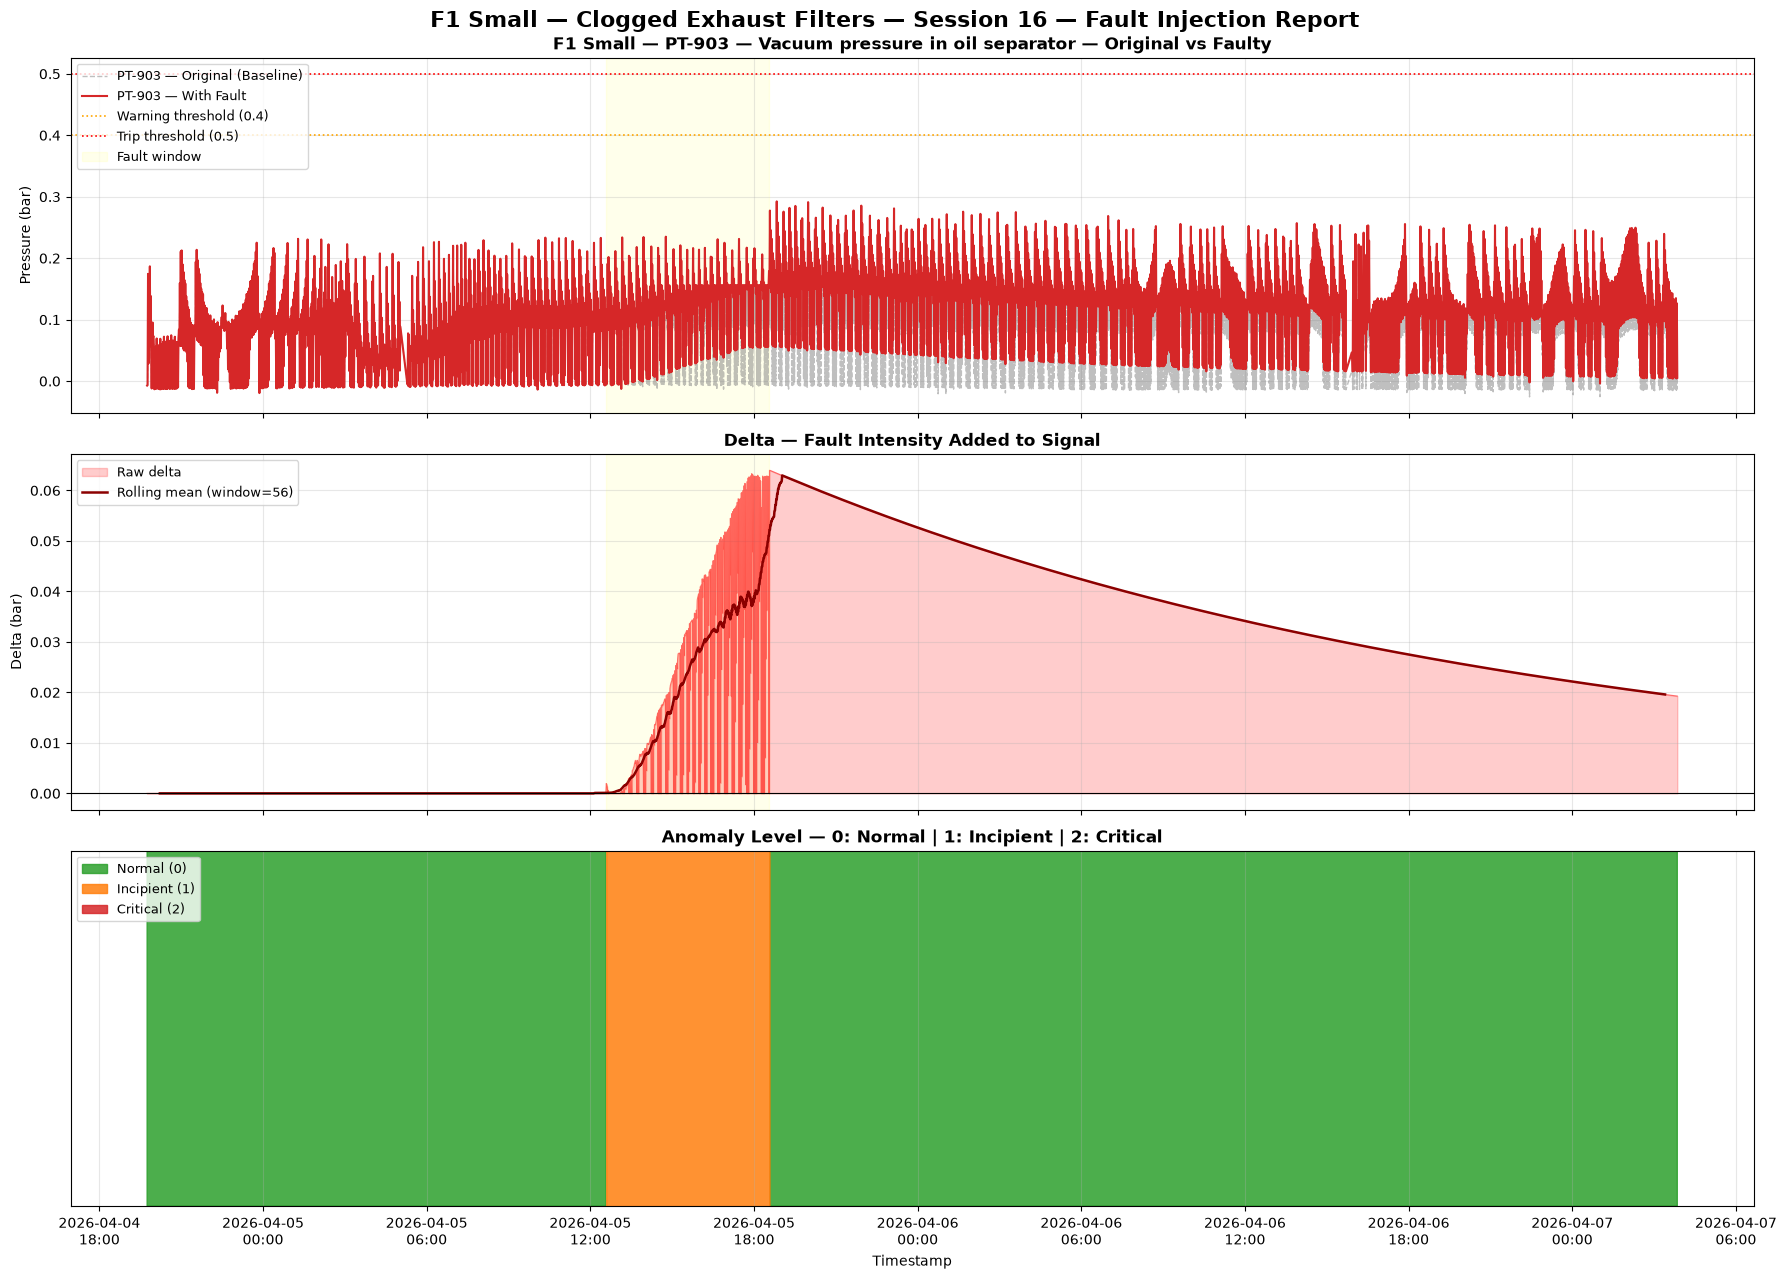

In [7]:
""" F1 Small — Fault Profile Verification Plot — Session 16 """

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 13), sharex=True)

# ============================================================
# PANEL 1 — Original vs Faulty PT-903
# ============================================================

f1_small_s16_fault_start_timestamp = f1_small_s16_df.index[f1_small_s16_start_idx]
f1_small_s16_fault_end_timestamp = f1_small_s16_df.index[f1_small_s16_end_idx - 1]

ax1.plot(
    f1_small_s16_df_orig.index,
    f1_small_s16_df_orig["PT-903"],
    color="gray",
    alpha=0.5,
    linestyle="--",
    linewidth=1.0,
    label="PT-903 — Original (Baseline)"
)

ax1.plot(
    f1_small_s16_df.index,
    f1_small_s16_df["PT-903"],
    color="#d62728",
    linewidth=1.5,
    label="PT-903 — With Fault"
)

ax1.axhline(
    y=pt903_warning,
    color="orange",
    linestyle=":",
    linewidth=1.2,
    label=f"Warning threshold ({pt903_warning})"
)

ax1.axhline(
    y=pt903_trip,
    color="red",
    linestyle=":",
    linewidth=1.2,
    label=f"Trip threshold ({pt903_trip})"
)

ax1.axvspan(
    f1_small_s16_fault_start_timestamp,
    f1_small_s16_fault_end_timestamp,
    color="yellow",
    alpha=0.08,
    label="Fault window"
)

ax1.set_title("F1 Small — PT-903 — Vacuum pressure in oil separator — Original vs Faulty", fontweight="bold")
ax1.set_ylabel("Pressure (bar)")
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(True, alpha=0.3)

# ============================================================
# PANEL 2 — Delta (fault intensity)
# ============================================================

f1_small_s16_delta_full = f1_small_s16_df["PT-903"] - f1_small_s16_df_orig["PT-903"]
f1_small_s16_roll_window = max(10, len(f1_small_s16_delta_full) // 60)
f1_small_s16_delta_rolling_mean = f1_small_s16_delta_full.rolling(f1_small_s16_roll_window, center=True).mean()

ax2.fill_between(
    f1_small_s16_df.index,
    0,
    f1_small_s16_delta_full,
    color="red",
    alpha=0.2,
    label="Raw delta"
)

ax2.plot(
    f1_small_s16_df.index,
    f1_small_s16_delta_full,
    color="red",
    linewidth=0.8,
    alpha=0.5
)

ax2.plot(
    f1_small_s16_df.index,
    f1_small_s16_delta_rolling_mean,
    color="#8B0000",
    linewidth=1.8,
    label=f"Rolling mean (window={f1_small_s16_roll_window})"
)

ax2.axhline(y=0, color="black", linewidth=0.8)
ax2.axvspan(f1_small_s16_fault_start_timestamp, f1_small_s16_fault_end_timestamp, color="yellow", alpha=0.08)
ax2.set_title("Delta — Fault Intensity Added to Signal", fontweight="bold")
ax2.set_ylabel("Delta (bar)")
ax2.legend(loc="upper left", fontsize=9)
ax2.grid(True, alpha=0.3)

# ============================================================
# PANEL 3 — Anomaly level bar
# ============================================================

f1_small_s16_normal_mask = f1_small_s16_df["anomaly_level"] == 0
f1_small_s16_incipient_mask = f1_small_s16_df["anomaly_level"] == 1
f1_small_s16_critical_mask = f1_small_s16_df["anomaly_level"] == 2

ax3.fill_between(f1_small_s16_df.index, 0, 1, where=f1_small_s16_normal_mask, color="#2ca02c", step="mid", alpha=0.85, label="Normal (0)")
ax3.fill_between(f1_small_s16_df.index, 0, 1, where=f1_small_s16_incipient_mask, color="#ff7f0e", step="mid", alpha=0.85, label="Incipient (1)")
ax3.fill_between(f1_small_s16_df.index, 0, 1, where=f1_small_s16_critical_mask, color="#d62728", step="mid", alpha=0.85, label="Critical (2)")

ax3.set_yticks([])
ax3.set_ylim(0, 1)
ax3.set_xlabel("Timestamp")
ax3.set_title("Anomaly Level — 0: Normal | 1: Incipient | 2: Critical", fontweight="bold")
ax3.legend(loc="upper left", fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))

fig.suptitle("F1 Small — Clogged Exhaust Filters — Session 16 — Fault Injection Report", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


#### Medium - Session 16

In [8]:
""" F1 Medium — Clogged Exhaust Filters — Session 16 """

np.random.seed(42)

f1_medium_s16_df_orig = dict_sessions[16].copy()
f1_medium_s16_main_sensor = "PT-903"
f1_medium_s16_length_hours = 10
f1_medium_s16_start_from = 0.45

# FAULT WINDOW
f1_medium_s16_session_length = len(f1_medium_s16_df_orig)
f1_medium_s16_start_idx = int(round(f1_medium_s16_session_length * f1_medium_s16_start_from))
f1_medium_s16_end_idx = min(f1_medium_s16_start_idx + int(round(f1_medium_s16_length_hours * 60)), f1_medium_s16_session_length)
f1_medium_s16_total_l = f1_medium_s16_end_idx - f1_medium_s16_start_idx
print("Session 16 length:", f1_medium_s16_session_length, "rows")
print("Fault start index:", f1_medium_s16_start_idx)
print("Fault end index:", f1_medium_s16_end_idx)
print("Fault window length:", f1_medium_s16_total_l, "rows")

# BASELINE STATISTICS
f1_medium_s16_baseline_mean = f1_medium_s16_df_orig["PT-903"].iloc[:f1_medium_s16_start_idx].mean()
f1_medium_s16_baseline_std = f1_medium_s16_df_orig["PT-903"].iloc[:f1_medium_s16_start_idx].std()
print("\nPT-903 baseline mean:", round(f1_medium_s16_baseline_mean, 4))
print("PT-903 baseline std:", round(f1_medium_s16_baseline_std, 4))

# SEVERITY TARGET — medium reaches the warning-to-trip interval
f1_medium_s16_target = pt903_warning + medium_trip_fraction * (pt903_trip - pt903_warning)
f1_medium_s16_delta_mag = f1_medium_s16_target - f1_medium_s16_baseline_mean
print("PT-903 medium target:", round(f1_medium_s16_target, 4))
print("PT-903 delta magnitude:", round(f1_medium_s16_delta_mag, 4))

# RAW DELTA SHAPE — stochastic ramp
f1_medium_s16_trend = np.linspace(0, f1_medium_s16_delta_mag, f1_medium_s16_total_l)
f1_medium_s16_noise_start = min(f1_medium_s16_baseline_std * 0.10, abs(f1_medium_s16_delta_mag) * 0.05)
f1_medium_s16_noise_end = min(f1_medium_s16_baseline_std * 0.50, abs(f1_medium_s16_delta_mag) * 0.15)
f1_medium_s16_noise_scale = np.linspace(f1_medium_s16_noise_start, f1_medium_s16_noise_end, f1_medium_s16_total_l)
f1_medium_s16_noise = np.random.normal(0, f1_medium_s16_noise_scale, f1_medium_s16_total_l)
f1_medium_s16_raw_delta = f1_medium_s16_trend + f1_medium_s16_noise
f1_medium_s16_delta = pd.Series(f1_medium_s16_raw_delta).rolling(10, center=True, min_periods=1).mean().values

# TARGET ALIGNMENT — keep severity ordered against the absolute target
f1_medium_s16_active_values = f1_medium_s16_df_orig["PT-903"].iloc[f1_medium_s16_start_idx:f1_medium_s16_end_idx].to_numpy()
f1_medium_s16_positive_peak_idx = int(np.argmax(f1_medium_s16_delta))
if True:
    f1_medium_s16_delta = np.maximum(f1_medium_s16_delta, 0)

if f1_medium_s16_delta[f1_medium_s16_positive_peak_idx] > 0:
    f1_medium_s16_desired_peak_delta = f1_medium_s16_target - f1_medium_s16_active_values[f1_medium_s16_positive_peak_idx]
    if f1_medium_s16_desired_peak_delta > 0:
        f1_medium_s16_delta = f1_medium_s16_delta * (f1_medium_s16_desired_peak_delta / f1_medium_s16_delta[f1_medium_s16_positive_peak_idx])

f1_medium_s16_upper_delta = f1_medium_s16_target - f1_medium_s16_active_values
f1_medium_s16_delta = np.minimum(f1_medium_s16_delta, f1_medium_s16_upper_delta)
if True:
    f1_medium_s16_delta = np.maximum(f1_medium_s16_delta, 0)

# CORRELATION COMPUTED EXPLICITLY
f1_medium_s16_corr_threshold = 0.7
f1_medium_s16_corr = f1_medium_s16_df_orig.corr(method="pearson", numeric_only=True)["PT-903"]
f1_medium_s16_corr_sensors = f1_medium_s16_corr[abs(f1_medium_s16_corr) >= f1_medium_s16_corr_threshold].index.tolist()
print("\nCorrelated sensors (|r| >=", f1_medium_s16_corr_threshold, "):", f1_medium_s16_corr_sensors)

# APPLY INJECTION EXPLICITLY SENSOR BY SENSOR
f1_medium_s16_df = f1_medium_s16_df_orig.copy()
f1_medium_s16_propagation_scale = 0.25
for sensor in f1_medium_s16_corr_sensors:
    if sensor in f1_medium_s16_df.columns:
        scale = 1.0 if sensor == f1_medium_s16_main_sensor else f1_medium_s16_propagation_scale
        f1_medium_s16_df.iloc[f1_medium_s16_start_idx:f1_medium_s16_end_idx, f1_medium_s16_df.columns.get_loc(sensor)] += f1_medium_s16_delta * f1_medium_s16_corr[sensor] * scale

# DECAY / STABILIZATION PHASE
f1_medium_s16_remaining = f1_medium_s16_session_length - f1_medium_s16_end_idx
if f1_medium_s16_remaining > 0:
    f1_medium_s16_decay_rate = 0.3
    f1_medium_s16_decay = f1_medium_s16_delta[-1] * np.exp(-f1_medium_s16_decay_rate * np.linspace(0, 1, f1_medium_s16_remaining))
    for sensor in f1_medium_s16_corr_sensors:
        if sensor in f1_medium_s16_df.columns:
            scale = 1.0 if sensor == f1_medium_s16_main_sensor else f1_medium_s16_propagation_scale
            f1_medium_s16_df.iloc[f1_medium_s16_end_idx:, f1_medium_s16_df.columns.get_loc(sensor)] += f1_medium_s16_decay * f1_medium_s16_corr[sensor] * scale

# SEVERITY CAP — small/medium should not drift beyond their target during stabilization
f1_medium_s16_main_sensor_loc = f1_medium_s16_df.columns.get_loc("PT-903")
f1_medium_s16_df.iloc[f1_medium_s16_start_idx:, f1_medium_s16_main_sensor_loc] = np.minimum(
    f1_medium_s16_df.iloc[f1_medium_s16_start_idx:, f1_medium_s16_main_sensor_loc],
    f1_medium_s16_target,
)

# LABELS — medium/severe faults are labelled from injection start through stabilization
f1_medium_s16_df["anomaly_level"] = 0
f1_medium_s16_df["is_injected_anomaly"] = 0
f1_medium_s16_df["anomaly_type"] = "normal"
f1_medium_s16_injected_values = f1_medium_s16_df["PT-903"].iloc[f1_medium_s16_start_idx:]
f1_medium_s16_labels = np.where(
    f1_medium_s16_injected_values >= pt903_trip, 2,
    np.where(f1_medium_s16_injected_values >= pt903_warning, 1, 0)
)
f1_medium_s16_df.iloc[f1_medium_s16_start_idx:, f1_medium_s16_df.columns.get_loc("anomaly_level")] = f1_medium_s16_labels
f1_medium_s16_df.iloc[f1_medium_s16_start_idx:, f1_medium_s16_df.columns.get_loc("is_injected_anomaly")] = 1
f1_medium_s16_df.iloc[f1_medium_s16_start_idx:, f1_medium_s16_df.columns.get_loc("anomaly_type")] = "clogged_filters"

# SAVE CSV
f1_medium_s16_df.to_csv(f"{output_dir_single}/session_16_F1_medium.csv")
print("\nSession 16 F1 medium saved")
print("Anomaly rows:", int(f1_medium_s16_df["is_injected_anomaly"].sum()))
print("Normal rows:", int((f1_medium_s16_df["is_injected_anomaly"] == 0).sum()))
print("Level 1 rows:", int((f1_medium_s16_df["anomaly_level"] == 1).sum()))
print("Level 2 rows:", int((f1_medium_s16_df["anomaly_level"] == 2).sum()))


Session 16 length: 3367 rows
Fault start index: 1515
Fault end index: 2115
Fault window length: 600 rows

PT-903 baseline mean: 0.08
PT-903 baseline std: 0.0713
PT-903 medium target: 0.455
PT-903 delta magnitude: 0.375

Correlated sensors (|r| >= 0.7 ): ['FT-901', 'PT-901', 'PT-902', 'PT-903', 'VSD-901_CORRENT', 'VSD-901_POWER']

Session 16 F1 medium saved
Anomaly rows: 1852
Normal rows: 1515
Level 1 rows: 110
Level 2 rows: 0


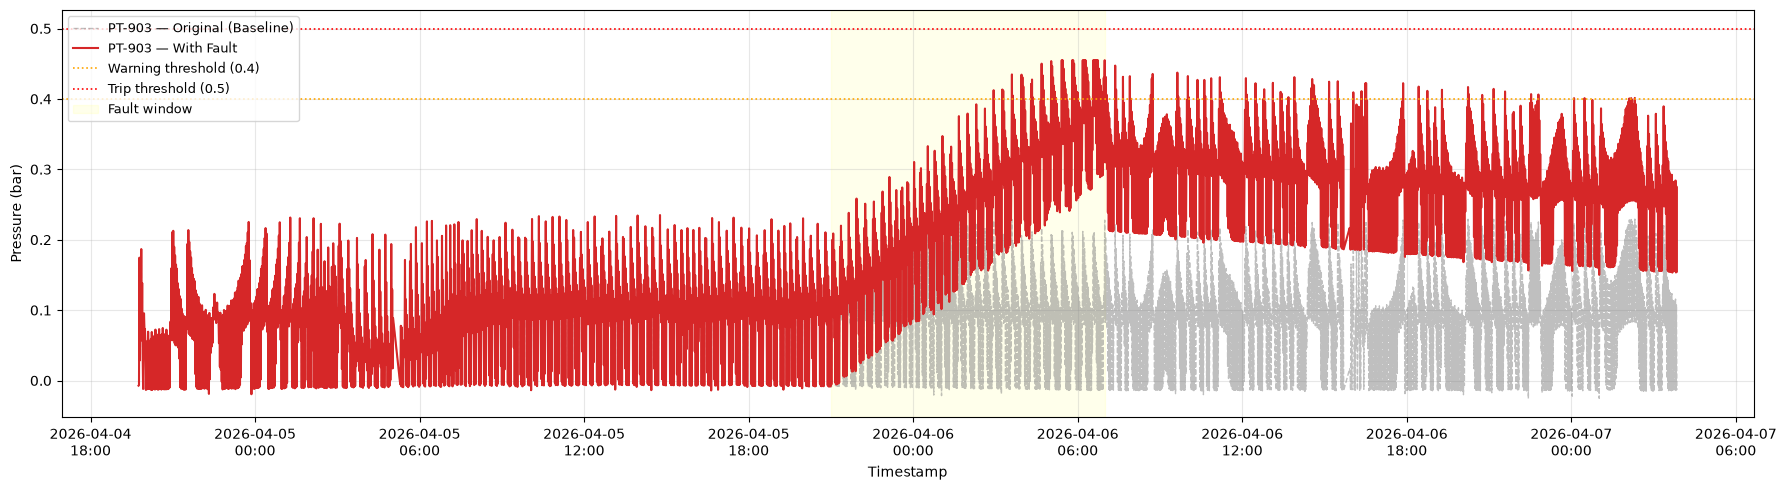

In [9]:
""" F1 Medium — Fault Profile Verification Plot — Session 16 """

fig, ax1 = plt.subplots(1, 1, figsize=(18, 5))

# ============================================================
# PANEL 1 — Original vs Faulty PT-903
# ============================================================

f1_medium_s16_fault_start_timestamp = f1_medium_s16_df.index[f1_medium_s16_start_idx]
f1_medium_s16_fault_end_timestamp = f1_medium_s16_df.index[f1_medium_s16_end_idx - 1]

ax1.plot(
    f1_medium_s16_df_orig.index,
    f1_medium_s16_df_orig["PT-903"],
    color="gray",
    alpha=0.5,
    linestyle="--",
    linewidth=1.0,
    label="PT-903 — Original (Baseline)"
)

ax1.plot(
    f1_medium_s16_df.index,
    f1_medium_s16_df["PT-903"],
    color="#d62728",
    linewidth=1.5,
    label="PT-903 — With Fault"
)

ax1.axhline(
    y=pt903_warning,
    color="orange",
    linestyle=":",
    linewidth=1.2,
    label=f"Warning threshold ({pt903_warning})"
)

ax1.axhline(
    y=pt903_trip,
    color="red",
    linestyle=":",
    linewidth=1.2,
    label=f"Trip threshold ({pt903_trip})"
)

ax1.axvspan(
    f1_medium_s16_fault_start_timestamp,
    f1_medium_s16_fault_end_timestamp,
    color="yellow",
    alpha=0.08,
    label="Fault window"
)

ax1.set_ylabel("Pressure (bar)")
ax1.set_xlabel("Timestamp")
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))

plt.tight_layout()
plt.savefig("fault_f1_medium_s16.png", dpi=200, bbox_inches="tight")
plt.show()

#### Severe - Session 16

In [10]:
""" F1 Severe — Clogged Exhaust Filters — Session 16 """

np.random.seed(42)

f1_severe_s16_df_orig = dict_sessions[16].copy()
f1_severe_s16_main_sensor = "PT-903"
f1_severe_s16_length_hours = 12
f1_severe_s16_start_from = 0.55

# FAULT WINDOW
f1_severe_s16_session_length = len(f1_severe_s16_df_orig)
f1_severe_s16_start_idx = int(round(f1_severe_s16_session_length * f1_severe_s16_start_from))
f1_severe_s16_end_idx = min(f1_severe_s16_start_idx + int(round(f1_severe_s16_length_hours * 60)), f1_severe_s16_session_length)
f1_severe_s16_total_l = f1_severe_s16_end_idx - f1_severe_s16_start_idx
print("Session 16 length:", f1_severe_s16_session_length, "rows")
print("Fault start index:", f1_severe_s16_start_idx)
print("Fault end index:", f1_severe_s16_end_idx)
print("Fault window length:", f1_severe_s16_total_l, "rows")

# BASELINE STATISTICS
f1_severe_s16_baseline_mean = f1_severe_s16_df_orig["PT-903"].iloc[:f1_severe_s16_start_idx].mean()
f1_severe_s16_baseline_std = f1_severe_s16_df_orig["PT-903"].iloc[:f1_severe_s16_start_idx].std()
print("\nPT-903 baseline mean:", round(f1_severe_s16_baseline_mean, 4))
print("PT-903 baseline std:", round(f1_severe_s16_baseline_std, 4))

# SEVERITY TARGET — severe reaches trip level
f1_severe_s16_target = pt903_trip
f1_severe_s16_delta_mag = f1_severe_s16_target - f1_severe_s16_baseline_mean
print("PT-903 severe target:", round(f1_severe_s16_target, 4))
print("PT-903 delta magnitude:", round(f1_severe_s16_delta_mag, 4))

# RAW DELTA SHAPE — stochastic ramp
f1_severe_s16_trend = np.linspace(0, f1_severe_s16_delta_mag, f1_severe_s16_total_l)
f1_severe_s16_noise_start = min(f1_severe_s16_baseline_std * 0.10, abs(f1_severe_s16_delta_mag) * 0.05)
f1_severe_s16_noise_end = min(f1_severe_s16_baseline_std * 0.50, abs(f1_severe_s16_delta_mag) * 0.15)
f1_severe_s16_noise_scale = np.linspace(f1_severe_s16_noise_start, f1_severe_s16_noise_end, f1_severe_s16_total_l)
f1_severe_s16_noise = np.random.normal(0, f1_severe_s16_noise_scale, f1_severe_s16_total_l)
f1_severe_s16_raw_delta = f1_severe_s16_trend + f1_severe_s16_noise
f1_severe_s16_delta = pd.Series(f1_severe_s16_raw_delta).rolling(10, center=True, min_periods=1).mean().values

# TARGET ALIGNMENT — keep severity ordered against the absolute target
f1_severe_s16_active_values = f1_severe_s16_df_orig["PT-903"].iloc[f1_severe_s16_start_idx:f1_severe_s16_end_idx].to_numpy()
f1_severe_s16_positive_peak_idx = int(np.argmax(f1_severe_s16_delta))
if True:
    f1_severe_s16_delta = np.maximum(f1_severe_s16_delta, 0)

if f1_severe_s16_delta[f1_severe_s16_positive_peak_idx] > 0:
    f1_severe_s16_desired_peak_delta = f1_severe_s16_target - f1_severe_s16_active_values[f1_severe_s16_positive_peak_idx]
    if f1_severe_s16_desired_peak_delta > 0:
        f1_severe_s16_delta = f1_severe_s16_delta * (f1_severe_s16_desired_peak_delta / f1_severe_s16_delta[f1_severe_s16_positive_peak_idx])

f1_severe_s16_upper_delta = f1_severe_s16_target - f1_severe_s16_active_values
f1_severe_s16_delta = np.minimum(f1_severe_s16_delta, f1_severe_s16_upper_delta)
if True:
    f1_severe_s16_delta = np.maximum(f1_severe_s16_delta, 0)

# CORRELATION COMPUTED EXPLICITLY
f1_severe_s16_corr_threshold = 0.7
f1_severe_s16_corr = f1_severe_s16_df_orig.corr(method="pearson", numeric_only=True)["PT-903"]
f1_severe_s16_corr_sensors = f1_severe_s16_corr[abs(f1_severe_s16_corr) >= f1_severe_s16_corr_threshold].index.tolist()
print("\nCorrelated sensors (|r| >=", f1_severe_s16_corr_threshold, "):", f1_severe_s16_corr_sensors)

# APPLY INJECTION EXPLICITLY SENSOR BY SENSOR
f1_severe_s16_df = f1_severe_s16_df_orig.copy()
f1_severe_s16_propagation_scale = 0.25
for sensor in f1_severe_s16_corr_sensors:
    if sensor in f1_severe_s16_df.columns:
        scale = 1.0 if sensor == f1_severe_s16_main_sensor else f1_severe_s16_propagation_scale
        f1_severe_s16_df.iloc[f1_severe_s16_start_idx:f1_severe_s16_end_idx, f1_severe_s16_df.columns.get_loc(sensor)] += f1_severe_s16_delta * f1_severe_s16_corr[sensor] * scale

# DECAY / STABILIZATION PHASE
f1_severe_s16_remaining = f1_severe_s16_session_length - f1_severe_s16_end_idx
if f1_severe_s16_remaining > 0:
    f1_severe_s16_decay_rate = 0.3
    f1_severe_s16_decay = f1_severe_s16_delta[-1] * np.exp(-f1_severe_s16_decay_rate * np.linspace(0, 1, f1_severe_s16_remaining))
    for sensor in f1_severe_s16_corr_sensors:
        if sensor in f1_severe_s16_df.columns:
            scale = 1.0 if sensor == f1_severe_s16_main_sensor else f1_severe_s16_propagation_scale
            f1_severe_s16_df.iloc[f1_severe_s16_end_idx:, f1_severe_s16_df.columns.get_loc(sensor)] += f1_severe_s16_decay * f1_severe_s16_corr[sensor] * scale

# LABELS — medium/severe faults are labelled from injection start through stabilization
f1_severe_s16_df["anomaly_level"] = 0
f1_severe_s16_df["is_injected_anomaly"] = 0
f1_severe_s16_df["anomaly_type"] = "normal"
f1_severe_s16_injected_values = f1_severe_s16_df["PT-903"].iloc[f1_severe_s16_start_idx:]
f1_severe_s16_labels = np.where(
    f1_severe_s16_injected_values >= pt903_trip, 2,
    np.where(f1_severe_s16_injected_values >= pt903_warning, 1, 0)
)
f1_severe_s16_df.iloc[f1_severe_s16_start_idx:, f1_severe_s16_df.columns.get_loc("anomaly_level")] = f1_severe_s16_labels
f1_severe_s16_df.iloc[f1_severe_s16_start_idx:, f1_severe_s16_df.columns.get_loc("is_injected_anomaly")] = 1
f1_severe_s16_df.iloc[f1_severe_s16_start_idx:, f1_severe_s16_df.columns.get_loc("anomaly_type")] = "clogged_filters"

# SAVE CSV
f1_severe_s16_df.to_csv(f"{output_dir_single}/session_16_F1_severe.csv")
print("\nSession 16 F1 severe saved")
print("Anomaly rows:", int(f1_severe_s16_df["is_injected_anomaly"].sum()))
print("Normal rows:", int((f1_severe_s16_df["is_injected_anomaly"] == 0).sum()))
print("Level 1 rows:", int((f1_severe_s16_df["anomaly_level"] == 1).sum()))
print("Level 2 rows:", int((f1_severe_s16_df["anomaly_level"] == 2).sum()))


Session 16 length: 3367 rows
Fault start index: 1852
Fault end index: 2572
Fault window length: 720 rows

PT-903 baseline mean: 0.0814
PT-903 baseline std: 0.0718
PT-903 severe target: 0.5
PT-903 delta magnitude: 0.4186

Correlated sensors (|r| >= 0.7 ): ['FT-901', 'PT-901', 'PT-902', 'PT-903', 'VSD-901_CORRENT', 'VSD-901_POWER']

Session 16 F1 severe saved
Anomaly rows: 1515
Normal rows: 1852
Level 1 rows: 176
Level 2 rows: 6


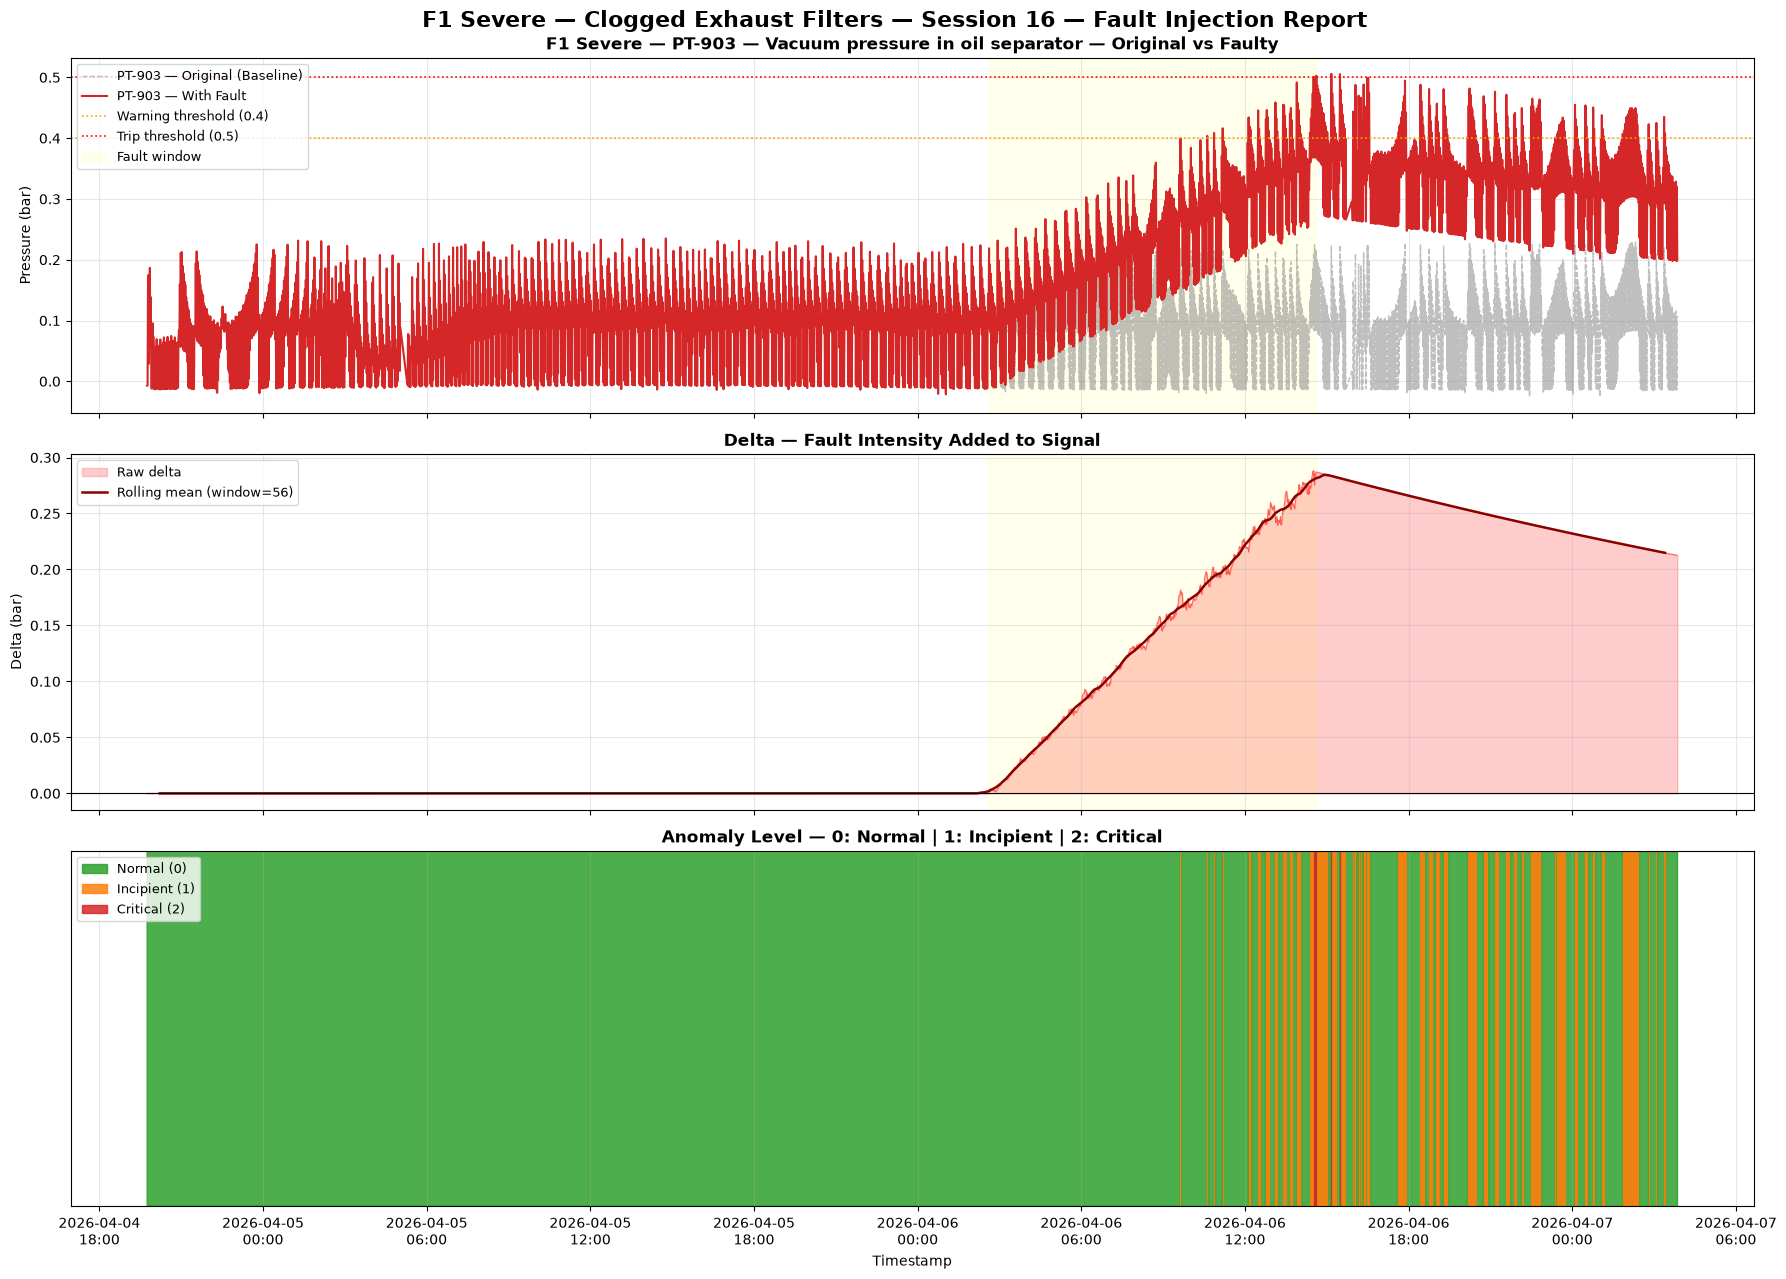

In [11]:
""" F1 Severe — Fault Profile Verification Plot — Session 16 """

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 13), sharex=True)

# ============================================================
# PANEL 1 — Original vs Faulty PT-903
# ============================================================

f1_severe_s16_fault_start_timestamp = f1_severe_s16_df.index[f1_severe_s16_start_idx]
f1_severe_s16_fault_end_timestamp = f1_severe_s16_df.index[f1_severe_s16_end_idx - 1]

ax1.plot(
    f1_severe_s16_df_orig.index,
    f1_severe_s16_df_orig["PT-903"],
    color="gray",
    alpha=0.5,
    linestyle="--",
    linewidth=1.0,
    label="PT-903 — Original (Baseline)"
)

ax1.plot(
    f1_severe_s16_df.index,
    f1_severe_s16_df["PT-903"],
    color="#d62728",
    linewidth=1.5,
    label="PT-903 — With Fault"
)

ax1.axhline(
    y=pt903_warning,
    color="orange",
    linestyle=":",
    linewidth=1.2,
    label=f"Warning threshold ({pt903_warning})"
)

ax1.axhline(
    y=pt903_trip,
    color="red",
    linestyle=":",
    linewidth=1.2,
    label=f"Trip threshold ({pt903_trip})"
)

ax1.axvspan(
    f1_severe_s16_fault_start_timestamp,
    f1_severe_s16_fault_end_timestamp,
    color="yellow",
    alpha=0.08,
    label="Fault window"
)

ax1.set_title("F1 Severe — PT-903 — Vacuum pressure in oil separator — Original vs Faulty", fontweight="bold")
ax1.set_ylabel("Pressure (bar)")
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(True, alpha=0.3)

# ============================================================
# PANEL 2 — Delta (fault intensity)
# ============================================================

f1_severe_s16_delta_full = f1_severe_s16_df["PT-903"] - f1_severe_s16_df_orig["PT-903"]
f1_severe_s16_roll_window = max(10, len(f1_severe_s16_delta_full) // 60)
f1_severe_s16_delta_rolling_mean = f1_severe_s16_delta_full.rolling(f1_severe_s16_roll_window, center=True).mean()

ax2.fill_between(
    f1_severe_s16_df.index,
    0,
    f1_severe_s16_delta_full,
    color="red",
    alpha=0.2,
    label="Raw delta"
)

ax2.plot(
    f1_severe_s16_df.index,
    f1_severe_s16_delta_full,
    color="red",
    linewidth=0.8,
    alpha=0.5
)

ax2.plot(
    f1_severe_s16_df.index,
    f1_severe_s16_delta_rolling_mean,
    color="#8B0000",
    linewidth=1.8,
    label=f"Rolling mean (window={f1_severe_s16_roll_window})"
)

ax2.axhline(y=0, color="black", linewidth=0.8)
ax2.axvspan(f1_severe_s16_fault_start_timestamp, f1_severe_s16_fault_end_timestamp, color="yellow", alpha=0.08)
ax2.set_title("Delta — Fault Intensity Added to Signal", fontweight="bold")
ax2.set_ylabel("Delta (bar)")
ax2.legend(loc="upper left", fontsize=9)
ax2.grid(True, alpha=0.3)

# ============================================================
# PANEL 3 — Anomaly level bar
# ============================================================

f1_severe_s16_normal_mask = f1_severe_s16_df["anomaly_level"] == 0
f1_severe_s16_incipient_mask = f1_severe_s16_df["anomaly_level"] == 1
f1_severe_s16_critical_mask = f1_severe_s16_df["anomaly_level"] == 2

ax3.fill_between(f1_severe_s16_df.index, 0, 1, where=f1_severe_s16_normal_mask, color="#2ca02c", step="mid", alpha=0.85, label="Normal (0)")
ax3.fill_between(f1_severe_s16_df.index, 0, 1, where=f1_severe_s16_incipient_mask, color="#ff7f0e", step="mid", alpha=0.85, label="Incipient (1)")
ax3.fill_between(f1_severe_s16_df.index, 0, 1, where=f1_severe_s16_critical_mask, color="#d62728", step="mid", alpha=0.85, label="Critical (2)")

ax3.set_yticks([])
ax3.set_ylim(0, 1)
ax3.set_xlabel("Timestamp")
ax3.set_title("Anomaly Level — 0: Normal | 1: Incipient | 2: Critical", fontweight="bold")
ax3.legend(loc="upper left", fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))

fig.suptitle("F1 Severe — Clogged Exhaust Filters — Session 16 — Fault Injection Report", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


#### Small - Session 17

In [12]:
""" F1 Small — Clogged Exhaust Filters — Session 17 """

np.random.seed(42)

f1_small_s17_df_orig = dict_sessions[17].copy()
f1_small_s17_main_sensor = "PT-903"
f1_small_s17_length_hours = 6
f1_small_s17_start_from = 0.3

# FAULT WINDOW
f1_small_s17_session_length = len(f1_small_s17_df_orig)
f1_small_s17_start_idx = int(round(f1_small_s17_session_length * f1_small_s17_start_from))
f1_small_s17_end_idx = min(f1_small_s17_start_idx + int(round(f1_small_s17_length_hours * 60)), f1_small_s17_session_length)
f1_small_s17_total_l = f1_small_s17_end_idx - f1_small_s17_start_idx
print("Session 17 length:", f1_small_s17_session_length, "rows")
print("Fault start index:", f1_small_s17_start_idx)
print("Fault end index:", f1_small_s17_end_idx)
print("Fault window length:", f1_small_s17_total_l, "rows")

# BASELINE STATISTICS
f1_small_s17_baseline_mean = f1_small_s17_df_orig["PT-903"].iloc[:f1_small_s17_start_idx].mean()
f1_small_s17_baseline_std = f1_small_s17_df_orig["PT-903"].iloc[:f1_small_s17_start_idx].std()
print("\nPT-903 baseline mean:", round(f1_small_s17_baseline_mean, 4))
print("PT-903 baseline std:", round(f1_small_s17_baseline_std, 4))

# SEVERITY TARGET — small moves from baseline toward warning
f1_small_s17_target = f1_small_s17_baseline_mean + small_warning_fraction * (pt903_warning - f1_small_s17_baseline_mean)
f1_small_s17_delta_mag = f1_small_s17_target - f1_small_s17_baseline_mean
print("PT-903 small target:", round(f1_small_s17_target, 4))
print("PT-903 delta magnitude:", round(f1_small_s17_delta_mag, 4))

# RAW DELTA SHAPE — subtle smooth ramp
f1_small_s17_t = np.linspace(0, 1, f1_small_s17_total_l)
f1_small_s17_smoothstep = 3 * f1_small_s17_t**2 - 2 * f1_small_s17_t**3
f1_small_s17_noise_std = min(f1_small_s17_baseline_std * 0.08, abs(f1_small_s17_delta_mag) * 0.10)
f1_small_s17_noise = np.random.normal(0, f1_small_s17_noise_std, f1_small_s17_total_l)
f1_small_s17_noise = pd.Series(f1_small_s17_noise).rolling(20, center=True, min_periods=1).mean().values
f1_small_s17_delta = f1_small_s17_delta_mag * f1_small_s17_smoothstep + f1_small_s17_noise

# TARGET ALIGNMENT — keep severity ordered against the absolute target
f1_small_s17_active_values = f1_small_s17_df_orig["PT-903"].iloc[f1_small_s17_start_idx:f1_small_s17_end_idx].to_numpy()
f1_small_s17_positive_peak_idx = int(np.argmax(f1_small_s17_delta))
if True:
    f1_small_s17_delta = np.maximum(f1_small_s17_delta, 0)

if f1_small_s17_delta[f1_small_s17_positive_peak_idx] > 0:
    f1_small_s17_desired_peak_delta = f1_small_s17_target - f1_small_s17_active_values[f1_small_s17_positive_peak_idx]
    if f1_small_s17_desired_peak_delta > 0:
        f1_small_s17_delta = f1_small_s17_delta * (f1_small_s17_desired_peak_delta / f1_small_s17_delta[f1_small_s17_positive_peak_idx])

f1_small_s17_upper_delta = f1_small_s17_target - f1_small_s17_active_values
f1_small_s17_delta = np.minimum(f1_small_s17_delta, f1_small_s17_upper_delta)
if True:
    f1_small_s17_delta = np.maximum(f1_small_s17_delta, 0)

# CORRELATION COMPUTED EXPLICITLY
f1_small_s17_corr_threshold = 0.7
f1_small_s17_corr = f1_small_s17_df_orig.corr(method="pearson", numeric_only=True)["PT-903"]
f1_small_s17_corr_sensors = f1_small_s17_corr[abs(f1_small_s17_corr) >= f1_small_s17_corr_threshold].index.tolist()
print("\nCorrelated sensors (|r| >=", f1_small_s17_corr_threshold, "):", f1_small_s17_corr_sensors)

# APPLY INJECTION EXPLICITLY SENSOR BY SENSOR
f1_small_s17_df = f1_small_s17_df_orig.copy()
f1_small_s17_propagation_scale = 0.25
for sensor in f1_small_s17_corr_sensors:
    if sensor in f1_small_s17_df.columns:
        scale = 1.0 if sensor == f1_small_s17_main_sensor else f1_small_s17_propagation_scale
        f1_small_s17_df.iloc[f1_small_s17_start_idx:f1_small_s17_end_idx, f1_small_s17_df.columns.get_loc(sensor)] += f1_small_s17_delta * f1_small_s17_corr[sensor] * scale

# DECAY / STABILIZATION PHASE
f1_small_s17_remaining = f1_small_s17_session_length - f1_small_s17_end_idx
if f1_small_s17_remaining > 0:
    f1_small_s17_decay_rate = 1.2
    f1_small_s17_decay = f1_small_s17_delta[-1] * np.exp(-f1_small_s17_decay_rate * np.linspace(0, 1, f1_small_s17_remaining))
    for sensor in f1_small_s17_corr_sensors:
        if sensor in f1_small_s17_df.columns:
            scale = 1.0 if sensor == f1_small_s17_main_sensor else f1_small_s17_propagation_scale
            f1_small_s17_df.iloc[f1_small_s17_end_idx:, f1_small_s17_df.columns.get_loc(sensor)] += f1_small_s17_decay * f1_small_s17_corr[sensor] * scale


# LABELS — small faults are below warning but still injected anomalies
f1_small_s17_df["anomaly_level"] = 0
f1_small_s17_df["is_injected_anomaly"] = 0
f1_small_s17_df["anomaly_type"] = "normal"
f1_small_s17_df.iloc[f1_small_s17_start_idx:f1_small_s17_end_idx, f1_small_s17_df.columns.get_loc("anomaly_level")] = 1
f1_small_s17_df.iloc[f1_small_s17_start_idx:f1_small_s17_end_idx, f1_small_s17_df.columns.get_loc("is_injected_anomaly")] = 1
f1_small_s17_df.iloc[f1_small_s17_start_idx:f1_small_s17_end_idx, f1_small_s17_df.columns.get_loc("anomaly_type")] = "clogged_filters"

# SAVE CSV
f1_small_s17_df.to_csv(f"{output_dir_single}/session_17_F1_small.csv")
print("\nSession 17 F1 small saved")
print("Anomaly rows:", int(f1_small_s17_df["is_injected_anomaly"].sum()))
print("Normal rows:", int((f1_small_s17_df["is_injected_anomaly"] == 0).sum()))
print("Level 1 rows:", int((f1_small_s17_df["anomaly_level"] == 1).sum()))
print("Level 2 rows:", int((f1_small_s17_df["anomaly_level"] == 2).sum()))


Session 17 length: 4415 rows
Fault start index: 1324
Fault end index: 1684
Fault window length: 360 rows

PT-903 baseline mean: -0.0928
PT-903 baseline std: 0.7287
PT-903 small target: 0.0304
PT-903 delta magnitude: 0.1232

Correlated sensors (|r| >= 0.7 ): ['PT-903', 'pt903_frozen_flag']


/var/folders/df/cfzb18t5629c221k8xlry1dw0000gn/T/ipykernel_38570/1657801352.py:68: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 0.00000000e+00 -1.11092299e-03  0.00000000e+00 -8.93419689e-04
  0.00000000e+00 -4.89864552e-05  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00 -2.30724540e-05  0.00000000e+00 -3.66351147e-04
  0.00000000e+00 -3.84029801e-04  0.00000000e+00 -4.80782307e-05
  0.00000000e+00 -4.42789785e-04  0.00000000e+00  0.00000000e+00
  0.0000


Session 17 F1 small saved
Anomaly rows: 360
Normal rows: 4055
Level 1 rows: 360
Level 2 rows: 0


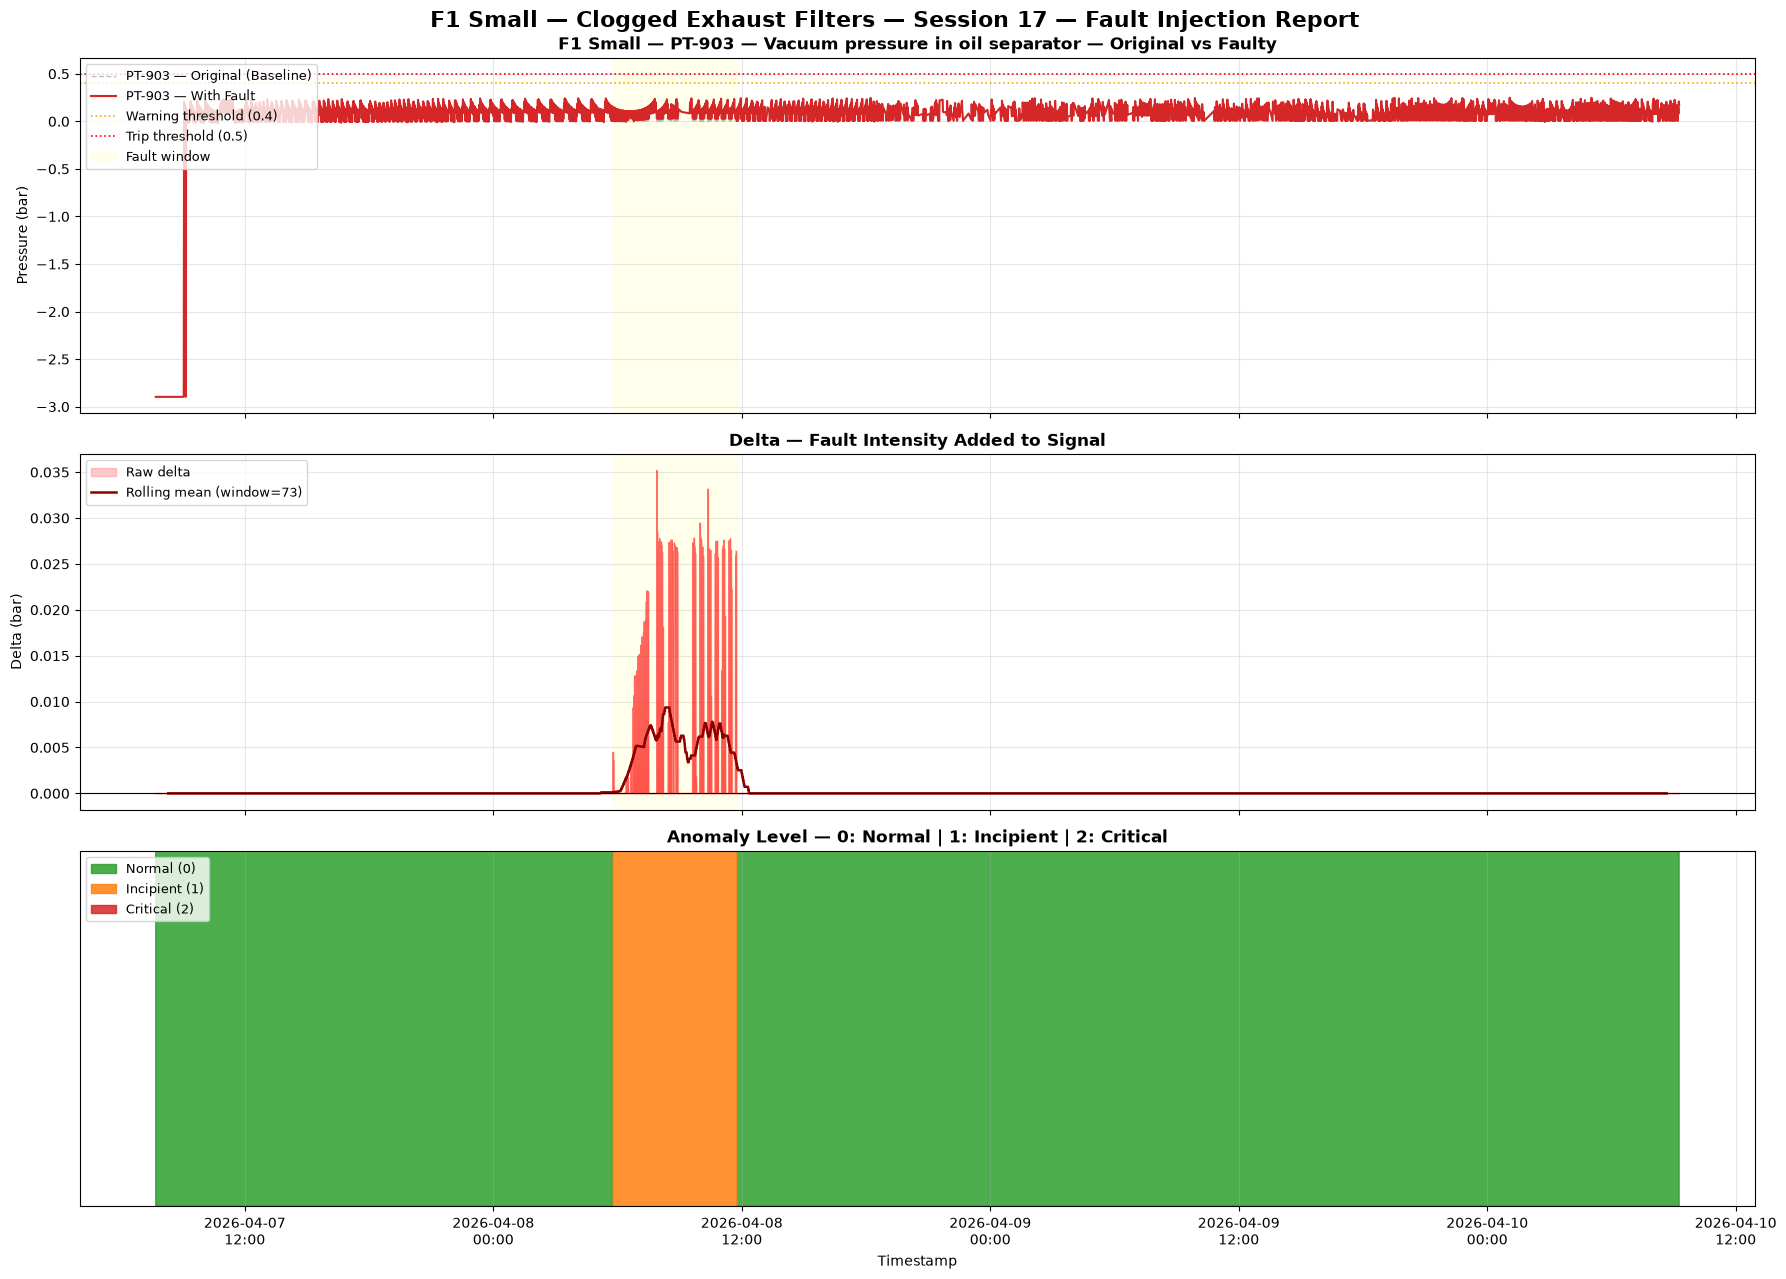

In [13]:
""" F1 Small — Fault Profile Verification Plot — Session 17 """

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 13), sharex=True)

# ============================================================
# PANEL 1 — Original vs Faulty PT-903
# ============================================================

f1_small_s17_fault_start_timestamp = f1_small_s17_df.index[f1_small_s17_start_idx]
f1_small_s17_fault_end_timestamp = f1_small_s17_df.index[f1_small_s17_end_idx - 1]

ax1.plot(
    f1_small_s17_df_orig.index,
    f1_small_s17_df_orig["PT-903"],
    color="gray",
    alpha=0.5,
    linestyle="--",
    linewidth=1.0,
    label="PT-903 — Original (Baseline)"
)

ax1.plot(
    f1_small_s17_df.index,
    f1_small_s17_df["PT-903"],
    color="#d62728",
    linewidth=1.5,
    label="PT-903 — With Fault"
)

ax1.axhline(
    y=pt903_warning,
    color="orange",
    linestyle=":",
    linewidth=1.2,
    label=f"Warning threshold ({pt903_warning})"
)

ax1.axhline(
    y=pt903_trip,
    color="red",
    linestyle=":",
    linewidth=1.2,
    label=f"Trip threshold ({pt903_trip})"
)

ax1.axvspan(
    f1_small_s17_fault_start_timestamp,
    f1_small_s17_fault_end_timestamp,
    color="yellow",
    alpha=0.08,
    label="Fault window"
)

ax1.set_title("F1 Small — PT-903 — Vacuum pressure in oil separator — Original vs Faulty", fontweight="bold")
ax1.set_ylabel("Pressure (bar)")
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(True, alpha=0.3)

# ============================================================
# PANEL 2 — Delta (fault intensity)
# ============================================================

f1_small_s17_delta_full = f1_small_s17_df["PT-903"] - f1_small_s17_df_orig["PT-903"]
f1_small_s17_roll_window = max(10, len(f1_small_s17_delta_full) // 60)
f1_small_s17_delta_rolling_mean = f1_small_s17_delta_full.rolling(f1_small_s17_roll_window, center=True).mean()

ax2.fill_between(
    f1_small_s17_df.index,
    0,
    f1_small_s17_delta_full,
    color="red",
    alpha=0.2,
    label="Raw delta"
)

ax2.plot(
    f1_small_s17_df.index,
    f1_small_s17_delta_full,
    color="red",
    linewidth=0.8,
    alpha=0.5
)

ax2.plot(
    f1_small_s17_df.index,
    f1_small_s17_delta_rolling_mean,
    color="#8B0000",
    linewidth=1.8,
    label=f"Rolling mean (window={f1_small_s17_roll_window})"
)

ax2.axhline(y=0, color="black", linewidth=0.8)
ax2.axvspan(f1_small_s17_fault_start_timestamp, f1_small_s17_fault_end_timestamp, color="yellow", alpha=0.08)
ax2.set_title("Delta — Fault Intensity Added to Signal", fontweight="bold")
ax2.set_ylabel("Delta (bar)")
ax2.legend(loc="upper left", fontsize=9)
ax2.grid(True, alpha=0.3)

# ============================================================
# PANEL 3 — Anomaly level bar
# ============================================================

f1_small_s17_normal_mask = f1_small_s17_df["anomaly_level"] == 0
f1_small_s17_incipient_mask = f1_small_s17_df["anomaly_level"] == 1
f1_small_s17_critical_mask = f1_small_s17_df["anomaly_level"] == 2

ax3.fill_between(f1_small_s17_df.index, 0, 1, where=f1_small_s17_normal_mask, color="#2ca02c", step="mid", alpha=0.85, label="Normal (0)")
ax3.fill_between(f1_small_s17_df.index, 0, 1, where=f1_small_s17_incipient_mask, color="#ff7f0e", step="mid", alpha=0.85, label="Incipient (1)")
ax3.fill_between(f1_small_s17_df.index, 0, 1, where=f1_small_s17_critical_mask, color="#d62728", step="mid", alpha=0.85, label="Critical (2)")

ax3.set_yticks([])
ax3.set_ylim(0, 1)
ax3.set_xlabel("Timestamp")
ax3.set_title("Anomaly Level — 0: Normal | 1: Incipient | 2: Critical", fontweight="bold")
ax3.legend(loc="upper left", fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))

fig.suptitle("F1 Small — Clogged Exhaust Filters — Session 17 — Fault Injection Report", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


#### Medium - Session 17

In [14]:
""" F1 Medium — Clogged Exhaust Filters — Session 17 """

np.random.seed(42)

f1_medium_s17_df_orig = dict_sessions[17].copy()
f1_medium_s17_main_sensor = "PT-903"
f1_medium_s17_length_hours = 10
f1_medium_s17_start_from = 0.45

# FAULT WINDOW
f1_medium_s17_session_length = len(f1_medium_s17_df_orig)
f1_medium_s17_start_idx = int(round(f1_medium_s17_session_length * f1_medium_s17_start_from))
f1_medium_s17_end_idx = min(f1_medium_s17_start_idx + int(round(f1_medium_s17_length_hours * 60)), f1_medium_s17_session_length)
f1_medium_s17_total_l = f1_medium_s17_end_idx - f1_medium_s17_start_idx
print("Session 17 length:", f1_medium_s17_session_length, "rows")
print("Fault start index:", f1_medium_s17_start_idx)
print("Fault end index:", f1_medium_s17_end_idx)
print("Fault window length:", f1_medium_s17_total_l, "rows")

# BASELINE STATISTICS
f1_medium_s17_baseline_mean = f1_medium_s17_df_orig["PT-903"].iloc[:f1_medium_s17_start_idx].mean()
f1_medium_s17_baseline_std = f1_medium_s17_df_orig["PT-903"].iloc[:f1_medium_s17_start_idx].std()
print("\nPT-903 baseline mean:", round(f1_medium_s17_baseline_mean, 4))
print("PT-903 baseline std:", round(f1_medium_s17_baseline_std, 4))

# SEVERITY TARGET — medium reaches the warning-to-trip interval
f1_medium_s17_target = pt903_warning + medium_trip_fraction * (pt903_trip - pt903_warning)
f1_medium_s17_delta_mag = f1_medium_s17_target - f1_medium_s17_baseline_mean
print("PT-903 medium target:", round(f1_medium_s17_target, 4))
print("PT-903 delta magnitude:", round(f1_medium_s17_delta_mag, 4))

# RAW DELTA SHAPE — stochastic ramp
f1_medium_s17_trend = np.linspace(0, f1_medium_s17_delta_mag, f1_medium_s17_total_l)
f1_medium_s17_noise_start = min(f1_medium_s17_baseline_std * 0.10, abs(f1_medium_s17_delta_mag) * 0.05)
f1_medium_s17_noise_end = min(f1_medium_s17_baseline_std * 0.50, abs(f1_medium_s17_delta_mag) * 0.15)
f1_medium_s17_noise_scale = np.linspace(f1_medium_s17_noise_start, f1_medium_s17_noise_end, f1_medium_s17_total_l)
f1_medium_s17_noise = np.random.normal(0, f1_medium_s17_noise_scale, f1_medium_s17_total_l)
f1_medium_s17_raw_delta = f1_medium_s17_trend + f1_medium_s17_noise
f1_medium_s17_delta = pd.Series(f1_medium_s17_raw_delta).rolling(10, center=True, min_periods=1).mean().values

# TARGET ALIGNMENT — keep severity ordered against the absolute target
f1_medium_s17_active_values = f1_medium_s17_df_orig["PT-903"].iloc[f1_medium_s17_start_idx:f1_medium_s17_end_idx].to_numpy()
f1_medium_s17_positive_peak_idx = int(np.argmax(f1_medium_s17_delta))
if True:
    f1_medium_s17_delta = np.maximum(f1_medium_s17_delta, 0)

if f1_medium_s17_delta[f1_medium_s17_positive_peak_idx] > 0:
    f1_medium_s17_desired_peak_delta = f1_medium_s17_target - f1_medium_s17_active_values[f1_medium_s17_positive_peak_idx]
    if f1_medium_s17_desired_peak_delta > 0:
        f1_medium_s17_delta = f1_medium_s17_delta * (f1_medium_s17_desired_peak_delta / f1_medium_s17_delta[f1_medium_s17_positive_peak_idx])

f1_medium_s17_upper_delta = f1_medium_s17_target - f1_medium_s17_active_values
f1_medium_s17_delta = np.minimum(f1_medium_s17_delta, f1_medium_s17_upper_delta)
if True:
    f1_medium_s17_delta = np.maximum(f1_medium_s17_delta, 0)

# CORRELATION COMPUTED EXPLICITLY
f1_medium_s17_corr_threshold = 0.7
f1_medium_s17_corr = f1_medium_s17_df_orig.corr(method="pearson", numeric_only=True)["PT-903"]
f1_medium_s17_corr_sensors = f1_medium_s17_corr[abs(f1_medium_s17_corr) >= f1_medium_s17_corr_threshold].index.tolist()
print("\nCorrelated sensors (|r| >=", f1_medium_s17_corr_threshold, "):", f1_medium_s17_corr_sensors)

# APPLY INJECTION EXPLICITLY SENSOR BY SENSOR
f1_medium_s17_df = f1_medium_s17_df_orig.copy()
f1_medium_s17_propagation_scale = 0.25
for sensor in f1_medium_s17_corr_sensors:
    if sensor in f1_medium_s17_df.columns:
        scale = 1.0 if sensor == f1_medium_s17_main_sensor else f1_medium_s17_propagation_scale
        f1_medium_s17_df.iloc[f1_medium_s17_start_idx:f1_medium_s17_end_idx, f1_medium_s17_df.columns.get_loc(sensor)] += f1_medium_s17_delta * f1_medium_s17_corr[sensor] * scale

# DECAY / STABILIZATION PHASE
f1_medium_s17_remaining = f1_medium_s17_session_length - f1_medium_s17_end_idx
if f1_medium_s17_remaining > 0:
    f1_medium_s17_decay_rate = 0.3
    f1_medium_s17_decay = f1_medium_s17_delta[-1] * np.exp(-f1_medium_s17_decay_rate * np.linspace(0, 1, f1_medium_s17_remaining))
    for sensor in f1_medium_s17_corr_sensors:
        if sensor in f1_medium_s17_df.columns:
            scale = 1.0 if sensor == f1_medium_s17_main_sensor else f1_medium_s17_propagation_scale
            f1_medium_s17_df.iloc[f1_medium_s17_end_idx:, f1_medium_s17_df.columns.get_loc(sensor)] += f1_medium_s17_decay * f1_medium_s17_corr[sensor] * scale

# SEVERITY CAP — small/medium should not drift beyond their target during stabilization
f1_medium_s17_main_sensor_loc = f1_medium_s17_df.columns.get_loc("PT-903")
f1_medium_s17_df.iloc[f1_medium_s17_start_idx:, f1_medium_s17_main_sensor_loc] = np.minimum(
    f1_medium_s17_df.iloc[f1_medium_s17_start_idx:, f1_medium_s17_main_sensor_loc],
    f1_medium_s17_target,
)

# LABELS — medium/severe faults are labelled from injection start through stabilization
f1_medium_s17_df["anomaly_level"] = 0
f1_medium_s17_df["is_injected_anomaly"] = 0
f1_medium_s17_df["anomaly_type"] = "normal"
f1_medium_s17_injected_values = f1_medium_s17_df["PT-903"].iloc[f1_medium_s17_start_idx:]
f1_medium_s17_labels = np.where(
    f1_medium_s17_injected_values >= pt903_trip, 2,
    np.where(f1_medium_s17_injected_values >= pt903_warning, 1, 0)
)
f1_medium_s17_df.iloc[f1_medium_s17_start_idx:, f1_medium_s17_df.columns.get_loc("anomaly_level")] = f1_medium_s17_labels
f1_medium_s17_df.iloc[f1_medium_s17_start_idx:, f1_medium_s17_df.columns.get_loc("is_injected_anomaly")] = 1
f1_medium_s17_df.iloc[f1_medium_s17_start_idx:, f1_medium_s17_df.columns.get_loc("anomaly_type")] = "clogged_filters"

# SAVE CSV
f1_medium_s17_df.to_csv(f"{output_dir_single}/session_17_F1_medium.csv")
print("\nSession 17 F1 medium saved")
print("Anomaly rows:", int(f1_medium_s17_df["is_injected_anomaly"].sum()))
print("Normal rows:", int((f1_medium_s17_df["is_injected_anomaly"] == 0).sum()))
print("Level 1 rows:", int((f1_medium_s17_df["anomaly_level"] == 1).sum()))
print("Level 2 rows:", int((f1_medium_s17_df["anomaly_level"] == 2).sum()))


Session 17 length: 4415 rows
Fault start index: 1987
Fault end index: 2587
Fault window length: 600 rows

PT-903 baseline mean: -0.0304
PT-903 baseline std: 0.6026
PT-903 medium target: 0.455
PT-903 delta magnitude: 0.4854

Correlated sensors (|r| >= 0.7 ): ['PT-903', 'pt903_frozen_flag']


/var/folders/df/cfzb18t5629c221k8xlry1dw0000gn/T/ipykernel_38570/2763065305.py:69: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-0.0024555  -0.00199124 -0.00290784 -0.00313568 -0.00267643 -0.0028077
 -0.00250982 -0.00250508 -0.00247422 -0.00098846 -0.00041547 -0.00040688
  0.          0.          0.          0.          0.          0.
  0.         -0.00020511 -0.00092528 -0.00141014 -0.00147973 -0.00167068
 -0.00196763 -0.00267128 -0.0017932  -0.00300916 -0.00312357 -0.00344562
 -0.00429873 -0.003765   -0.00460926 -0.00355208 -0.00331719 -0.00372398
 -0.00457483 -0.00387144 -0.00397215 -0.00451239 -0.00345506 -0.00385863
 -0.00365835 -0.0054031  -0.00643793 -0.00553735 -0.00547931 -0.00533467
 -0.0051821  -0.00583111 -0.00733812 -0.00838915 -0.00832841 -0.00774483
 -0.0078983  -0.00954763 -0.00926007 -0.00952052 -0.00942442 -0.00857316
 -0.00862104 -0.00903054 -0.00960714 -0.01050303 -0.01068045 -0.009


Session 17 F1 medium saved
Anomaly rows: 2428
Normal rows: 1987
Level 1 rows: 1076
Level 2 rows: 0


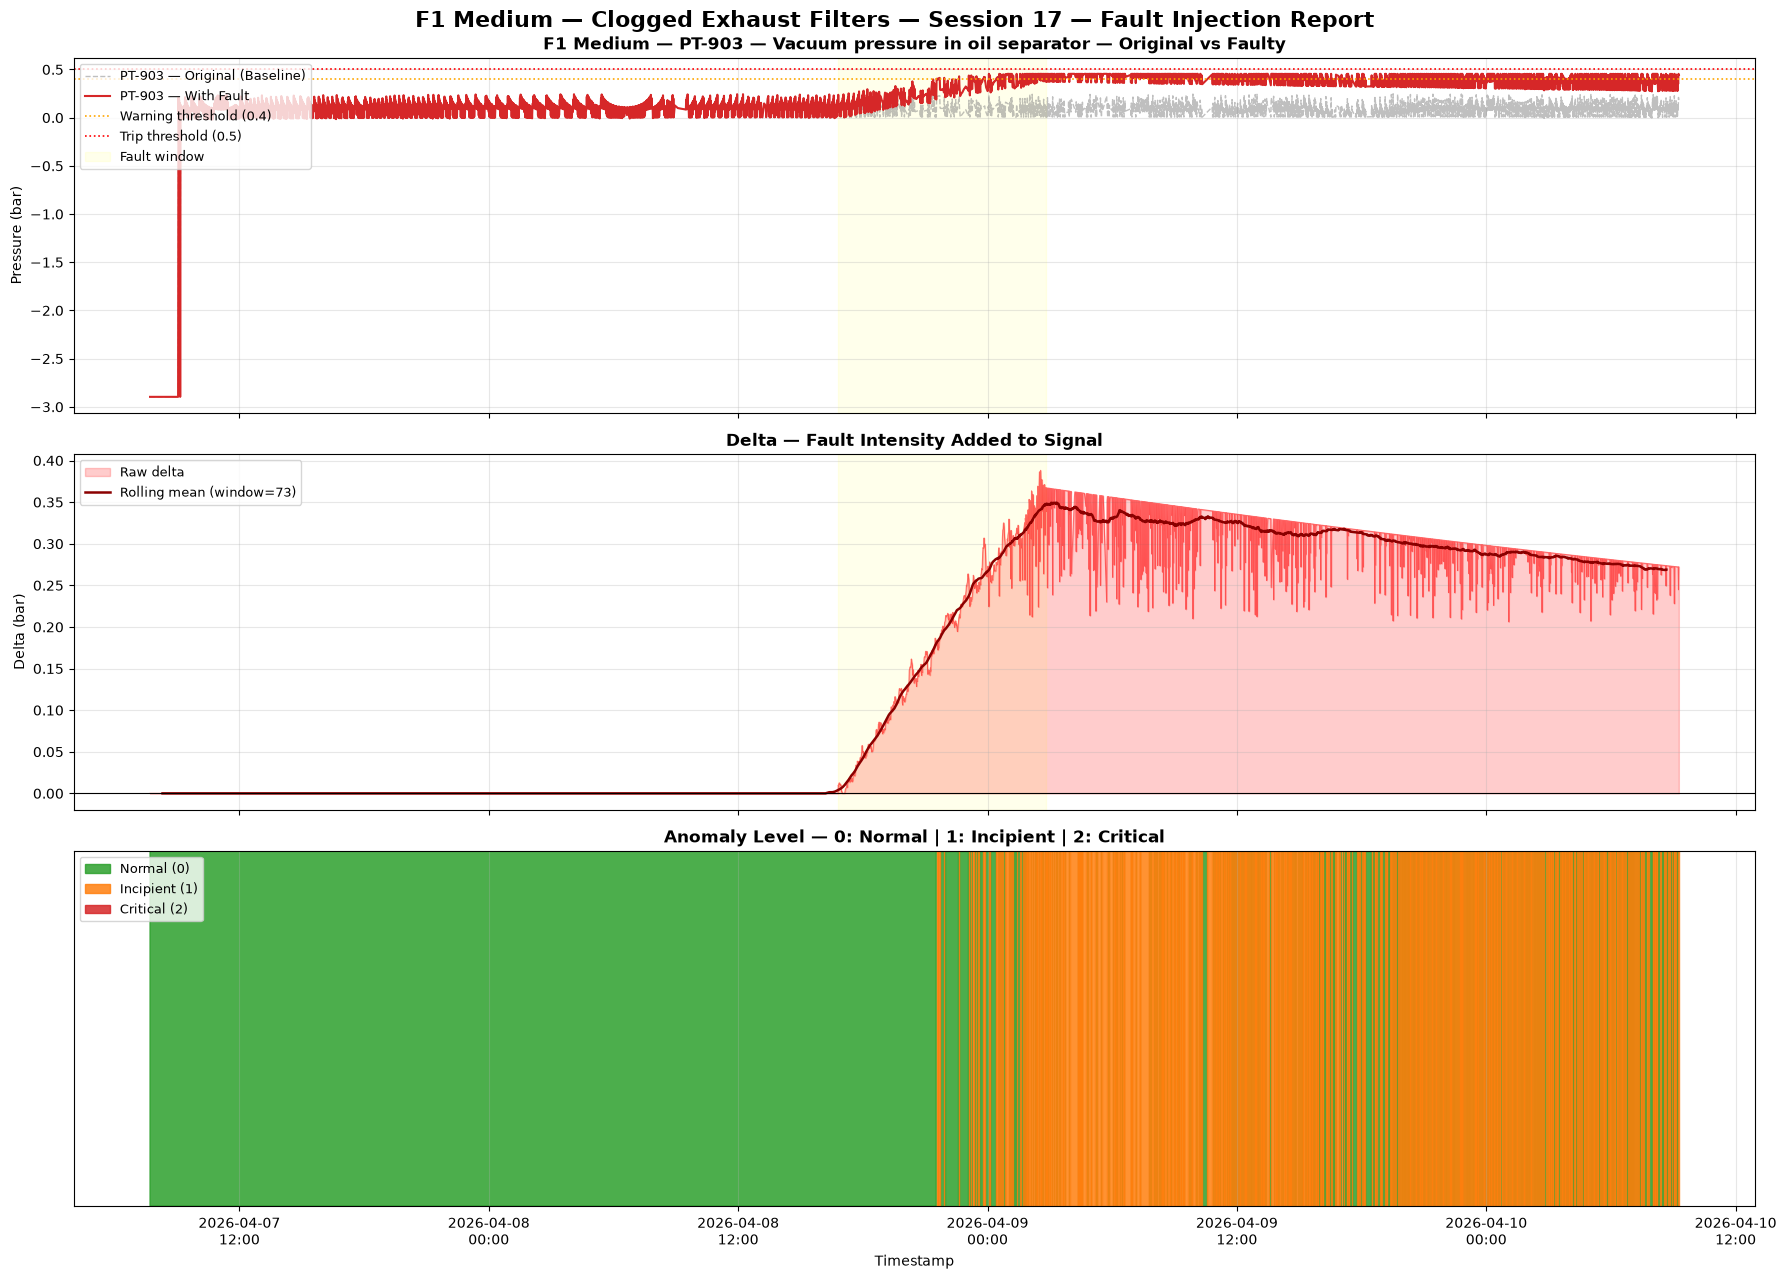

In [15]:
""" F1 Medium — Fault Profile Verification Plot — Session 17 """

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 13), sharex=True)

# ============================================================
# PANEL 1 — Original vs Faulty PT-903
# ============================================================

f1_medium_s17_fault_start_timestamp = f1_medium_s17_df.index[f1_medium_s17_start_idx]
f1_medium_s17_fault_end_timestamp = f1_medium_s17_df.index[f1_medium_s17_end_idx - 1]

ax1.plot(
    f1_medium_s17_df_orig.index,
    f1_medium_s17_df_orig["PT-903"],
    color="gray",
    alpha=0.5,
    linestyle="--",
    linewidth=1.0,
    label="PT-903 — Original (Baseline)"
)

ax1.plot(
    f1_medium_s17_df.index,
    f1_medium_s17_df["PT-903"],
    color="#d62728",
    linewidth=1.5,
    label="PT-903 — With Fault"
)

ax1.axhline(
    y=pt903_warning,
    color="orange",
    linestyle=":",
    linewidth=1.2,
    label=f"Warning threshold ({pt903_warning})"
)

ax1.axhline(
    y=pt903_trip,
    color="red",
    linestyle=":",
    linewidth=1.2,
    label=f"Trip threshold ({pt903_trip})"
)

ax1.axvspan(
    f1_medium_s17_fault_start_timestamp,
    f1_medium_s17_fault_end_timestamp,
    color="yellow",
    alpha=0.08,
    label="Fault window"
)

ax1.set_title("F1 Medium — PT-903 — Vacuum pressure in oil separator — Original vs Faulty", fontweight="bold")
ax1.set_ylabel("Pressure (bar)")
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(True, alpha=0.3)

# ============================================================
# PANEL 2 — Delta (fault intensity)
# ============================================================

f1_medium_s17_delta_full = f1_medium_s17_df["PT-903"] - f1_medium_s17_df_orig["PT-903"]
f1_medium_s17_roll_window = max(10, len(f1_medium_s17_delta_full) // 60)
f1_medium_s17_delta_rolling_mean = f1_medium_s17_delta_full.rolling(f1_medium_s17_roll_window, center=True).mean()

ax2.fill_between(
    f1_medium_s17_df.index,
    0,
    f1_medium_s17_delta_full,
    color="red",
    alpha=0.2,
    label="Raw delta"
)

ax2.plot(
    f1_medium_s17_df.index,
    f1_medium_s17_delta_full,
    color="red",
    linewidth=0.8,
    alpha=0.5
)

ax2.plot(
    f1_medium_s17_df.index,
    f1_medium_s17_delta_rolling_mean,
    color="#8B0000",
    linewidth=1.8,
    label=f"Rolling mean (window={f1_medium_s17_roll_window})"
)

ax2.axhline(y=0, color="black", linewidth=0.8)
ax2.axvspan(f1_medium_s17_fault_start_timestamp, f1_medium_s17_fault_end_timestamp, color="yellow", alpha=0.08)
ax2.set_title("Delta — Fault Intensity Added to Signal", fontweight="bold")
ax2.set_ylabel("Delta (bar)")
ax2.legend(loc="upper left", fontsize=9)
ax2.grid(True, alpha=0.3)

# ============================================================
# PANEL 3 — Anomaly level bar
# ============================================================

f1_medium_s17_normal_mask = f1_medium_s17_df["anomaly_level"] == 0
f1_medium_s17_incipient_mask = f1_medium_s17_df["anomaly_level"] == 1
f1_medium_s17_critical_mask = f1_medium_s17_df["anomaly_level"] == 2

ax3.fill_between(f1_medium_s17_df.index, 0, 1, where=f1_medium_s17_normal_mask, color="#2ca02c", step="mid", alpha=0.85, label="Normal (0)")
ax3.fill_between(f1_medium_s17_df.index, 0, 1, where=f1_medium_s17_incipient_mask, color="#ff7f0e", step="mid", alpha=0.85, label="Incipient (1)")
ax3.fill_between(f1_medium_s17_df.index, 0, 1, where=f1_medium_s17_critical_mask, color="#d62728", step="mid", alpha=0.85, label="Critical (2)")

ax3.set_yticks([])
ax3.set_ylim(0, 1)
ax3.set_xlabel("Timestamp")
ax3.set_title("Anomaly Level — 0: Normal | 1: Incipient | 2: Critical", fontweight="bold")
ax3.legend(loc="upper left", fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))

fig.suptitle("F1 Medium — Clogged Exhaust Filters — Session 17 — Fault Injection Report", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


#### Severe - Session 17

In [16]:
""" F1 Severe — Clogged Exhaust Filters — Session 17 """

np.random.seed(42)

f1_severe_s17_df_orig = dict_sessions[17].copy()
f1_severe_s17_main_sensor = "PT-903"
f1_severe_s17_length_hours = 12
f1_severe_s17_start_from = 0.55

# FAULT WINDOW
f1_severe_s17_session_length = len(f1_severe_s17_df_orig)
f1_severe_s17_start_idx = int(round(f1_severe_s17_session_length * f1_severe_s17_start_from))
f1_severe_s17_end_idx = min(f1_severe_s17_start_idx + int(round(f1_severe_s17_length_hours * 60)), f1_severe_s17_session_length)
f1_severe_s17_total_l = f1_severe_s17_end_idx - f1_severe_s17_start_idx
print("Session 17 length:", f1_severe_s17_session_length, "rows")
print("Fault start index:", f1_severe_s17_start_idx)
print("Fault end index:", f1_severe_s17_end_idx)
print("Fault window length:", f1_severe_s17_total_l, "rows")

# BASELINE STATISTICS
f1_severe_s17_baseline_mean = f1_severe_s17_df_orig["PT-903"].iloc[:f1_severe_s17_start_idx].mean()
f1_severe_s17_baseline_std = f1_severe_s17_df_orig["PT-903"].iloc[:f1_severe_s17_start_idx].std()
print("\nPT-903 baseline mean:", round(f1_severe_s17_baseline_mean, 4))
print("PT-903 baseline std:", round(f1_severe_s17_baseline_std, 4))

# SEVERITY TARGET — severe reaches trip level
f1_severe_s17_target = pt903_trip
f1_severe_s17_delta_mag = f1_severe_s17_target - f1_severe_s17_baseline_mean
print("PT-903 severe target:", round(f1_severe_s17_target, 4))
print("PT-903 delta magnitude:", round(f1_severe_s17_delta_mag, 4))

# RAW DELTA SHAPE — stochastic ramp
f1_severe_s17_trend = np.linspace(0, f1_severe_s17_delta_mag, f1_severe_s17_total_l)
f1_severe_s17_noise_start = min(f1_severe_s17_baseline_std * 0.10, abs(f1_severe_s17_delta_mag) * 0.05)
f1_severe_s17_noise_end = min(f1_severe_s17_baseline_std * 0.50, abs(f1_severe_s17_delta_mag) * 0.15)
f1_severe_s17_noise_scale = np.linspace(f1_severe_s17_noise_start, f1_severe_s17_noise_end, f1_severe_s17_total_l)
f1_severe_s17_noise = np.random.normal(0, f1_severe_s17_noise_scale, f1_severe_s17_total_l)
f1_severe_s17_raw_delta = f1_severe_s17_trend + f1_severe_s17_noise
f1_severe_s17_delta = pd.Series(f1_severe_s17_raw_delta).rolling(10, center=True, min_periods=1).mean().values

# TARGET ALIGNMENT — keep severity ordered against the absolute target
f1_severe_s17_active_values = f1_severe_s17_df_orig["PT-903"].iloc[f1_severe_s17_start_idx:f1_severe_s17_end_idx].to_numpy()
f1_severe_s17_positive_peak_idx = int(np.argmax(f1_severe_s17_delta))
if True:
    f1_severe_s17_delta = np.maximum(f1_severe_s17_delta, 0)

if f1_severe_s17_delta[f1_severe_s17_positive_peak_idx] > 0:
    f1_severe_s17_desired_peak_delta = f1_severe_s17_target - f1_severe_s17_active_values[f1_severe_s17_positive_peak_idx]
    if f1_severe_s17_desired_peak_delta > 0:
        f1_severe_s17_delta = f1_severe_s17_delta * (f1_severe_s17_desired_peak_delta / f1_severe_s17_delta[f1_severe_s17_positive_peak_idx])

f1_severe_s17_upper_delta = f1_severe_s17_target - f1_severe_s17_active_values
f1_severe_s17_delta = np.minimum(f1_severe_s17_delta, f1_severe_s17_upper_delta)
if True:
    f1_severe_s17_delta = np.maximum(f1_severe_s17_delta, 0)

# CORRELATION COMPUTED EXPLICITLY
f1_severe_s17_corr_threshold = 0.7
f1_severe_s17_corr = f1_severe_s17_df_orig.corr(method="pearson", numeric_only=True)["PT-903"]
f1_severe_s17_corr_sensors = f1_severe_s17_corr[abs(f1_severe_s17_corr) >= f1_severe_s17_corr_threshold].index.tolist()
print("\nCorrelated sensors (|r| >=", f1_severe_s17_corr_threshold, "):", f1_severe_s17_corr_sensors)

# APPLY INJECTION EXPLICITLY SENSOR BY SENSOR
f1_severe_s17_df = f1_severe_s17_df_orig.copy()
f1_severe_s17_propagation_scale = 0.25
for sensor in f1_severe_s17_corr_sensors:
    if sensor in f1_severe_s17_df.columns:
        scale = 1.0 if sensor == f1_severe_s17_main_sensor else f1_severe_s17_propagation_scale
        f1_severe_s17_df.iloc[f1_severe_s17_start_idx:f1_severe_s17_end_idx, f1_severe_s17_df.columns.get_loc(sensor)] += f1_severe_s17_delta * f1_severe_s17_corr[sensor] * scale

# DECAY / STABILIZATION PHASE
f1_severe_s17_remaining = f1_severe_s17_session_length - f1_severe_s17_end_idx
if f1_severe_s17_remaining > 0:
    f1_severe_s17_decay_rate = 0.3
    f1_severe_s17_decay = f1_severe_s17_delta[-1] * np.exp(-f1_severe_s17_decay_rate * np.linspace(0, 1, f1_severe_s17_remaining))
    for sensor in f1_severe_s17_corr_sensors:
        if sensor in f1_severe_s17_df.columns:
            scale = 1.0 if sensor == f1_severe_s17_main_sensor else f1_severe_s17_propagation_scale
            f1_severe_s17_df.iloc[f1_severe_s17_end_idx:, f1_severe_s17_df.columns.get_loc(sensor)] += f1_severe_s17_decay * f1_severe_s17_corr[sensor] * scale

# LABELS — medium/severe faults are labelled from injection start through stabilization
f1_severe_s17_df["anomaly_level"] = 0
f1_severe_s17_df["is_injected_anomaly"] = 0
f1_severe_s17_df["anomaly_type"] = "normal"
f1_severe_s17_injected_values = f1_severe_s17_df["PT-903"].iloc[f1_severe_s17_start_idx:]
f1_severe_s17_labels = np.where(
    f1_severe_s17_injected_values >= pt903_trip, 2,
    np.where(f1_severe_s17_injected_values >= pt903_warning, 1, 0)
)
f1_severe_s17_df.iloc[f1_severe_s17_start_idx:, f1_severe_s17_df.columns.get_loc("anomaly_level")] = f1_severe_s17_labels
f1_severe_s17_df.iloc[f1_severe_s17_start_idx:, f1_severe_s17_df.columns.get_loc("is_injected_anomaly")] = 1
f1_severe_s17_df.iloc[f1_severe_s17_start_idx:, f1_severe_s17_df.columns.get_loc("anomaly_type")] = "clogged_filters"

# SAVE CSV
f1_severe_s17_df.to_csv(f"{output_dir_single}/session_17_F1_severe.csv")
print("\nSession 17 F1 severe saved")
print("Anomaly rows:", int(f1_severe_s17_df["is_injected_anomaly"].sum()))
print("Normal rows:", int((f1_severe_s17_df["is_injected_anomaly"] == 0).sum()))
print("Level 1 rows:", int((f1_severe_s17_df["anomaly_level"] == 1).sum()))
print("Level 2 rows:", int((f1_severe_s17_df["anomaly_level"] == 2).sum()))


Session 17 length: 4415 rows
Fault start index: 2428
Fault end index: 3148
Fault window length: 720 rows

PT-903 baseline mean: -0.0077
PT-903 baseline std: 0.5478
PT-903 severe target: 0.5
PT-903 delta magnitude: 0.5077

Correlated sensors (|r| >= 0.7 ): ['PT-903', 'pt903_frozen_flag']


/var/folders/df/cfzb18t5629c221k8xlry1dw0000gn/T/ipykernel_38570/326424307.py:69: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-0.0030513  -0.0024461  -0.00359022 -0.00386186 -0.00326408 -0.00341338
 -0.00300352 -0.00296626 -0.00289365 -0.00098251 -0.00022917 -0.00018777
  0.          0.          0.          0.          0.          0.
  0.          0.         -0.00056182 -0.00114137 -0.00120144 -0.00140964
 -0.00175425 -0.00260947 -0.0014764  -0.00296821 -0.00308135 -0.00345842
 -0.0044961  -0.00379997 -0.0048276  -0.00347854 -0.00315826 -0.00363698
 -0.00466964 -0.00375955 -0.00385611 -0.00450249 -0.00315666 -0.00363321
 -0.00335527 -0.00549929 -0.00675936 -0.00561304 -0.00551082 -0.00530292
 -0.00508614 -0.00586305 -0.00770546 -0.00898064 -0.00887907 -0.00812677
 -0.00828802 -0.01030363 -0.00992015 -0.01021549 -0.01007149 -0.00899234
 -0.00902153 -0.00949687 -0.01018279 -0.01126043 -0.01145124 -0.010


Session 17 F1 severe saved
Anomaly rows: 1987
Normal rows: 2428
Level 1 rows: 770
Level 2 rows: 589


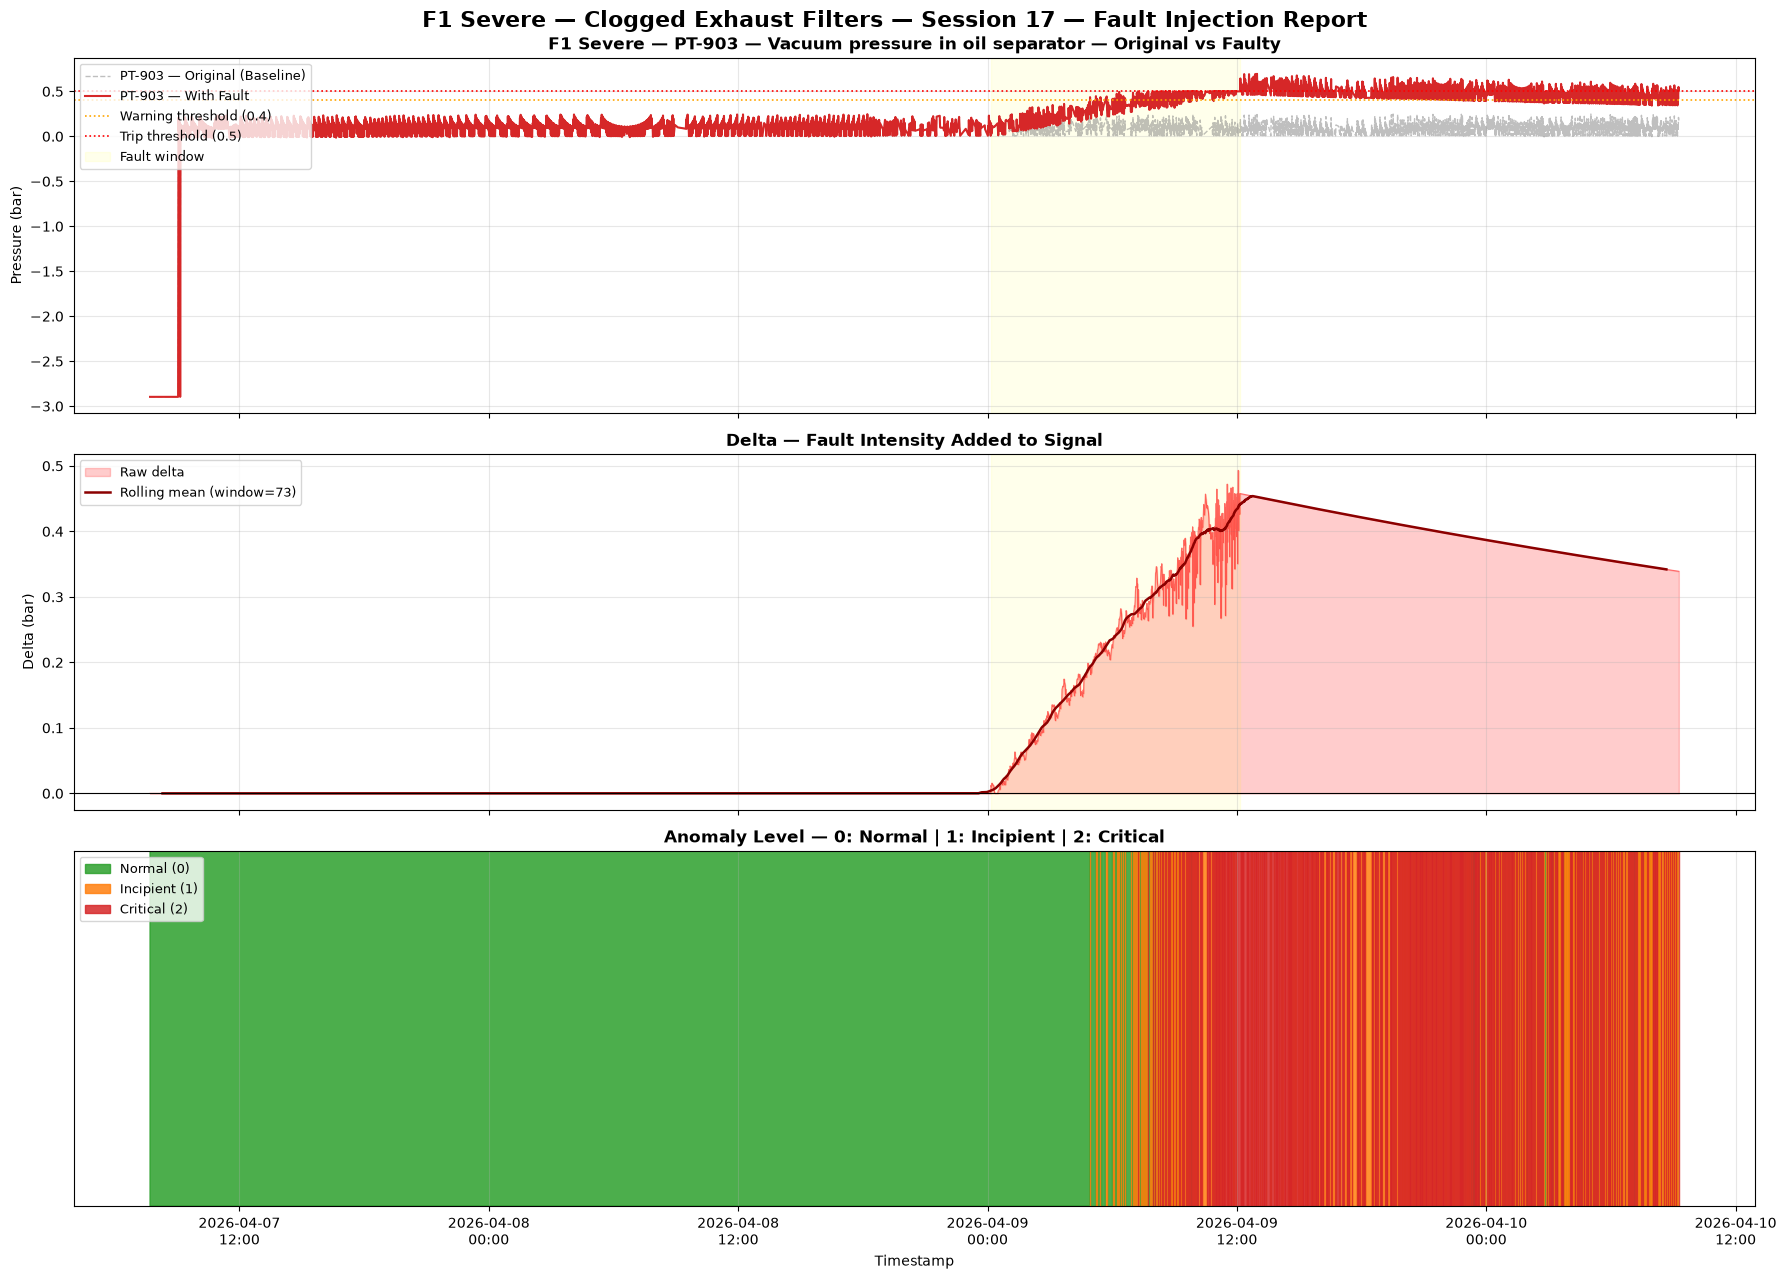

In [17]:
""" F1 Severe — Fault Profile Verification Plot — Session 17 """

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 13), sharex=True)

# ============================================================
# PANEL 1 — Original vs Faulty PT-903
# ============================================================

f1_severe_s17_fault_start_timestamp = f1_severe_s17_df.index[f1_severe_s17_start_idx]
f1_severe_s17_fault_end_timestamp = f1_severe_s17_df.index[f1_severe_s17_end_idx - 1]

ax1.plot(
    f1_severe_s17_df_orig.index,
    f1_severe_s17_df_orig["PT-903"],
    color="gray",
    alpha=0.5,
    linestyle="--",
    linewidth=1.0,
    label="PT-903 — Original (Baseline)"
)

ax1.plot(
    f1_severe_s17_df.index,
    f1_severe_s17_df["PT-903"],
    color="#d62728",
    linewidth=1.5,
    label="PT-903 — With Fault"
)

ax1.axhline(
    y=pt903_warning,
    color="orange",
    linestyle=":",
    linewidth=1.2,
    label=f"Warning threshold ({pt903_warning})"
)

ax1.axhline(
    y=pt903_trip,
    color="red",
    linestyle=":",
    linewidth=1.2,
    label=f"Trip threshold ({pt903_trip})"
)

ax1.axvspan(
    f1_severe_s17_fault_start_timestamp,
    f1_severe_s17_fault_end_timestamp,
    color="yellow",
    alpha=0.08,
    label="Fault window"
)

ax1.set_title("F1 Severe — PT-903 — Vacuum pressure in oil separator — Original vs Faulty", fontweight="bold")
ax1.set_ylabel("Pressure (bar)")
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(True, alpha=0.3)

# ============================================================
# PANEL 2 — Delta (fault intensity)
# ============================================================

f1_severe_s17_delta_full = f1_severe_s17_df["PT-903"] - f1_severe_s17_df_orig["PT-903"]
f1_severe_s17_roll_window = max(10, len(f1_severe_s17_delta_full) // 60)
f1_severe_s17_delta_rolling_mean = f1_severe_s17_delta_full.rolling(f1_severe_s17_roll_window, center=True).mean()

ax2.fill_between(
    f1_severe_s17_df.index,
    0,
    f1_severe_s17_delta_full,
    color="red",
    alpha=0.2,
    label="Raw delta"
)

ax2.plot(
    f1_severe_s17_df.index,
    f1_severe_s17_delta_full,
    color="red",
    linewidth=0.8,
    alpha=0.5
)

ax2.plot(
    f1_severe_s17_df.index,
    f1_severe_s17_delta_rolling_mean,
    color="#8B0000",
    linewidth=1.8,
    label=f"Rolling mean (window={f1_severe_s17_roll_window})"
)

ax2.axhline(y=0, color="black", linewidth=0.8)
ax2.axvspan(f1_severe_s17_fault_start_timestamp, f1_severe_s17_fault_end_timestamp, color="yellow", alpha=0.08)
ax2.set_title("Delta — Fault Intensity Added to Signal", fontweight="bold")
ax2.set_ylabel("Delta (bar)")
ax2.legend(loc="upper left", fontsize=9)
ax2.grid(True, alpha=0.3)

# ============================================================
# PANEL 3 — Anomaly level bar
# ============================================================

f1_severe_s17_normal_mask = f1_severe_s17_df["anomaly_level"] == 0
f1_severe_s17_incipient_mask = f1_severe_s17_df["anomaly_level"] == 1
f1_severe_s17_critical_mask = f1_severe_s17_df["anomaly_level"] == 2

ax3.fill_between(f1_severe_s17_df.index, 0, 1, where=f1_severe_s17_normal_mask, color="#2ca02c", step="mid", alpha=0.85, label="Normal (0)")
ax3.fill_between(f1_severe_s17_df.index, 0, 1, where=f1_severe_s17_incipient_mask, color="#ff7f0e", step="mid", alpha=0.85, label="Incipient (1)")
ax3.fill_between(f1_severe_s17_df.index, 0, 1, where=f1_severe_s17_critical_mask, color="#d62728", step="mid", alpha=0.85, label="Critical (2)")

ax3.set_yticks([])
ax3.set_ylim(0, 1)
ax3.set_xlabel("Timestamp")
ax3.set_title("Anomaly Level — 0: Normal | 1: Incipient | 2: Critical", fontweight="bold")
ax3.legend(loc="upper left", fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))

fig.suptitle("F1 Severe — Clogged Exhaust Filters — Session 17 — Fault Injection Report", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


### F2 Fault

#### Small - Session 16

In [18]:
""" F2 Small — Insufficient Cooling — Session 16 """

np.random.seed(42)

f2_small_s16_df_orig = dict_sessions[16].copy()
f2_small_s16_main_sensor = "TT-901"
f2_small_s16_length_hours = 6
f2_small_s16_start_from = 0.3

# FAULT WINDOW
f2_small_s16_session_length = len(f2_small_s16_df_orig)
f2_small_s16_start_idx = int(round(f2_small_s16_session_length * f2_small_s16_start_from))
f2_small_s16_end_idx = min(f2_small_s16_start_idx + int(round(f2_small_s16_length_hours * 60)), f2_small_s16_session_length)
f2_small_s16_total_l = f2_small_s16_end_idx - f2_small_s16_start_idx
print("Session 16 length:", f2_small_s16_session_length, "rows")
print("Fault start index:", f2_small_s16_start_idx)
print("Fault end index:", f2_small_s16_end_idx)
print("Fault window length:", f2_small_s16_total_l, "rows")

# BASELINE STATISTICS
f2_small_s16_baseline_mean = f2_small_s16_df_orig["TT-901"].iloc[:f2_small_s16_start_idx].mean()
f2_small_s16_baseline_std = f2_small_s16_df_orig["TT-901"].iloc[:f2_small_s16_start_idx].std()
print("\nTT-901 baseline mean:", round(f2_small_s16_baseline_mean, 4))
print("TT-901 baseline std:", round(f2_small_s16_baseline_std, 4))

# SEVERITY TARGET — small moves from baseline toward warning
f2_small_s16_target = f2_small_s16_baseline_mean + small_warning_fraction * (tt901_warning - f2_small_s16_baseline_mean)
f2_small_s16_delta_mag = f2_small_s16_target - f2_small_s16_baseline_mean
print("TT-901 small target:", round(f2_small_s16_target, 4))
print("TT-901 delta magnitude:", round(f2_small_s16_delta_mag, 4))

# RAW DELTA SHAPE — subtle smooth ramp
f2_small_s16_t = np.linspace(0, 1, f2_small_s16_total_l)
f2_small_s16_smoothstep = 3 * f2_small_s16_t**2 - 2 * f2_small_s16_t**3
f2_small_s16_noise_std = min(f2_small_s16_baseline_std * 0.08, abs(f2_small_s16_delta_mag) * 0.10)
f2_small_s16_noise = np.random.normal(0, f2_small_s16_noise_std, f2_small_s16_total_l)
f2_small_s16_noise = pd.Series(f2_small_s16_noise).rolling(20, center=True, min_periods=1).mean().values
f2_small_s16_delta = f2_small_s16_delta_mag * f2_small_s16_smoothstep + f2_small_s16_noise

# TARGET ALIGNMENT — keep severity ordered against the absolute target
f2_small_s16_active_values = f2_small_s16_df_orig["TT-901"].iloc[f2_small_s16_start_idx:f2_small_s16_end_idx].to_numpy()
f2_small_s16_positive_peak_idx = int(np.argmax(f2_small_s16_delta))
if True:
    f2_small_s16_delta = np.maximum(f2_small_s16_delta, 0)

if f2_small_s16_delta[f2_small_s16_positive_peak_idx] > 0:
    f2_small_s16_desired_peak_delta = f2_small_s16_target - f2_small_s16_active_values[f2_small_s16_positive_peak_idx]
    if f2_small_s16_desired_peak_delta > 0:
        f2_small_s16_delta = f2_small_s16_delta * (f2_small_s16_desired_peak_delta / f2_small_s16_delta[f2_small_s16_positive_peak_idx])

f2_small_s16_upper_delta = f2_small_s16_target - f2_small_s16_active_values
f2_small_s16_delta = np.minimum(f2_small_s16_delta, f2_small_s16_upper_delta)
if True:
    f2_small_s16_delta = np.maximum(f2_small_s16_delta, 0)

# CORRELATION COMPUTED EXPLICITLY
f2_small_s16_corr_threshold = 0.6
f2_small_s16_corr = f2_small_s16_df_orig.corr(method="pearson", numeric_only=True)["TT-901"]
f2_small_s16_corr_sensors = f2_small_s16_corr[abs(f2_small_s16_corr) >= f2_small_s16_corr_threshold].index.tolist()
print("\nCorrelated sensors (|r| >=", f2_small_s16_corr_threshold, "):", f2_small_s16_corr_sensors)

# APPLY INJECTION EXPLICITLY SENSOR BY SENSOR
f2_small_s16_df = f2_small_s16_df_orig.copy()
f2_small_s16_propagation_scale = 0.3
for sensor in f2_small_s16_corr_sensors:
    if sensor in f2_small_s16_df.columns:
        scale = 1.0 if sensor == f2_small_s16_main_sensor else f2_small_s16_propagation_scale
        f2_small_s16_df.iloc[f2_small_s16_start_idx:f2_small_s16_end_idx, f2_small_s16_df.columns.get_loc(sensor)] += f2_small_s16_delta * f2_small_s16_corr[sensor] * scale

# DECAY / STABILIZATION PHASE
f2_small_s16_remaining = f2_small_s16_session_length - f2_small_s16_end_idx
if f2_small_s16_remaining > 0:
    f2_small_s16_decay_rate = 1.2
    f2_small_s16_decay = f2_small_s16_delta[-1] * np.exp(-f2_small_s16_decay_rate * np.linspace(0, 1, f2_small_s16_remaining))
    for sensor in f2_small_s16_corr_sensors:
        if sensor in f2_small_s16_df.columns:
            scale = 1.0 if sensor == f2_small_s16_main_sensor else f2_small_s16_propagation_scale
            f2_small_s16_df.iloc[f2_small_s16_end_idx:, f2_small_s16_df.columns.get_loc(sensor)] += f2_small_s16_decay * f2_small_s16_corr[sensor] * scale


# LABELS — small faults are below warning but still injected anomalies
f2_small_s16_df["anomaly_level"] = 0
f2_small_s16_df["is_injected_anomaly"] = 0
f2_small_s16_df["anomaly_type"] = "normal"
f2_small_s16_df.iloc[f2_small_s16_start_idx:f2_small_s16_end_idx, f2_small_s16_df.columns.get_loc("anomaly_level")] = 1
f2_small_s16_df.iloc[f2_small_s16_start_idx:f2_small_s16_end_idx, f2_small_s16_df.columns.get_loc("is_injected_anomaly")] = 1
f2_small_s16_df.iloc[f2_small_s16_start_idx:f2_small_s16_end_idx, f2_small_s16_df.columns.get_loc("anomaly_type")] = "cooling_fault"

# SAVE CSV
f2_small_s16_df.to_csv(f"{output_dir_single}/session_16_F2_small.csv")
print("\nSession 16 F2 small saved")
print("Anomaly rows:", int(f2_small_s16_df["is_injected_anomaly"].sum()))
print("Normal rows:", int((f2_small_s16_df["is_injected_anomaly"] == 0).sum()))
print("Level 1 rows:", int((f2_small_s16_df["anomaly_level"] == 1).sum()))
print("Level 2 rows:", int((f2_small_s16_df["anomaly_level"] == 2).sum()))


Session 16 length: 3367 rows
Fault start index: 1010
Fault end index: 1370
Fault window length: 360 rows

TT-901 baseline mean: 61.6339
TT-901 baseline std: 3.3815
TT-901 small target: 79.9754
TT-901 delta magnitude: 18.3415

Correlated sensors (|r| >= 0.6 ): ['TT-901', 'TT-902', 'TT-903', 'TT-904']

Session 16 F2 small saved
Anomaly rows: 360
Normal rows: 3007
Level 1 rows: 360
Level 2 rows: 0


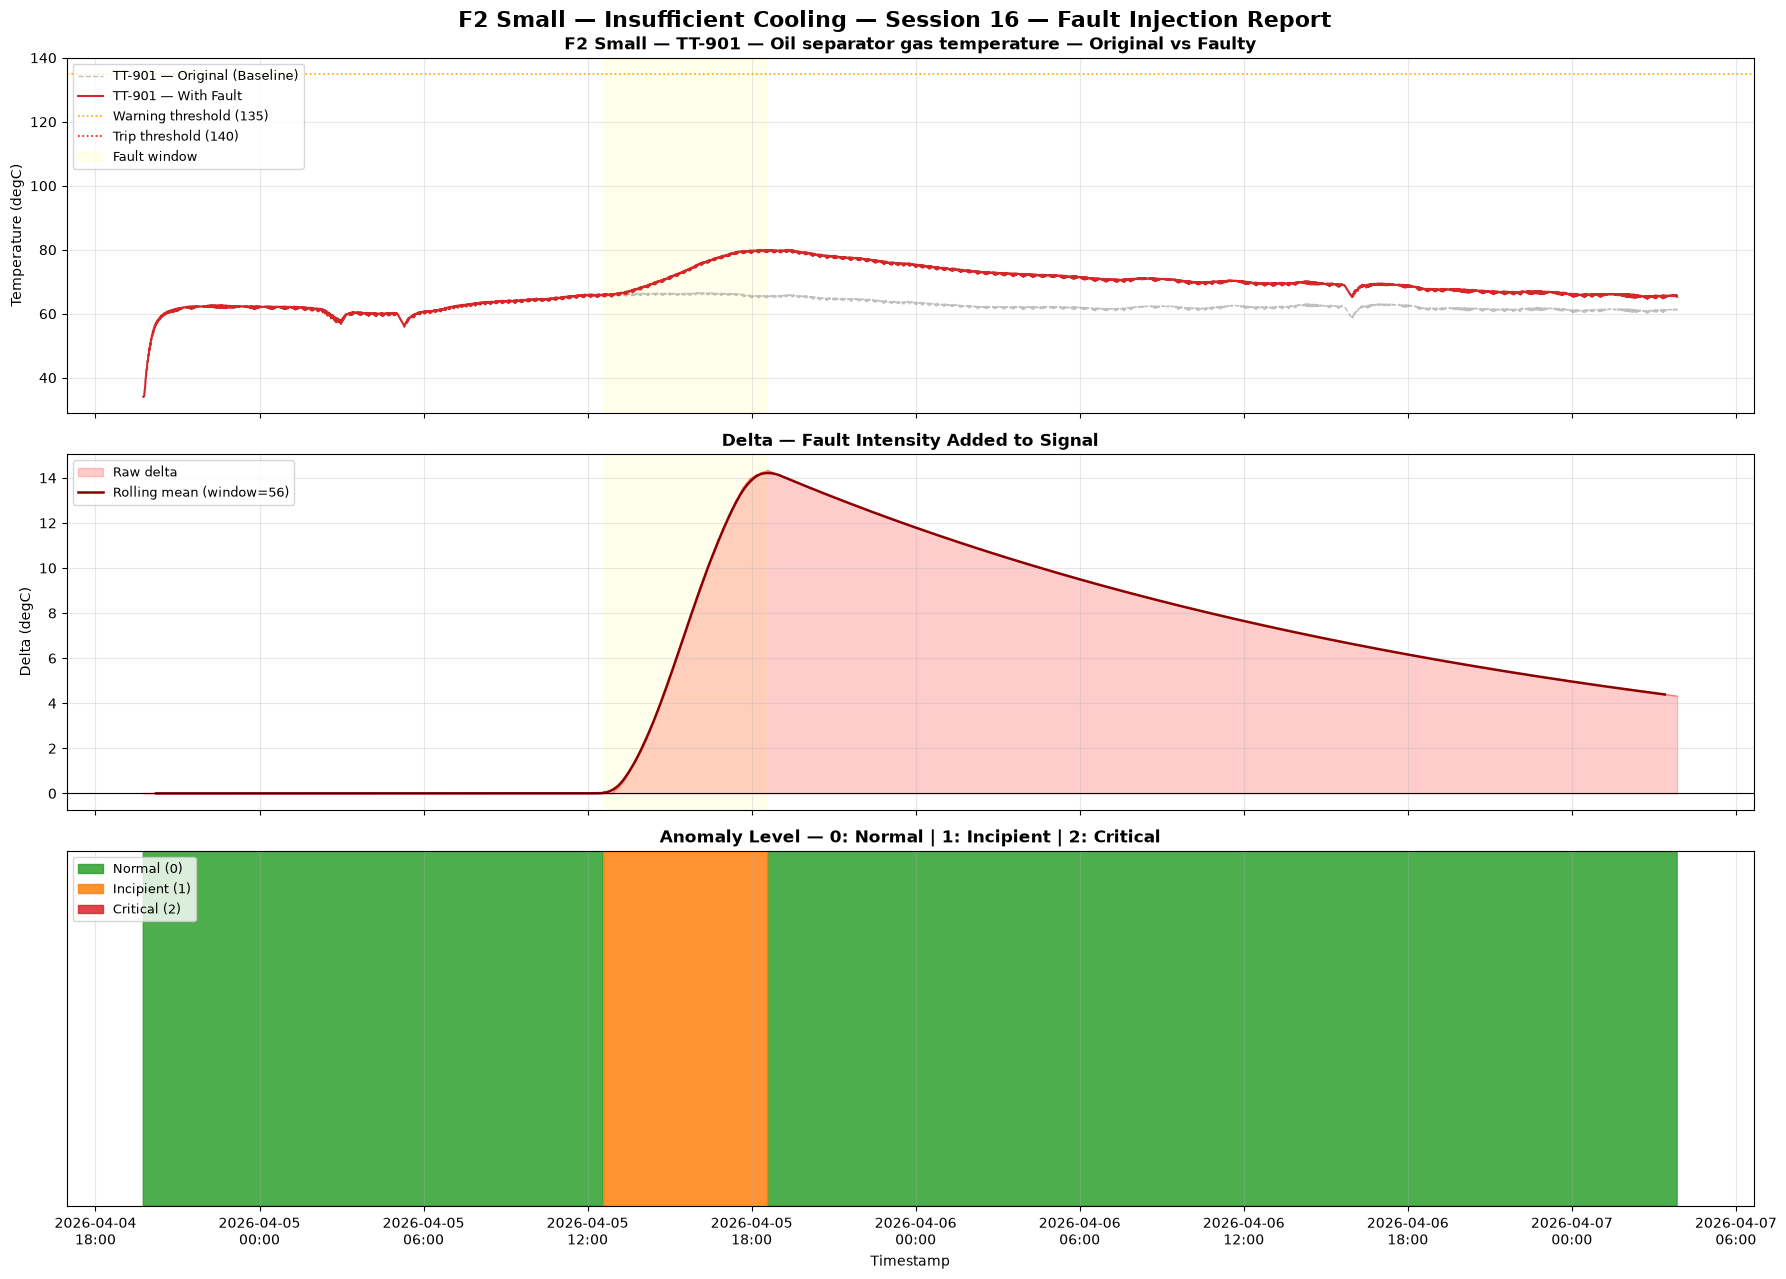

In [19]:
""" F2 Small — Fault Profile Verification Plot — Session 16 """

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 13), sharex=True)

# ============================================================
# PANEL 1 — Original vs Faulty TT-901
# ============================================================

f2_small_s16_fault_start_timestamp = f2_small_s16_df.index[f2_small_s16_start_idx]
f2_small_s16_fault_end_timestamp = f2_small_s16_df.index[f2_small_s16_end_idx - 1]

ax1.plot(
    f2_small_s16_df_orig.index,
    f2_small_s16_df_orig["TT-901"],
    color="gray",
    alpha=0.5,
    linestyle="--",
    linewidth=1.0,
    label="TT-901 — Original (Baseline)"
)

ax1.plot(
    f2_small_s16_df.index,
    f2_small_s16_df["TT-901"],
    color="#d62728",
    linewidth=1.5,
    label="TT-901 — With Fault"
)

ax1.axhline(
    y=tt901_warning,
    color="orange",
    linestyle=":",
    linewidth=1.2,
    label=f"Warning threshold ({tt901_warning})"
)

ax1.axhline(
    y=tt901_trip,
    color="red",
    linestyle=":",
    linewidth=1.2,
    label=f"Trip threshold ({tt901_trip})"
)

ax1.axvspan(
    f2_small_s16_fault_start_timestamp,
    f2_small_s16_fault_end_timestamp,
    color="yellow",
    alpha=0.08,
    label="Fault window"
)

ax1.set_title("F2 Small — TT-901 — Oil separator gas temperature — Original vs Faulty", fontweight="bold")
ax1.set_ylabel("Temperature (degC)")
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(True, alpha=0.3)

# ============================================================
# PANEL 2 — Delta (fault intensity)
# ============================================================

f2_small_s16_delta_full = f2_small_s16_df["TT-901"] - f2_small_s16_df_orig["TT-901"]
f2_small_s16_roll_window = max(10, len(f2_small_s16_delta_full) // 60)
f2_small_s16_delta_rolling_mean = f2_small_s16_delta_full.rolling(f2_small_s16_roll_window, center=True).mean()

ax2.fill_between(
    f2_small_s16_df.index,
    0,
    f2_small_s16_delta_full,
    color="red",
    alpha=0.2,
    label="Raw delta"
)

ax2.plot(
    f2_small_s16_df.index,
    f2_small_s16_delta_full,
    color="red",
    linewidth=0.8,
    alpha=0.5
)

ax2.plot(
    f2_small_s16_df.index,
    f2_small_s16_delta_rolling_mean,
    color="#8B0000",
    linewidth=1.8,
    label=f"Rolling mean (window={f2_small_s16_roll_window})"
)

ax2.axhline(y=0, color="black", linewidth=0.8)
ax2.axvspan(f2_small_s16_fault_start_timestamp, f2_small_s16_fault_end_timestamp, color="yellow", alpha=0.08)
ax2.set_title("Delta — Fault Intensity Added to Signal", fontweight="bold")
ax2.set_ylabel("Delta (degC)")
ax2.legend(loc="upper left", fontsize=9)
ax2.grid(True, alpha=0.3)

# ============================================================
# PANEL 3 — Anomaly level bar
# ============================================================

f2_small_s16_normal_mask = f2_small_s16_df["anomaly_level"] == 0
f2_small_s16_incipient_mask = f2_small_s16_df["anomaly_level"] == 1
f2_small_s16_critical_mask = f2_small_s16_df["anomaly_level"] == 2

ax3.fill_between(f2_small_s16_df.index, 0, 1, where=f2_small_s16_normal_mask, color="#2ca02c", step="mid", alpha=0.85, label="Normal (0)")
ax3.fill_between(f2_small_s16_df.index, 0, 1, where=f2_small_s16_incipient_mask, color="#ff7f0e", step="mid", alpha=0.85, label="Incipient (1)")
ax3.fill_between(f2_small_s16_df.index, 0, 1, where=f2_small_s16_critical_mask, color="#d62728", step="mid", alpha=0.85, label="Critical (2)")

ax3.set_yticks([])
ax3.set_ylim(0, 1)
ax3.set_xlabel("Timestamp")
ax3.set_title("Anomaly Level — 0: Normal | 1: Incipient | 2: Critical", fontweight="bold")
ax3.legend(loc="upper left", fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))

fig.suptitle("F2 Small — Insufficient Cooling — Session 16 — Fault Injection Report", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


#### Medium - Session 16

In [20]:
""" F2 Medium — Insufficient Cooling — Session 16 """

np.random.seed(42)

f2_medium_s16_df_orig = dict_sessions[16].copy()
f2_medium_s16_main_sensor = "TT-901"
f2_medium_s16_length_hours = 5
f2_medium_s16_start_from = 0.45

# FAULT WINDOW
f2_medium_s16_session_length = len(f2_medium_s16_df_orig)
f2_medium_s16_start_idx = int(round(f2_medium_s16_session_length * f2_medium_s16_start_from))
f2_medium_s16_end_idx = min(f2_medium_s16_start_idx + int(round(f2_medium_s16_length_hours * 60)), f2_medium_s16_session_length)
f2_medium_s16_total_l = f2_medium_s16_end_idx - f2_medium_s16_start_idx
print("Session 16 length:", f2_medium_s16_session_length, "rows")
print("Fault start index:", f2_medium_s16_start_idx)
print("Fault end index:", f2_medium_s16_end_idx)
print("Fault window length:", f2_medium_s16_total_l, "rows")

# BASELINE STATISTICS
f2_medium_s16_baseline_mean = f2_medium_s16_df_orig["TT-901"].iloc[:f2_medium_s16_start_idx].mean()
f2_medium_s16_baseline_std = f2_medium_s16_df_orig["TT-901"].iloc[:f2_medium_s16_start_idx].std()
print("\nTT-901 baseline mean:", round(f2_medium_s16_baseline_mean, 4))
print("TT-901 baseline std:", round(f2_medium_s16_baseline_std, 4))

# SEVERITY TARGET — medium reaches the warning-to-trip interval
f2_medium_s16_target = tt901_warning + medium_trip_fraction * (tt901_trip - tt901_warning)
f2_medium_s16_delta_mag = f2_medium_s16_target - f2_medium_s16_baseline_mean
print("TT-901 medium target:", round(f2_medium_s16_target, 4))
print("TT-901 delta magnitude:", round(f2_medium_s16_delta_mag, 4))

# RAW DELTA SHAPE — stochastic ramp
f2_medium_s16_trend = np.linspace(0, f2_medium_s16_delta_mag, f2_medium_s16_total_l)
f2_medium_s16_noise_start = min(f2_medium_s16_baseline_std * 0.10, abs(f2_medium_s16_delta_mag) * 0.05)
f2_medium_s16_noise_end = min(f2_medium_s16_baseline_std * 0.50, abs(f2_medium_s16_delta_mag) * 0.15)
f2_medium_s16_noise_scale = np.linspace(f2_medium_s16_noise_start, f2_medium_s16_noise_end, f2_medium_s16_total_l)
f2_medium_s16_noise = np.random.normal(0, f2_medium_s16_noise_scale, f2_medium_s16_total_l)
f2_medium_s16_raw_delta = f2_medium_s16_trend + f2_medium_s16_noise
f2_medium_s16_delta = pd.Series(f2_medium_s16_raw_delta).rolling(10, center=True, min_periods=1).mean().values

# TARGET ALIGNMENT — keep severity ordered against the absolute target
f2_medium_s16_active_values = f2_medium_s16_df_orig["TT-901"].iloc[f2_medium_s16_start_idx:f2_medium_s16_end_idx].to_numpy()
f2_medium_s16_positive_peak_idx = int(np.argmax(f2_medium_s16_delta))
if True:
    f2_medium_s16_delta = np.maximum(f2_medium_s16_delta, 0)

if f2_medium_s16_delta[f2_medium_s16_positive_peak_idx] > 0:
    f2_medium_s16_desired_peak_delta = f2_medium_s16_target - f2_medium_s16_active_values[f2_medium_s16_positive_peak_idx]
    if f2_medium_s16_desired_peak_delta > 0:
        f2_medium_s16_delta = f2_medium_s16_delta * (f2_medium_s16_desired_peak_delta / f2_medium_s16_delta[f2_medium_s16_positive_peak_idx])

f2_medium_s16_upper_delta = f2_medium_s16_target - f2_medium_s16_active_values
f2_medium_s16_delta = np.minimum(f2_medium_s16_delta, f2_medium_s16_upper_delta)
if True:
    f2_medium_s16_delta = np.maximum(f2_medium_s16_delta, 0)

# CORRELATION COMPUTED EXPLICITLY
f2_medium_s16_corr_threshold = 0.6
f2_medium_s16_corr = f2_medium_s16_df_orig.corr(method="pearson", numeric_only=True)["TT-901"]
f2_medium_s16_corr_sensors = f2_medium_s16_corr[abs(f2_medium_s16_corr) >= f2_medium_s16_corr_threshold].index.tolist()
print("\nCorrelated sensors (|r| >=", f2_medium_s16_corr_threshold, "):", f2_medium_s16_corr_sensors)

# APPLY INJECTION EXPLICITLY SENSOR BY SENSOR
f2_medium_s16_df = f2_medium_s16_df_orig.copy()
f2_medium_s16_propagation_scale = 0.3
for sensor in f2_medium_s16_corr_sensors:
    if sensor in f2_medium_s16_df.columns:
        scale = 1.0 if sensor == f2_medium_s16_main_sensor else f2_medium_s16_propagation_scale
        f2_medium_s16_df.iloc[f2_medium_s16_start_idx:f2_medium_s16_end_idx, f2_medium_s16_df.columns.get_loc(sensor)] += f2_medium_s16_delta * f2_medium_s16_corr[sensor] * scale

# DECAY / STABILIZATION PHASE
f2_medium_s16_remaining = f2_medium_s16_session_length - f2_medium_s16_end_idx
if f2_medium_s16_remaining > 0:
    f2_medium_s16_decay_rate = 0.3
    f2_medium_s16_decay = f2_medium_s16_delta[-1] * np.exp(-f2_medium_s16_decay_rate * np.linspace(0, 1, f2_medium_s16_remaining))
    for sensor in f2_medium_s16_corr_sensors:
        if sensor in f2_medium_s16_df.columns:
            scale = 1.0 if sensor == f2_medium_s16_main_sensor else f2_medium_s16_propagation_scale
            f2_medium_s16_df.iloc[f2_medium_s16_end_idx:, f2_medium_s16_df.columns.get_loc(sensor)] += f2_medium_s16_decay * f2_medium_s16_corr[sensor] * scale

# SEVERITY CAP — small/medium should not drift beyond their target during stabilization
f2_medium_s16_main_sensor_loc = f2_medium_s16_df.columns.get_loc("TT-901")
f2_medium_s16_df.iloc[f2_medium_s16_start_idx:, f2_medium_s16_main_sensor_loc] = np.minimum(
    f2_medium_s16_df.iloc[f2_medium_s16_start_idx:, f2_medium_s16_main_sensor_loc],
    f2_medium_s16_target,
)

# LABELS — medium/severe faults are labelled from injection start through stabilization
f2_medium_s16_df["anomaly_level"] = 0
f2_medium_s16_df["is_injected_anomaly"] = 0
f2_medium_s16_df["anomaly_type"] = "normal"
f2_medium_s16_injected_values = f2_medium_s16_df["TT-901"].iloc[f2_medium_s16_start_idx:]
f2_medium_s16_labels = np.where(
    f2_medium_s16_injected_values >= tt901_trip, 2,
    np.where(f2_medium_s16_injected_values >= tt901_warning, 1, 0)
)
f2_medium_s16_df.iloc[f2_medium_s16_start_idx:, f2_medium_s16_df.columns.get_loc("anomaly_level")] = f2_medium_s16_labels
f2_medium_s16_df.iloc[f2_medium_s16_start_idx:, f2_medium_s16_df.columns.get_loc("is_injected_anomaly")] = 1
f2_medium_s16_df.iloc[f2_medium_s16_start_idx:, f2_medium_s16_df.columns.get_loc("anomaly_type")] = "cooling_fault"

# SAVE CSV
f2_medium_s16_df.to_csv(f"{output_dir_single}/session_16_F2_medium.csv")
print("\nSession 16 F2 medium saved")
print("Anomaly rows:", int(f2_medium_s16_df["is_injected_anomaly"].sum()))
print("Normal rows:", int((f2_medium_s16_df["is_injected_anomaly"] == 0).sum()))
print("Level 1 rows:", int((f2_medium_s16_df["anomaly_level"] == 1).sum()))
print("Level 2 rows:", int((f2_medium_s16_df["anomaly_level"] == 2).sum()))


Session 16 length: 3367 rows
Fault start index: 1515
Fault end index: 1815
Fault window length: 300 rows

TT-901 baseline mean: 63.0318
TT-901 baseline std: 3.4083
TT-901 medium target: 137.75
TT-901 delta magnitude: 74.7182

Correlated sensors (|r| >= 0.6 ): ['TT-901', 'TT-902', 'TT-903', 'TT-904']

Session 16 F2 medium saved
Anomaly rows: 1852
Normal rows: 1515
Level 1 rows: 208
Level 2 rows: 0


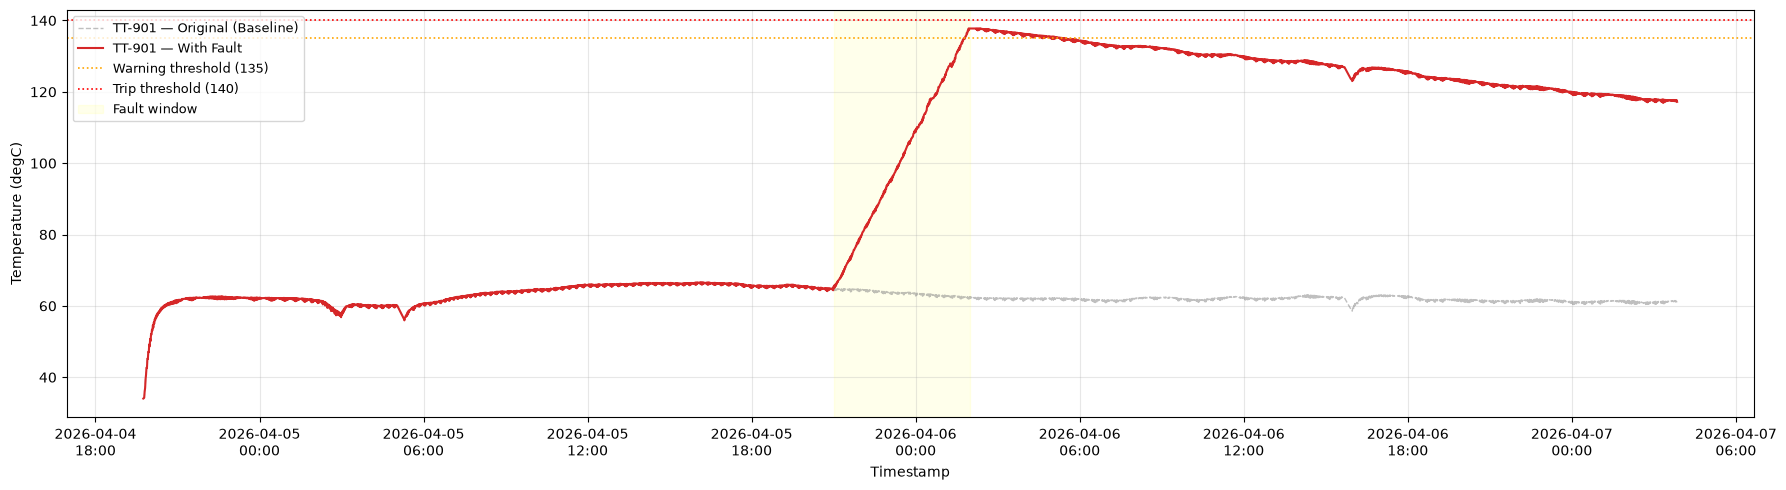

In [57]:
""" F2 Medium — Fault Profile Verification Plot — Session 16 """

fig, ax1 = plt.subplots(1, 1, figsize=(18, 5))

# ============================================================
# PANEL 1 — Original vs Faulty TT-901
# ============================================================

f2_medium_s16_fault_start_timestamp = f2_medium_s16_df.index[f2_medium_s16_start_idx]
f2_medium_s16_fault_end_timestamp = f2_medium_s16_df.index[f2_medium_s16_end_idx - 1]

ax1.plot(
    f2_medium_s16_df_orig.index,
    f2_medium_s16_df_orig["TT-901"],
    color="gray",
    alpha=0.5,
    linestyle="--",
    linewidth=1.0,
    label="TT-901 — Original (Baseline)"
)

ax1.plot(
    f2_medium_s16_df.index,
    f2_medium_s16_df["TT-901"],
    color="#d62728",
    linewidth=1.5,
    label="TT-901 — With Fault"
)

ax1.axhline(
    y=tt901_warning,
    color="orange",
    linestyle=":",
    linewidth=1.2,
    label=f"Warning threshold ({tt901_warning})"
)

ax1.axhline(
    y=tt901_trip,
    color="red",
    linestyle=":",
    linewidth=1.2,
    label=f"Trip threshold ({tt901_trip})"
)

ax1.axvspan(
    f2_medium_s16_fault_start_timestamp,
    f2_medium_s16_fault_end_timestamp,
    color="yellow",
    alpha=0.08,
    label="Fault window"
)

ax1.set_ylabel("Temperature (degC)")
ax1.set_xlabel("Timestamp")
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))

plt.tight_layout()
plt.savefig("fault_f2_medium_s16.png", dpi=200, bbox_inches="tight")
plt.show()

#### Severe - Session 16

In [22]:
""" F2 Severe — Insufficient Cooling — Session 16 """

np.random.seed(42)

f2_severe_s16_df_orig = dict_sessions[16].copy()
f2_severe_s16_main_sensor = "TT-901"
f2_severe_s16_length_hours = 8
f2_severe_s16_start_from = 0.1

# FAULT WINDOW
f2_severe_s16_session_length = len(f2_severe_s16_df_orig)
f2_severe_s16_start_idx = int(round(f2_severe_s16_session_length * f2_severe_s16_start_from))
f2_severe_s16_end_idx = min(f2_severe_s16_start_idx + int(round(f2_severe_s16_length_hours * 60)), f2_severe_s16_session_length)
f2_severe_s16_total_l = f2_severe_s16_end_idx - f2_severe_s16_start_idx
print("Session 16 length:", f2_severe_s16_session_length, "rows")
print("Fault start index:", f2_severe_s16_start_idx)
print("Fault end index:", f2_severe_s16_end_idx)
print("Fault window length:", f2_severe_s16_total_l, "rows")

# BASELINE STATISTICS
f2_severe_s16_baseline_mean = f2_severe_s16_df_orig["TT-901"].iloc[:f2_severe_s16_start_idx].mean()
f2_severe_s16_baseline_std = f2_severe_s16_df_orig["TT-901"].iloc[:f2_severe_s16_start_idx].std()
print("\nTT-901 baseline mean:", round(f2_severe_s16_baseline_mean, 4))
print("TT-901 baseline std:", round(f2_severe_s16_baseline_std, 4))

# SEVERITY TARGET — severe reaches trip level
f2_severe_s16_target = tt901_trip
f2_severe_s16_delta_mag = f2_severe_s16_target - f2_severe_s16_baseline_mean
print("TT-901 severe target:", round(f2_severe_s16_target, 4))
print("TT-901 delta magnitude:", round(f2_severe_s16_delta_mag, 4))

# RAW DELTA SHAPE — stochastic ramp
f2_severe_s16_trend = np.linspace(0, f2_severe_s16_delta_mag, f2_severe_s16_total_l)
f2_severe_s16_noise_start = min(f2_severe_s16_baseline_std * 0.10, abs(f2_severe_s16_delta_mag) * 0.05)
f2_severe_s16_noise_end = min(f2_severe_s16_baseline_std * 0.50, abs(f2_severe_s16_delta_mag) * 0.15)
f2_severe_s16_noise_scale = np.linspace(f2_severe_s16_noise_start, f2_severe_s16_noise_end, f2_severe_s16_total_l)
f2_severe_s16_noise = np.random.normal(0, f2_severe_s16_noise_scale, f2_severe_s16_total_l)
f2_severe_s16_raw_delta = f2_severe_s16_trend + f2_severe_s16_noise
f2_severe_s16_delta = pd.Series(f2_severe_s16_raw_delta).rolling(10, center=True, min_periods=1).mean().values

# TARGET ALIGNMENT — keep severity ordered against the absolute target
f2_severe_s16_active_values = f2_severe_s16_df_orig["TT-901"].iloc[f2_severe_s16_start_idx:f2_severe_s16_end_idx].to_numpy()
f2_severe_s16_positive_peak_idx = int(np.argmax(f2_severe_s16_delta))
if True:
    f2_severe_s16_delta = np.maximum(f2_severe_s16_delta, 0)

if f2_severe_s16_delta[f2_severe_s16_positive_peak_idx] > 0:
    f2_severe_s16_desired_peak_delta = f2_severe_s16_target - f2_severe_s16_active_values[f2_severe_s16_positive_peak_idx]
    if f2_severe_s16_desired_peak_delta > 0:
        f2_severe_s16_delta = f2_severe_s16_delta * (f2_severe_s16_desired_peak_delta / f2_severe_s16_delta[f2_severe_s16_positive_peak_idx])

f2_severe_s16_upper_delta = f2_severe_s16_target - f2_severe_s16_active_values
f2_severe_s16_delta = np.minimum(f2_severe_s16_delta, f2_severe_s16_upper_delta)
if True:
    f2_severe_s16_delta = np.maximum(f2_severe_s16_delta, 0)

# CORRELATION COMPUTED EXPLICITLY
f2_severe_s16_corr_threshold = 0.6
f2_severe_s16_corr = f2_severe_s16_df_orig.corr(method="pearson", numeric_only=True)["TT-901"]
f2_severe_s16_corr_sensors = f2_severe_s16_corr[abs(f2_severe_s16_corr) >= f2_severe_s16_corr_threshold].index.tolist()
print("\nCorrelated sensors (|r| >=", f2_severe_s16_corr_threshold, "):", f2_severe_s16_corr_sensors)

# APPLY INJECTION EXPLICITLY SENSOR BY SENSOR
f2_severe_s16_df = f2_severe_s16_df_orig.copy()
f2_severe_s16_propagation_scale = 0.3
for sensor in f2_severe_s16_corr_sensors:
    if sensor in f2_severe_s16_df.columns:
        scale = 1.0 if sensor == f2_severe_s16_main_sensor else f2_severe_s16_propagation_scale
        f2_severe_s16_df.iloc[f2_severe_s16_start_idx:f2_severe_s16_end_idx, f2_severe_s16_df.columns.get_loc(sensor)] += f2_severe_s16_delta * f2_severe_s16_corr[sensor] * scale

# DECAY / STABILIZATION PHASE
f2_severe_s16_remaining = f2_severe_s16_session_length - f2_severe_s16_end_idx
if f2_severe_s16_remaining > 0:
    f2_severe_s16_decay_rate = 0.3
    f2_severe_s16_decay = f2_severe_s16_delta[-1] * np.exp(-f2_severe_s16_decay_rate * np.linspace(0, 1, f2_severe_s16_remaining))
    for sensor in f2_severe_s16_corr_sensors:
        if sensor in f2_severe_s16_df.columns:
            scale = 1.0 if sensor == f2_severe_s16_main_sensor else f2_severe_s16_propagation_scale
            f2_severe_s16_df.iloc[f2_severe_s16_end_idx:, f2_severe_s16_df.columns.get_loc(sensor)] += f2_severe_s16_decay * f2_severe_s16_corr[sensor] * scale

# LABELS — medium/severe faults are labelled from injection start through stabilization
f2_severe_s16_df["anomaly_level"] = 0
f2_severe_s16_df["is_injected_anomaly"] = 0
f2_severe_s16_df["anomaly_type"] = "normal"
f2_severe_s16_injected_values = f2_severe_s16_df["TT-901"].iloc[f2_severe_s16_start_idx:]
f2_severe_s16_labels = np.where(
    f2_severe_s16_injected_values >= tt901_trip, 2,
    np.where(f2_severe_s16_injected_values >= tt901_warning, 1, 0)
)
f2_severe_s16_df.iloc[f2_severe_s16_start_idx:, f2_severe_s16_df.columns.get_loc("anomaly_level")] = f2_severe_s16_labels
f2_severe_s16_df.iloc[f2_severe_s16_start_idx:, f2_severe_s16_df.columns.get_loc("is_injected_anomaly")] = 1
f2_severe_s16_df.iloc[f2_severe_s16_start_idx:, f2_severe_s16_df.columns.get_loc("anomaly_type")] = "cooling_fault"

# SAVE CSV
f2_severe_s16_df.to_csv(f"{output_dir_single}/session_16_F2_severe.csv")
print("\nSession 16 F2 severe saved")
print("Anomaly rows:", int(f2_severe_s16_df["is_injected_anomaly"].sum()))
print("Normal rows:", int((f2_severe_s16_df["is_injected_anomaly"] == 0).sum()))
print("Level 1 rows:", int((f2_severe_s16_df["anomaly_level"] == 1).sum()))
print("Level 2 rows:", int((f2_severe_s16_df["anomaly_level"] == 2).sum()))


Session 16 length: 3367 rows
Fault start index: 337
Fault end index: 817
Fault window length: 480 rows

TT-901 baseline mean: 60.5571
TT-901 baseline std: 4.6407
TT-901 severe target: 140
TT-901 delta magnitude: 79.4429

Correlated sensors (|r| >= 0.6 ): ['TT-901', 'TT-902', 'TT-903', 'TT-904']

Session 16 F2 severe saved
Anomaly rows: 3030
Normal rows: 337
Level 1 rows: 564
Level 2 rows: 120


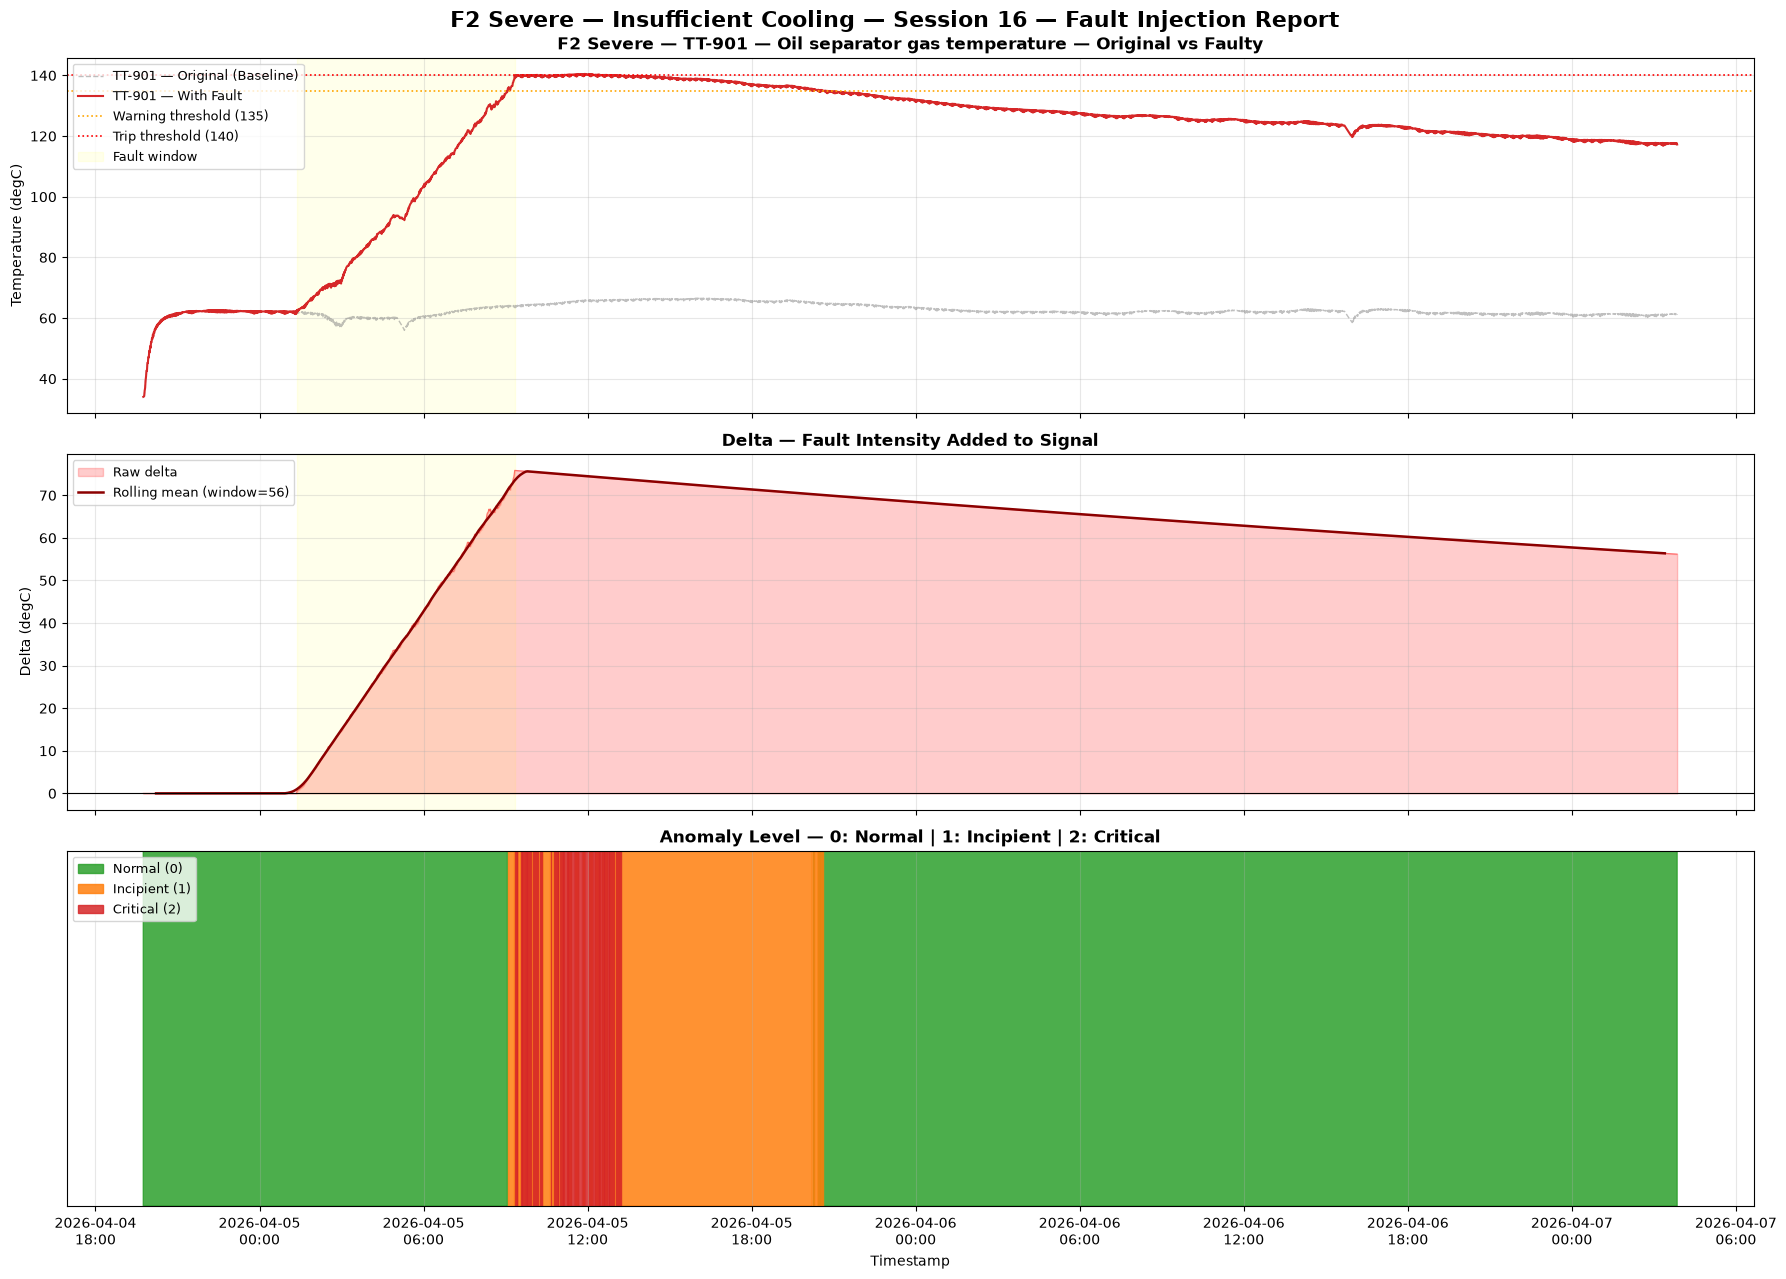

In [23]:
""" F2 Severe — Fault Profile Verification Plot — Session 16 """

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 13), sharex=True)

# ============================================================
# PANEL 1 — Original vs Faulty TT-901
# ============================================================

f2_severe_s16_fault_start_timestamp = f2_severe_s16_df.index[f2_severe_s16_start_idx]
f2_severe_s16_fault_end_timestamp = f2_severe_s16_df.index[f2_severe_s16_end_idx - 1]

ax1.plot(
    f2_severe_s16_df_orig.index,
    f2_severe_s16_df_orig["TT-901"],
    color="gray",
    alpha=0.5,
    linestyle="--",
    linewidth=1.0,
    label="TT-901 — Original (Baseline)"
)

ax1.plot(
    f2_severe_s16_df.index,
    f2_severe_s16_df["TT-901"],
    color="#d62728",
    linewidth=1.5,
    label="TT-901 — With Fault"
)

ax1.axhline(
    y=tt901_warning,
    color="orange",
    linestyle=":",
    linewidth=1.2,
    label=f"Warning threshold ({tt901_warning})"
)

ax1.axhline(
    y=tt901_trip,
    color="red",
    linestyle=":",
    linewidth=1.2,
    label=f"Trip threshold ({tt901_trip})"
)

ax1.axvspan(
    f2_severe_s16_fault_start_timestamp,
    f2_severe_s16_fault_end_timestamp,
    color="yellow",
    alpha=0.08,
    label="Fault window"
)

ax1.set_title("F2 Severe — TT-901 — Oil separator gas temperature — Original vs Faulty", fontweight="bold")
ax1.set_ylabel("Temperature (degC)")
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(True, alpha=0.3)

# ============================================================
# PANEL 2 — Delta (fault intensity)
# ============================================================

f2_severe_s16_delta_full = f2_severe_s16_df["TT-901"] - f2_severe_s16_df_orig["TT-901"]
f2_severe_s16_roll_window = max(10, len(f2_severe_s16_delta_full) // 60)
f2_severe_s16_delta_rolling_mean = f2_severe_s16_delta_full.rolling(f2_severe_s16_roll_window, center=True).mean()

ax2.fill_between(
    f2_severe_s16_df.index,
    0,
    f2_severe_s16_delta_full,
    color="red",
    alpha=0.2,
    label="Raw delta"
)

ax2.plot(
    f2_severe_s16_df.index,
    f2_severe_s16_delta_full,
    color="red",
    linewidth=0.8,
    alpha=0.5
)

ax2.plot(
    f2_severe_s16_df.index,
    f2_severe_s16_delta_rolling_mean,
    color="#8B0000",
    linewidth=1.8,
    label=f"Rolling mean (window={f2_severe_s16_roll_window})"
)

ax2.axhline(y=0, color="black", linewidth=0.8)
ax2.axvspan(f2_severe_s16_fault_start_timestamp, f2_severe_s16_fault_end_timestamp, color="yellow", alpha=0.08)
ax2.set_title("Delta — Fault Intensity Added to Signal", fontweight="bold")
ax2.set_ylabel("Delta (degC)")
ax2.legend(loc="upper left", fontsize=9)
ax2.grid(True, alpha=0.3)

# ============================================================
# PANEL 3 — Anomaly level bar
# ============================================================

f2_severe_s16_normal_mask = f2_severe_s16_df["anomaly_level"] == 0
f2_severe_s16_incipient_mask = f2_severe_s16_df["anomaly_level"] == 1
f2_severe_s16_critical_mask = f2_severe_s16_df["anomaly_level"] == 2

ax3.fill_between(f2_severe_s16_df.index, 0, 1, where=f2_severe_s16_normal_mask, color="#2ca02c", step="mid", alpha=0.85, label="Normal (0)")
ax3.fill_between(f2_severe_s16_df.index, 0, 1, where=f2_severe_s16_incipient_mask, color="#ff7f0e", step="mid", alpha=0.85, label="Incipient (1)")
ax3.fill_between(f2_severe_s16_df.index, 0, 1, where=f2_severe_s16_critical_mask, color="#d62728", step="mid", alpha=0.85, label="Critical (2)")

ax3.set_yticks([])
ax3.set_ylim(0, 1)
ax3.set_xlabel("Timestamp")
ax3.set_title("Anomaly Level — 0: Normal | 1: Incipient | 2: Critical", fontweight="bold")
ax3.legend(loc="upper left", fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))

fig.suptitle("F2 Severe — Insufficient Cooling — Session 16 — Fault Injection Report", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


#### Small - Session 17

In [24]:
""" F2 Small — Insufficient Cooling — Session 17 """

np.random.seed(42)

f2_small_s17_df_orig = dict_sessions[17].copy()
f2_small_s17_main_sensor = "TT-901"
f2_small_s17_length_hours = 6
f2_small_s17_start_from = 0.3

# FAULT WINDOW
f2_small_s17_session_length = len(f2_small_s17_df_orig)
f2_small_s17_start_idx = int(round(f2_small_s17_session_length * f2_small_s17_start_from))
f2_small_s17_end_idx = min(f2_small_s17_start_idx + int(round(f2_small_s17_length_hours * 60)), f2_small_s17_session_length)
f2_small_s17_total_l = f2_small_s17_end_idx - f2_small_s17_start_idx
print("Session 17 length:", f2_small_s17_session_length, "rows")
print("Fault start index:", f2_small_s17_start_idx)
print("Fault end index:", f2_small_s17_end_idx)
print("Fault window length:", f2_small_s17_total_l, "rows")

# BASELINE STATISTICS
f2_small_s17_baseline_mean = f2_small_s17_df_orig["TT-901"].iloc[:f2_small_s17_start_idx].mean()
f2_small_s17_baseline_std = f2_small_s17_df_orig["TT-901"].iloc[:f2_small_s17_start_idx].std()
print("\nTT-901 baseline mean:", round(f2_small_s17_baseline_mean, 4))
print("TT-901 baseline std:", round(f2_small_s17_baseline_std, 4))

# SEVERITY TARGET — small moves from baseline toward warning
f2_small_s17_target = f2_small_s17_baseline_mean + small_warning_fraction * (tt901_warning - f2_small_s17_baseline_mean)
f2_small_s17_delta_mag = f2_small_s17_target - f2_small_s17_baseline_mean
print("TT-901 small target:", round(f2_small_s17_target, 4))
print("TT-901 delta magnitude:", round(f2_small_s17_delta_mag, 4))

# RAW DELTA SHAPE — subtle smooth ramp
f2_small_s17_t = np.linspace(0, 1, f2_small_s17_total_l)
f2_small_s17_smoothstep = 3 * f2_small_s17_t**2 - 2 * f2_small_s17_t**3
f2_small_s17_noise_std = min(f2_small_s17_baseline_std * 0.08, abs(f2_small_s17_delta_mag) * 0.10)
f2_small_s17_noise = np.random.normal(0, f2_small_s17_noise_std, f2_small_s17_total_l)
f2_small_s17_noise = pd.Series(f2_small_s17_noise).rolling(20, center=True, min_periods=1).mean().values
f2_small_s17_delta = f2_small_s17_delta_mag * f2_small_s17_smoothstep + f2_small_s17_noise

# TARGET ALIGNMENT — keep severity ordered against the absolute target
f2_small_s17_active_values = f2_small_s17_df_orig["TT-901"].iloc[f2_small_s17_start_idx:f2_small_s17_end_idx].to_numpy()
f2_small_s17_positive_peak_idx = int(np.argmax(f2_small_s17_delta))
if True:
    f2_small_s17_delta = np.maximum(f2_small_s17_delta, 0)

if f2_small_s17_delta[f2_small_s17_positive_peak_idx] > 0:
    f2_small_s17_desired_peak_delta = f2_small_s17_target - f2_small_s17_active_values[f2_small_s17_positive_peak_idx]
    if f2_small_s17_desired_peak_delta > 0:
        f2_small_s17_delta = f2_small_s17_delta * (f2_small_s17_desired_peak_delta / f2_small_s17_delta[f2_small_s17_positive_peak_idx])

f2_small_s17_upper_delta = f2_small_s17_target - f2_small_s17_active_values
f2_small_s17_delta = np.minimum(f2_small_s17_delta, f2_small_s17_upper_delta)
if True:
    f2_small_s17_delta = np.maximum(f2_small_s17_delta, 0)

# CORRELATION COMPUTED EXPLICITLY
f2_small_s17_corr_threshold = 0.6
f2_small_s17_corr = f2_small_s17_df_orig.corr(method="pearson", numeric_only=True)["TT-901"]
f2_small_s17_corr_sensors = f2_small_s17_corr[abs(f2_small_s17_corr) >= f2_small_s17_corr_threshold].index.tolist()
print("\nCorrelated sensors (|r| >=", f2_small_s17_corr_threshold, "):", f2_small_s17_corr_sensors)

# APPLY INJECTION EXPLICITLY SENSOR BY SENSOR
f2_small_s17_df = f2_small_s17_df_orig.copy()
f2_small_s17_propagation_scale = 0.3
for sensor in f2_small_s17_corr_sensors:
    if sensor in f2_small_s17_df.columns:
        scale = 1.0 if sensor == f2_small_s17_main_sensor else f2_small_s17_propagation_scale
        f2_small_s17_df.iloc[f2_small_s17_start_idx:f2_small_s17_end_idx, f2_small_s17_df.columns.get_loc(sensor)] += f2_small_s17_delta * f2_small_s17_corr[sensor] * scale

# DECAY / STABILIZATION PHASE
f2_small_s17_remaining = f2_small_s17_session_length - f2_small_s17_end_idx
if f2_small_s17_remaining > 0:
    f2_small_s17_decay_rate = 1.2
    f2_small_s17_decay = f2_small_s17_delta[-1] * np.exp(-f2_small_s17_decay_rate * np.linspace(0, 1, f2_small_s17_remaining))
    for sensor in f2_small_s17_corr_sensors:
        if sensor in f2_small_s17_df.columns:
            scale = 1.0 if sensor == f2_small_s17_main_sensor else f2_small_s17_propagation_scale
            f2_small_s17_df.iloc[f2_small_s17_end_idx:, f2_small_s17_df.columns.get_loc(sensor)] += f2_small_s17_decay * f2_small_s17_corr[sensor] * scale


# LABELS — small faults are below warning but still injected anomalies
f2_small_s17_df["anomaly_level"] = 0
f2_small_s17_df["is_injected_anomaly"] = 0
f2_small_s17_df["anomaly_type"] = "normal"
f2_small_s17_df.iloc[f2_small_s17_start_idx:f2_small_s17_end_idx, f2_small_s17_df.columns.get_loc("anomaly_level")] = 1
f2_small_s17_df.iloc[f2_small_s17_start_idx:f2_small_s17_end_idx, f2_small_s17_df.columns.get_loc("is_injected_anomaly")] = 1
f2_small_s17_df.iloc[f2_small_s17_start_idx:f2_small_s17_end_idx, f2_small_s17_df.columns.get_loc("anomaly_type")] = "cooling_fault"

# SAVE CSV
f2_small_s17_df.to_csv(f"{output_dir_single}/session_17_F2_small.csv")
print("\nSession 17 F2 small saved")
print("Anomaly rows:", int(f2_small_s17_df["is_injected_anomaly"].sum()))
print("Normal rows:", int((f2_small_s17_df["is_injected_anomaly"] == 0).sum()))
print("Level 1 rows:", int((f2_small_s17_df["anomaly_level"] == 1).sum()))
print("Level 2 rows:", int((f2_small_s17_df["anomaly_level"] == 2).sum()))


Session 17 length: 4415 rows
Fault start index: 1324
Fault end index: 1684
Fault window length: 360 rows

TT-901 baseline mean: 60.8625
TT-901 baseline std: 3.5444
TT-901 small target: 79.3969
TT-901 delta magnitude: 18.5344

Correlated sensors (|r| >= 0.6 ): ['TT-901', 'TT-902', 'TT-903', 'TT-904']

Session 17 F2 small saved
Anomaly rows: 360
Normal rows: 4055
Level 1 rows: 360
Level 2 rows: 0


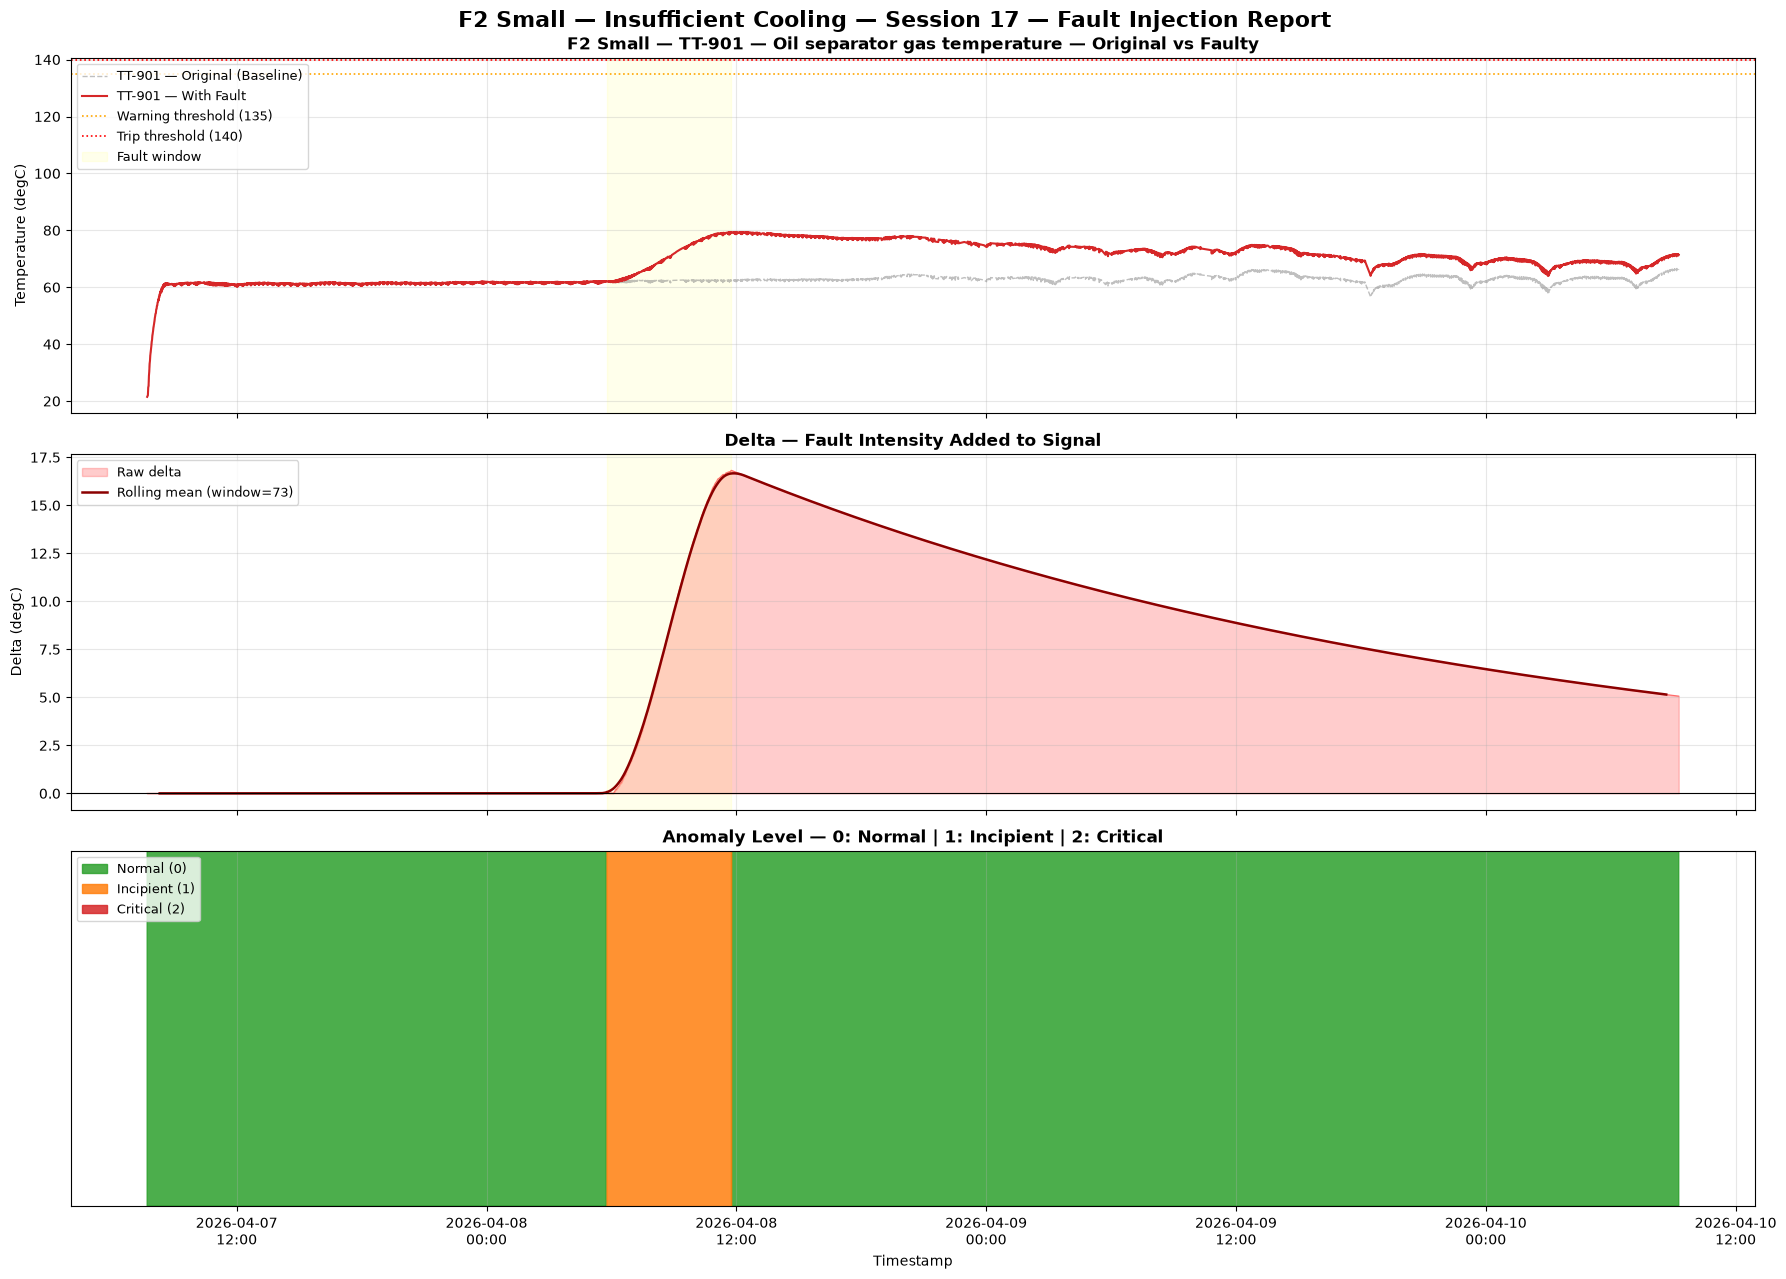

In [25]:
""" F2 Small — Fault Profile Verification Plot — Session 17 """

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 13), sharex=True)

# ============================================================
# PANEL 1 — Original vs Faulty TT-901
# ============================================================

f2_small_s17_fault_start_timestamp = f2_small_s17_df.index[f2_small_s17_start_idx]
f2_small_s17_fault_end_timestamp = f2_small_s17_df.index[f2_small_s17_end_idx - 1]

ax1.plot(
    f2_small_s17_df_orig.index,
    f2_small_s17_df_orig["TT-901"],
    color="gray",
    alpha=0.5,
    linestyle="--",
    linewidth=1.0,
    label="TT-901 — Original (Baseline)"
)

ax1.plot(
    f2_small_s17_df.index,
    f2_small_s17_df["TT-901"],
    color="#d62728",
    linewidth=1.5,
    label="TT-901 — With Fault"
)

ax1.axhline(
    y=tt901_warning,
    color="orange",
    linestyle=":",
    linewidth=1.2,
    label=f"Warning threshold ({tt901_warning})"
)

ax1.axhline(
    y=tt901_trip,
    color="red",
    linestyle=":",
    linewidth=1.2,
    label=f"Trip threshold ({tt901_trip})"
)

ax1.axvspan(
    f2_small_s17_fault_start_timestamp,
    f2_small_s17_fault_end_timestamp,
    color="yellow",
    alpha=0.08,
    label="Fault window"
)

ax1.set_title("F2 Small — TT-901 — Oil separator gas temperature — Original vs Faulty", fontweight="bold")
ax1.set_ylabel("Temperature (degC)")
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(True, alpha=0.3)

# ============================================================
# PANEL 2 — Delta (fault intensity)
# ============================================================

f2_small_s17_delta_full = f2_small_s17_df["TT-901"] - f2_small_s17_df_orig["TT-901"]
f2_small_s17_roll_window = max(10, len(f2_small_s17_delta_full) // 60)
f2_small_s17_delta_rolling_mean = f2_small_s17_delta_full.rolling(f2_small_s17_roll_window, center=True).mean()

ax2.fill_between(
    f2_small_s17_df.index,
    0,
    f2_small_s17_delta_full,
    color="red",
    alpha=0.2,
    label="Raw delta"
)

ax2.plot(
    f2_small_s17_df.index,
    f2_small_s17_delta_full,
    color="red",
    linewidth=0.8,
    alpha=0.5
)

ax2.plot(
    f2_small_s17_df.index,
    f2_small_s17_delta_rolling_mean,
    color="#8B0000",
    linewidth=1.8,
    label=f"Rolling mean (window={f2_small_s17_roll_window})"
)

ax2.axhline(y=0, color="black", linewidth=0.8)
ax2.axvspan(f2_small_s17_fault_start_timestamp, f2_small_s17_fault_end_timestamp, color="yellow", alpha=0.08)
ax2.set_title("Delta — Fault Intensity Added to Signal", fontweight="bold")
ax2.set_ylabel("Delta (degC)")
ax2.legend(loc="upper left", fontsize=9)
ax2.grid(True, alpha=0.3)

# ============================================================
# PANEL 3 — Anomaly level bar
# ============================================================

f2_small_s17_normal_mask = f2_small_s17_df["anomaly_level"] == 0
f2_small_s17_incipient_mask = f2_small_s17_df["anomaly_level"] == 1
f2_small_s17_critical_mask = f2_small_s17_df["anomaly_level"] == 2

ax3.fill_between(f2_small_s17_df.index, 0, 1, where=f2_small_s17_normal_mask, color="#2ca02c", step="mid", alpha=0.85, label="Normal (0)")
ax3.fill_between(f2_small_s17_df.index, 0, 1, where=f2_small_s17_incipient_mask, color="#ff7f0e", step="mid", alpha=0.85, label="Incipient (1)")
ax3.fill_between(f2_small_s17_df.index, 0, 1, where=f2_small_s17_critical_mask, color="#d62728", step="mid", alpha=0.85, label="Critical (2)")

ax3.set_yticks([])
ax3.set_ylim(0, 1)
ax3.set_xlabel("Timestamp")
ax3.set_title("Anomaly Level — 0: Normal | 1: Incipient | 2: Critical", fontweight="bold")
ax3.legend(loc="upper left", fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))

fig.suptitle("F2 Small — Insufficient Cooling — Session 17 — Fault Injection Report", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


#### Medium - Session 17

In [26]:
""" F2 Medium — Insufficient Cooling — Session 17 """

np.random.seed(42)

f2_medium_s17_df_orig = dict_sessions[17].copy()
f2_medium_s17_main_sensor = "TT-901"
f2_medium_s17_length_hours = 5
f2_medium_s17_start_from = 0.45

# FAULT WINDOW
f2_medium_s17_session_length = len(f2_medium_s17_df_orig)
f2_medium_s17_start_idx = int(round(f2_medium_s17_session_length * f2_medium_s17_start_from))
f2_medium_s17_end_idx = min(f2_medium_s17_start_idx + int(round(f2_medium_s17_length_hours * 60)), f2_medium_s17_session_length)
f2_medium_s17_total_l = f2_medium_s17_end_idx - f2_medium_s17_start_idx
print("Session 17 length:", f2_medium_s17_session_length, "rows")
print("Fault start index:", f2_medium_s17_start_idx)
print("Fault end index:", f2_medium_s17_end_idx)
print("Fault window length:", f2_medium_s17_total_l, "rows")

# BASELINE STATISTICS
f2_medium_s17_baseline_mean = f2_medium_s17_df_orig["TT-901"].iloc[:f2_medium_s17_start_idx].mean()
f2_medium_s17_baseline_std = f2_medium_s17_df_orig["TT-901"].iloc[:f2_medium_s17_start_idx].std()
print("\nTT-901 baseline mean:", round(f2_medium_s17_baseline_mean, 4))
print("TT-901 baseline std:", round(f2_medium_s17_baseline_std, 4))

# SEVERITY TARGET — medium reaches the warning-to-trip interval
f2_medium_s17_target = tt901_warning + medium_trip_fraction * (tt901_trip - tt901_warning)
f2_medium_s17_delta_mag = f2_medium_s17_target - f2_medium_s17_baseline_mean
print("TT-901 medium target:", round(f2_medium_s17_target, 4))
print("TT-901 delta magnitude:", round(f2_medium_s17_delta_mag, 4))

# RAW DELTA SHAPE — stochastic ramp
f2_medium_s17_trend = np.linspace(0, f2_medium_s17_delta_mag, f2_medium_s17_total_l)
f2_medium_s17_noise_start = min(f2_medium_s17_baseline_std * 0.10, abs(f2_medium_s17_delta_mag) * 0.05)
f2_medium_s17_noise_end = min(f2_medium_s17_baseline_std * 0.50, abs(f2_medium_s17_delta_mag) * 0.15)
f2_medium_s17_noise_scale = np.linspace(f2_medium_s17_noise_start, f2_medium_s17_noise_end, f2_medium_s17_total_l)
f2_medium_s17_noise = np.random.normal(0, f2_medium_s17_noise_scale, f2_medium_s17_total_l)
f2_medium_s17_raw_delta = f2_medium_s17_trend + f2_medium_s17_noise
f2_medium_s17_delta = pd.Series(f2_medium_s17_raw_delta).rolling(10, center=True, min_periods=1).mean().values

# TARGET ALIGNMENT — keep severity ordered against the absolute target
f2_medium_s17_active_values = f2_medium_s17_df_orig["TT-901"].iloc[f2_medium_s17_start_idx:f2_medium_s17_end_idx].to_numpy()
f2_medium_s17_positive_peak_idx = int(np.argmax(f2_medium_s17_delta))
if True:
    f2_medium_s17_delta = np.maximum(f2_medium_s17_delta, 0)

if f2_medium_s17_delta[f2_medium_s17_positive_peak_idx] > 0:
    f2_medium_s17_desired_peak_delta = f2_medium_s17_target - f2_medium_s17_active_values[f2_medium_s17_positive_peak_idx]
    if f2_medium_s17_desired_peak_delta > 0:
        f2_medium_s17_delta = f2_medium_s17_delta * (f2_medium_s17_desired_peak_delta / f2_medium_s17_delta[f2_medium_s17_positive_peak_idx])

f2_medium_s17_upper_delta = f2_medium_s17_target - f2_medium_s17_active_values
f2_medium_s17_delta = np.minimum(f2_medium_s17_delta, f2_medium_s17_upper_delta)
if True:
    f2_medium_s17_delta = np.maximum(f2_medium_s17_delta, 0)

# CORRELATION COMPUTED EXPLICITLY
f2_medium_s17_corr_threshold = 0.6
f2_medium_s17_corr = f2_medium_s17_df_orig.corr(method="pearson", numeric_only=True)["TT-901"]
f2_medium_s17_corr_sensors = f2_medium_s17_corr[abs(f2_medium_s17_corr) >= f2_medium_s17_corr_threshold].index.tolist()
print("\nCorrelated sensors (|r| >=", f2_medium_s17_corr_threshold, "):", f2_medium_s17_corr_sensors)

# APPLY INJECTION EXPLICITLY SENSOR BY SENSOR
f2_medium_s17_df = f2_medium_s17_df_orig.copy()
f2_medium_s17_propagation_scale = 0.3
for sensor in f2_medium_s17_corr_sensors:
    if sensor in f2_medium_s17_df.columns:
        scale = 1.0 if sensor == f2_medium_s17_main_sensor else f2_medium_s17_propagation_scale
        f2_medium_s17_df.iloc[f2_medium_s17_start_idx:f2_medium_s17_end_idx, f2_medium_s17_df.columns.get_loc(sensor)] += f2_medium_s17_delta * f2_medium_s17_corr[sensor] * scale

# DECAY / STABILIZATION PHASE
f2_medium_s17_remaining = f2_medium_s17_session_length - f2_medium_s17_end_idx
if f2_medium_s17_remaining > 0:
    f2_medium_s17_decay_rate = 0.3
    f2_medium_s17_decay = f2_medium_s17_delta[-1] * np.exp(-f2_medium_s17_decay_rate * np.linspace(0, 1, f2_medium_s17_remaining))
    for sensor in f2_medium_s17_corr_sensors:
        if sensor in f2_medium_s17_df.columns:
            scale = 1.0 if sensor == f2_medium_s17_main_sensor else f2_medium_s17_propagation_scale
            f2_medium_s17_df.iloc[f2_medium_s17_end_idx:, f2_medium_s17_df.columns.get_loc(sensor)] += f2_medium_s17_decay * f2_medium_s17_corr[sensor] * scale

# SEVERITY CAP — small/medium should not drift beyond their target during stabilization
f2_medium_s17_main_sensor_loc = f2_medium_s17_df.columns.get_loc("TT-901")
f2_medium_s17_df.iloc[f2_medium_s17_start_idx:, f2_medium_s17_main_sensor_loc] = np.minimum(
    f2_medium_s17_df.iloc[f2_medium_s17_start_idx:, f2_medium_s17_main_sensor_loc],
    f2_medium_s17_target,
)

# LABELS — medium/severe faults are labelled from injection start through stabilization
f2_medium_s17_df["anomaly_level"] = 0
f2_medium_s17_df["is_injected_anomaly"] = 0
f2_medium_s17_df["anomaly_type"] = "normal"
f2_medium_s17_injected_values = f2_medium_s17_df["TT-901"].iloc[f2_medium_s17_start_idx:]
f2_medium_s17_labels = np.where(
    f2_medium_s17_injected_values >= tt901_trip, 2,
    np.where(f2_medium_s17_injected_values >= tt901_warning, 1, 0)
)
f2_medium_s17_df.iloc[f2_medium_s17_start_idx:, f2_medium_s17_df.columns.get_loc("anomaly_level")] = f2_medium_s17_labels
f2_medium_s17_df.iloc[f2_medium_s17_start_idx:, f2_medium_s17_df.columns.get_loc("is_injected_anomaly")] = 1
f2_medium_s17_df.iloc[f2_medium_s17_start_idx:, f2_medium_s17_df.columns.get_loc("anomaly_type")] = "cooling_fault"

# SAVE CSV
f2_medium_s17_df.to_csv(f"{output_dir_single}/session_17_F2_medium.csv")
print("\nSession 17 F2 medium saved")
print("Anomaly rows:", int(f2_medium_s17_df["is_injected_anomaly"].sum()))
print("Normal rows:", int((f2_medium_s17_df["is_injected_anomaly"] == 0).sum()))
print("Level 1 rows:", int((f2_medium_s17_df["anomaly_level"] == 1).sum()))
print("Level 2 rows:", int((f2_medium_s17_df["anomaly_level"] == 2).sum()))


Session 17 length: 4415 rows
Fault start index: 1987
Fault end index: 2287
Fault window length: 300 rows

TT-901 baseline mean: 61.374
TT-901 baseline std: 2.988
TT-901 medium target: 137.75
TT-901 delta magnitude: 76.376

Correlated sensors (|r| >= 0.6 ): ['TT-901', 'TT-902', 'TT-903', 'TT-904']

Session 17 F2 medium saved
Anomaly rows: 2428
Normal rows: 1987
Level 1 rows: 227
Level 2 rows: 0


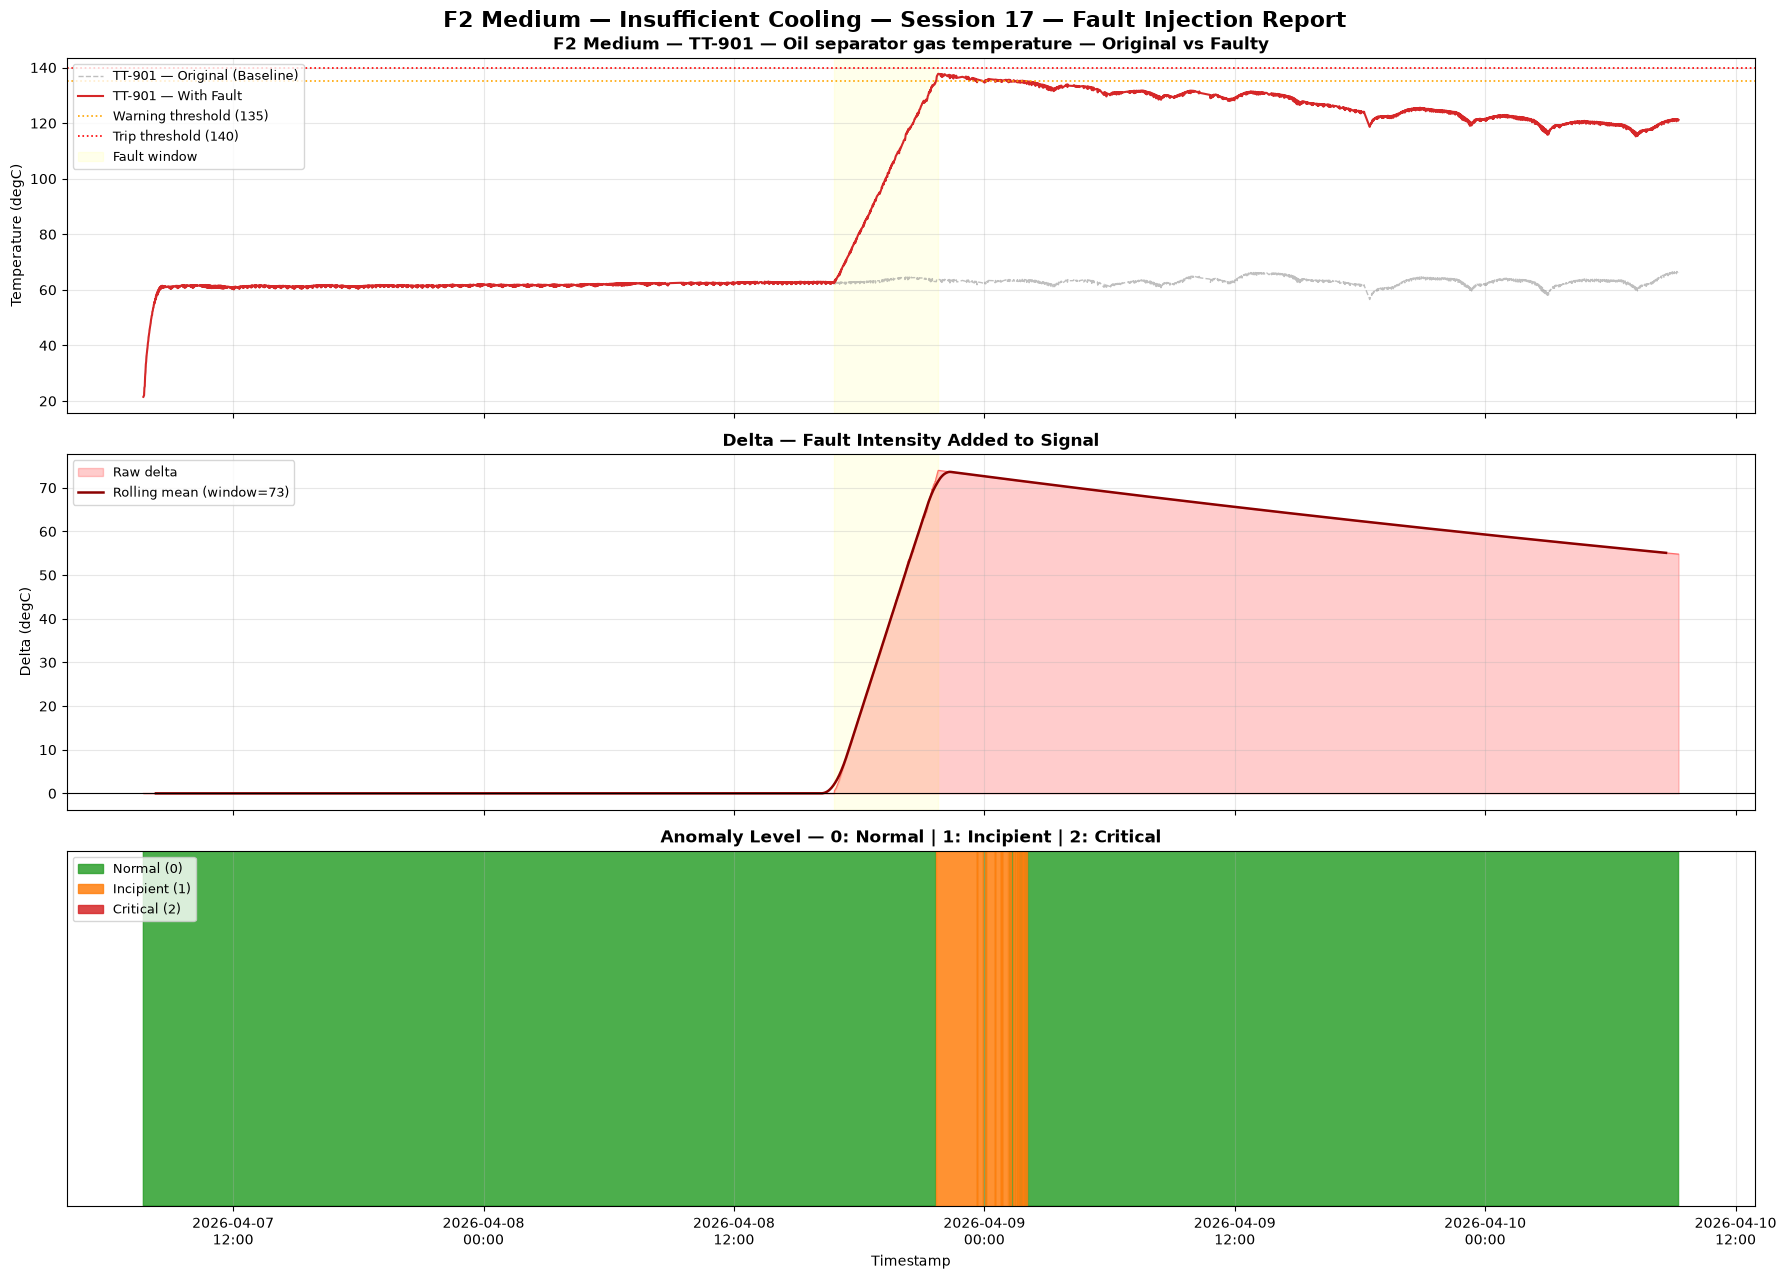

In [27]:
""" F2 Medium — Fault Profile Verification Plot — Session 17 """

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 13), sharex=True)

# ============================================================
# PANEL 1 — Original vs Faulty TT-901
# ============================================================

f2_medium_s17_fault_start_timestamp = f2_medium_s17_df.index[f2_medium_s17_start_idx]
f2_medium_s17_fault_end_timestamp = f2_medium_s17_df.index[f2_medium_s17_end_idx - 1]

ax1.plot(
    f2_medium_s17_df_orig.index,
    f2_medium_s17_df_orig["TT-901"],
    color="gray",
    alpha=0.5,
    linestyle="--",
    linewidth=1.0,
    label="TT-901 — Original (Baseline)"
)

ax1.plot(
    f2_medium_s17_df.index,
    f2_medium_s17_df["TT-901"],
    color="#d62728",
    linewidth=1.5,
    label="TT-901 — With Fault"
)

ax1.axhline(
    y=tt901_warning,
    color="orange",
    linestyle=":",
    linewidth=1.2,
    label=f"Warning threshold ({tt901_warning})"
)

ax1.axhline(
    y=tt901_trip,
    color="red",
    linestyle=":",
    linewidth=1.2,
    label=f"Trip threshold ({tt901_trip})"
)

ax1.axvspan(
    f2_medium_s17_fault_start_timestamp,
    f2_medium_s17_fault_end_timestamp,
    color="yellow",
    alpha=0.08,
    label="Fault window"
)

ax1.set_title("F2 Medium — TT-901 — Oil separator gas temperature — Original vs Faulty", fontweight="bold")
ax1.set_ylabel("Temperature (degC)")
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(True, alpha=0.3)

# ============================================================
# PANEL 2 — Delta (fault intensity)
# ============================================================

f2_medium_s17_delta_full = f2_medium_s17_df["TT-901"] - f2_medium_s17_df_orig["TT-901"]
f2_medium_s17_roll_window = max(10, len(f2_medium_s17_delta_full) // 60)
f2_medium_s17_delta_rolling_mean = f2_medium_s17_delta_full.rolling(f2_medium_s17_roll_window, center=True).mean()

ax2.fill_between(
    f2_medium_s17_df.index,
    0,
    f2_medium_s17_delta_full,
    color="red",
    alpha=0.2,
    label="Raw delta"
)

ax2.plot(
    f2_medium_s17_df.index,
    f2_medium_s17_delta_full,
    color="red",
    linewidth=0.8,
    alpha=0.5
)

ax2.plot(
    f2_medium_s17_df.index,
    f2_medium_s17_delta_rolling_mean,
    color="#8B0000",
    linewidth=1.8,
    label=f"Rolling mean (window={f2_medium_s17_roll_window})"
)

ax2.axhline(y=0, color="black", linewidth=0.8)
ax2.axvspan(f2_medium_s17_fault_start_timestamp, f2_medium_s17_fault_end_timestamp, color="yellow", alpha=0.08)
ax2.set_title("Delta — Fault Intensity Added to Signal", fontweight="bold")
ax2.set_ylabel("Delta (degC)")
ax2.legend(loc="upper left", fontsize=9)
ax2.grid(True, alpha=0.3)

# ============================================================
# PANEL 3 — Anomaly level bar
# ============================================================

f2_medium_s17_normal_mask = f2_medium_s17_df["anomaly_level"] == 0
f2_medium_s17_incipient_mask = f2_medium_s17_df["anomaly_level"] == 1
f2_medium_s17_critical_mask = f2_medium_s17_df["anomaly_level"] == 2

ax3.fill_between(f2_medium_s17_df.index, 0, 1, where=f2_medium_s17_normal_mask, color="#2ca02c", step="mid", alpha=0.85, label="Normal (0)")
ax3.fill_between(f2_medium_s17_df.index, 0, 1, where=f2_medium_s17_incipient_mask, color="#ff7f0e", step="mid", alpha=0.85, label="Incipient (1)")
ax3.fill_between(f2_medium_s17_df.index, 0, 1, where=f2_medium_s17_critical_mask, color="#d62728", step="mid", alpha=0.85, label="Critical (2)")

ax3.set_yticks([])
ax3.set_ylim(0, 1)
ax3.set_xlabel("Timestamp")
ax3.set_title("Anomaly Level — 0: Normal | 1: Incipient | 2: Critical", fontweight="bold")
ax3.legend(loc="upper left", fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))

fig.suptitle("F2 Medium — Insufficient Cooling — Session 17 — Fault Injection Report", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


#### Severe - Session 17

In [28]:
""" F2 Severe — Insufficient Cooling — Session 17 """

np.random.seed(42)

f2_severe_s17_df_orig = dict_sessions[17].copy()
f2_severe_s17_main_sensor = "TT-901"
f2_severe_s17_length_hours = 8
f2_severe_s17_start_from = 0.1

# FAULT WINDOW
f2_severe_s17_session_length = len(f2_severe_s17_df_orig)
f2_severe_s17_start_idx = int(round(f2_severe_s17_session_length * f2_severe_s17_start_from))
f2_severe_s17_end_idx = min(f2_severe_s17_start_idx + int(round(f2_severe_s17_length_hours * 60)), f2_severe_s17_session_length)
f2_severe_s17_total_l = f2_severe_s17_end_idx - f2_severe_s17_start_idx
print("Session 17 length:", f2_severe_s17_session_length, "rows")
print("Fault start index:", f2_severe_s17_start_idx)
print("Fault end index:", f2_severe_s17_end_idx)
print("Fault window length:", f2_severe_s17_total_l, "rows")

# BASELINE STATISTICS
f2_severe_s17_baseline_mean = f2_severe_s17_df_orig["TT-901"].iloc[:f2_severe_s17_start_idx].mean()
f2_severe_s17_baseline_std = f2_severe_s17_df_orig["TT-901"].iloc[:f2_severe_s17_start_idx].std()
print("\nTT-901 baseline mean:", round(f2_severe_s17_baseline_mean, 4))
print("TT-901 baseline std:", round(f2_severe_s17_baseline_std, 4))

# SEVERITY TARGET — severe reaches trip level
f2_severe_s17_target = tt901_trip
f2_severe_s17_delta_mag = f2_severe_s17_target - f2_severe_s17_baseline_mean
print("TT-901 severe target:", round(f2_severe_s17_target, 4))
print("TT-901 delta magnitude:", round(f2_severe_s17_delta_mag, 4))

# RAW DELTA SHAPE — stochastic ramp
f2_severe_s17_trend = np.linspace(0, f2_severe_s17_delta_mag, f2_severe_s17_total_l)
f2_severe_s17_noise_start = min(f2_severe_s17_baseline_std * 0.10, abs(f2_severe_s17_delta_mag) * 0.05)
f2_severe_s17_noise_end = min(f2_severe_s17_baseline_std * 0.50, abs(f2_severe_s17_delta_mag) * 0.15)
f2_severe_s17_noise_scale = np.linspace(f2_severe_s17_noise_start, f2_severe_s17_noise_end, f2_severe_s17_total_l)
f2_severe_s17_noise = np.random.normal(0, f2_severe_s17_noise_scale, f2_severe_s17_total_l)
f2_severe_s17_raw_delta = f2_severe_s17_trend + f2_severe_s17_noise
f2_severe_s17_delta = pd.Series(f2_severe_s17_raw_delta).rolling(10, center=True, min_periods=1).mean().values

# TARGET ALIGNMENT — keep severity ordered against the absolute target
f2_severe_s17_active_values = f2_severe_s17_df_orig["TT-901"].iloc[f2_severe_s17_start_idx:f2_severe_s17_end_idx].to_numpy()
f2_severe_s17_positive_peak_idx = int(np.argmax(f2_severe_s17_delta))
if True:
    f2_severe_s17_delta = np.maximum(f2_severe_s17_delta, 0)

if f2_severe_s17_delta[f2_severe_s17_positive_peak_idx] > 0:
    f2_severe_s17_desired_peak_delta = f2_severe_s17_target - f2_severe_s17_active_values[f2_severe_s17_positive_peak_idx]
    if f2_severe_s17_desired_peak_delta > 0:
        f2_severe_s17_delta = f2_severe_s17_delta * (f2_severe_s17_desired_peak_delta / f2_severe_s17_delta[f2_severe_s17_positive_peak_idx])

f2_severe_s17_upper_delta = f2_severe_s17_target - f2_severe_s17_active_values
f2_severe_s17_delta = np.minimum(f2_severe_s17_delta, f2_severe_s17_upper_delta)
if True:
    f2_severe_s17_delta = np.maximum(f2_severe_s17_delta, 0)

# CORRELATION COMPUTED EXPLICITLY
f2_severe_s17_corr_threshold = 0.6
f2_severe_s17_corr = f2_severe_s17_df_orig.corr(method="pearson", numeric_only=True)["TT-901"]
f2_severe_s17_corr_sensors = f2_severe_s17_corr[abs(f2_severe_s17_corr) >= f2_severe_s17_corr_threshold].index.tolist()
print("\nCorrelated sensors (|r| >=", f2_severe_s17_corr_threshold, "):", f2_severe_s17_corr_sensors)

# APPLY INJECTION EXPLICITLY SENSOR BY SENSOR
f2_severe_s17_df = f2_severe_s17_df_orig.copy()
f2_severe_s17_propagation_scale = 0.3
for sensor in f2_severe_s17_corr_sensors:
    if sensor in f2_severe_s17_df.columns:
        scale = 1.0 if sensor == f2_severe_s17_main_sensor else f2_severe_s17_propagation_scale
        f2_severe_s17_df.iloc[f2_severe_s17_start_idx:f2_severe_s17_end_idx, f2_severe_s17_df.columns.get_loc(sensor)] += f2_severe_s17_delta * f2_severe_s17_corr[sensor] * scale

# DECAY / STABILIZATION PHASE
f2_severe_s17_remaining = f2_severe_s17_session_length - f2_severe_s17_end_idx
if f2_severe_s17_remaining > 0:
    f2_severe_s17_decay_rate = 0.3
    f2_severe_s17_decay = f2_severe_s17_delta[-1] * np.exp(-f2_severe_s17_decay_rate * np.linspace(0, 1, f2_severe_s17_remaining))
    for sensor in f2_severe_s17_corr_sensors:
        if sensor in f2_severe_s17_df.columns:
            scale = 1.0 if sensor == f2_severe_s17_main_sensor else f2_severe_s17_propagation_scale
            f2_severe_s17_df.iloc[f2_severe_s17_end_idx:, f2_severe_s17_df.columns.get_loc(sensor)] += f2_severe_s17_decay * f2_severe_s17_corr[sensor] * scale

# LABELS — medium/severe faults are labelled from injection start through stabilization
f2_severe_s17_df["anomaly_level"] = 0
f2_severe_s17_df["is_injected_anomaly"] = 0
f2_severe_s17_df["anomaly_type"] = "normal"
f2_severe_s17_injected_values = f2_severe_s17_df["TT-901"].iloc[f2_severe_s17_start_idx:]
f2_severe_s17_labels = np.where(
    f2_severe_s17_injected_values >= tt901_trip, 2,
    np.where(f2_severe_s17_injected_values >= tt901_warning, 1, 0)
)
f2_severe_s17_df.iloc[f2_severe_s17_start_idx:, f2_severe_s17_df.columns.get_loc("anomaly_level")] = f2_severe_s17_labels
f2_severe_s17_df.iloc[f2_severe_s17_start_idx:, f2_severe_s17_df.columns.get_loc("is_injected_anomaly")] = 1
f2_severe_s17_df.iloc[f2_severe_s17_start_idx:, f2_severe_s17_df.columns.get_loc("anomaly_type")] = "cooling_fault"

# SAVE CSV
f2_severe_s17_df.to_csv(f"{output_dir_single}/session_17_F2_severe.csv")
print("\nSession 17 F2 severe saved")
print("Anomaly rows:", int(f2_severe_s17_df["is_injected_anomaly"].sum()))
print("Normal rows:", int((f2_severe_s17_df["is_injected_anomaly"] == 0).sum()))
print("Level 1 rows:", int((f2_severe_s17_df["anomaly_level"] == 1).sum()))
print("Level 2 rows:", int((f2_severe_s17_df["anomaly_level"] == 2).sum()))


Session 17 length: 4415 rows
Fault start index: 442
Fault end index: 922
Fault window length: 480 rows

TT-901 baseline mean: 59.6093
TT-901 baseline std: 5.9252
TT-901 severe target: 140
TT-901 delta magnitude: 80.3907

Correlated sensors (|r| >= 0.6 ): ['TT-901', 'TT-902', 'TT-903', 'TT-904']

Session 17 F2 severe saved
Anomaly rows: 3973
Normal rows: 442
Level 1 rows: 910
Level 2 rows: 1


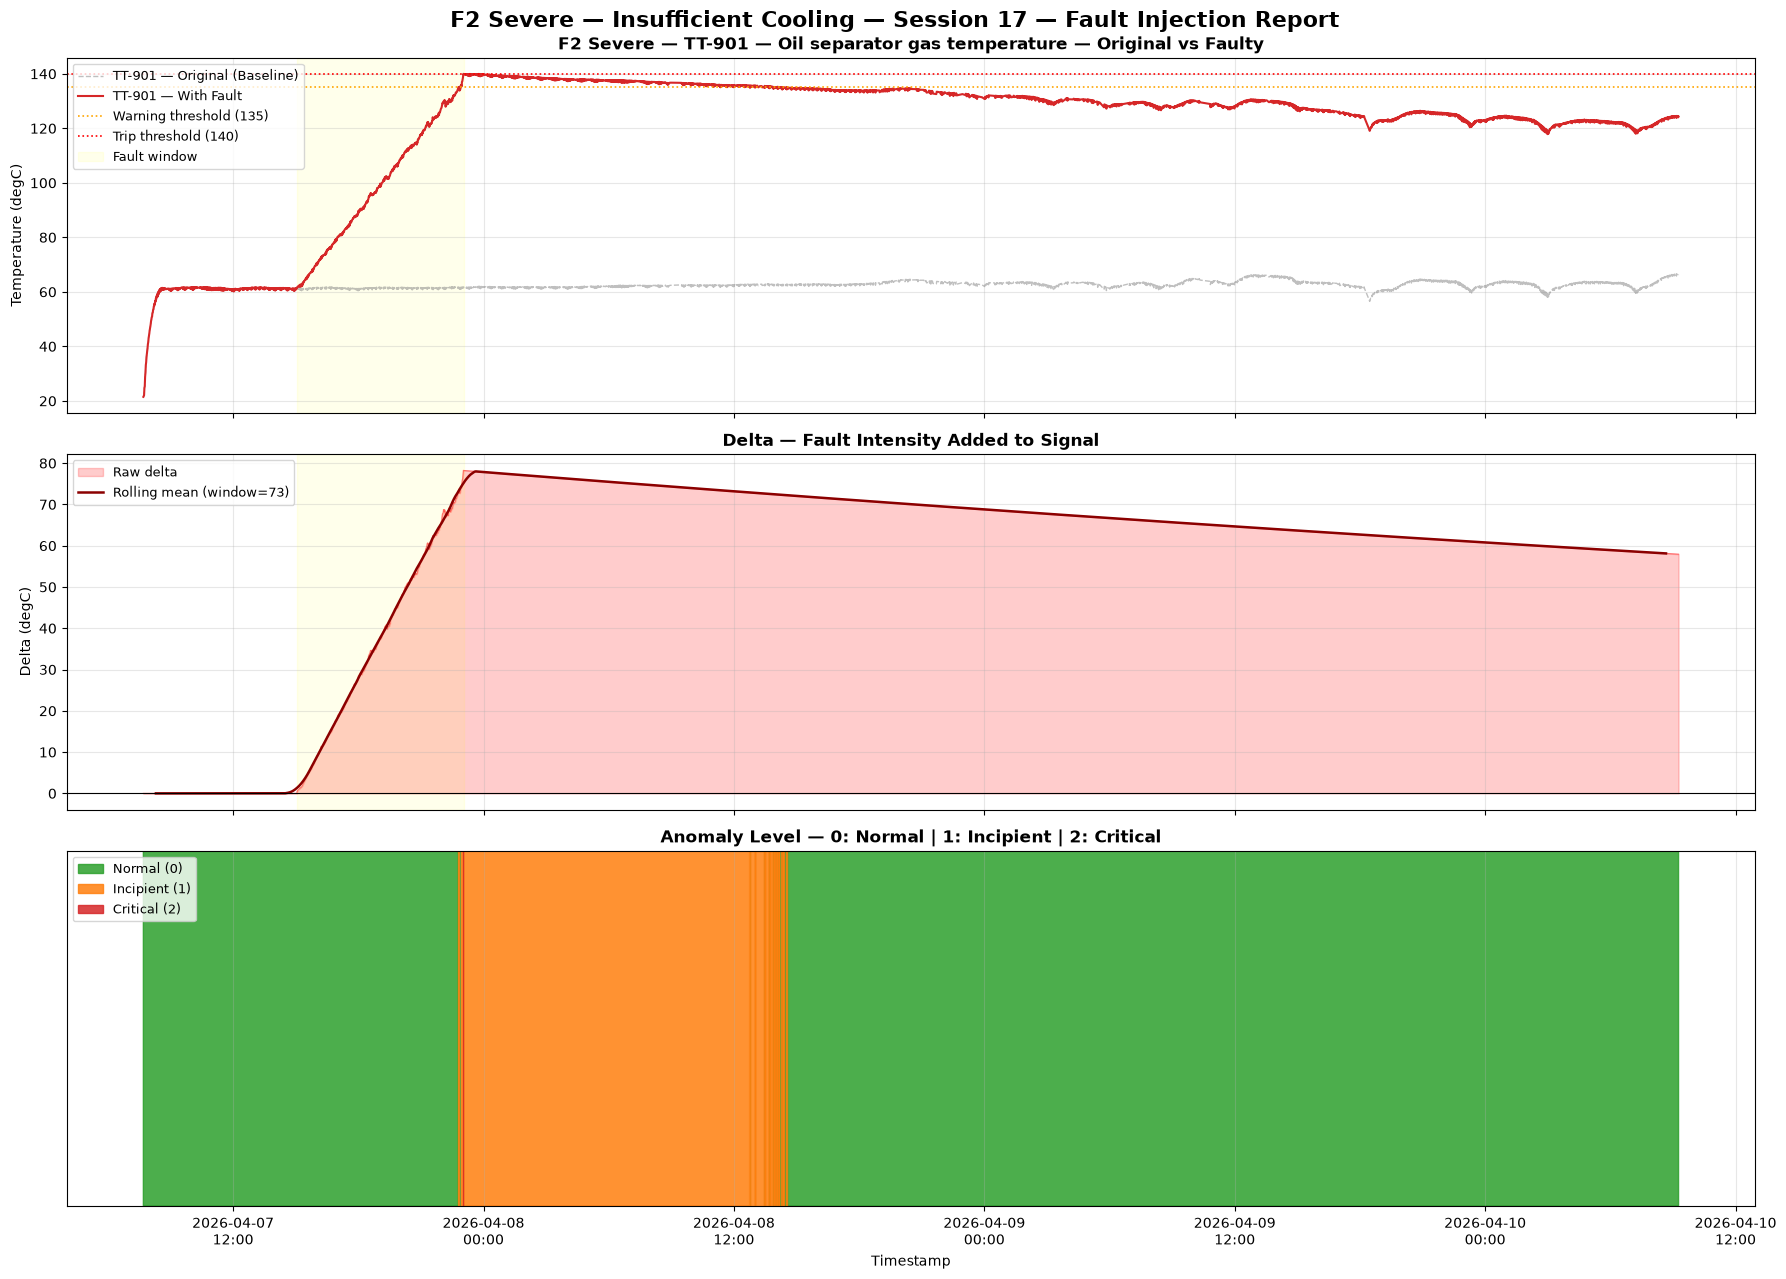

In [29]:
""" F2 Severe — Fault Profile Verification Plot — Session 17 """

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 13), sharex=True)

# ============================================================
# PANEL 1 — Original vs Faulty TT-901
# ============================================================

f2_severe_s17_fault_start_timestamp = f2_severe_s17_df.index[f2_severe_s17_start_idx]
f2_severe_s17_fault_end_timestamp = f2_severe_s17_df.index[f2_severe_s17_end_idx - 1]

ax1.plot(
    f2_severe_s17_df_orig.index,
    f2_severe_s17_df_orig["TT-901"],
    color="gray",
    alpha=0.5,
    linestyle="--",
    linewidth=1.0,
    label="TT-901 — Original (Baseline)"
)

ax1.plot(
    f2_severe_s17_df.index,
    f2_severe_s17_df["TT-901"],
    color="#d62728",
    linewidth=1.5,
    label="TT-901 — With Fault"
)

ax1.axhline(
    y=tt901_warning,
    color="orange",
    linestyle=":",
    linewidth=1.2,
    label=f"Warning threshold ({tt901_warning})"
)

ax1.axhline(
    y=tt901_trip,
    color="red",
    linestyle=":",
    linewidth=1.2,
    label=f"Trip threshold ({tt901_trip})"
)

ax1.axvspan(
    f2_severe_s17_fault_start_timestamp,
    f2_severe_s17_fault_end_timestamp,
    color="yellow",
    alpha=0.08,
    label="Fault window"
)

ax1.set_title("F2 Severe — TT-901 — Oil separator gas temperature — Original vs Faulty", fontweight="bold")
ax1.set_ylabel("Temperature (degC)")
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(True, alpha=0.3)

# ============================================================
# PANEL 2 — Delta (fault intensity)
# ============================================================

f2_severe_s17_delta_full = f2_severe_s17_df["TT-901"] - f2_severe_s17_df_orig["TT-901"]
f2_severe_s17_roll_window = max(10, len(f2_severe_s17_delta_full) // 60)
f2_severe_s17_delta_rolling_mean = f2_severe_s17_delta_full.rolling(f2_severe_s17_roll_window, center=True).mean()

ax2.fill_between(
    f2_severe_s17_df.index,
    0,
    f2_severe_s17_delta_full,
    color="red",
    alpha=0.2,
    label="Raw delta"
)

ax2.plot(
    f2_severe_s17_df.index,
    f2_severe_s17_delta_full,
    color="red",
    linewidth=0.8,
    alpha=0.5
)

ax2.plot(
    f2_severe_s17_df.index,
    f2_severe_s17_delta_rolling_mean,
    color="#8B0000",
    linewidth=1.8,
    label=f"Rolling mean (window={f2_severe_s17_roll_window})"
)

ax2.axhline(y=0, color="black", linewidth=0.8)
ax2.axvspan(f2_severe_s17_fault_start_timestamp, f2_severe_s17_fault_end_timestamp, color="yellow", alpha=0.08)
ax2.set_title("Delta — Fault Intensity Added to Signal", fontweight="bold")
ax2.set_ylabel("Delta (degC)")
ax2.legend(loc="upper left", fontsize=9)
ax2.grid(True, alpha=0.3)

# ============================================================
# PANEL 3 — Anomaly level bar
# ============================================================

f2_severe_s17_normal_mask = f2_severe_s17_df["anomaly_level"] == 0
f2_severe_s17_incipient_mask = f2_severe_s17_df["anomaly_level"] == 1
f2_severe_s17_critical_mask = f2_severe_s17_df["anomaly_level"] == 2

ax3.fill_between(f2_severe_s17_df.index, 0, 1, where=f2_severe_s17_normal_mask, color="#2ca02c", step="mid", alpha=0.85, label="Normal (0)")
ax3.fill_between(f2_severe_s17_df.index, 0, 1, where=f2_severe_s17_incipient_mask, color="#ff7f0e", step="mid", alpha=0.85, label="Incipient (1)")
ax3.fill_between(f2_severe_s17_df.index, 0, 1, where=f2_severe_s17_critical_mask, color="#d62728", step="mid", alpha=0.85, label="Critical (2)")

ax3.set_yticks([])
ax3.set_ylim(0, 1)
ax3.set_xlabel("Timestamp")
ax3.set_title("Anomaly Level — 0: Normal | 1: Incipient | 2: Critical", fontweight="bold")
ax3.legend(loc="upper left", fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))

fig.suptitle("F2 Severe — Insufficient Cooling — Session 17 — Fault Injection Report", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


### F3 Fault

#### Small - Session 16

In [30]:
""" F3 Small — Float Valve Fault — Session 16 """

np.random.seed(42)

f3_small_s16_df_orig = dict_sessions[16].copy()
f3_small_s16_main_sensor = "PT-903"
f3_small_s16_length_hours = 6
f3_small_s16_start_from = 0.3

# FAULT WINDOW
f3_small_s16_session_length = len(f3_small_s16_df_orig)
f3_small_s16_start_idx = int(round(f3_small_s16_session_length * f3_small_s16_start_from))
f3_small_s16_end_idx = min(f3_small_s16_start_idx + int(round(f3_small_s16_length_hours * 60)), f3_small_s16_session_length)
f3_small_s16_total_l = f3_small_s16_end_idx - f3_small_s16_start_idx
print("Session 16 length:", f3_small_s16_session_length, "rows")
print("Fault start index:", f3_small_s16_start_idx)
print("Fault end index:", f3_small_s16_end_idx)
print("Fault window length:", f3_small_s16_total_l, "rows")

# BASELINE STATISTICS
f3_small_s16_baseline_mean = f3_small_s16_df_orig["PT-903"].iloc[:f3_small_s16_start_idx].mean()
f3_small_s16_baseline_std = f3_small_s16_df_orig["PT-903"].iloc[:f3_small_s16_start_idx].std()
print("\nPT-903 baseline mean:", round(f3_small_s16_baseline_mean, 4))
print("PT-903 baseline std:", round(f3_small_s16_baseline_std, 4))

# SEVERITY TARGET — small moves from baseline toward warning
f3_small_s16_target = f3_small_s16_baseline_mean + small_warning_fraction * (pt903_warning - f3_small_s16_baseline_mean)
f3_small_s16_delta_mag = f3_small_s16_target - f3_small_s16_baseline_mean
print("PT-903 small target:", round(f3_small_s16_target, 4))
print("PT-903 delta magnitude:", round(f3_small_s16_delta_mag, 4))

# RAW DELTA SHAPE — low-amplitude bounded oscillation
f3_small_s16_period_samples = 90
f3_small_s16_t = np.arange(f3_small_s16_total_l)
f3_small_s16_phase_jitter = pd.Series(np.random.normal(0, 0.08, f3_small_s16_total_l)).rolling(8, center=True, min_periods=1).mean().values
f3_small_s16_envelope = 0.35 + 0.35 * np.sin(2 * np.pi * f3_small_s16_t / max(f3_small_s16_period_samples * 4, 1))
f3_small_s16_noise_std = min(f3_small_s16_baseline_std * 0.05, abs(f3_small_s16_delta_mag) * 0.10)
f3_small_s16_noise = np.random.normal(0, f3_small_s16_noise_std, f3_small_s16_total_l)
f3_small_s16_delta = f3_small_s16_delta_mag * f3_small_s16_envelope * np.sin(2 * np.pi * f3_small_s16_t / f3_small_s16_period_samples + f3_small_s16_phase_jitter) + f3_small_s16_noise

# TARGET ALIGNMENT — keep severity ordered against the absolute target
f3_small_s16_active_values = f3_small_s16_df_orig["PT-903"].iloc[f3_small_s16_start_idx:f3_small_s16_end_idx].to_numpy()
f3_small_s16_positive_peak_idx = int(np.argmax(f3_small_s16_delta))
if False:
    f3_small_s16_delta = np.maximum(f3_small_s16_delta, 0)

if f3_small_s16_delta[f3_small_s16_positive_peak_idx] > 0:
    f3_small_s16_desired_peak_delta = f3_small_s16_target - f3_small_s16_active_values[f3_small_s16_positive_peak_idx]
    if f3_small_s16_desired_peak_delta > 0:
        f3_small_s16_delta = f3_small_s16_delta * (f3_small_s16_desired_peak_delta / f3_small_s16_delta[f3_small_s16_positive_peak_idx])

f3_small_s16_upper_delta = f3_small_s16_target - f3_small_s16_active_values
f3_small_s16_delta = np.minimum(f3_small_s16_delta, f3_small_s16_upper_delta)
if False:
    f3_small_s16_delta = np.maximum(f3_small_s16_delta, 0)

# CORRELATION COMPUTED EXPLICITLY
f3_small_s16_corr_threshold = 0.7
f3_small_s16_corr = f3_small_s16_df_orig.corr(method="pearson", numeric_only=True)["PT-903"]
f3_small_s16_corr_sensors = f3_small_s16_corr[abs(f3_small_s16_corr) >= f3_small_s16_corr_threshold].index.tolist()
print("\nCorrelated sensors (|r| >=", f3_small_s16_corr_threshold, "):", f3_small_s16_corr_sensors)

# APPLY INJECTION EXPLICITLY SENSOR BY SENSOR
f3_small_s16_df = f3_small_s16_df_orig.copy()
f3_small_s16_propagation_scale = 0.2
for sensor in f3_small_s16_corr_sensors:
    if sensor in f3_small_s16_df.columns:
        scale = 1.0 if sensor == f3_small_s16_main_sensor else f3_small_s16_propagation_scale
        f3_small_s16_df.iloc[f3_small_s16_start_idx:f3_small_s16_end_idx, f3_small_s16_df.columns.get_loc(sensor)] += f3_small_s16_delta * f3_small_s16_corr[sensor] * scale

# DECAY / STABILIZATION PHASE
f3_small_s16_remaining = f3_small_s16_session_length - f3_small_s16_end_idx
if f3_small_s16_remaining > 0:
    f3_small_s16_decay_rate = 1.2
    f3_small_s16_decay = f3_small_s16_delta[-1] * np.exp(-f3_small_s16_decay_rate * np.linspace(0, 1, f3_small_s16_remaining))
    for sensor in f3_small_s16_corr_sensors:
        if sensor in f3_small_s16_df.columns:
            scale = 1.0 if sensor == f3_small_s16_main_sensor else f3_small_s16_propagation_scale
            f3_small_s16_df.iloc[f3_small_s16_end_idx:, f3_small_s16_df.columns.get_loc(sensor)] += f3_small_s16_decay * f3_small_s16_corr[sensor] * scale


# LABELS — small faults are below warning but still injected anomalies
f3_small_s16_df["anomaly_level"] = 0
f3_small_s16_df["is_injected_anomaly"] = 0
f3_small_s16_df["anomaly_type"] = "normal"
f3_small_s16_df.iloc[f3_small_s16_start_idx:f3_small_s16_end_idx, f3_small_s16_df.columns.get_loc("anomaly_level")] = 1
f3_small_s16_df.iloc[f3_small_s16_start_idx:f3_small_s16_end_idx, f3_small_s16_df.columns.get_loc("is_injected_anomaly")] = 1
f3_small_s16_df.iloc[f3_small_s16_start_idx:f3_small_s16_end_idx, f3_small_s16_df.columns.get_loc("anomaly_type")] = "valve_fault"

# SAVE CSV
f3_small_s16_df.to_csv(f"{output_dir_single}/session_16_F3_small.csv")
print("\nSession 16 F3 small saved")
print("Anomaly rows:", int(f3_small_s16_df["is_injected_anomaly"].sum()))
print("Normal rows:", int((f3_small_s16_df["is_injected_anomaly"] == 0).sum()))
print("Level 1 rows:", int((f3_small_s16_df["anomaly_level"] == 1).sum()))
print("Level 2 rows:", int((f3_small_s16_df["anomaly_level"] == 2).sum()))


Session 16 length: 3367 rows
Fault start index: 1010
Fault end index: 1370
Fault window length: 360 rows

PT-903 baseline mean: 0.0744
PT-903 baseline std: 0.0697
PT-903 small target: 0.1558
PT-903 delta magnitude: 0.0814

Correlated sensors (|r| >= 0.7 ): ['FT-901', 'PT-901', 'PT-902', 'PT-903', 'VSD-901_CORRENT', 'VSD-901_POWER']

Session 16 F3 small saved
Anomaly rows: 360
Normal rows: 3007
Level 1 rows: 360
Level 2 rows: 0


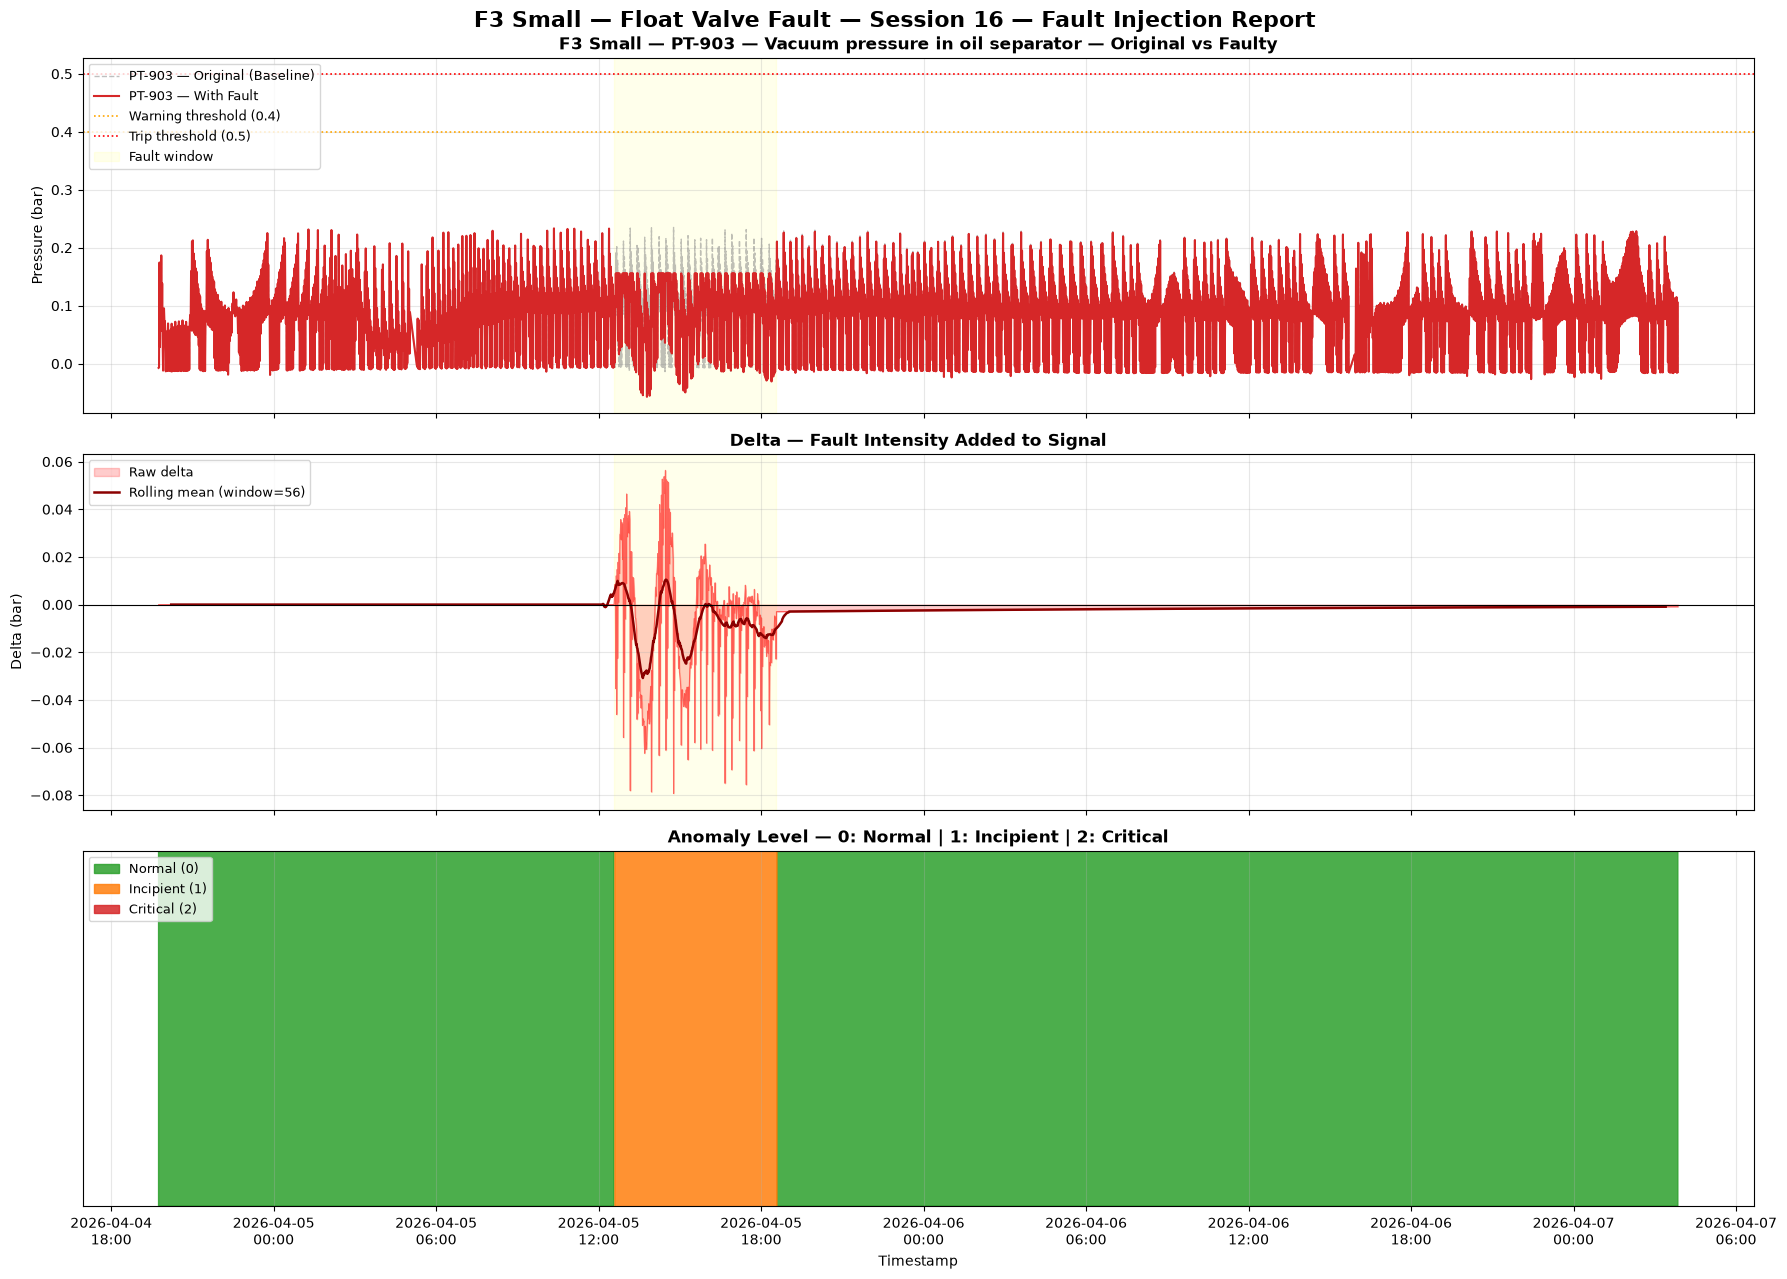

In [31]:
""" F3 Small — Fault Profile Verification Plot — Session 16 """

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 13), sharex=True)

# ============================================================
# PANEL 1 — Original vs Faulty PT-903
# ============================================================

f3_small_s16_fault_start_timestamp = f3_small_s16_df.index[f3_small_s16_start_idx]
f3_small_s16_fault_end_timestamp = f3_small_s16_df.index[f3_small_s16_end_idx - 1]

ax1.plot(
    f3_small_s16_df_orig.index,
    f3_small_s16_df_orig["PT-903"],
    color="gray",
    alpha=0.5,
    linestyle="--",
    linewidth=1.0,
    label="PT-903 — Original (Baseline)"
)

ax1.plot(
    f3_small_s16_df.index,
    f3_small_s16_df["PT-903"],
    color="#d62728",
    linewidth=1.5,
    label="PT-903 — With Fault"
)

ax1.axhline(
    y=pt903_warning,
    color="orange",
    linestyle=":",
    linewidth=1.2,
    label=f"Warning threshold ({pt903_warning})"
)

ax1.axhline(
    y=pt903_trip,
    color="red",
    linestyle=":",
    linewidth=1.2,
    label=f"Trip threshold ({pt903_trip})"
)

ax1.axvspan(
    f3_small_s16_fault_start_timestamp,
    f3_small_s16_fault_end_timestamp,
    color="yellow",
    alpha=0.08,
    label="Fault window"
)

ax1.set_title("F3 Small — PT-903 — Vacuum pressure in oil separator — Original vs Faulty", fontweight="bold")
ax1.set_ylabel("Pressure (bar)")
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(True, alpha=0.3)

# ============================================================
# PANEL 2 — Delta (fault intensity)
# ============================================================

f3_small_s16_delta_full = f3_small_s16_df["PT-903"] - f3_small_s16_df_orig["PT-903"]
f3_small_s16_roll_window = max(10, len(f3_small_s16_delta_full) // 60)
f3_small_s16_delta_rolling_mean = f3_small_s16_delta_full.rolling(f3_small_s16_roll_window, center=True).mean()

ax2.fill_between(
    f3_small_s16_df.index,
    0,
    f3_small_s16_delta_full,
    color="red",
    alpha=0.2,
    label="Raw delta"
)

ax2.plot(
    f3_small_s16_df.index,
    f3_small_s16_delta_full,
    color="red",
    linewidth=0.8,
    alpha=0.5
)

ax2.plot(
    f3_small_s16_df.index,
    f3_small_s16_delta_rolling_mean,
    color="#8B0000",
    linewidth=1.8,
    label=f"Rolling mean (window={f3_small_s16_roll_window})"
)

ax2.axhline(y=0, color="black", linewidth=0.8)
ax2.axvspan(f3_small_s16_fault_start_timestamp, f3_small_s16_fault_end_timestamp, color="yellow", alpha=0.08)
ax2.set_title("Delta — Fault Intensity Added to Signal", fontweight="bold")
ax2.set_ylabel("Delta (bar)")
ax2.legend(loc="upper left", fontsize=9)
ax2.grid(True, alpha=0.3)

# ============================================================
# PANEL 3 — Anomaly level bar
# ============================================================

f3_small_s16_normal_mask = f3_small_s16_df["anomaly_level"] == 0
f3_small_s16_incipient_mask = f3_small_s16_df["anomaly_level"] == 1
f3_small_s16_critical_mask = f3_small_s16_df["anomaly_level"] == 2

ax3.fill_between(f3_small_s16_df.index, 0, 1, where=f3_small_s16_normal_mask, color="#2ca02c", step="mid", alpha=0.85, label="Normal (0)")
ax3.fill_between(f3_small_s16_df.index, 0, 1, where=f3_small_s16_incipient_mask, color="#ff7f0e", step="mid", alpha=0.85, label="Incipient (1)")
ax3.fill_between(f3_small_s16_df.index, 0, 1, where=f3_small_s16_critical_mask, color="#d62728", step="mid", alpha=0.85, label="Critical (2)")

ax3.set_yticks([])
ax3.set_ylim(0, 1)
ax3.set_xlabel("Timestamp")
ax3.set_title("Anomaly Level — 0: Normal | 1: Incipient | 2: Critical", fontweight="bold")
ax3.legend(loc="upper left", fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))

fig.suptitle("F3 Small — Float Valve Fault — Session 16 — Fault Injection Report", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


#### Medium - Session 16

In [32]:
""" F3 Medium — Float Valve Fault — Session 16 """

np.random.seed(42)

f3_medium_s16_df_orig = dict_sessions[16].copy()
f3_medium_s16_main_sensor = "PT-903"
f3_medium_s16_length_hours = 10
f3_medium_s16_start_from = 0.45

# FAULT WINDOW
f3_medium_s16_session_length = len(f3_medium_s16_df_orig)
f3_medium_s16_start_idx = int(round(f3_medium_s16_session_length * f3_medium_s16_start_from))
f3_medium_s16_end_idx = min(f3_medium_s16_start_idx + int(round(f3_medium_s16_length_hours * 60)), f3_medium_s16_session_length)
f3_medium_s16_total_l = f3_medium_s16_end_idx - f3_medium_s16_start_idx
print("Session 16 length:", f3_medium_s16_session_length, "rows")
print("Fault start index:", f3_medium_s16_start_idx)
print("Fault end index:", f3_medium_s16_end_idx)
print("Fault window length:", f3_medium_s16_total_l, "rows")

# BASELINE STATISTICS
f3_medium_s16_baseline_mean = f3_medium_s16_df_orig["PT-903"].iloc[:f3_medium_s16_start_idx].mean()
f3_medium_s16_baseline_std = f3_medium_s16_df_orig["PT-903"].iloc[:f3_medium_s16_start_idx].std()
print("\nPT-903 baseline mean:", round(f3_medium_s16_baseline_mean, 4))
print("PT-903 baseline std:", round(f3_medium_s16_baseline_std, 4))

# SEVERITY TARGET — medium reaches the warning-to-trip interval
f3_medium_s16_target = pt903_warning + medium_trip_fraction * (pt903_trip - pt903_warning)
f3_medium_s16_delta_mag = f3_medium_s16_target - f3_medium_s16_baseline_mean
print("PT-903 medium target:", round(f3_medium_s16_target, 4))
print("PT-903 delta magnitude:", round(f3_medium_s16_delta_mag, 4))

# RAW DELTA SHAPE — growing oscillation with capped noise
f3_medium_s16_period_samples = 30
f3_medium_s16_t = np.arange(f3_medium_s16_total_l)
f3_medium_s16_envelope = np.linspace(0.1, 1.0, f3_medium_s16_total_l)
f3_medium_s16_noise_std = min(f3_medium_s16_baseline_std * 0.50, abs(f3_medium_s16_delta_mag) * 0.15)
f3_medium_s16_noise = np.random.normal(0, f3_medium_s16_noise_std, f3_medium_s16_total_l)
f3_medium_s16_delta = f3_medium_s16_delta_mag * np.sin(2 * np.pi * f3_medium_s16_t / f3_medium_s16_period_samples) * f3_medium_s16_envelope + f3_medium_s16_noise

# TARGET ALIGNMENT — keep severity ordered against the absolute target
f3_medium_s16_active_values = f3_medium_s16_df_orig["PT-903"].iloc[f3_medium_s16_start_idx:f3_medium_s16_end_idx].to_numpy()
f3_medium_s16_positive_peak_idx = int(np.argmax(f3_medium_s16_delta))
if False:
    f3_medium_s16_delta = np.maximum(f3_medium_s16_delta, 0)

if f3_medium_s16_delta[f3_medium_s16_positive_peak_idx] > 0:
    f3_medium_s16_desired_peak_delta = f3_medium_s16_target - f3_medium_s16_active_values[f3_medium_s16_positive_peak_idx]
    if f3_medium_s16_desired_peak_delta > 0:
        f3_medium_s16_delta = f3_medium_s16_delta * (f3_medium_s16_desired_peak_delta / f3_medium_s16_delta[f3_medium_s16_positive_peak_idx])

f3_medium_s16_upper_delta = f3_medium_s16_target - f3_medium_s16_active_values
f3_medium_s16_delta = np.minimum(f3_medium_s16_delta, f3_medium_s16_upper_delta)
if False:
    f3_medium_s16_delta = np.maximum(f3_medium_s16_delta, 0)

# CORRELATION COMPUTED EXPLICITLY
f3_medium_s16_corr_threshold = 0.7
f3_medium_s16_corr = f3_medium_s16_df_orig.corr(method="pearson", numeric_only=True)["PT-903"]
f3_medium_s16_corr_sensors = f3_medium_s16_corr[abs(f3_medium_s16_corr) >= f3_medium_s16_corr_threshold].index.tolist()
print("\nCorrelated sensors (|r| >=", f3_medium_s16_corr_threshold, "):", f3_medium_s16_corr_sensors)

# APPLY INJECTION EXPLICITLY SENSOR BY SENSOR
f3_medium_s16_df = f3_medium_s16_df_orig.copy()
f3_medium_s16_propagation_scale = 0.2
for sensor in f3_medium_s16_corr_sensors:
    if sensor in f3_medium_s16_df.columns:
        scale = 1.0 if sensor == f3_medium_s16_main_sensor else f3_medium_s16_propagation_scale
        f3_medium_s16_df.iloc[f3_medium_s16_start_idx:f3_medium_s16_end_idx, f3_medium_s16_df.columns.get_loc(sensor)] += f3_medium_s16_delta * f3_medium_s16_corr[sensor] * scale

# DECAY / STABILIZATION PHASE
f3_medium_s16_remaining = f3_medium_s16_session_length - f3_medium_s16_end_idx
if f3_medium_s16_remaining > 0:
    f3_medium_s16_decay_rate = 0.3
    f3_medium_s16_decay = f3_medium_s16_delta[-1] * np.exp(-f3_medium_s16_decay_rate * np.linspace(0, 1, f3_medium_s16_remaining))
    for sensor in f3_medium_s16_corr_sensors:
        if sensor in f3_medium_s16_df.columns:
            scale = 1.0 if sensor == f3_medium_s16_main_sensor else f3_medium_s16_propagation_scale
            f3_medium_s16_df.iloc[f3_medium_s16_end_idx:, f3_medium_s16_df.columns.get_loc(sensor)] += f3_medium_s16_decay * f3_medium_s16_corr[sensor] * scale

# SEVERITY CAP — small/medium should not drift beyond their target during stabilization
f3_medium_s16_main_sensor_loc = f3_medium_s16_df.columns.get_loc("PT-903")
f3_medium_s16_df.iloc[f3_medium_s16_start_idx:, f3_medium_s16_main_sensor_loc] = np.minimum(
    f3_medium_s16_df.iloc[f3_medium_s16_start_idx:, f3_medium_s16_main_sensor_loc],
    f3_medium_s16_target,
)

# LABELS — medium/severe faults are labelled from injection start through stabilization
f3_medium_s16_df["anomaly_level"] = 0
f3_medium_s16_df["is_injected_anomaly"] = 0
f3_medium_s16_df["anomaly_type"] = "normal"
f3_medium_s16_injected_values = f3_medium_s16_df["PT-903"].iloc[f3_medium_s16_start_idx:]
f3_medium_s16_labels = np.where(
    f3_medium_s16_injected_values >= pt903_trip, 2,
    np.where(f3_medium_s16_injected_values >= pt903_warning, 1, 0)
)
f3_medium_s16_df.iloc[f3_medium_s16_start_idx:, f3_medium_s16_df.columns.get_loc("anomaly_level")] = f3_medium_s16_labels
f3_medium_s16_df.iloc[f3_medium_s16_start_idx:, f3_medium_s16_df.columns.get_loc("is_injected_anomaly")] = 1
f3_medium_s16_df.iloc[f3_medium_s16_start_idx:, f3_medium_s16_df.columns.get_loc("anomaly_type")] = "valve_fault"

# SAVE CSV
f3_medium_s16_df.to_csv(f"{output_dir_single}/session_16_F3_medium.csv")
print("\nSession 16 F3 medium saved")
print("Anomaly rows:", int(f3_medium_s16_df["is_injected_anomaly"].sum()))
print("Normal rows:", int((f3_medium_s16_df["is_injected_anomaly"] == 0).sum()))
print("Level 1 rows:", int((f3_medium_s16_df["anomaly_level"] == 1).sum()))
print("Level 2 rows:", int((f3_medium_s16_df["anomaly_level"] == 2).sum()))


Session 16 length: 3367 rows
Fault start index: 1515
Fault end index: 2115
Fault window length: 600 rows

PT-903 baseline mean: 0.08
PT-903 baseline std: 0.0713
PT-903 medium target: 0.455
PT-903 delta magnitude: 0.375

Correlated sensors (|r| >= 0.7 ): ['FT-901', 'PT-901', 'PT-902', 'PT-903', 'VSD-901_CORRENT', 'VSD-901_POWER']

Session 16 F3 medium saved
Anomaly rows: 1852
Normal rows: 1515
Level 1 rows: 24
Level 2 rows: 0


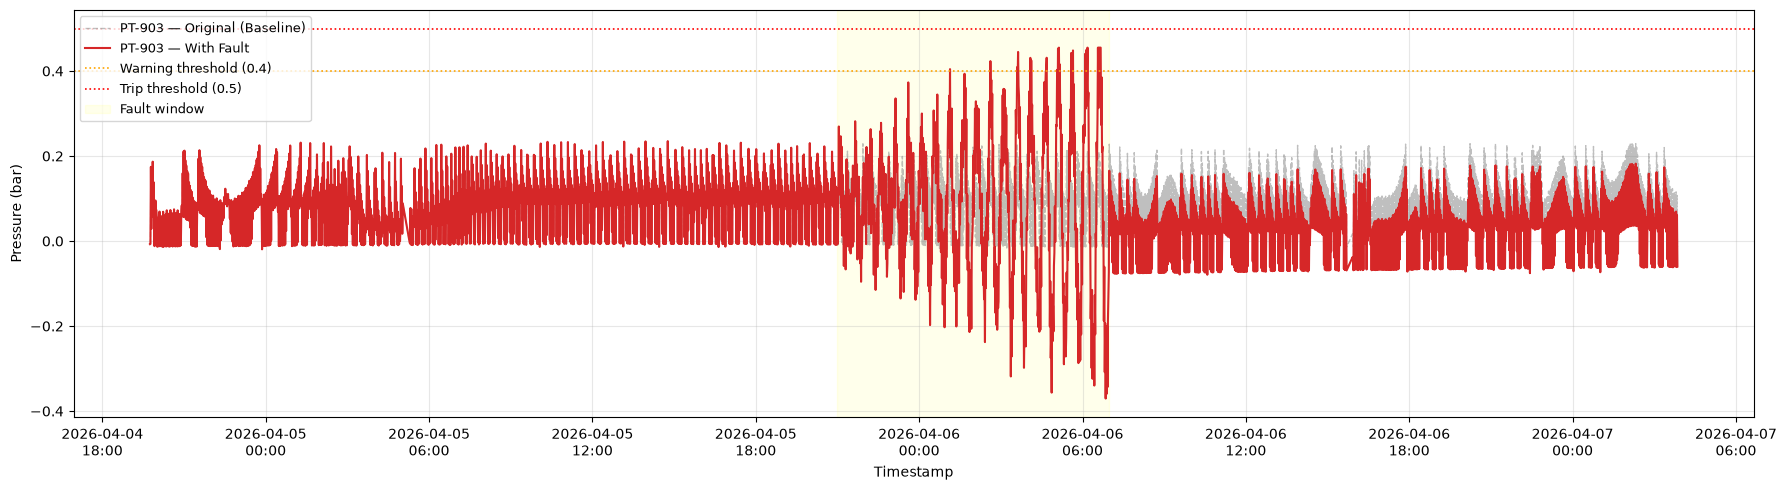

In [58]:
""" F3 Medium — Fault Profile Verification Plot — Session 16 """

fig, ax1 = plt.subplots(1, 1, figsize=(18, 5))

# ============================================================
# PANEL 1 — Original vs Faulty PT-903
# ============================================================

f3_medium_s16_fault_start_timestamp = f3_medium_s16_df.index[f3_medium_s16_start_idx]
f3_medium_s16_fault_end_timestamp = f3_medium_s16_df.index[f3_medium_s16_end_idx - 1]

ax1.plot(
    f3_medium_s16_df_orig.index,
    f3_medium_s16_df_orig["PT-903"],
    color="gray",
    alpha=0.5,
    linestyle="--",
    linewidth=1.0,
    label="PT-903 — Original (Baseline)"
)

ax1.plot(
    f3_medium_s16_df.index,
    f3_medium_s16_df["PT-903"],
    color="#d62728",
    linewidth=1.5,
    label="PT-903 — With Fault"
)

ax1.axhline(
    y=pt903_warning,
    color="orange",
    linestyle=":",
    linewidth=1.2,
    label=f"Warning threshold ({pt903_warning})"
)

ax1.axhline(
    y=pt903_trip,
    color="red",
    linestyle=":",
    linewidth=1.2,
    label=f"Trip threshold ({pt903_trip})"
)

ax1.axvspan(
    f3_medium_s16_fault_start_timestamp,
    f3_medium_s16_fault_end_timestamp,
    color="yellow",
    alpha=0.08,
    label="Fault window"
)

ax1.set_ylabel("Pressure (bar)")
ax1.set_xlabel("Timestamp")
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))

plt.tight_layout()
plt.savefig("fault_f3_medium_s16.png", dpi=200, bbox_inches="tight")
plt.show()

#### Severe - Session 16

In [34]:
""" F3 Severe — Float Valve Fault — Session 16 """

np.random.seed(42)

f3_severe_s16_df_orig = dict_sessions[16].copy()
f3_severe_s16_main_sensor = "PT-903"
f3_severe_s16_length_hours = 12
f3_severe_s16_start_from = 0.55

# FAULT WINDOW
f3_severe_s16_session_length = len(f3_severe_s16_df_orig)
f3_severe_s16_start_idx = int(round(f3_severe_s16_session_length * f3_severe_s16_start_from))
f3_severe_s16_end_idx = min(f3_severe_s16_start_idx + int(round(f3_severe_s16_length_hours * 60)), f3_severe_s16_session_length)
f3_severe_s16_total_l = f3_severe_s16_end_idx - f3_severe_s16_start_idx
print("Session 16 length:", f3_severe_s16_session_length, "rows")
print("Fault start index:", f3_severe_s16_start_idx)
print("Fault end index:", f3_severe_s16_end_idx)
print("Fault window length:", f3_severe_s16_total_l, "rows")

# BASELINE STATISTICS
f3_severe_s16_baseline_mean = f3_severe_s16_df_orig["PT-903"].iloc[:f3_severe_s16_start_idx].mean()
f3_severe_s16_baseline_std = f3_severe_s16_df_orig["PT-903"].iloc[:f3_severe_s16_start_idx].std()
print("\nPT-903 baseline mean:", round(f3_severe_s16_baseline_mean, 4))
print("PT-903 baseline std:", round(f3_severe_s16_baseline_std, 4))

# SEVERITY TARGET — severe reaches trip level
f3_severe_s16_target = pt903_trip
f3_severe_s16_delta_mag = f3_severe_s16_target - f3_severe_s16_baseline_mean
print("PT-903 severe target:", round(f3_severe_s16_target, 4))
print("PT-903 delta magnitude:", round(f3_severe_s16_delta_mag, 4))

# RAW DELTA SHAPE — growing oscillation with capped noise
f3_severe_s16_period_samples = 30
f3_severe_s16_t = np.arange(f3_severe_s16_total_l)
f3_severe_s16_envelope = np.linspace(0.1, 1.0, f3_severe_s16_total_l)
f3_severe_s16_noise_std = min(f3_severe_s16_baseline_std * 0.50, abs(f3_severe_s16_delta_mag) * 0.15)
f3_severe_s16_noise = np.random.normal(0, f3_severe_s16_noise_std, f3_severe_s16_total_l)
f3_severe_s16_delta = f3_severe_s16_delta_mag * np.sin(2 * np.pi * f3_severe_s16_t / f3_severe_s16_period_samples) * f3_severe_s16_envelope + f3_severe_s16_noise

# TARGET ALIGNMENT — keep severity ordered against the absolute target
f3_severe_s16_active_values = f3_severe_s16_df_orig["PT-903"].iloc[f3_severe_s16_start_idx:f3_severe_s16_end_idx].to_numpy()
f3_severe_s16_positive_peak_idx = int(np.argmax(f3_severe_s16_delta))
if False:
    f3_severe_s16_delta = np.maximum(f3_severe_s16_delta, 0)

if f3_severe_s16_delta[f3_severe_s16_positive_peak_idx] > 0:
    f3_severe_s16_desired_peak_delta = f3_severe_s16_target - f3_severe_s16_active_values[f3_severe_s16_positive_peak_idx]
    if f3_severe_s16_desired_peak_delta > 0:
        f3_severe_s16_delta = f3_severe_s16_delta * (f3_severe_s16_desired_peak_delta / f3_severe_s16_delta[f3_severe_s16_positive_peak_idx])

f3_severe_s16_upper_delta = f3_severe_s16_target - f3_severe_s16_active_values
f3_severe_s16_delta = np.minimum(f3_severe_s16_delta, f3_severe_s16_upper_delta)
if False:
    f3_severe_s16_delta = np.maximum(f3_severe_s16_delta, 0)

# CORRELATION COMPUTED EXPLICITLY
f3_severe_s16_corr_threshold = 0.7
f3_severe_s16_corr = f3_severe_s16_df_orig.corr(method="pearson", numeric_only=True)["PT-903"]
f3_severe_s16_corr_sensors = f3_severe_s16_corr[abs(f3_severe_s16_corr) >= f3_severe_s16_corr_threshold].index.tolist()
print("\nCorrelated sensors (|r| >=", f3_severe_s16_corr_threshold, "):", f3_severe_s16_corr_sensors)

# APPLY INJECTION EXPLICITLY SENSOR BY SENSOR
f3_severe_s16_df = f3_severe_s16_df_orig.copy()
f3_severe_s16_propagation_scale = 0.2
for sensor in f3_severe_s16_corr_sensors:
    if sensor in f3_severe_s16_df.columns:
        scale = 1.0 if sensor == f3_severe_s16_main_sensor else f3_severe_s16_propagation_scale
        f3_severe_s16_df.iloc[f3_severe_s16_start_idx:f3_severe_s16_end_idx, f3_severe_s16_df.columns.get_loc(sensor)] += f3_severe_s16_delta * f3_severe_s16_corr[sensor] * scale

# DECAY / STABILIZATION PHASE
f3_severe_s16_remaining = f3_severe_s16_session_length - f3_severe_s16_end_idx
if f3_severe_s16_remaining > 0:
    f3_severe_s16_decay_rate = 0.3
    f3_severe_s16_decay = f3_severe_s16_delta[-1] * np.exp(-f3_severe_s16_decay_rate * np.linspace(0, 1, f3_severe_s16_remaining))
    for sensor in f3_severe_s16_corr_sensors:
        if sensor in f3_severe_s16_df.columns:
            scale = 1.0 if sensor == f3_severe_s16_main_sensor else f3_severe_s16_propagation_scale
            f3_severe_s16_df.iloc[f3_severe_s16_end_idx:, f3_severe_s16_df.columns.get_loc(sensor)] += f3_severe_s16_decay * f3_severe_s16_corr[sensor] * scale

# LABELS — medium/severe faults are labelled from injection start through stabilization
f3_severe_s16_df["anomaly_level"] = 0
f3_severe_s16_df["is_injected_anomaly"] = 0
f3_severe_s16_df["anomaly_type"] = "normal"
f3_severe_s16_injected_values = f3_severe_s16_df["PT-903"].iloc[f3_severe_s16_start_idx:]
f3_severe_s16_labels = np.where(
    f3_severe_s16_injected_values >= pt903_trip, 2,
    np.where(f3_severe_s16_injected_values >= pt903_warning, 1, 0)
)
f3_severe_s16_df.iloc[f3_severe_s16_start_idx:, f3_severe_s16_df.columns.get_loc("anomaly_level")] = f3_severe_s16_labels
f3_severe_s16_df.iloc[f3_severe_s16_start_idx:, f3_severe_s16_df.columns.get_loc("is_injected_anomaly")] = 1
f3_severe_s16_df.iloc[f3_severe_s16_start_idx:, f3_severe_s16_df.columns.get_loc("anomaly_type")] = "valve_fault"

# SAVE CSV
f3_severe_s16_df.to_csv(f"{output_dir_single}/session_16_F3_severe.csv")
print("\nSession 16 F3 severe saved")
print("Anomaly rows:", int(f3_severe_s16_df["is_injected_anomaly"].sum()))
print("Normal rows:", int((f3_severe_s16_df["is_injected_anomaly"] == 0).sum()))
print("Level 1 rows:", int((f3_severe_s16_df["anomaly_level"] == 1).sum()))
print("Level 2 rows:", int((f3_severe_s16_df["anomaly_level"] == 2).sum()))


Session 16 length: 3367 rows
Fault start index: 1852
Fault end index: 2572
Fault window length: 720 rows

PT-903 baseline mean: 0.0814
PT-903 baseline std: 0.0718
PT-903 severe target: 0.5
PT-903 delta magnitude: 0.4186

Correlated sensors (|r| >= 0.7 ): ['FT-901', 'PT-901', 'PT-902', 'PT-903', 'VSD-901_CORRENT', 'VSD-901_POWER']

Session 16 F3 severe saved
Anomaly rows: 1515
Normal rows: 1852
Level 1 rows: 37
Level 2 rows: 16


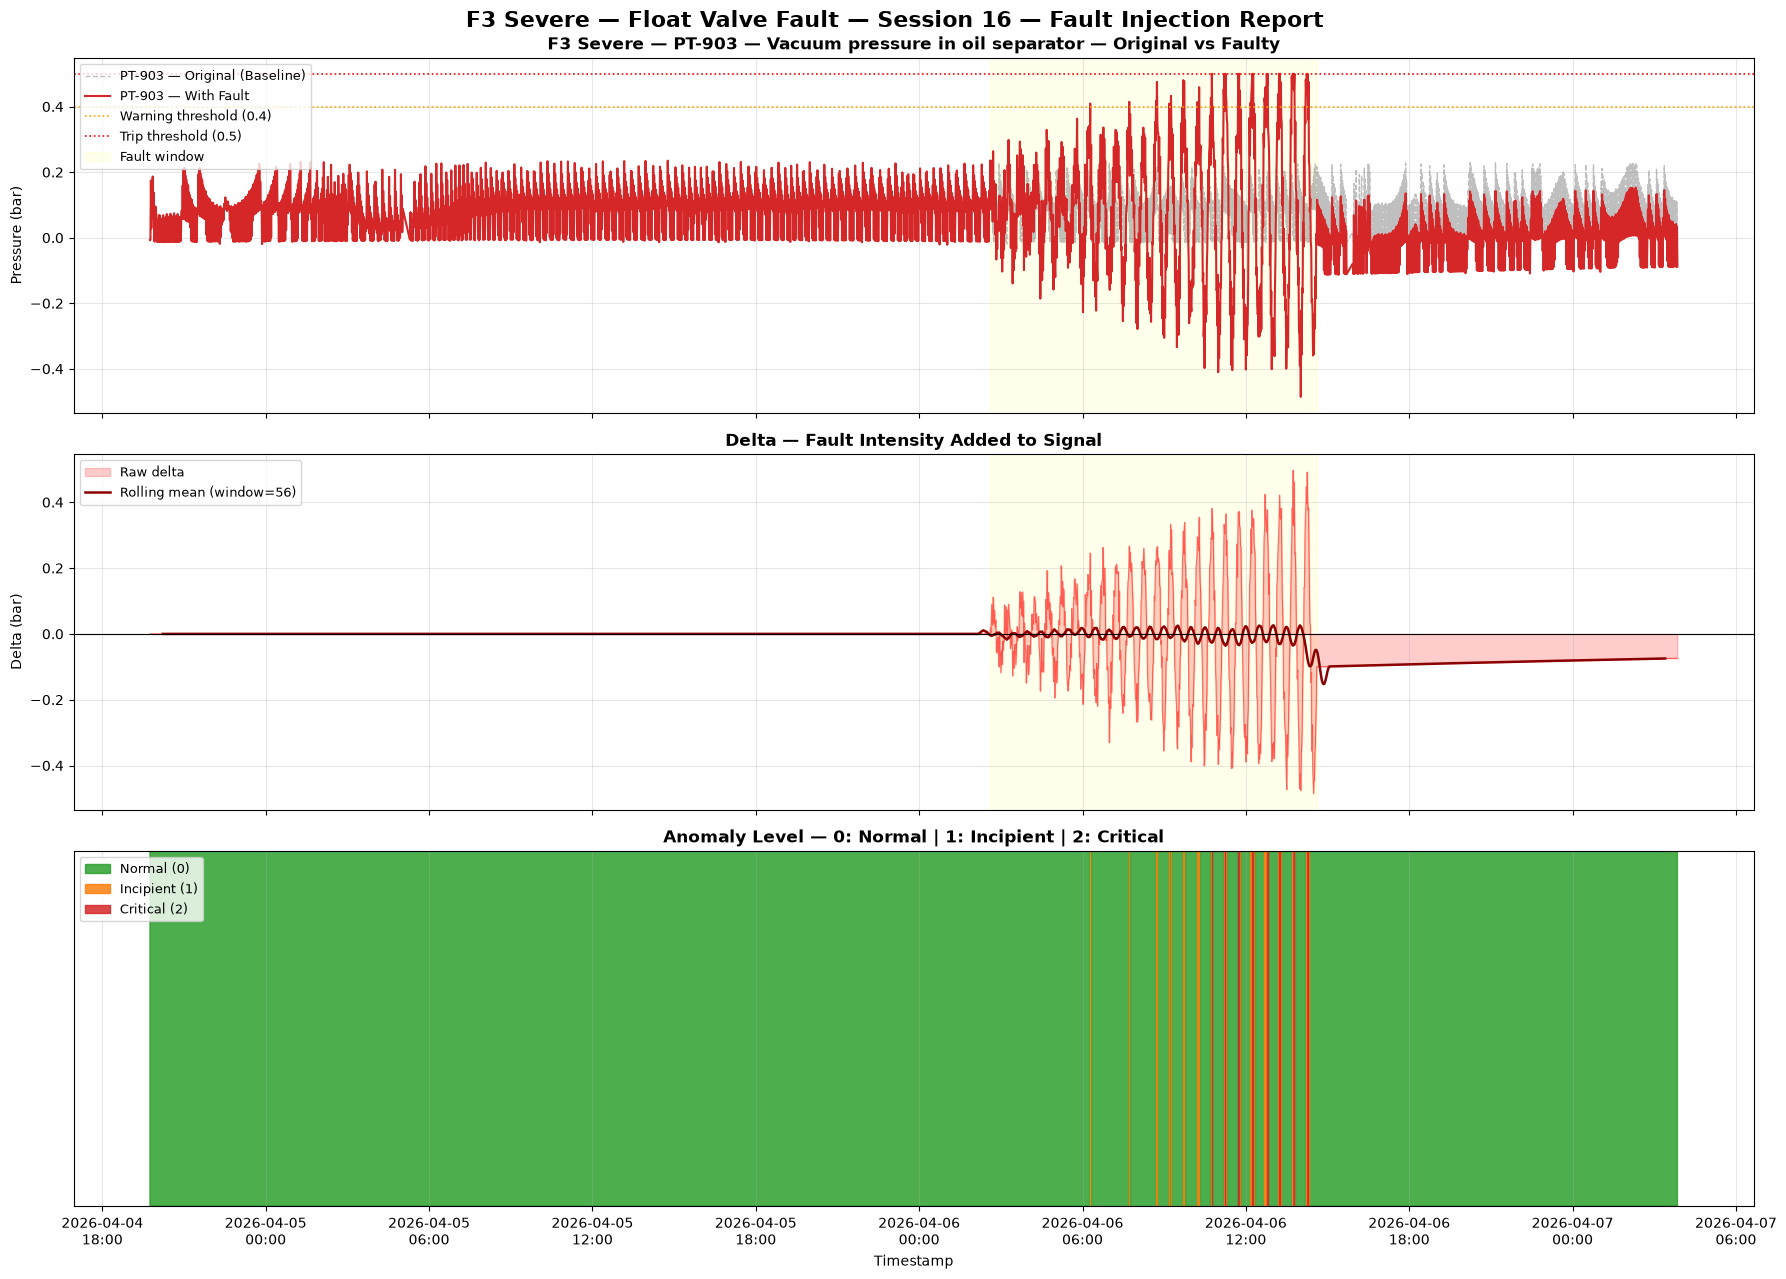

In [35]:
""" F3 Severe — Fault Profile Verification Plot — Session 16 """

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 13), sharex=True)

# ============================================================
# PANEL 1 — Original vs Faulty PT-903
# ============================================================

f3_severe_s16_fault_start_timestamp = f3_severe_s16_df.index[f3_severe_s16_start_idx]
f3_severe_s16_fault_end_timestamp = f3_severe_s16_df.index[f3_severe_s16_end_idx - 1]

ax1.plot(
    f3_severe_s16_df_orig.index,
    f3_severe_s16_df_orig["PT-903"],
    color="gray",
    alpha=0.5,
    linestyle="--",
    linewidth=1.0,
    label="PT-903 — Original (Baseline)"
)

ax1.plot(
    f3_severe_s16_df.index,
    f3_severe_s16_df["PT-903"],
    color="#d62728",
    linewidth=1.5,
    label="PT-903 — With Fault"
)

ax1.axhline(
    y=pt903_warning,
    color="orange",
    linestyle=":",
    linewidth=1.2,
    label=f"Warning threshold ({pt903_warning})"
)

ax1.axhline(
    y=pt903_trip,
    color="red",
    linestyle=":",
    linewidth=1.2,
    label=f"Trip threshold ({pt903_trip})"
)

ax1.axvspan(
    f3_severe_s16_fault_start_timestamp,
    f3_severe_s16_fault_end_timestamp,
    color="yellow",
    alpha=0.08,
    label="Fault window"
)

ax1.set_title("F3 Severe — PT-903 — Vacuum pressure in oil separator — Original vs Faulty", fontweight="bold")
ax1.set_ylabel("Pressure (bar)")
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(True, alpha=0.3)

# ============================================================
# PANEL 2 — Delta (fault intensity)
# ============================================================

f3_severe_s16_delta_full = f3_severe_s16_df["PT-903"] - f3_severe_s16_df_orig["PT-903"]
f3_severe_s16_roll_window = max(10, len(f3_severe_s16_delta_full) // 60)
f3_severe_s16_delta_rolling_mean = f3_severe_s16_delta_full.rolling(f3_severe_s16_roll_window, center=True).mean()

ax2.fill_between(
    f3_severe_s16_df.index,
    0,
    f3_severe_s16_delta_full,
    color="red",
    alpha=0.2,
    label="Raw delta"
)

ax2.plot(
    f3_severe_s16_df.index,
    f3_severe_s16_delta_full,
    color="red",
    linewidth=0.8,
    alpha=0.5
)

ax2.plot(
    f3_severe_s16_df.index,
    f3_severe_s16_delta_rolling_mean,
    color="#8B0000",
    linewidth=1.8,
    label=f"Rolling mean (window={f3_severe_s16_roll_window})"
)

ax2.axhline(y=0, color="black", linewidth=0.8)
ax2.axvspan(f3_severe_s16_fault_start_timestamp, f3_severe_s16_fault_end_timestamp, color="yellow", alpha=0.08)
ax2.set_title("Delta — Fault Intensity Added to Signal", fontweight="bold")
ax2.set_ylabel("Delta (bar)")
ax2.legend(loc="upper left", fontsize=9)
ax2.grid(True, alpha=0.3)

# ============================================================
# PANEL 3 — Anomaly level bar
# ============================================================

f3_severe_s16_normal_mask = f3_severe_s16_df["anomaly_level"] == 0
f3_severe_s16_incipient_mask = f3_severe_s16_df["anomaly_level"] == 1
f3_severe_s16_critical_mask = f3_severe_s16_df["anomaly_level"] == 2

ax3.fill_between(f3_severe_s16_df.index, 0, 1, where=f3_severe_s16_normal_mask, color="#2ca02c", step="mid", alpha=0.85, label="Normal (0)")
ax3.fill_between(f3_severe_s16_df.index, 0, 1, where=f3_severe_s16_incipient_mask, color="#ff7f0e", step="mid", alpha=0.85, label="Incipient (1)")
ax3.fill_between(f3_severe_s16_df.index, 0, 1, where=f3_severe_s16_critical_mask, color="#d62728", step="mid", alpha=0.85, label="Critical (2)")

ax3.set_yticks([])
ax3.set_ylim(0, 1)
ax3.set_xlabel("Timestamp")
ax3.set_title("Anomaly Level — 0: Normal | 1: Incipient | 2: Critical", fontweight="bold")
ax3.legend(loc="upper left", fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))

fig.suptitle("F3 Severe — Float Valve Fault — Session 16 — Fault Injection Report", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


#### Small - Session 17

In [36]:
""" F3 Small — Float Valve Fault — Session 17 """

np.random.seed(42)

f3_small_s17_df_orig = dict_sessions[17].copy()
f3_small_s17_main_sensor = "PT-903"
f3_small_s17_length_hours = 6
f3_small_s17_start_from = 0.3

# FAULT WINDOW
f3_small_s17_session_length = len(f3_small_s17_df_orig)
f3_small_s17_start_idx = int(round(f3_small_s17_session_length * f3_small_s17_start_from))
f3_small_s17_end_idx = min(f3_small_s17_start_idx + int(round(f3_small_s17_length_hours * 60)), f3_small_s17_session_length)
f3_small_s17_total_l = f3_small_s17_end_idx - f3_small_s17_start_idx
print("Session 17 length:", f3_small_s17_session_length, "rows")
print("Fault start index:", f3_small_s17_start_idx)
print("Fault end index:", f3_small_s17_end_idx)
print("Fault window length:", f3_small_s17_total_l, "rows")

# BASELINE STATISTICS
f3_small_s17_baseline_mean = f3_small_s17_df_orig["PT-903"].iloc[:f3_small_s17_start_idx].mean()
f3_small_s17_baseline_std = f3_small_s17_df_orig["PT-903"].iloc[:f3_small_s17_start_idx].std()
print("\nPT-903 baseline mean:", round(f3_small_s17_baseline_mean, 4))
print("PT-903 baseline std:", round(f3_small_s17_baseline_std, 4))

# SEVERITY TARGET — small moves from baseline toward warning
f3_small_s17_target = f3_small_s17_baseline_mean + small_warning_fraction * (pt903_warning - f3_small_s17_baseline_mean)
f3_small_s17_delta_mag = f3_small_s17_target - f3_small_s17_baseline_mean
print("PT-903 small target:", round(f3_small_s17_target, 4))
print("PT-903 delta magnitude:", round(f3_small_s17_delta_mag, 4))

# RAW DELTA SHAPE — low-amplitude bounded oscillation
f3_small_s17_period_samples = 90
f3_small_s17_t = np.arange(f3_small_s17_total_l)
f3_small_s17_phase_jitter = pd.Series(np.random.normal(0, 0.08, f3_small_s17_total_l)).rolling(8, center=True, min_periods=1).mean().values
f3_small_s17_envelope = 0.35 + 0.35 * np.sin(2 * np.pi * f3_small_s17_t / max(f3_small_s17_period_samples * 4, 1))
f3_small_s17_noise_std = min(f3_small_s17_baseline_std * 0.05, abs(f3_small_s17_delta_mag) * 0.10)
f3_small_s17_noise = np.random.normal(0, f3_small_s17_noise_std, f3_small_s17_total_l)
f3_small_s17_delta = f3_small_s17_delta_mag * f3_small_s17_envelope * np.sin(2 * np.pi * f3_small_s17_t / f3_small_s17_period_samples + f3_small_s17_phase_jitter) + f3_small_s17_noise

# TARGET ALIGNMENT — keep severity ordered against the absolute target
f3_small_s17_active_values = f3_small_s17_df_orig["PT-903"].iloc[f3_small_s17_start_idx:f3_small_s17_end_idx].to_numpy()
f3_small_s17_positive_peak_idx = int(np.argmax(f3_small_s17_delta))
if False:
    f3_small_s17_delta = np.maximum(f3_small_s17_delta, 0)

if f3_small_s17_delta[f3_small_s17_positive_peak_idx] > 0:
    f3_small_s17_desired_peak_delta = f3_small_s17_target - f3_small_s17_active_values[f3_small_s17_positive_peak_idx]
    if f3_small_s17_desired_peak_delta > 0:
        f3_small_s17_delta = f3_small_s17_delta * (f3_small_s17_desired_peak_delta / f3_small_s17_delta[f3_small_s17_positive_peak_idx])

f3_small_s17_upper_delta = f3_small_s17_target - f3_small_s17_active_values
f3_small_s17_delta = np.minimum(f3_small_s17_delta, f3_small_s17_upper_delta)
if False:
    f3_small_s17_delta = np.maximum(f3_small_s17_delta, 0)

# CORRELATION COMPUTED EXPLICITLY
f3_small_s17_corr_threshold = 0.7
f3_small_s17_corr = f3_small_s17_df_orig.corr(method="pearson", numeric_only=True)["PT-903"]
f3_small_s17_corr_sensors = f3_small_s17_corr[abs(f3_small_s17_corr) >= f3_small_s17_corr_threshold].index.tolist()
print("\nCorrelated sensors (|r| >=", f3_small_s17_corr_threshold, "):", f3_small_s17_corr_sensors)

# APPLY INJECTION EXPLICITLY SENSOR BY SENSOR
f3_small_s17_df = f3_small_s17_df_orig.copy()
f3_small_s17_propagation_scale = 0.2
for sensor in f3_small_s17_corr_sensors:
    if sensor in f3_small_s17_df.columns:
        scale = 1.0 if sensor == f3_small_s17_main_sensor else f3_small_s17_propagation_scale
        f3_small_s17_df.iloc[f3_small_s17_start_idx:f3_small_s17_end_idx, f3_small_s17_df.columns.get_loc(sensor)] += f3_small_s17_delta * f3_small_s17_corr[sensor] * scale

# DECAY / STABILIZATION PHASE
f3_small_s17_remaining = f3_small_s17_session_length - f3_small_s17_end_idx
if f3_small_s17_remaining > 0:
    f3_small_s17_decay_rate = 1.2
    f3_small_s17_decay = f3_small_s17_delta[-1] * np.exp(-f3_small_s17_decay_rate * np.linspace(0, 1, f3_small_s17_remaining))
    for sensor in f3_small_s17_corr_sensors:
        if sensor in f3_small_s17_df.columns:
            scale = 1.0 if sensor == f3_small_s17_main_sensor else f3_small_s17_propagation_scale
            f3_small_s17_df.iloc[f3_small_s17_end_idx:, f3_small_s17_df.columns.get_loc(sensor)] += f3_small_s17_decay * f3_small_s17_corr[sensor] * scale


# LABELS — small faults are below warning but still injected anomalies
f3_small_s17_df["anomaly_level"] = 0
f3_small_s17_df["is_injected_anomaly"] = 0
f3_small_s17_df["anomaly_type"] = "normal"
f3_small_s17_df.iloc[f3_small_s17_start_idx:f3_small_s17_end_idx, f3_small_s17_df.columns.get_loc("anomaly_level")] = 1
f3_small_s17_df.iloc[f3_small_s17_start_idx:f3_small_s17_end_idx, f3_small_s17_df.columns.get_loc("is_injected_anomaly")] = 1
f3_small_s17_df.iloc[f3_small_s17_start_idx:f3_small_s17_end_idx, f3_small_s17_df.columns.get_loc("anomaly_type")] = "valve_fault"

# SAVE CSV
f3_small_s17_df.to_csv(f"{output_dir_single}/session_17_F3_small.csv")
print("\nSession 17 F3 small saved")
print("Anomaly rows:", int(f3_small_s17_df["is_injected_anomaly"].sum()))
print("Normal rows:", int((f3_small_s17_df["is_injected_anomaly"] == 0).sum()))
print("Level 1 rows:", int((f3_small_s17_df["anomaly_level"] == 1).sum()))
print("Level 2 rows:", int((f3_small_s17_df["anomaly_level"] == 2).sum()))


Session 17 length: 4415 rows
Fault start index: 1324
Fault end index: 1684
Fault window length: 360 rows

PT-903 baseline mean: -0.0928
PT-903 baseline std: 0.7287
PT-903 small target: 0.0304
PT-903 delta magnitude: 0.1232

Correlated sensors (|r| >= 0.7 ): ['PT-903', 'pt903_frozen_flag']


/var/folders/df/cfzb18t5629c221k8xlry1dw0000gn/T/ipykernel_38570/860667320.py:69: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 2.34394834e-02 -4.64855913e-03  2.28454454e-02 -3.20213980e-03
  2.20686503e-02 -2.48658366e-03  2.22742804e-02 -4.76562777e-03
  2.01837670e-02 -4.02465730e-03  2.00123993e-02 -5.42789973e-03
  1.93384090e-02 -5.49644332e-03  1.98410492e-02 -5.50787037e-03
  1.79561674e-02 -5.45075389e-03  1.78876235e-02 -5.45075389e-03
  1.72593232e-02 -5.56498685e-03  1.80361198e-02 -5.42789973e-03
  1.61969265e-02 -5.41647268e-03  1.62654704e-02 -5.72490931e-03
  1.58884902e-02 -5.41647268e-03  1.71450908e-02 -5.70207399e-03
  1.52373537e-02 -5.65638457e-03  1.55115100e-02 -5.58784101e-03
  1.52030737e-02 -6.04477300e-03  1.61398103e-02 -6.92439347e-03
  1.44719672e-02 -2.97682384e-03  1.47918311e-02 -2.38561020e-03
  1.45176557e-02 -1.73327267e-03  1.58085187e-02  3.04838429e-03
  1.40607


Session 17 F3 small saved
Anomaly rows: 360
Normal rows: 4055
Level 1 rows: 360
Level 2 rows: 0


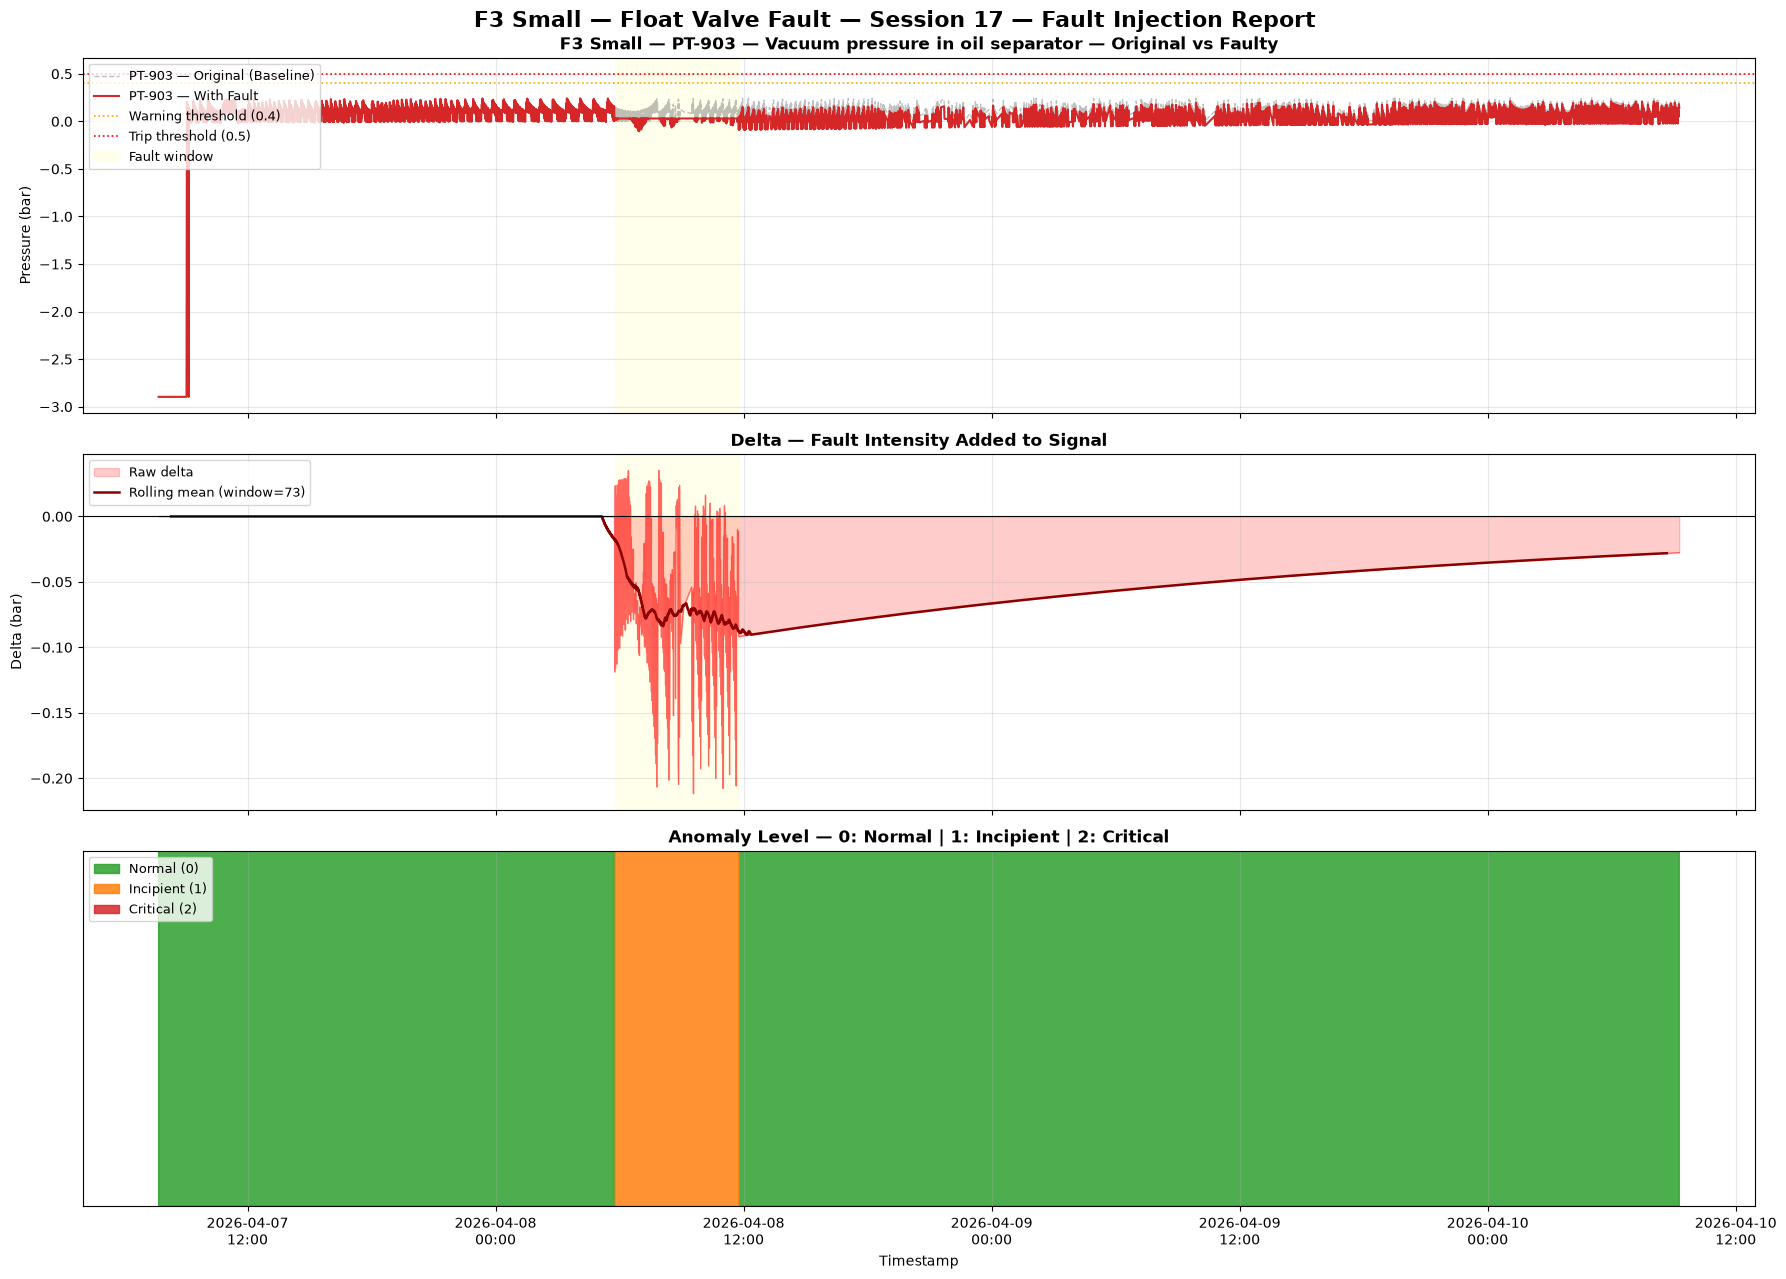

In [37]:
""" F3 Small — Fault Profile Verification Plot — Session 17 """

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 13), sharex=True)

# ============================================================
# PANEL 1 — Original vs Faulty PT-903
# ============================================================

f3_small_s17_fault_start_timestamp = f3_small_s17_df.index[f3_small_s17_start_idx]
f3_small_s17_fault_end_timestamp = f3_small_s17_df.index[f3_small_s17_end_idx - 1]

ax1.plot(
    f3_small_s17_df_orig.index,
    f3_small_s17_df_orig["PT-903"],
    color="gray",
    alpha=0.5,
    linestyle="--",
    linewidth=1.0,
    label="PT-903 — Original (Baseline)"
)

ax1.plot(
    f3_small_s17_df.index,
    f3_small_s17_df["PT-903"],
    color="#d62728",
    linewidth=1.5,
    label="PT-903 — With Fault"
)

ax1.axhline(
    y=pt903_warning,
    color="orange",
    linestyle=":",
    linewidth=1.2,
    label=f"Warning threshold ({pt903_warning})"
)

ax1.axhline(
    y=pt903_trip,
    color="red",
    linestyle=":",
    linewidth=1.2,
    label=f"Trip threshold ({pt903_trip})"
)

ax1.axvspan(
    f3_small_s17_fault_start_timestamp,
    f3_small_s17_fault_end_timestamp,
    color="yellow",
    alpha=0.08,
    label="Fault window"
)

ax1.set_title("F3 Small — PT-903 — Vacuum pressure in oil separator — Original vs Faulty", fontweight="bold")
ax1.set_ylabel("Pressure (bar)")
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(True, alpha=0.3)

# ============================================================
# PANEL 2 — Delta (fault intensity)
# ============================================================

f3_small_s17_delta_full = f3_small_s17_df["PT-903"] - f3_small_s17_df_orig["PT-903"]
f3_small_s17_roll_window = max(10, len(f3_small_s17_delta_full) // 60)
f3_small_s17_delta_rolling_mean = f3_small_s17_delta_full.rolling(f3_small_s17_roll_window, center=True).mean()

ax2.fill_between(
    f3_small_s17_df.index,
    0,
    f3_small_s17_delta_full,
    color="red",
    alpha=0.2,
    label="Raw delta"
)

ax2.plot(
    f3_small_s17_df.index,
    f3_small_s17_delta_full,
    color="red",
    linewidth=0.8,
    alpha=0.5
)

ax2.plot(
    f3_small_s17_df.index,
    f3_small_s17_delta_rolling_mean,
    color="#8B0000",
    linewidth=1.8,
    label=f"Rolling mean (window={f3_small_s17_roll_window})"
)

ax2.axhline(y=0, color="black", linewidth=0.8)
ax2.axvspan(f3_small_s17_fault_start_timestamp, f3_small_s17_fault_end_timestamp, color="yellow", alpha=0.08)
ax2.set_title("Delta — Fault Intensity Added to Signal", fontweight="bold")
ax2.set_ylabel("Delta (bar)")
ax2.legend(loc="upper left", fontsize=9)
ax2.grid(True, alpha=0.3)

# ============================================================
# PANEL 3 — Anomaly level bar
# ============================================================

f3_small_s17_normal_mask = f3_small_s17_df["anomaly_level"] == 0
f3_small_s17_incipient_mask = f3_small_s17_df["anomaly_level"] == 1
f3_small_s17_critical_mask = f3_small_s17_df["anomaly_level"] == 2

ax3.fill_between(f3_small_s17_df.index, 0, 1, where=f3_small_s17_normal_mask, color="#2ca02c", step="mid", alpha=0.85, label="Normal (0)")
ax3.fill_between(f3_small_s17_df.index, 0, 1, where=f3_small_s17_incipient_mask, color="#ff7f0e", step="mid", alpha=0.85, label="Incipient (1)")
ax3.fill_between(f3_small_s17_df.index, 0, 1, where=f3_small_s17_critical_mask, color="#d62728", step="mid", alpha=0.85, label="Critical (2)")

ax3.set_yticks([])
ax3.set_ylim(0, 1)
ax3.set_xlabel("Timestamp")
ax3.set_title("Anomaly Level — 0: Normal | 1: Incipient | 2: Critical", fontweight="bold")
ax3.legend(loc="upper left", fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))

fig.suptitle("F3 Small — Float Valve Fault — Session 17 — Fault Injection Report", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


#### Medium - Session 17

In [38]:
""" F3 Medium — Float Valve Fault — Session 17 """

np.random.seed(42)

f3_medium_s17_df_orig = dict_sessions[17].copy()
f3_medium_s17_main_sensor = "PT-903"
f3_medium_s17_length_hours = 10
f3_medium_s17_start_from = 0.45

# FAULT WINDOW
f3_medium_s17_session_length = len(f3_medium_s17_df_orig)
f3_medium_s17_start_idx = int(round(f3_medium_s17_session_length * f3_medium_s17_start_from))
f3_medium_s17_end_idx = min(f3_medium_s17_start_idx + int(round(f3_medium_s17_length_hours * 60)), f3_medium_s17_session_length)
f3_medium_s17_total_l = f3_medium_s17_end_idx - f3_medium_s17_start_idx
print("Session 17 length:", f3_medium_s17_session_length, "rows")
print("Fault start index:", f3_medium_s17_start_idx)
print("Fault end index:", f3_medium_s17_end_idx)
print("Fault window length:", f3_medium_s17_total_l, "rows")

# BASELINE STATISTICS
f3_medium_s17_baseline_mean = f3_medium_s17_df_orig["PT-903"].iloc[:f3_medium_s17_start_idx].mean()
f3_medium_s17_baseline_std = f3_medium_s17_df_orig["PT-903"].iloc[:f3_medium_s17_start_idx].std()
print("\nPT-903 baseline mean:", round(f3_medium_s17_baseline_mean, 4))
print("PT-903 baseline std:", round(f3_medium_s17_baseline_std, 4))

# SEVERITY TARGET — medium reaches the warning-to-trip interval
f3_medium_s17_target = pt903_warning + medium_trip_fraction * (pt903_trip - pt903_warning)
f3_medium_s17_delta_mag = f3_medium_s17_target - f3_medium_s17_baseline_mean
print("PT-903 medium target:", round(f3_medium_s17_target, 4))
print("PT-903 delta magnitude:", round(f3_medium_s17_delta_mag, 4))

# RAW DELTA SHAPE — growing oscillation with capped noise
f3_medium_s17_period_samples = 30
f3_medium_s17_t = np.arange(f3_medium_s17_total_l)
f3_medium_s17_envelope = np.linspace(0.1, 1.0, f3_medium_s17_total_l)
f3_medium_s17_noise_std = min(f3_medium_s17_baseline_std * 0.50, abs(f3_medium_s17_delta_mag) * 0.15)
f3_medium_s17_noise = np.random.normal(0, f3_medium_s17_noise_std, f3_medium_s17_total_l)
f3_medium_s17_delta = f3_medium_s17_delta_mag * np.sin(2 * np.pi * f3_medium_s17_t / f3_medium_s17_period_samples) * f3_medium_s17_envelope + f3_medium_s17_noise

# TARGET ALIGNMENT — keep severity ordered against the absolute target
f3_medium_s17_active_values = f3_medium_s17_df_orig["PT-903"].iloc[f3_medium_s17_start_idx:f3_medium_s17_end_idx].to_numpy()
f3_medium_s17_positive_peak_idx = int(np.argmax(f3_medium_s17_delta))
if False:
    f3_medium_s17_delta = np.maximum(f3_medium_s17_delta, 0)

if f3_medium_s17_delta[f3_medium_s17_positive_peak_idx] > 0:
    f3_medium_s17_desired_peak_delta = f3_medium_s17_target - f3_medium_s17_active_values[f3_medium_s17_positive_peak_idx]
    if f3_medium_s17_desired_peak_delta > 0:
        f3_medium_s17_delta = f3_medium_s17_delta * (f3_medium_s17_desired_peak_delta / f3_medium_s17_delta[f3_medium_s17_positive_peak_idx])

f3_medium_s17_upper_delta = f3_medium_s17_target - f3_medium_s17_active_values
f3_medium_s17_delta = np.minimum(f3_medium_s17_delta, f3_medium_s17_upper_delta)
if False:
    f3_medium_s17_delta = np.maximum(f3_medium_s17_delta, 0)

# CORRELATION COMPUTED EXPLICITLY
f3_medium_s17_corr_threshold = 0.7
f3_medium_s17_corr = f3_medium_s17_df_orig.corr(method="pearson", numeric_only=True)["PT-903"]
f3_medium_s17_corr_sensors = f3_medium_s17_corr[abs(f3_medium_s17_corr) >= f3_medium_s17_corr_threshold].index.tolist()
print("\nCorrelated sensors (|r| >=", f3_medium_s17_corr_threshold, "):", f3_medium_s17_corr_sensors)

# APPLY INJECTION EXPLICITLY SENSOR BY SENSOR
f3_medium_s17_df = f3_medium_s17_df_orig.copy()
f3_medium_s17_propagation_scale = 0.2
for sensor in f3_medium_s17_corr_sensors:
    if sensor in f3_medium_s17_df.columns:
        scale = 1.0 if sensor == f3_medium_s17_main_sensor else f3_medium_s17_propagation_scale
        f3_medium_s17_df.iloc[f3_medium_s17_start_idx:f3_medium_s17_end_idx, f3_medium_s17_df.columns.get_loc(sensor)] += f3_medium_s17_delta * f3_medium_s17_corr[sensor] * scale

# DECAY / STABILIZATION PHASE
f3_medium_s17_remaining = f3_medium_s17_session_length - f3_medium_s17_end_idx
if f3_medium_s17_remaining > 0:
    f3_medium_s17_decay_rate = 0.3
    f3_medium_s17_decay = f3_medium_s17_delta[-1] * np.exp(-f3_medium_s17_decay_rate * np.linspace(0, 1, f3_medium_s17_remaining))
    for sensor in f3_medium_s17_corr_sensors:
        if sensor in f3_medium_s17_df.columns:
            scale = 1.0 if sensor == f3_medium_s17_main_sensor else f3_medium_s17_propagation_scale
            f3_medium_s17_df.iloc[f3_medium_s17_end_idx:, f3_medium_s17_df.columns.get_loc(sensor)] += f3_medium_s17_decay * f3_medium_s17_corr[sensor] * scale

# SEVERITY CAP — small/medium should not drift beyond their target during stabilization
f3_medium_s17_main_sensor_loc = f3_medium_s17_df.columns.get_loc("PT-903")
f3_medium_s17_df.iloc[f3_medium_s17_start_idx:, f3_medium_s17_main_sensor_loc] = np.minimum(
    f3_medium_s17_df.iloc[f3_medium_s17_start_idx:, f3_medium_s17_main_sensor_loc],
    f3_medium_s17_target,
)

# LABELS — medium/severe faults are labelled from injection start through stabilization
f3_medium_s17_df["anomaly_level"] = 0
f3_medium_s17_df["is_injected_anomaly"] = 0
f3_medium_s17_df["anomaly_type"] = "normal"
f3_medium_s17_injected_values = f3_medium_s17_df["PT-903"].iloc[f3_medium_s17_start_idx:]
f3_medium_s17_labels = np.where(
    f3_medium_s17_injected_values >= pt903_trip, 2,
    np.where(f3_medium_s17_injected_values >= pt903_warning, 1, 0)
)
f3_medium_s17_df.iloc[f3_medium_s17_start_idx:, f3_medium_s17_df.columns.get_loc("anomaly_level")] = f3_medium_s17_labels
f3_medium_s17_df.iloc[f3_medium_s17_start_idx:, f3_medium_s17_df.columns.get_loc("is_injected_anomaly")] = 1
f3_medium_s17_df.iloc[f3_medium_s17_start_idx:, f3_medium_s17_df.columns.get_loc("anomaly_type")] = "valve_fault"

# SAVE CSV
f3_medium_s17_df.to_csv(f"{output_dir_single}/session_17_F3_medium.csv")
print("\nSession 17 F3 medium saved")
print("Anomaly rows:", int(f3_medium_s17_df["is_injected_anomaly"].sum()))
print("Normal rows:", int((f3_medium_s17_df["is_injected_anomaly"] == 0).sum()))
print("Level 1 rows:", int((f3_medium_s17_df["anomaly_level"] == 1).sum()))
print("Level 2 rows:", int((f3_medium_s17_df["anomaly_level"] == 2).sum()))


Session 17 length: 4415 rows
Fault start index: 1987
Fault end index: 2587
Fault window length: 600 rows

PT-903 baseline mean: -0.0304
PT-903 baseline std: 0.6026
PT-903 medium target: 0.455
PT-903 delta magnitude: 0.4854

Correlated sensors (|r| >= 0.7 ): ['PT-903', 'pt903_frozen_flag']


/var/folders/df/cfzb18t5629c221k8xlry1dw0000gn/T/ipykernel_38570/2091698572.py:68: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-4.64794490e-03 -2.27017669e-05 -8.67424426e-03 -1.80836089e-02
 -2.72348456e-03 -3.61744168e-03 -2.12450895e-02 -1.40377793e-02
 -2.55676273e-03 -1.18121595e-02 -1.87783690e-03 -1.04412056e-03
 -6.59200627e-03  1.48703653e-02  1.45708856e-02  5.26154014e-03
  1.10862569e-02  2.44892960e-04  1.31551610e-02  1.91748402e-02
 -6.68869773e-03  9.91760342e-03  7.62295963e-03  2.16799790e-02
  1.31663537e-02  6.39385794e-03  1.72172461e-02  1.63871911e-03
  9.22519041e-03  4.59163628e-03  5.63039963e-03 -1.92335987e-02
 -3.63097882e-03  4.41257850e-03 -1.47010660e-02  3.18037319e-03
 -1.10964834e-02  8.68428941e-03  2.68203405e-03 -1.12516005e-02
 -1.55595074e-02 -9.09534143e-03 -4.89850141e-03 -1.35909264e-03
  1.16806380e-02  6.73585844e-03  6.50380842e-03 -5.56276902e-03
  3.0958


Session 17 F3 medium saved
Anomaly rows: 2428
Normal rows: 1987
Level 1 rows: 11
Level 2 rows: 0


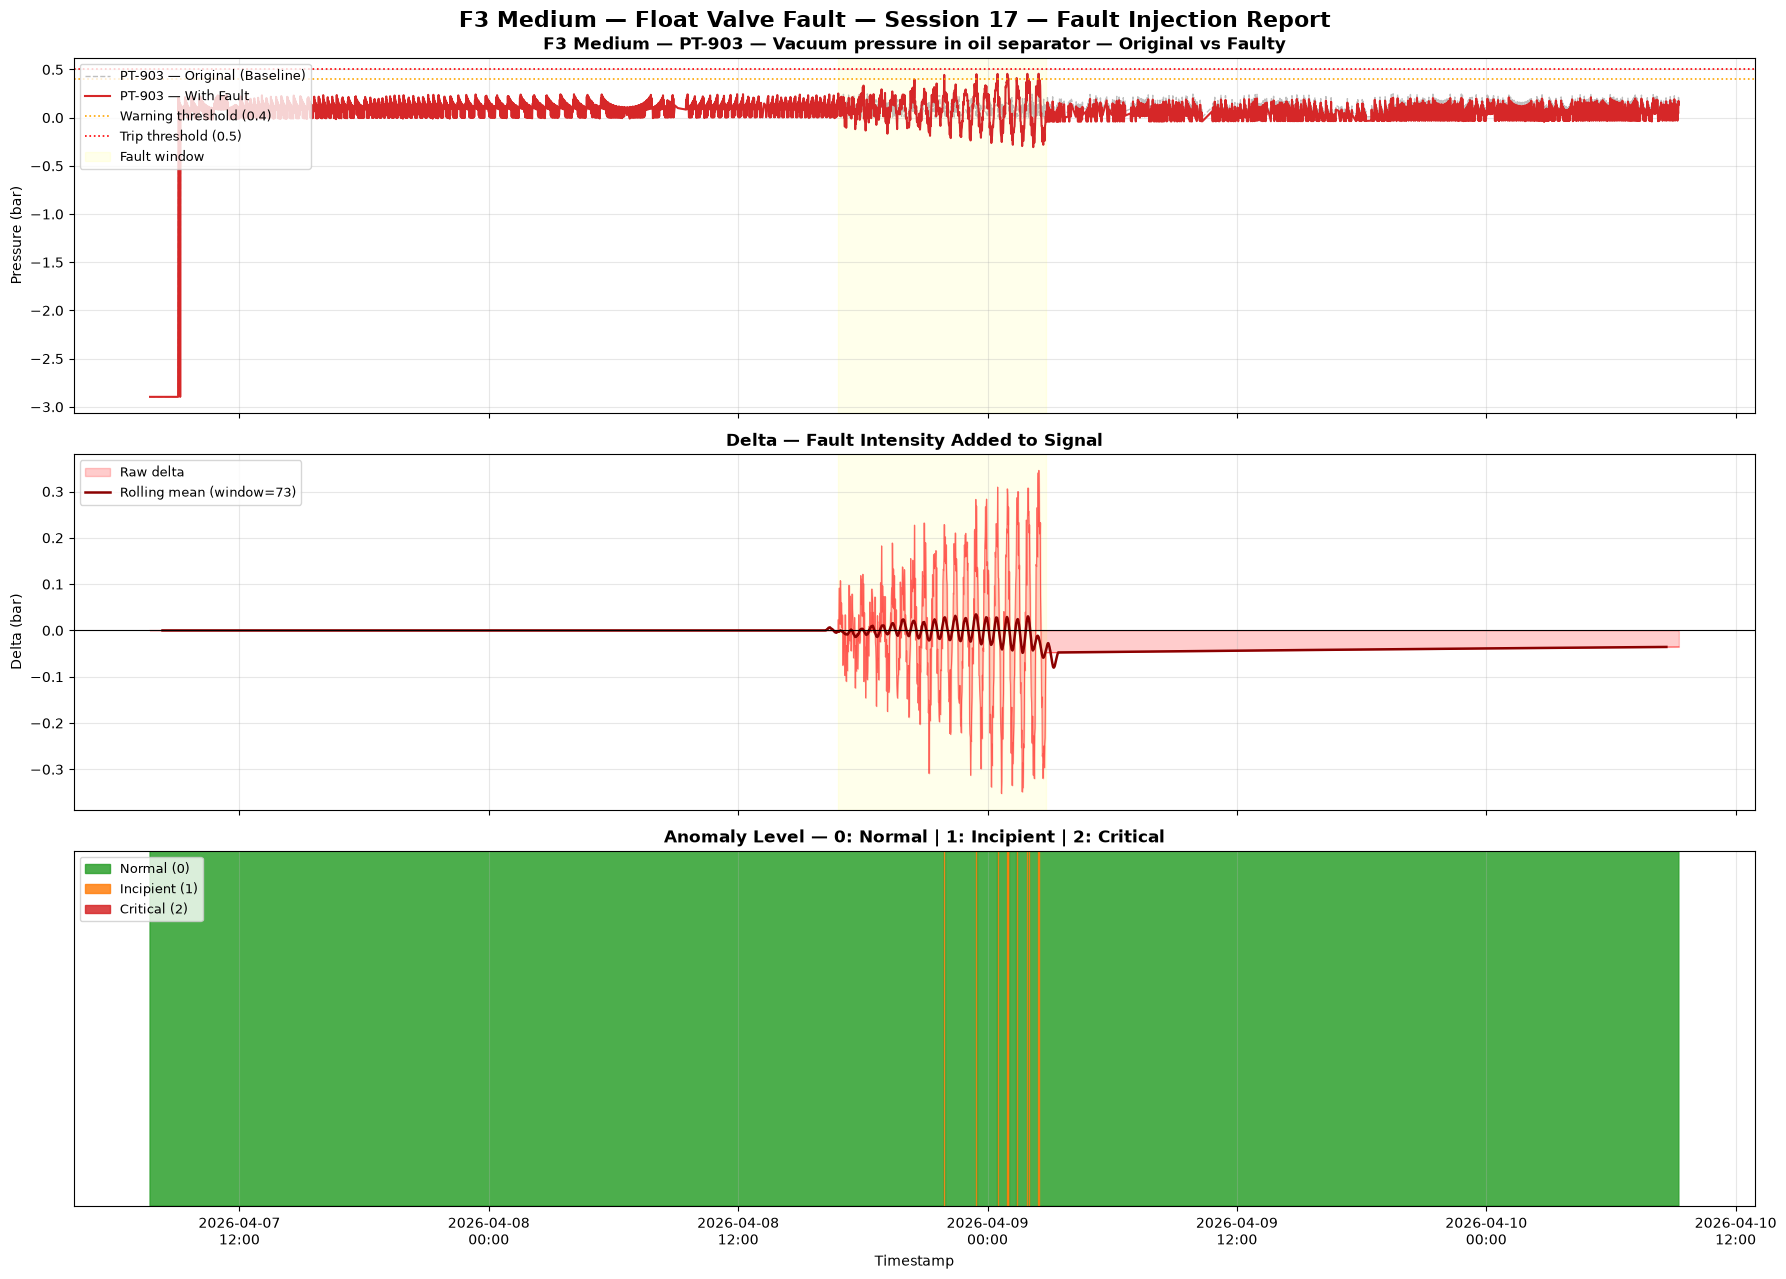

In [39]:
""" F3 Medium — Fault Profile Verification Plot — Session 17 """

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 13), sharex=True)

# ============================================================
# PANEL 1 — Original vs Faulty PT-903
# ============================================================

f3_medium_s17_fault_start_timestamp = f3_medium_s17_df.index[f3_medium_s17_start_idx]
f3_medium_s17_fault_end_timestamp = f3_medium_s17_df.index[f3_medium_s17_end_idx - 1]

ax1.plot(
    f3_medium_s17_df_orig.index,
    f3_medium_s17_df_orig["PT-903"],
    color="gray",
    alpha=0.5,
    linestyle="--",
    linewidth=1.0,
    label="PT-903 — Original (Baseline)"
)

ax1.plot(
    f3_medium_s17_df.index,
    f3_medium_s17_df["PT-903"],
    color="#d62728",
    linewidth=1.5,
    label="PT-903 — With Fault"
)

ax1.axhline(
    y=pt903_warning,
    color="orange",
    linestyle=":",
    linewidth=1.2,
    label=f"Warning threshold ({pt903_warning})"
)

ax1.axhline(
    y=pt903_trip,
    color="red",
    linestyle=":",
    linewidth=1.2,
    label=f"Trip threshold ({pt903_trip})"
)

ax1.axvspan(
    f3_medium_s17_fault_start_timestamp,
    f3_medium_s17_fault_end_timestamp,
    color="yellow",
    alpha=0.08,
    label="Fault window"
)

ax1.set_title("F3 Medium — PT-903 — Vacuum pressure in oil separator — Original vs Faulty", fontweight="bold")
ax1.set_ylabel("Pressure (bar)")
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(True, alpha=0.3)

# ============================================================
# PANEL 2 — Delta (fault intensity)
# ============================================================

f3_medium_s17_delta_full = f3_medium_s17_df["PT-903"] - f3_medium_s17_df_orig["PT-903"]
f3_medium_s17_roll_window = max(10, len(f3_medium_s17_delta_full) // 60)
f3_medium_s17_delta_rolling_mean = f3_medium_s17_delta_full.rolling(f3_medium_s17_roll_window, center=True).mean()

ax2.fill_between(
    f3_medium_s17_df.index,
    0,
    f3_medium_s17_delta_full,
    color="red",
    alpha=0.2,
    label="Raw delta"
)

ax2.plot(
    f3_medium_s17_df.index,
    f3_medium_s17_delta_full,
    color="red",
    linewidth=0.8,
    alpha=0.5
)

ax2.plot(
    f3_medium_s17_df.index,
    f3_medium_s17_delta_rolling_mean,
    color="#8B0000",
    linewidth=1.8,
    label=f"Rolling mean (window={f3_medium_s17_roll_window})"
)

ax2.axhline(y=0, color="black", linewidth=0.8)
ax2.axvspan(f3_medium_s17_fault_start_timestamp, f3_medium_s17_fault_end_timestamp, color="yellow", alpha=0.08)
ax2.set_title("Delta — Fault Intensity Added to Signal", fontweight="bold")
ax2.set_ylabel("Delta (bar)")
ax2.legend(loc="upper left", fontsize=9)
ax2.grid(True, alpha=0.3)

# ============================================================
# PANEL 3 — Anomaly level bar
# ============================================================

f3_medium_s17_normal_mask = f3_medium_s17_df["anomaly_level"] == 0
f3_medium_s17_incipient_mask = f3_medium_s17_df["anomaly_level"] == 1
f3_medium_s17_critical_mask = f3_medium_s17_df["anomaly_level"] == 2

ax3.fill_between(f3_medium_s17_df.index, 0, 1, where=f3_medium_s17_normal_mask, color="#2ca02c", step="mid", alpha=0.85, label="Normal (0)")
ax3.fill_between(f3_medium_s17_df.index, 0, 1, where=f3_medium_s17_incipient_mask, color="#ff7f0e", step="mid", alpha=0.85, label="Incipient (1)")
ax3.fill_between(f3_medium_s17_df.index, 0, 1, where=f3_medium_s17_critical_mask, color="#d62728", step="mid", alpha=0.85, label="Critical (2)")

ax3.set_yticks([])
ax3.set_ylim(0, 1)
ax3.set_xlabel("Timestamp")
ax3.set_title("Anomaly Level — 0: Normal | 1: Incipient | 2: Critical", fontweight="bold")
ax3.legend(loc="upper left", fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))

fig.suptitle("F3 Medium — Float Valve Fault — Session 17 — Fault Injection Report", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


#### Severe - Session 17

In [40]:
""" F3 Severe — Float Valve Fault — Session 17 """

np.random.seed(42)

f3_severe_s17_df_orig = dict_sessions[17].copy()
f3_severe_s17_main_sensor = "PT-903"
f3_severe_s17_length_hours = 12
f3_severe_s17_start_from = 0.55

# FAULT WINDOW
f3_severe_s17_session_length = len(f3_severe_s17_df_orig)
f3_severe_s17_start_idx = int(round(f3_severe_s17_session_length * f3_severe_s17_start_from))
f3_severe_s17_end_idx = min(f3_severe_s17_start_idx + int(round(f3_severe_s17_length_hours * 60)), f3_severe_s17_session_length)
f3_severe_s17_total_l = f3_severe_s17_end_idx - f3_severe_s17_start_idx
print("Session 17 length:", f3_severe_s17_session_length, "rows")
print("Fault start index:", f3_severe_s17_start_idx)
print("Fault end index:", f3_severe_s17_end_idx)
print("Fault window length:", f3_severe_s17_total_l, "rows")

# BASELINE STATISTICS
f3_severe_s17_baseline_mean = f3_severe_s17_df_orig["PT-903"].iloc[:f3_severe_s17_start_idx].mean()
f3_severe_s17_baseline_std = f3_severe_s17_df_orig["PT-903"].iloc[:f3_severe_s17_start_idx].std()
print("\nPT-903 baseline mean:", round(f3_severe_s17_baseline_mean, 4))
print("PT-903 baseline std:", round(f3_severe_s17_baseline_std, 4))

# SEVERITY TARGET — severe reaches trip level
f3_severe_s17_target = pt903_trip
f3_severe_s17_delta_mag = f3_severe_s17_target - f3_severe_s17_baseline_mean
print("PT-903 severe target:", round(f3_severe_s17_target, 4))
print("PT-903 delta magnitude:", round(f3_severe_s17_delta_mag, 4))

# RAW DELTA SHAPE — growing oscillation with capped noise
f3_severe_s17_period_samples = 30
f3_severe_s17_t = np.arange(f3_severe_s17_total_l)
f3_severe_s17_envelope = np.linspace(0.1, 1.0, f3_severe_s17_total_l)
f3_severe_s17_noise_std = min(f3_severe_s17_baseline_std * 0.50, abs(f3_severe_s17_delta_mag) * 0.15)
f3_severe_s17_noise = np.random.normal(0, f3_severe_s17_noise_std, f3_severe_s17_total_l)
f3_severe_s17_delta = f3_severe_s17_delta_mag * np.sin(2 * np.pi * f3_severe_s17_t / f3_severe_s17_period_samples) * f3_severe_s17_envelope + f3_severe_s17_noise

# TARGET ALIGNMENT — keep severity ordered against the absolute target
f3_severe_s17_active_values = f3_severe_s17_df_orig["PT-903"].iloc[f3_severe_s17_start_idx:f3_severe_s17_end_idx].to_numpy()
f3_severe_s17_positive_peak_idx = int(np.argmax(f3_severe_s17_delta))
if False:
    f3_severe_s17_delta = np.maximum(f3_severe_s17_delta, 0)

if f3_severe_s17_delta[f3_severe_s17_positive_peak_idx] > 0:
    f3_severe_s17_desired_peak_delta = f3_severe_s17_target - f3_severe_s17_active_values[f3_severe_s17_positive_peak_idx]
    if f3_severe_s17_desired_peak_delta > 0:
        f3_severe_s17_delta = f3_severe_s17_delta * (f3_severe_s17_desired_peak_delta / f3_severe_s17_delta[f3_severe_s17_positive_peak_idx])

f3_severe_s17_upper_delta = f3_severe_s17_target - f3_severe_s17_active_values
f3_severe_s17_delta = np.minimum(f3_severe_s17_delta, f3_severe_s17_upper_delta)
if False:
    f3_severe_s17_delta = np.maximum(f3_severe_s17_delta, 0)

# CORRELATION COMPUTED EXPLICITLY
f3_severe_s17_corr_threshold = 0.7
f3_severe_s17_corr = f3_severe_s17_df_orig.corr(method="pearson", numeric_only=True)["PT-903"]
f3_severe_s17_corr_sensors = f3_severe_s17_corr[abs(f3_severe_s17_corr) >= f3_severe_s17_corr_threshold].index.tolist()
print("\nCorrelated sensors (|r| >=", f3_severe_s17_corr_threshold, "):", f3_severe_s17_corr_sensors)

# APPLY INJECTION EXPLICITLY SENSOR BY SENSOR
f3_severe_s17_df = f3_severe_s17_df_orig.copy()
f3_severe_s17_propagation_scale = 0.2
for sensor in f3_severe_s17_corr_sensors:
    if sensor in f3_severe_s17_df.columns:
        scale = 1.0 if sensor == f3_severe_s17_main_sensor else f3_severe_s17_propagation_scale
        f3_severe_s17_df.iloc[f3_severe_s17_start_idx:f3_severe_s17_end_idx, f3_severe_s17_df.columns.get_loc(sensor)] += f3_severe_s17_delta * f3_severe_s17_corr[sensor] * scale

# DECAY / STABILIZATION PHASE
f3_severe_s17_remaining = f3_severe_s17_session_length - f3_severe_s17_end_idx
if f3_severe_s17_remaining > 0:
    f3_severe_s17_decay_rate = 0.3
    f3_severe_s17_decay = f3_severe_s17_delta[-1] * np.exp(-f3_severe_s17_decay_rate * np.linspace(0, 1, f3_severe_s17_remaining))
    for sensor in f3_severe_s17_corr_sensors:
        if sensor in f3_severe_s17_df.columns:
            scale = 1.0 if sensor == f3_severe_s17_main_sensor else f3_severe_s17_propagation_scale
            f3_severe_s17_df.iloc[f3_severe_s17_end_idx:, f3_severe_s17_df.columns.get_loc(sensor)] += f3_severe_s17_decay * f3_severe_s17_corr[sensor] * scale

# LABELS — medium/severe faults are labelled from injection start through stabilization
f3_severe_s17_df["anomaly_level"] = 0
f3_severe_s17_df["is_injected_anomaly"] = 0
f3_severe_s17_df["anomaly_type"] = "normal"
f3_severe_s17_injected_values = f3_severe_s17_df["PT-903"].iloc[f3_severe_s17_start_idx:]
f3_severe_s17_labels = np.where(
    f3_severe_s17_injected_values >= pt903_trip, 2,
    np.where(f3_severe_s17_injected_values >= pt903_warning, 1, 0)
)
f3_severe_s17_df.iloc[f3_severe_s17_start_idx:, f3_severe_s17_df.columns.get_loc("anomaly_level")] = f3_severe_s17_labels
f3_severe_s17_df.iloc[f3_severe_s17_start_idx:, f3_severe_s17_df.columns.get_loc("is_injected_anomaly")] = 1
f3_severe_s17_df.iloc[f3_severe_s17_start_idx:, f3_severe_s17_df.columns.get_loc("anomaly_type")] = "valve_fault"

# SAVE CSV
f3_severe_s17_df.to_csv(f"{output_dir_single}/session_17_F3_severe.csv")
print("\nSession 17 F3 severe saved")
print("Anomaly rows:", int(f3_severe_s17_df["is_injected_anomaly"].sum()))
print("Normal rows:", int((f3_severe_s17_df["is_injected_anomaly"] == 0).sum()))
print("Level 1 rows:", int((f3_severe_s17_df["anomaly_level"] == 1).sum()))
print("Level 2 rows:", int((f3_severe_s17_df["anomaly_level"] == 2).sum()))


Session 17 length: 4415 rows
Fault start index: 2428
Fault end index: 3148
Fault window length: 720 rows

PT-903 baseline mean: -0.0077
PT-903 baseline std: 0.5478
PT-903 severe target: 0.5
PT-903 delta magnitude: 0.5077

Correlated sensors (|r| >= 0.7 ): ['PT-903', 'pt903_frozen_flag']


/var/folders/df/cfzb18t5629c221k8xlry1dw0000gn/T/ipykernel_38570/707577732.py:68: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-5.45429834e-03 -2.28235058e-05 -1.01641711e-02 -2.11884916e-02
 -3.14140246e-03 -4.16552772e-03 -2.48260623e-02 -1.63453404e-02
 -2.85427130e-03 -1.37042744e-02 -2.04463634e-03 -1.07519730e-03
 -7.60614526e-03  1.75472314e-02  1.71521643e-02  6.17434377e-03
  1.29485002e-02  1.60446395e-04  1.52431746e-02  2.22422060e-02
 -8.16705124e-03  1.12715332e-02  8.54378799e-03  2.50212468e-02
  1.50315197e-02  7.10565535e-03  1.98495018e-02  1.63167968e-03
  1.06165673e-02  5.27753665e-03  6.60719521e-03 -2.24520414e-02
 -4.02197191e-03  5.53417439e-03 -1.67876624e-02  4.28854997e-03
 -1.23930497e-02  1.08663919e-02  3.84108597e-03 -1.25227009e-02
 -1.76229483e-02 -1.01139281e-02 -5.29513624e-03 -1.27381274e-03
  1.38750001e-02  7.90443567e-03  7.45656001e-03 -6.87876148e-03
  3.11501


Session 17 F3 severe saved
Anomaly rows: 1987
Normal rows: 2428
Level 1 rows: 23
Level 2 rows: 4


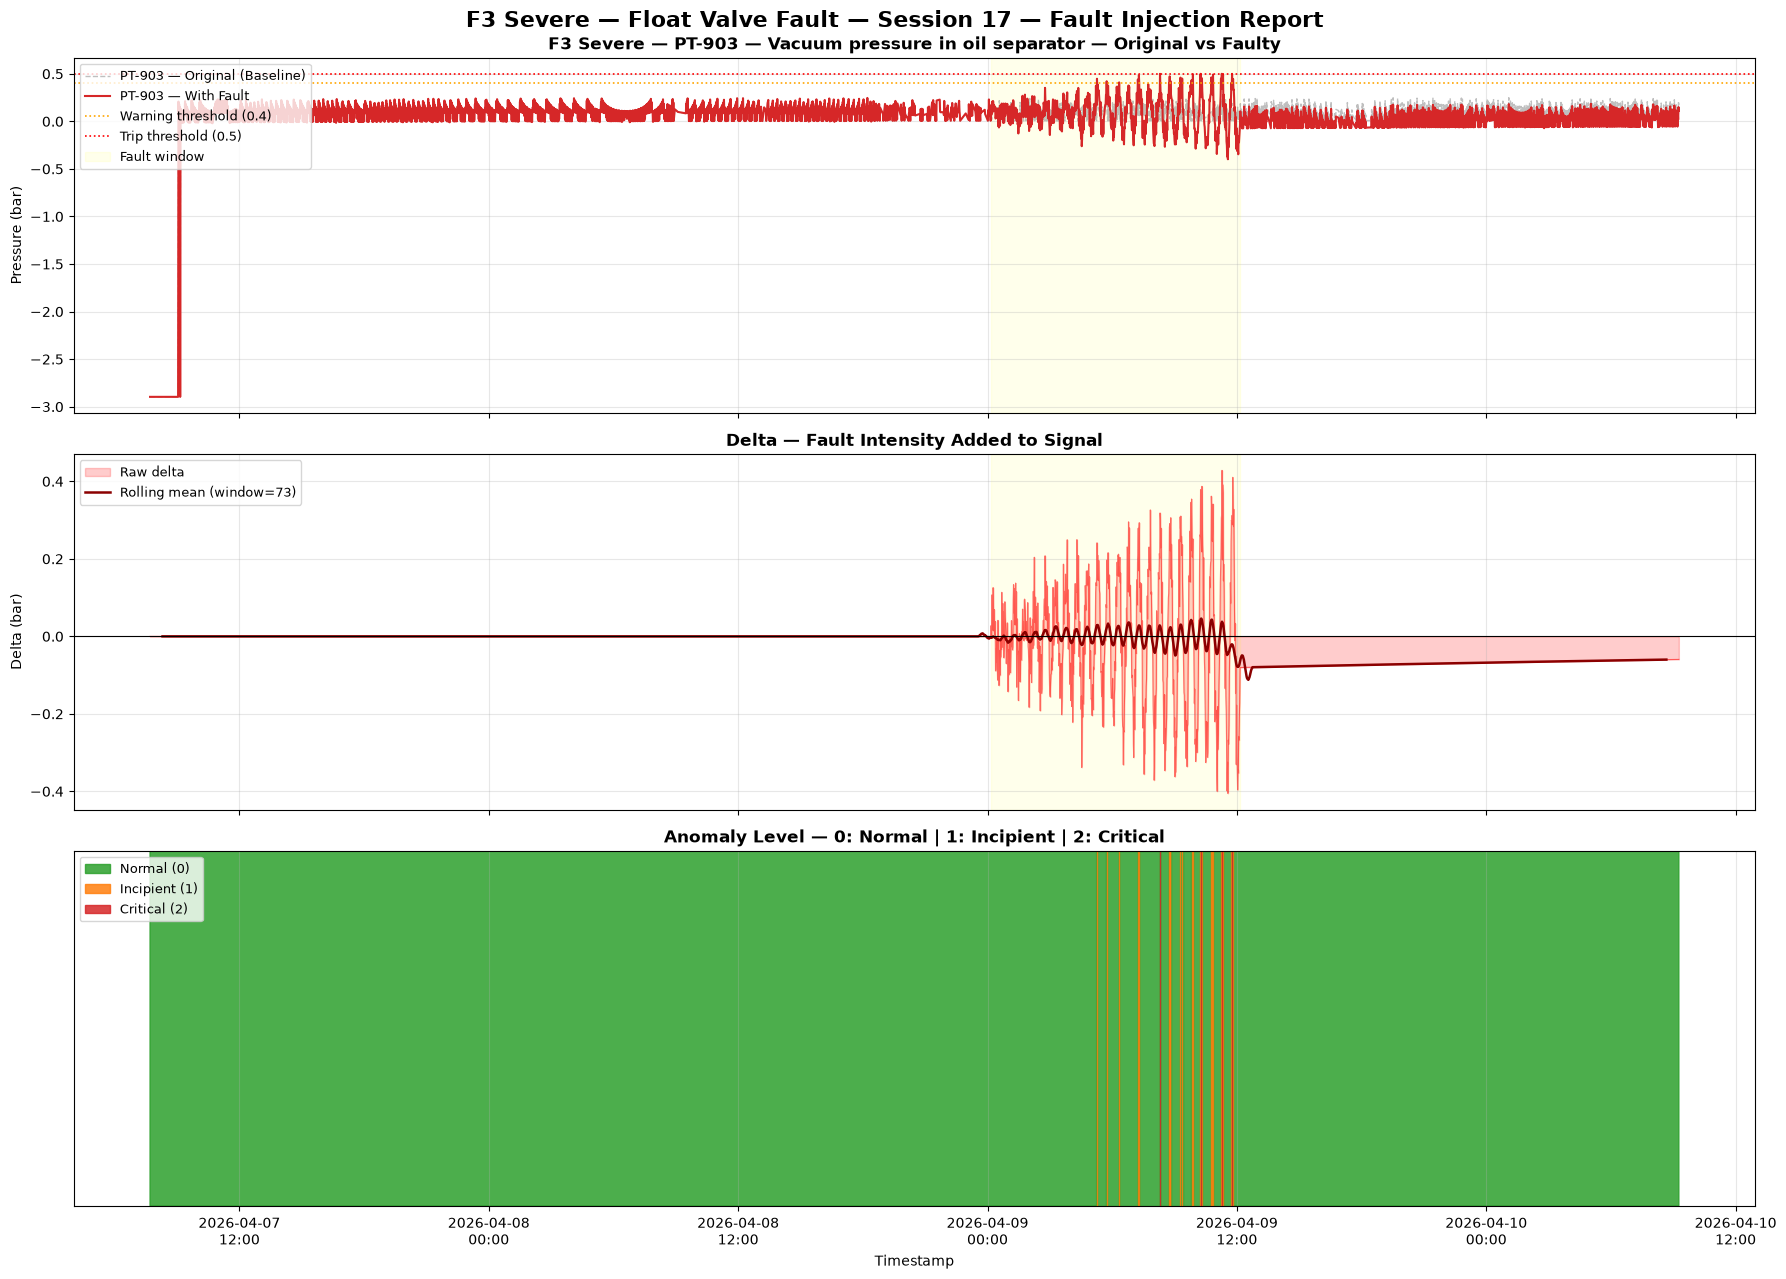

In [41]:
""" F3 Severe — Fault Profile Verification Plot — Session 17 """

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 13), sharex=True)

# ============================================================
# PANEL 1 — Original vs Faulty PT-903
# ============================================================

f3_severe_s17_fault_start_timestamp = f3_severe_s17_df.index[f3_severe_s17_start_idx]
f3_severe_s17_fault_end_timestamp = f3_severe_s17_df.index[f3_severe_s17_end_idx - 1]

ax1.plot(
    f3_severe_s17_df_orig.index,
    f3_severe_s17_df_orig["PT-903"],
    color="gray",
    alpha=0.5,
    linestyle="--",
    linewidth=1.0,
    label="PT-903 — Original (Baseline)"
)

ax1.plot(
    f3_severe_s17_df.index,
    f3_severe_s17_df["PT-903"],
    color="#d62728",
    linewidth=1.5,
    label="PT-903 — With Fault"
)

ax1.axhline(
    y=pt903_warning,
    color="orange",
    linestyle=":",
    linewidth=1.2,
    label=f"Warning threshold ({pt903_warning})"
)

ax1.axhline(
    y=pt903_trip,
    color="red",
    linestyle=":",
    linewidth=1.2,
    label=f"Trip threshold ({pt903_trip})"
)

ax1.axvspan(
    f3_severe_s17_fault_start_timestamp,
    f3_severe_s17_fault_end_timestamp,
    color="yellow",
    alpha=0.08,
    label="Fault window"
)

ax1.set_title("F3 Severe — PT-903 — Vacuum pressure in oil separator — Original vs Faulty", fontweight="bold")
ax1.set_ylabel("Pressure (bar)")
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(True, alpha=0.3)

# ============================================================
# PANEL 2 — Delta (fault intensity)
# ============================================================

f3_severe_s17_delta_full = f3_severe_s17_df["PT-903"] - f3_severe_s17_df_orig["PT-903"]
f3_severe_s17_roll_window = max(10, len(f3_severe_s17_delta_full) // 60)
f3_severe_s17_delta_rolling_mean = f3_severe_s17_delta_full.rolling(f3_severe_s17_roll_window, center=True).mean()

ax2.fill_between(
    f3_severe_s17_df.index,
    0,
    f3_severe_s17_delta_full,
    color="red",
    alpha=0.2,
    label="Raw delta"
)

ax2.plot(
    f3_severe_s17_df.index,
    f3_severe_s17_delta_full,
    color="red",
    linewidth=0.8,
    alpha=0.5
)

ax2.plot(
    f3_severe_s17_df.index,
    f3_severe_s17_delta_rolling_mean,
    color="#8B0000",
    linewidth=1.8,
    label=f"Rolling mean (window={f3_severe_s17_roll_window})"
)

ax2.axhline(y=0, color="black", linewidth=0.8)
ax2.axvspan(f3_severe_s17_fault_start_timestamp, f3_severe_s17_fault_end_timestamp, color="yellow", alpha=0.08)
ax2.set_title("Delta — Fault Intensity Added to Signal", fontweight="bold")
ax2.set_ylabel("Delta (bar)")
ax2.legend(loc="upper left", fontsize=9)
ax2.grid(True, alpha=0.3)

# ============================================================
# PANEL 3 — Anomaly level bar
# ============================================================

f3_severe_s17_normal_mask = f3_severe_s17_df["anomaly_level"] == 0
f3_severe_s17_incipient_mask = f3_severe_s17_df["anomaly_level"] == 1
f3_severe_s17_critical_mask = f3_severe_s17_df["anomaly_level"] == 2

ax3.fill_between(f3_severe_s17_df.index, 0, 1, where=f3_severe_s17_normal_mask, color="#2ca02c", step="mid", alpha=0.85, label="Normal (0)")
ax3.fill_between(f3_severe_s17_df.index, 0, 1, where=f3_severe_s17_incipient_mask, color="#ff7f0e", step="mid", alpha=0.85, label="Incipient (1)")
ax3.fill_between(f3_severe_s17_df.index, 0, 1, where=f3_severe_s17_critical_mask, color="#d62728", step="mid", alpha=0.85, label="Critical (2)")

ax3.set_yticks([])
ax3.set_ylim(0, 1)
ax3.set_xlabel("Timestamp")
ax3.set_title("Anomaly Level — 0: Normal | 1: Incipient | 2: Critical", fontweight="bold")
ax3.legend(loc="upper left", fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))

fig.suptitle("F3 Severe — Float Valve Fault — Session 17 — Fault Injection Report", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


### F4 Fault

#### Small - Session 16

In [42]:
""" F4 Small — Defective Bearing — Session 16 """

np.random.seed(42)

f4_small_s16_df_orig = dict_sessions[16].copy()
f4_small_s16_main_sensor = "TT-904"
f4_small_s16_length_hours = 1.12
f4_small_s16_start_from = 0.3

# FAULT WINDOW
f4_small_s16_session_length = len(f4_small_s16_df_orig)
f4_small_s16_start_idx = int(round(f4_small_s16_session_length * f4_small_s16_start_from))
f4_small_s16_end_idx = min(f4_small_s16_start_idx + int(round(f4_small_s16_length_hours * 60)), f4_small_s16_session_length)
f4_small_s16_total_l = f4_small_s16_end_idx - f4_small_s16_start_idx
print("Session 16 length:", f4_small_s16_session_length, "rows")
print("Fault start index:", f4_small_s16_start_idx)
print("Fault end index:", f4_small_s16_end_idx)
print("Fault window length:", f4_small_s16_total_l, "rows")

# BASELINE STATISTICS
f4_small_s16_baseline_mean = f4_small_s16_df_orig["TT-904"].iloc[:f4_small_s16_start_idx].mean()
f4_small_s16_baseline_std = f4_small_s16_df_orig["TT-904"].iloc[:f4_small_s16_start_idx].std()
print("\nTT-904 baseline mean:", round(f4_small_s16_baseline_mean, 4))
print("TT-904 baseline std:", round(f4_small_s16_baseline_std, 4))

# SEVERITY TARGET — small moves from baseline toward warning
f4_small_s16_target = f4_small_s16_baseline_mean + small_warning_fraction * (tt904_warning - f4_small_s16_baseline_mean)
f4_small_s16_delta_mag = f4_small_s16_target - f4_small_s16_baseline_mean
print("TT-904 small target:", round(f4_small_s16_target, 4))
print("TT-904 delta magnitude:", round(f4_small_s16_delta_mag, 4))

# RAW DELTA SHAPE — one broad low-amplitude bearing bump
f4_small_s16_t = np.arange(f4_small_s16_total_l)
f4_small_s16_center = int(f4_small_s16_total_l * 0.55)
f4_small_s16_width = max(int(f4_small_s16_total_l * 0.18), 1)
f4_small_s16_noise_std = min(f4_small_s16_baseline_std * 0.05, abs(f4_small_s16_delta_mag) * 0.10)
f4_small_s16_noise = np.random.normal(0, f4_small_s16_noise_std, f4_small_s16_total_l)
f4_small_s16_delta = f4_small_s16_delta_mag * np.exp(-0.5 * ((f4_small_s16_t - f4_small_s16_center) / f4_small_s16_width) ** 2) + f4_small_s16_noise

# TARGET ALIGNMENT — keep severity ordered against the absolute target
f4_small_s16_active_values = f4_small_s16_df_orig["TT-904"].iloc[f4_small_s16_start_idx:f4_small_s16_end_idx].to_numpy()
f4_small_s16_positive_peak_idx = int(np.argmax(f4_small_s16_delta))
if True:
    f4_small_s16_delta = np.maximum(f4_small_s16_delta, 0)

if f4_small_s16_delta[f4_small_s16_positive_peak_idx] > 0:
    f4_small_s16_desired_peak_delta = f4_small_s16_target - f4_small_s16_active_values[f4_small_s16_positive_peak_idx]
    if f4_small_s16_desired_peak_delta > 0:
        f4_small_s16_delta = f4_small_s16_delta * (f4_small_s16_desired_peak_delta / f4_small_s16_delta[f4_small_s16_positive_peak_idx])

f4_small_s16_upper_delta = f4_small_s16_target - f4_small_s16_active_values
f4_small_s16_delta = np.minimum(f4_small_s16_delta, f4_small_s16_upper_delta)
if True:
    f4_small_s16_delta = np.maximum(f4_small_s16_delta, 0)

# CORRELATION COMPUTED EXPLICITLY
f4_small_s16_corr_threshold = 0.65
f4_small_s16_corr = f4_small_s16_df_orig.corr(method="pearson", numeric_only=True)["TT-904"]
f4_small_s16_corr_sensors = f4_small_s16_corr[abs(f4_small_s16_corr) >= f4_small_s16_corr_threshold].index.tolist()
print("\nCorrelated sensors (|r| >=", f4_small_s16_corr_threshold, "):", f4_small_s16_corr_sensors)

# APPLY INJECTION EXPLICITLY SENSOR BY SENSOR
f4_small_s16_df = f4_small_s16_df_orig.copy()
f4_small_s16_propagation_scale = 0.15
for sensor in f4_small_s16_corr_sensors:
    if sensor in f4_small_s16_df.columns:
        scale = 1.0 if sensor == f4_small_s16_main_sensor else f4_small_s16_propagation_scale
        f4_small_s16_df.iloc[f4_small_s16_start_idx:f4_small_s16_end_idx, f4_small_s16_df.columns.get_loc(sensor)] += f4_small_s16_delta * f4_small_s16_corr[sensor] * scale

# DECAY / STABILIZATION PHASE
f4_small_s16_remaining = f4_small_s16_session_length - f4_small_s16_end_idx
if f4_small_s16_remaining > 0:
    f4_small_s16_decay_rate = 1.2
    f4_small_s16_decay = f4_small_s16_delta[-1] * np.exp(-f4_small_s16_decay_rate * np.linspace(0, 1, f4_small_s16_remaining))
    for sensor in f4_small_s16_corr_sensors:
        if sensor in f4_small_s16_df.columns:
            scale = 1.0 if sensor == f4_small_s16_main_sensor else f4_small_s16_propagation_scale
            f4_small_s16_df.iloc[f4_small_s16_end_idx:, f4_small_s16_df.columns.get_loc(sensor)] += f4_small_s16_decay * f4_small_s16_corr[sensor] * scale


# LABELS — small faults are below warning but still injected anomalies
f4_small_s16_df["anomaly_level"] = 0
f4_small_s16_df["is_injected_anomaly"] = 0
f4_small_s16_df["anomaly_type"] = "normal"
f4_small_s16_df.iloc[f4_small_s16_start_idx:f4_small_s16_end_idx, f4_small_s16_df.columns.get_loc("anomaly_level")] = 1
f4_small_s16_df.iloc[f4_small_s16_start_idx:f4_small_s16_end_idx, f4_small_s16_df.columns.get_loc("is_injected_anomaly")] = 1
f4_small_s16_df.iloc[f4_small_s16_start_idx:f4_small_s16_end_idx, f4_small_s16_df.columns.get_loc("anomaly_type")] = "bearing_fault"

# SAVE CSV
f4_small_s16_df.to_csv(f"{output_dir_single}/session_16_F4_small.csv")
print("\nSession 16 F4 small saved")
print("Anomaly rows:", int(f4_small_s16_df["is_injected_anomaly"].sum()))
print("Normal rows:", int((f4_small_s16_df["is_injected_anomaly"] == 0).sum()))
print("Level 1 rows:", int((f4_small_s16_df["anomaly_level"] == 1).sum()))
print("Level 2 rows:", int((f4_small_s16_df["anomaly_level"] == 2).sum()))


Session 16 length: 3367 rows
Fault start index: 1010
Fault end index: 1077
Fault window length: 67 rows

TT-904 baseline mean: 71.9094
TT-904 baseline std: 2.1943
TT-904 small target: 76.4321
TT-904 delta magnitude: 4.5226

Correlated sensors (|r| >= 0.65 ): ['TT-901', 'TT-902', 'TT-903', 'TT-904']

Session 16 F4 small saved
Anomaly rows: 67
Normal rows: 3300
Level 1 rows: 67
Level 2 rows: 0


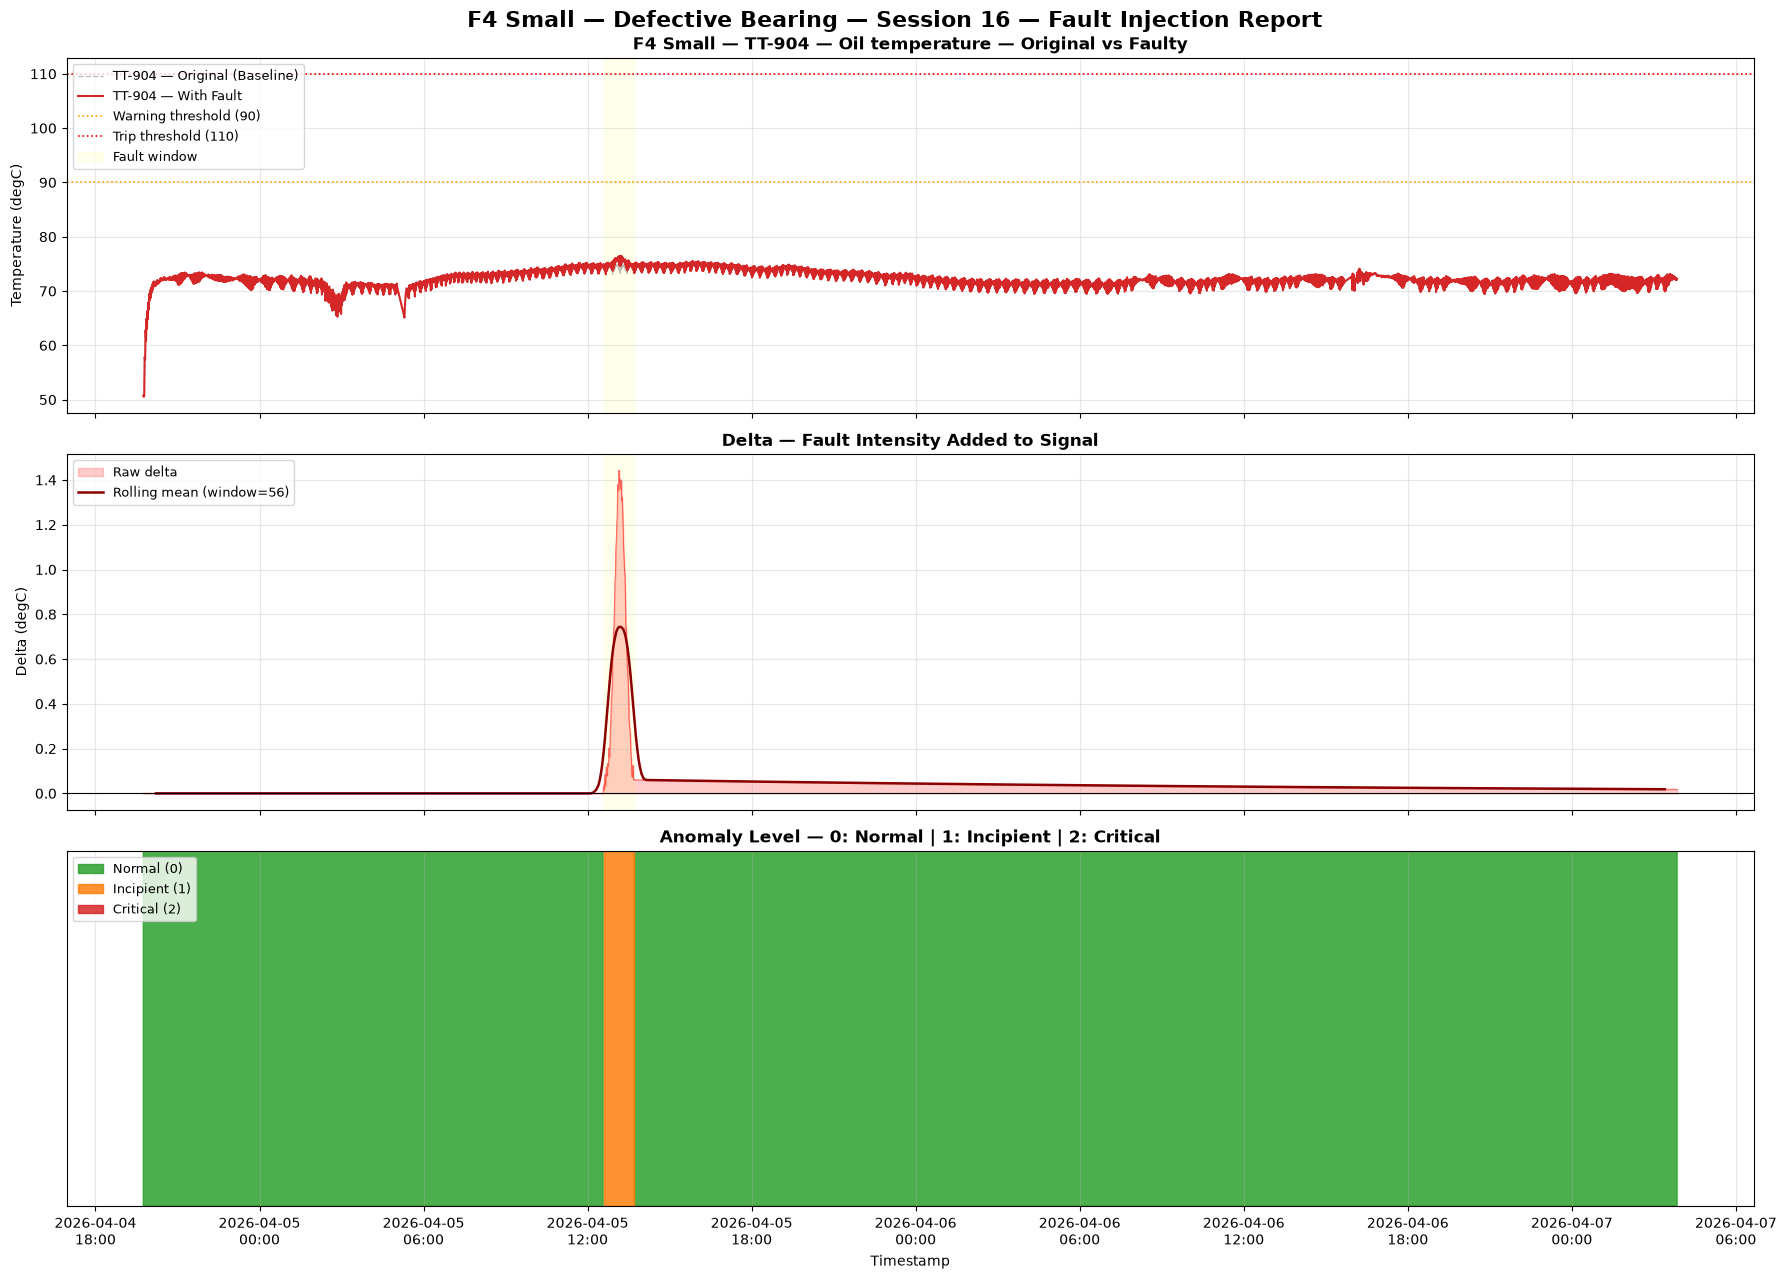

In [43]:
""" F4 Small — Fault Profile Verification Plot — Session 16 """

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 13), sharex=True)

# ============================================================
# PANEL 1 — Original vs Faulty TT-904
# ============================================================

f4_small_s16_fault_start_timestamp = f4_small_s16_df.index[f4_small_s16_start_idx]
f4_small_s16_fault_end_timestamp = f4_small_s16_df.index[f4_small_s16_end_idx - 1]

ax1.plot(
    f4_small_s16_df_orig.index,
    f4_small_s16_df_orig["TT-904"],
    color="gray",
    alpha=0.5,
    linestyle="--",
    linewidth=1.0,
    label="TT-904 — Original (Baseline)"
)

ax1.plot(
    f4_small_s16_df.index,
    f4_small_s16_df["TT-904"],
    color="#d62728",
    linewidth=1.5,
    label="TT-904 — With Fault"
)

ax1.axhline(
    y=tt904_warning,
    color="orange",
    linestyle=":",
    linewidth=1.2,
    label=f"Warning threshold ({tt904_warning})"
)

ax1.axhline(
    y=tt904_trip,
    color="red",
    linestyle=":",
    linewidth=1.2,
    label=f"Trip threshold ({tt904_trip})"
)

ax1.axvspan(
    f4_small_s16_fault_start_timestamp,
    f4_small_s16_fault_end_timestamp,
    color="yellow",
    alpha=0.08,
    label="Fault window"
)

ax1.set_title("F4 Small — TT-904 — Oil temperature — Original vs Faulty", fontweight="bold")
ax1.set_ylabel("Temperature (degC)")
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(True, alpha=0.3)

# ============================================================
# PANEL 2 — Delta (fault intensity)
# ============================================================

f4_small_s16_delta_full = f4_small_s16_df["TT-904"] - f4_small_s16_df_orig["TT-904"]
f4_small_s16_roll_window = max(10, len(f4_small_s16_delta_full) // 60)
f4_small_s16_delta_rolling_mean = f4_small_s16_delta_full.rolling(f4_small_s16_roll_window, center=True).mean()

ax2.fill_between(
    f4_small_s16_df.index,
    0,
    f4_small_s16_delta_full,
    color="red",
    alpha=0.2,
    label="Raw delta"
)

ax2.plot(
    f4_small_s16_df.index,
    f4_small_s16_delta_full,
    color="red",
    linewidth=0.8,
    alpha=0.5
)

ax2.plot(
    f4_small_s16_df.index,
    f4_small_s16_delta_rolling_mean,
    color="#8B0000",
    linewidth=1.8,
    label=f"Rolling mean (window={f4_small_s16_roll_window})"
)

ax2.axhline(y=0, color="black", linewidth=0.8)
ax2.axvspan(f4_small_s16_fault_start_timestamp, f4_small_s16_fault_end_timestamp, color="yellow", alpha=0.08)
ax2.set_title("Delta — Fault Intensity Added to Signal", fontweight="bold")
ax2.set_ylabel("Delta (degC)")
ax2.legend(loc="upper left", fontsize=9)
ax2.grid(True, alpha=0.3)

# ============================================================
# PANEL 3 — Anomaly level bar
# ============================================================

f4_small_s16_normal_mask = f4_small_s16_df["anomaly_level"] == 0
f4_small_s16_incipient_mask = f4_small_s16_df["anomaly_level"] == 1
f4_small_s16_critical_mask = f4_small_s16_df["anomaly_level"] == 2

ax3.fill_between(f4_small_s16_df.index, 0, 1, where=f4_small_s16_normal_mask, color="#2ca02c", step="mid", alpha=0.85, label="Normal (0)")
ax3.fill_between(f4_small_s16_df.index, 0, 1, where=f4_small_s16_incipient_mask, color="#ff7f0e", step="mid", alpha=0.85, label="Incipient (1)")
ax3.fill_between(f4_small_s16_df.index, 0, 1, where=f4_small_s16_critical_mask, color="#d62728", step="mid", alpha=0.85, label="Critical (2)")

ax3.set_yticks([])
ax3.set_ylim(0, 1)
ax3.set_xlabel("Timestamp")
ax3.set_title("Anomaly Level — 0: Normal | 1: Incipient | 2: Critical", fontweight="bold")
ax3.legend(loc="upper left", fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))

fig.suptitle("F4 Small — Defective Bearing — Session 16 — Fault Injection Report", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


#### Medium - Session 16

In [44]:
""" F4 Medium — Defective Bearing — Session 16 """

np.random.seed(42)

f4_medium_s16_df_orig = dict_sessions[16].copy()
f4_medium_s16_main_sensor = "TT-904"
f4_medium_s16_length_hours = 1.4
f4_medium_s16_start_from = 0.45

# FAULT WINDOW
f4_medium_s16_session_length = len(f4_medium_s16_df_orig)
f4_medium_s16_start_idx = int(round(f4_medium_s16_session_length * f4_medium_s16_start_from))
f4_medium_s16_end_idx = min(f4_medium_s16_start_idx + int(round(f4_medium_s16_length_hours * 60)), f4_medium_s16_session_length)
f4_medium_s16_total_l = f4_medium_s16_end_idx - f4_medium_s16_start_idx
print("Session 16 length:", f4_medium_s16_session_length, "rows")
print("Fault start index:", f4_medium_s16_start_idx)
print("Fault end index:", f4_medium_s16_end_idx)
print("Fault window length:", f4_medium_s16_total_l, "rows")

# BASELINE STATISTICS
f4_medium_s16_baseline_mean = f4_medium_s16_df_orig["TT-904"].iloc[:f4_medium_s16_start_idx].mean()
f4_medium_s16_baseline_std = f4_medium_s16_df_orig["TT-904"].iloc[:f4_medium_s16_start_idx].std()
print("\nTT-904 baseline mean:", round(f4_medium_s16_baseline_mean, 4))
print("TT-904 baseline std:", round(f4_medium_s16_baseline_std, 4))

# SEVERITY TARGET — medium reaches the warning-to-trip interval
f4_medium_s16_target = tt904_warning + medium_trip_fraction * (tt904_trip - tt904_warning)
f4_medium_s16_delta_mag = f4_medium_s16_target - f4_medium_s16_baseline_mean
print("TT-904 medium target:", round(f4_medium_s16_target, 4))
print("TT-904 delta magnitude:", round(f4_medium_s16_delta_mag, 4))

# RAW DELTA SHAPE — localized upward Gaussian spike
f4_medium_s16_center = int(f4_medium_s16_total_l * 0.5)
f4_medium_s16_width = max(int(f4_medium_s16_total_l * 0.08), 1)
f4_medium_s16_t = np.arange(f4_medium_s16_total_l)
f4_medium_s16_noise_std = min(f4_medium_s16_baseline_std * 0.30, abs(f4_medium_s16_delta_mag) * 0.10)
f4_medium_s16_noise = np.random.normal(0, f4_medium_s16_noise_std, f4_medium_s16_total_l)
f4_medium_s16_delta = f4_medium_s16_delta_mag * np.exp(-0.5 * ((f4_medium_s16_t - f4_medium_s16_center) / f4_medium_s16_width) ** 2) + f4_medium_s16_noise

# TARGET ALIGNMENT — keep severity ordered against the absolute target
f4_medium_s16_active_values = f4_medium_s16_df_orig["TT-904"].iloc[f4_medium_s16_start_idx:f4_medium_s16_end_idx].to_numpy()
f4_medium_s16_positive_peak_idx = int(np.argmax(f4_medium_s16_delta))
if True:
    f4_medium_s16_delta = np.maximum(f4_medium_s16_delta, 0)

if f4_medium_s16_delta[f4_medium_s16_positive_peak_idx] > 0:
    f4_medium_s16_desired_peak_delta = f4_medium_s16_target - f4_medium_s16_active_values[f4_medium_s16_positive_peak_idx]
    if f4_medium_s16_desired_peak_delta > 0:
        f4_medium_s16_delta = f4_medium_s16_delta * (f4_medium_s16_desired_peak_delta / f4_medium_s16_delta[f4_medium_s16_positive_peak_idx])

f4_medium_s16_upper_delta = f4_medium_s16_target - f4_medium_s16_active_values
f4_medium_s16_delta = np.minimum(f4_medium_s16_delta, f4_medium_s16_upper_delta)
if True:
    f4_medium_s16_delta = np.maximum(f4_medium_s16_delta, 0)

# CORRELATION COMPUTED EXPLICITLY
f4_medium_s16_corr_threshold = 0.65
f4_medium_s16_corr = f4_medium_s16_df_orig.corr(method="pearson", numeric_only=True)["TT-904"]
f4_medium_s16_corr_sensors = f4_medium_s16_corr[abs(f4_medium_s16_corr) >= f4_medium_s16_corr_threshold].index.tolist()
print("\nCorrelated sensors (|r| >=", f4_medium_s16_corr_threshold, "):", f4_medium_s16_corr_sensors)

# APPLY INJECTION EXPLICITLY SENSOR BY SENSOR
f4_medium_s16_df = f4_medium_s16_df_orig.copy()
f4_medium_s16_propagation_scale = 0.15
for sensor in f4_medium_s16_corr_sensors:
    if sensor in f4_medium_s16_df.columns:
        scale = 1.0 if sensor == f4_medium_s16_main_sensor else f4_medium_s16_propagation_scale
        f4_medium_s16_df.iloc[f4_medium_s16_start_idx:f4_medium_s16_end_idx, f4_medium_s16_df.columns.get_loc(sensor)] += f4_medium_s16_delta * f4_medium_s16_corr[sensor] * scale

# DECAY / STABILIZATION PHASE
f4_medium_s16_remaining = f4_medium_s16_session_length - f4_medium_s16_end_idx
if f4_medium_s16_remaining > 0:
    f4_medium_s16_decay_rate = 0.3
    f4_medium_s16_decay = f4_medium_s16_delta[-1] * np.exp(-f4_medium_s16_decay_rate * np.linspace(0, 1, f4_medium_s16_remaining))
    for sensor in f4_medium_s16_corr_sensors:
        if sensor in f4_medium_s16_df.columns:
            scale = 1.0 if sensor == f4_medium_s16_main_sensor else f4_medium_s16_propagation_scale
            f4_medium_s16_df.iloc[f4_medium_s16_end_idx:, f4_medium_s16_df.columns.get_loc(sensor)] += f4_medium_s16_decay * f4_medium_s16_corr[sensor] * scale

# SEVERITY CAP — small/medium should not drift beyond their target during stabilization
f4_medium_s16_main_sensor_loc = f4_medium_s16_df.columns.get_loc("TT-904")
f4_medium_s16_df.iloc[f4_medium_s16_start_idx:, f4_medium_s16_main_sensor_loc] = np.minimum(
    f4_medium_s16_df.iloc[f4_medium_s16_start_idx:, f4_medium_s16_main_sensor_loc],
    f4_medium_s16_target,
)

# LABELS — medium/severe faults are labelled from injection start through stabilization
f4_medium_s16_df["anomaly_level"] = 0
f4_medium_s16_df["is_injected_anomaly"] = 0
f4_medium_s16_df["anomaly_type"] = "normal"
f4_medium_s16_injected_values = f4_medium_s16_df["TT-904"].iloc[f4_medium_s16_start_idx:]
f4_medium_s16_labels = np.where(
    f4_medium_s16_injected_values >= tt904_trip, 2,
    np.where(f4_medium_s16_injected_values >= tt904_warning, 1, 0)
)
f4_medium_s16_df.iloc[f4_medium_s16_start_idx:, f4_medium_s16_df.columns.get_loc("anomaly_level")] = f4_medium_s16_labels
f4_medium_s16_df.iloc[f4_medium_s16_start_idx:, f4_medium_s16_df.columns.get_loc("is_injected_anomaly")] = 1
f4_medium_s16_df.iloc[f4_medium_s16_start_idx:, f4_medium_s16_df.columns.get_loc("anomaly_type")] = "bearing_fault"

# SAVE CSV
f4_medium_s16_df.to_csv(f"{output_dir_single}/session_16_F4_medium.csv")
print("\nSession 16 F4 medium saved")
print("Anomaly rows:", int(f4_medium_s16_df["is_injected_anomaly"].sum()))
print("Normal rows:", int((f4_medium_s16_df["is_injected_anomaly"] == 0).sum()))
print("Level 1 rows:", int((f4_medium_s16_df["anomaly_level"] == 1).sum()))
print("Level 2 rows:", int((f4_medium_s16_df["anomaly_level"] == 2).sum()))


Session 16 length: 3367 rows
Fault start index: 1515
Fault end index: 1599
Fault window length: 84 rows

TT-904 baseline mean: 72.6694
TT-904 baseline std: 2.133
TT-904 medium target: 101.0
TT-904 delta magnitude: 28.3306

Correlated sensors (|r| >= 0.65 ): ['TT-901', 'TT-902', 'TT-903', 'TT-904']

Session 16 F4 medium saved
Anomaly rows: 1852
Normal rows: 1515
Level 1 rows: 13
Level 2 rows: 0


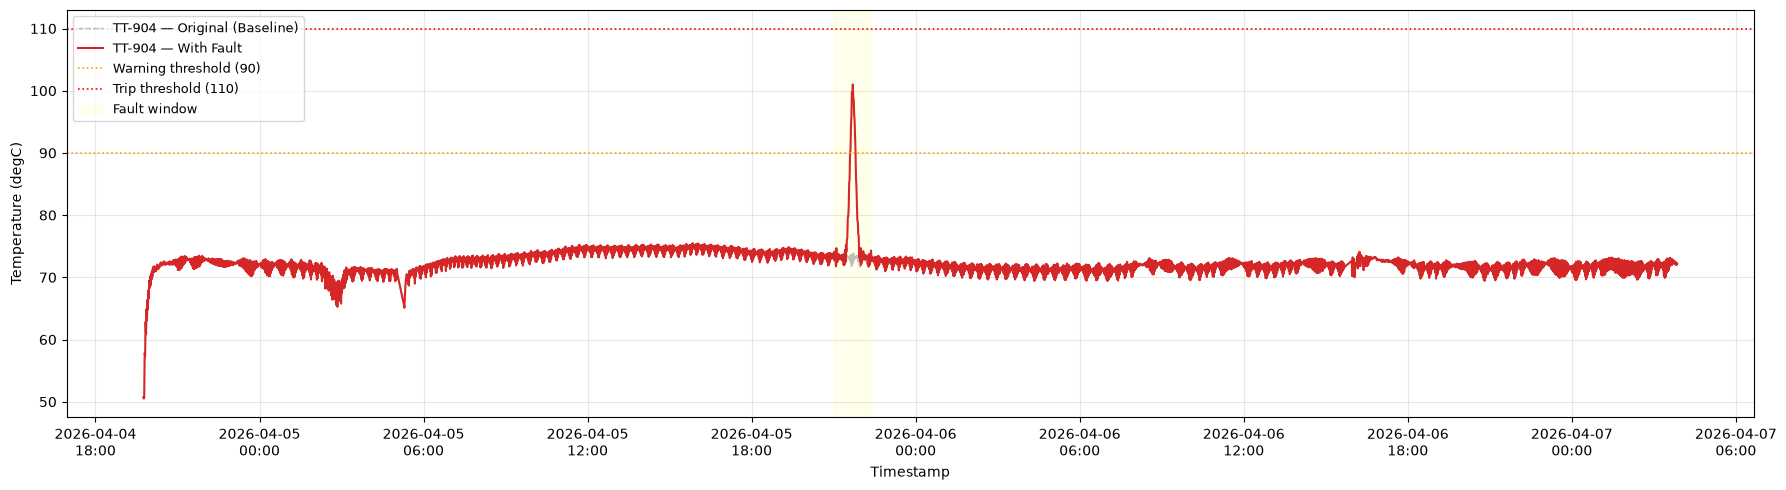

In [59]:
""" F4 Medium — Fault Profile Verification Plot — Session 16 """

fig, ax1 = plt.subplots(1, 1, figsize=(18, 5))

# ============================================================
# PANEL 1 — Original vs Faulty TT-904
# ============================================================

f4_medium_s16_fault_start_timestamp = f4_medium_s16_df.index[f4_medium_s16_start_idx]
f4_medium_s16_fault_end_timestamp = f4_medium_s16_df.index[f4_medium_s16_end_idx - 1]

ax1.plot(
    f4_medium_s16_df_orig.index,
    f4_medium_s16_df_orig["TT-904"],
    color="gray",
    alpha=0.5,
    linestyle="--",
    linewidth=1.0,
    label="TT-904 — Original (Baseline)"
)

ax1.plot(
    f4_medium_s16_df.index,
    f4_medium_s16_df["TT-904"],
    color="#d62728",
    linewidth=1.5,
    label="TT-904 — With Fault"
)

ax1.axhline(
    y=tt904_warning,
    color="orange",
    linestyle=":",
    linewidth=1.2,
    label=f"Warning threshold ({tt904_warning})"
)

ax1.axhline(
    y=tt904_trip,
    color="red",
    linestyle=":",
    linewidth=1.2,
    label=f"Trip threshold ({tt904_trip})"
)

ax1.axvspan(
    f4_medium_s16_fault_start_timestamp,
    f4_medium_s16_fault_end_timestamp,
    color="yellow",
    alpha=0.08,
    label="Fault window"
)

ax1.set_ylabel("Temperature (degC)")
ax1.set_xlabel("Timestamp")
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))

plt.tight_layout()
plt.savefig("fault_f4_medium_s16.png", dpi=200, bbox_inches="tight")
plt.show()

#### Severe - Session 16

In [46]:
""" F4 Severe — Defective Bearing — Session 16 """

np.random.seed(42)

f4_severe_s16_df_orig = dict_sessions[16].copy()
f4_severe_s16_main_sensor = "TT-904"
f4_severe_s16_length_hours = 0.85
f4_severe_s16_start_from = 0.55

# FAULT WINDOW
f4_severe_s16_session_length = len(f4_severe_s16_df_orig)
f4_severe_s16_start_idx = int(round(f4_severe_s16_session_length * f4_severe_s16_start_from))
f4_severe_s16_end_idx = min(f4_severe_s16_start_idx + int(round(f4_severe_s16_length_hours * 60)), f4_severe_s16_session_length)
f4_severe_s16_total_l = f4_severe_s16_end_idx - f4_severe_s16_start_idx
print("Session 16 length:", f4_severe_s16_session_length, "rows")
print("Fault start index:", f4_severe_s16_start_idx)
print("Fault end index:", f4_severe_s16_end_idx)
print("Fault window length:", f4_severe_s16_total_l, "rows")

# BASELINE STATISTICS
f4_severe_s16_baseline_mean = f4_severe_s16_df_orig["TT-904"].iloc[:f4_severe_s16_start_idx].mean()
f4_severe_s16_baseline_std = f4_severe_s16_df_orig["TT-904"].iloc[:f4_severe_s16_start_idx].std()
print("\nTT-904 baseline mean:", round(f4_severe_s16_baseline_mean, 4))
print("TT-904 baseline std:", round(f4_severe_s16_baseline_std, 4))

# SEVERITY TARGET — severe reaches trip level
f4_severe_s16_target = tt904_trip
f4_severe_s16_delta_mag = f4_severe_s16_target - f4_severe_s16_baseline_mean
print("TT-904 severe target:", round(f4_severe_s16_target, 4))
print("TT-904 delta magnitude:", round(f4_severe_s16_delta_mag, 4))

# RAW DELTA SHAPE — localized upward Gaussian spike
f4_severe_s16_center = int(f4_severe_s16_total_l * 0.5)
f4_severe_s16_width = max(int(f4_severe_s16_total_l * 0.08), 1)
f4_severe_s16_t = np.arange(f4_severe_s16_total_l)
f4_severe_s16_noise_std = min(f4_severe_s16_baseline_std * 0.30, abs(f4_severe_s16_delta_mag) * 0.10)
f4_severe_s16_noise = np.random.normal(0, f4_severe_s16_noise_std, f4_severe_s16_total_l)
f4_severe_s16_delta = f4_severe_s16_delta_mag * np.exp(-0.5 * ((f4_severe_s16_t - f4_severe_s16_center) / f4_severe_s16_width) ** 2) + f4_severe_s16_noise

# TARGET ALIGNMENT — keep severity ordered against the absolute target
f4_severe_s16_active_values = f4_severe_s16_df_orig["TT-904"].iloc[f4_severe_s16_start_idx:f4_severe_s16_end_idx].to_numpy()
f4_severe_s16_positive_peak_idx = int(np.argmax(f4_severe_s16_delta))
if True:
    f4_severe_s16_delta = np.maximum(f4_severe_s16_delta, 0)

if f4_severe_s16_delta[f4_severe_s16_positive_peak_idx] > 0:
    f4_severe_s16_desired_peak_delta = f4_severe_s16_target - f4_severe_s16_active_values[f4_severe_s16_positive_peak_idx]
    if f4_severe_s16_desired_peak_delta > 0:
        f4_severe_s16_delta = f4_severe_s16_delta * (f4_severe_s16_desired_peak_delta / f4_severe_s16_delta[f4_severe_s16_positive_peak_idx])

f4_severe_s16_upper_delta = f4_severe_s16_target - f4_severe_s16_active_values
f4_severe_s16_delta = np.minimum(f4_severe_s16_delta, f4_severe_s16_upper_delta)
if True:
    f4_severe_s16_delta = np.maximum(f4_severe_s16_delta, 0)

# CORRELATION COMPUTED EXPLICITLY
f4_severe_s16_corr_threshold = 0.65
f4_severe_s16_corr = f4_severe_s16_df_orig.corr(method="pearson", numeric_only=True)["TT-904"]
f4_severe_s16_corr_sensors = f4_severe_s16_corr[abs(f4_severe_s16_corr) >= f4_severe_s16_corr_threshold].index.tolist()
print("\nCorrelated sensors (|r| >=", f4_severe_s16_corr_threshold, "):", f4_severe_s16_corr_sensors)

# APPLY INJECTION EXPLICITLY SENSOR BY SENSOR
f4_severe_s16_df = f4_severe_s16_df_orig.copy()
f4_severe_s16_propagation_scale = 0.15
for sensor in f4_severe_s16_corr_sensors:
    if sensor in f4_severe_s16_df.columns:
        scale = 1.0 if sensor == f4_severe_s16_main_sensor else f4_severe_s16_propagation_scale
        f4_severe_s16_df.iloc[f4_severe_s16_start_idx:f4_severe_s16_end_idx, f4_severe_s16_df.columns.get_loc(sensor)] += f4_severe_s16_delta * f4_severe_s16_corr[sensor] * scale

# DECAY / STABILIZATION PHASE
f4_severe_s16_remaining = f4_severe_s16_session_length - f4_severe_s16_end_idx
if f4_severe_s16_remaining > 0:
    f4_severe_s16_decay_rate = 0.3
    f4_severe_s16_decay = f4_severe_s16_delta[-1] * np.exp(-f4_severe_s16_decay_rate * np.linspace(0, 1, f4_severe_s16_remaining))
    for sensor in f4_severe_s16_corr_sensors:
        if sensor in f4_severe_s16_df.columns:
            scale = 1.0 if sensor == f4_severe_s16_main_sensor else f4_severe_s16_propagation_scale
            f4_severe_s16_df.iloc[f4_severe_s16_end_idx:, f4_severe_s16_df.columns.get_loc(sensor)] += f4_severe_s16_decay * f4_severe_s16_corr[sensor] * scale

# LABELS — medium/severe faults are labelled from injection start through stabilization
f4_severe_s16_df["anomaly_level"] = 0
f4_severe_s16_df["is_injected_anomaly"] = 0
f4_severe_s16_df["anomaly_type"] = "normal"
f4_severe_s16_injected_values = f4_severe_s16_df["TT-904"].iloc[f4_severe_s16_start_idx:]
f4_severe_s16_labels = np.where(
    f4_severe_s16_injected_values >= tt904_trip, 2,
    np.where(f4_severe_s16_injected_values >= tt904_warning, 1, 0)
)
f4_severe_s16_df.iloc[f4_severe_s16_start_idx:, f4_severe_s16_df.columns.get_loc("anomaly_level")] = f4_severe_s16_labels
f4_severe_s16_df.iloc[f4_severe_s16_start_idx:, f4_severe_s16_df.columns.get_loc("is_injected_anomaly")] = 1
f4_severe_s16_df.iloc[f4_severe_s16_start_idx:, f4_severe_s16_df.columns.get_loc("anomaly_type")] = "bearing_fault"

# SAVE CSV
f4_severe_s16_df.to_csv(f"{output_dir_single}/session_16_F4_severe.csv")
print("\nSession 16 F4 severe saved")
print("Anomaly rows:", int(f4_severe_s16_df["is_injected_anomaly"].sum()))
print("Normal rows:", int((f4_severe_s16_df["is_injected_anomaly"] == 0).sum()))
print("Level 1 rows:", int((f4_severe_s16_df["anomaly_level"] == 1).sum()))
print("Level 2 rows:", int((f4_severe_s16_df["anomaly_level"] == 2).sum()))


Session 16 length: 3367 rows
Fault start index: 1852
Fault end index: 1903
Fault window length: 51 rows

TT-904 baseline mean: 72.5886
TT-904 baseline std: 1.9762
TT-904 severe target: 110
TT-904 delta magnitude: 37.4114

Correlated sensors (|r| >= 0.65 ): ['TT-901', 'TT-902', 'TT-903', 'TT-904']

Session 16 F4 severe saved
Anomaly rows: 1515
Normal rows: 1852
Level 1 rows: 9
Level 2 rows: 1


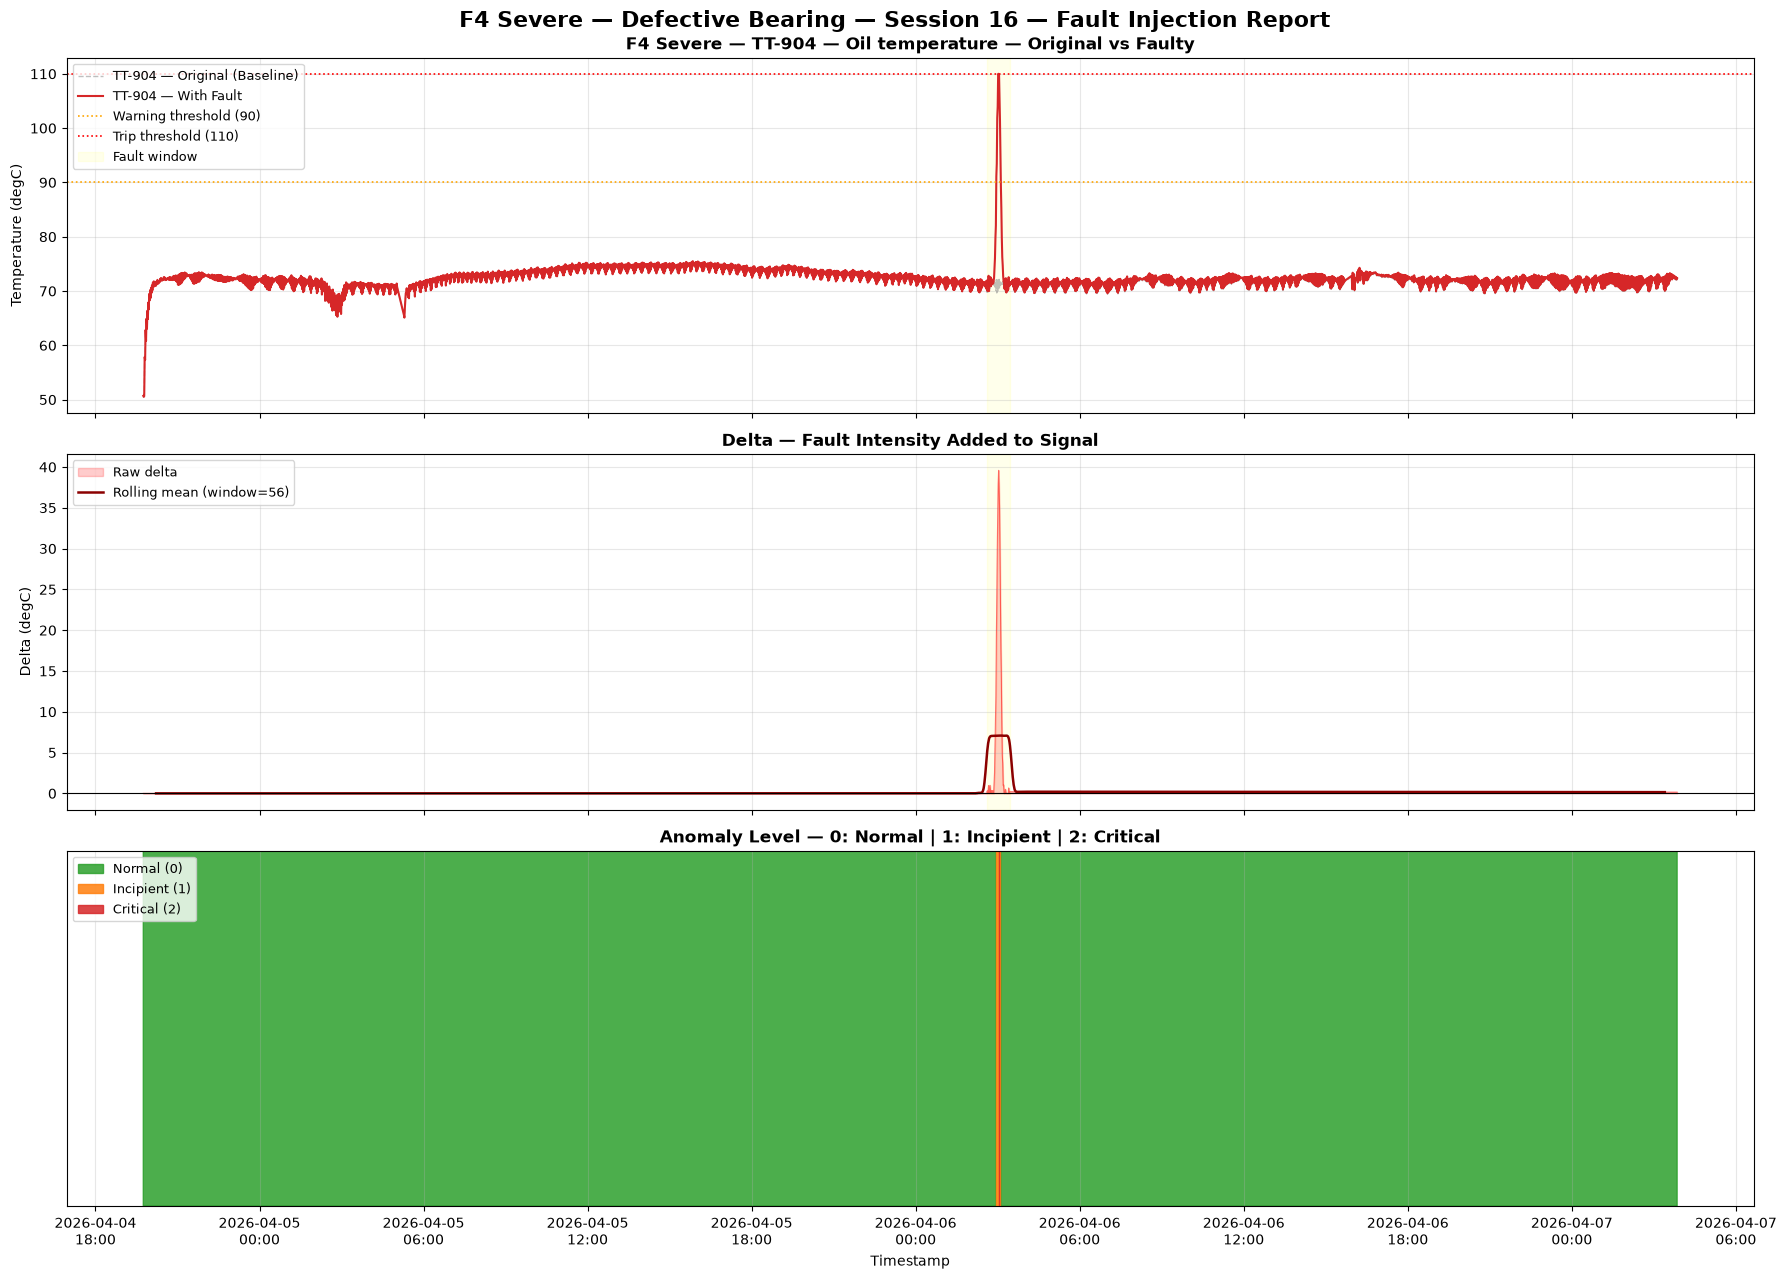

In [47]:
""" F4 Severe — Fault Profile Verification Plot — Session 16 """

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 13), sharex=True)

# ============================================================
# PANEL 1 — Original vs Faulty TT-904
# ============================================================

f4_severe_s16_fault_start_timestamp = f4_severe_s16_df.index[f4_severe_s16_start_idx]
f4_severe_s16_fault_end_timestamp = f4_severe_s16_df.index[f4_severe_s16_end_idx - 1]

ax1.plot(
    f4_severe_s16_df_orig.index,
    f4_severe_s16_df_orig["TT-904"],
    color="gray",
    alpha=0.5,
    linestyle="--",
    linewidth=1.0,
    label="TT-904 — Original (Baseline)"
)

ax1.plot(
    f4_severe_s16_df.index,
    f4_severe_s16_df["TT-904"],
    color="#d62728",
    linewidth=1.5,
    label="TT-904 — With Fault"
)

ax1.axhline(
    y=tt904_warning,
    color="orange",
    linestyle=":",
    linewidth=1.2,
    label=f"Warning threshold ({tt904_warning})"
)

ax1.axhline(
    y=tt904_trip,
    color="red",
    linestyle=":",
    linewidth=1.2,
    label=f"Trip threshold ({tt904_trip})"
)

ax1.axvspan(
    f4_severe_s16_fault_start_timestamp,
    f4_severe_s16_fault_end_timestamp,
    color="yellow",
    alpha=0.08,
    label="Fault window"
)

ax1.set_title("F4 Severe — TT-904 — Oil temperature — Original vs Faulty", fontweight="bold")
ax1.set_ylabel("Temperature (degC)")
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(True, alpha=0.3)

# ============================================================
# PANEL 2 — Delta (fault intensity)
# ============================================================

f4_severe_s16_delta_full = f4_severe_s16_df["TT-904"] - f4_severe_s16_df_orig["TT-904"]
f4_severe_s16_roll_window = max(10, len(f4_severe_s16_delta_full) // 60)
f4_severe_s16_delta_rolling_mean = f4_severe_s16_delta_full.rolling(f4_severe_s16_roll_window, center=True).mean()

ax2.fill_between(
    f4_severe_s16_df.index,
    0,
    f4_severe_s16_delta_full,
    color="red",
    alpha=0.2,
    label="Raw delta"
)

ax2.plot(
    f4_severe_s16_df.index,
    f4_severe_s16_delta_full,
    color="red",
    linewidth=0.8,
    alpha=0.5
)

ax2.plot(
    f4_severe_s16_df.index,
    f4_severe_s16_delta_rolling_mean,
    color="#8B0000",
    linewidth=1.8,
    label=f"Rolling mean (window={f4_severe_s16_roll_window})"
)

ax2.axhline(y=0, color="black", linewidth=0.8)
ax2.axvspan(f4_severe_s16_fault_start_timestamp, f4_severe_s16_fault_end_timestamp, color="yellow", alpha=0.08)
ax2.set_title("Delta — Fault Intensity Added to Signal", fontweight="bold")
ax2.set_ylabel("Delta (degC)")
ax2.legend(loc="upper left", fontsize=9)
ax2.grid(True, alpha=0.3)

# ============================================================
# PANEL 3 — Anomaly level bar
# ============================================================

f4_severe_s16_normal_mask = f4_severe_s16_df["anomaly_level"] == 0
f4_severe_s16_incipient_mask = f4_severe_s16_df["anomaly_level"] == 1
f4_severe_s16_critical_mask = f4_severe_s16_df["anomaly_level"] == 2

ax3.fill_between(f4_severe_s16_df.index, 0, 1, where=f4_severe_s16_normal_mask, color="#2ca02c", step="mid", alpha=0.85, label="Normal (0)")
ax3.fill_between(f4_severe_s16_df.index, 0, 1, where=f4_severe_s16_incipient_mask, color="#ff7f0e", step="mid", alpha=0.85, label="Incipient (1)")
ax3.fill_between(f4_severe_s16_df.index, 0, 1, where=f4_severe_s16_critical_mask, color="#d62728", step="mid", alpha=0.85, label="Critical (2)")

ax3.set_yticks([])
ax3.set_ylim(0, 1)
ax3.set_xlabel("Timestamp")
ax3.set_title("Anomaly Level — 0: Normal | 1: Incipient | 2: Critical", fontweight="bold")
ax3.legend(loc="upper left", fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))

fig.suptitle("F4 Severe — Defective Bearing — Session 16 — Fault Injection Report", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


#### Small - Session 17

In [48]:
""" F4 Small — Defective Bearing — Session 17 """

np.random.seed(42)

f4_small_s17_df_orig = dict_sessions[17].copy()
f4_small_s17_main_sensor = "TT-904"
f4_small_s17_length_hours = 1
f4_small_s17_start_from = 0.3

# FAULT WINDOW
f4_small_s17_session_length = len(f4_small_s17_df_orig)
f4_small_s17_start_idx = int(round(f4_small_s17_session_length * f4_small_s17_start_from))
f4_small_s17_end_idx = min(f4_small_s17_start_idx + int(round(f4_small_s17_length_hours * 60)), f4_small_s17_session_length)
f4_small_s17_total_l = f4_small_s17_end_idx - f4_small_s17_start_idx
print("Session 17 length:", f4_small_s17_session_length, "rows")
print("Fault start index:", f4_small_s17_start_idx)
print("Fault end index:", f4_small_s17_end_idx)
print("Fault window length:", f4_small_s17_total_l, "rows")

# BASELINE STATISTICS
f4_small_s17_baseline_mean = f4_small_s17_df_orig["TT-904"].iloc[:f4_small_s17_start_idx].mean()
f4_small_s17_baseline_std = f4_small_s17_df_orig["TT-904"].iloc[:f4_small_s17_start_idx].std()
print("\nTT-904 baseline mean:", round(f4_small_s17_baseline_mean, 4))
print("TT-904 baseline std:", round(f4_small_s17_baseline_std, 4))

# SEVERITY TARGET — small moves from baseline toward warning
f4_small_s17_target = f4_small_s17_baseline_mean + small_warning_fraction * (tt904_warning - f4_small_s17_baseline_mean)
f4_small_s17_delta_mag = f4_small_s17_target - f4_small_s17_baseline_mean
print("TT-904 small target:", round(f4_small_s17_target, 4))
print("TT-904 delta magnitude:", round(f4_small_s17_delta_mag, 4))

# RAW DELTA SHAPE — one broad low-amplitude bearing bump
f4_small_s17_t = np.arange(f4_small_s17_total_l)
f4_small_s17_center = int(f4_small_s17_total_l * 0.55)
f4_small_s17_width = max(int(f4_small_s17_total_l * 0.18), 1)
f4_small_s17_noise_std = min(f4_small_s17_baseline_std * 0.05, abs(f4_small_s17_delta_mag) * 0.10)
f4_small_s17_noise = np.random.normal(0, f4_small_s17_noise_std, f4_small_s17_total_l)
f4_small_s17_delta = f4_small_s17_delta_mag * np.exp(-0.5 * ((f4_small_s17_t - f4_small_s17_center) / f4_small_s17_width) ** 2) + f4_small_s17_noise

# TARGET ALIGNMENT — keep severity ordered against the absolute target
f4_small_s17_active_values = f4_small_s17_df_orig["TT-904"].iloc[f4_small_s17_start_idx:f4_small_s17_end_idx].to_numpy()
f4_small_s17_positive_peak_idx = int(np.argmax(f4_small_s17_delta))
if True:
    f4_small_s17_delta = np.maximum(f4_small_s17_delta, 0)

if f4_small_s17_delta[f4_small_s17_positive_peak_idx] > 0:
    f4_small_s17_desired_peak_delta = f4_small_s17_target - f4_small_s17_active_values[f4_small_s17_positive_peak_idx]
    if f4_small_s17_desired_peak_delta > 0:
        f4_small_s17_delta = f4_small_s17_delta * (f4_small_s17_desired_peak_delta / f4_small_s17_delta[f4_small_s17_positive_peak_idx])

f4_small_s17_upper_delta = f4_small_s17_target - f4_small_s17_active_values
f4_small_s17_delta = np.minimum(f4_small_s17_delta, f4_small_s17_upper_delta)
if True:
    f4_small_s17_delta = np.maximum(f4_small_s17_delta, 0)

# CORRELATION COMPUTED EXPLICITLY
f4_small_s17_corr_threshold = 0.65
f4_small_s17_corr = f4_small_s17_df_orig.corr(method="pearson", numeric_only=True)["TT-904"]
f4_small_s17_corr_sensors = f4_small_s17_corr[abs(f4_small_s17_corr) >= f4_small_s17_corr_threshold].index.tolist()
print("\nCorrelated sensors (|r| >=", f4_small_s17_corr_threshold, "):", f4_small_s17_corr_sensors)

# APPLY INJECTION EXPLICITLY SENSOR BY SENSOR
f4_small_s17_df = f4_small_s17_df_orig.copy()
f4_small_s17_propagation_scale = 0.15
for sensor in f4_small_s17_corr_sensors:
    if sensor in f4_small_s17_df.columns:
        scale = 1.0 if sensor == f4_small_s17_main_sensor else f4_small_s17_propagation_scale
        f4_small_s17_df.iloc[f4_small_s17_start_idx:f4_small_s17_end_idx, f4_small_s17_df.columns.get_loc(sensor)] += f4_small_s17_delta * f4_small_s17_corr[sensor] * scale

# DECAY / STABILIZATION PHASE
f4_small_s17_remaining = f4_small_s17_session_length - f4_small_s17_end_idx
if f4_small_s17_remaining > 0:
    f4_small_s17_decay_rate = 1.2
    f4_small_s17_decay = f4_small_s17_delta[-1] * np.exp(-f4_small_s17_decay_rate * np.linspace(0, 1, f4_small_s17_remaining))
    for sensor in f4_small_s17_corr_sensors:
        if sensor in f4_small_s17_df.columns:
            scale = 1.0 if sensor == f4_small_s17_main_sensor else f4_small_s17_propagation_scale
            f4_small_s17_df.iloc[f4_small_s17_end_idx:, f4_small_s17_df.columns.get_loc(sensor)] += f4_small_s17_decay * f4_small_s17_corr[sensor] * scale


# LABELS — small faults are below warning but still injected anomalies
f4_small_s17_df["anomaly_level"] = 0
f4_small_s17_df["is_injected_anomaly"] = 0
f4_small_s17_df["anomaly_type"] = "normal"
f4_small_s17_df.iloc[f4_small_s17_start_idx:f4_small_s17_end_idx, f4_small_s17_df.columns.get_loc("anomaly_level")] = 1
f4_small_s17_df.iloc[f4_small_s17_start_idx:f4_small_s17_end_idx, f4_small_s17_df.columns.get_loc("is_injected_anomaly")] = 1
f4_small_s17_df.iloc[f4_small_s17_start_idx:f4_small_s17_end_idx, f4_small_s17_df.columns.get_loc("anomaly_type")] = "bearing_fault"

# SAVE CSV
f4_small_s17_df.to_csv(f"{output_dir_single}/session_17_F4_small.csv")
print("\nSession 17 F4 small saved")
print("Anomaly rows:", int(f4_small_s17_df["is_injected_anomaly"].sum()))
print("Normal rows:", int((f4_small_s17_df["is_injected_anomaly"] == 0).sum()))
print("Level 1 rows:", int((f4_small_s17_df["anomaly_level"] == 1).sum()))
print("Level 2 rows:", int((f4_small_s17_df["anomaly_level"] == 2).sum()))


Session 17 length: 4415 rows
Fault start index: 1324
Fault end index: 1384
Fault window length: 60 rows

TT-904 baseline mean: 71.3655
TT-904 baseline std: 2.1856
TT-904 small target: 76.0241
TT-904 delta magnitude: 4.6586

Correlated sensors (|r| >= 0.65 ): ['TT-901', 'TT-902', 'TT-903', 'TT-904']

Session 17 F4 small saved
Anomaly rows: 60
Normal rows: 4355
Level 1 rows: 60
Level 2 rows: 0


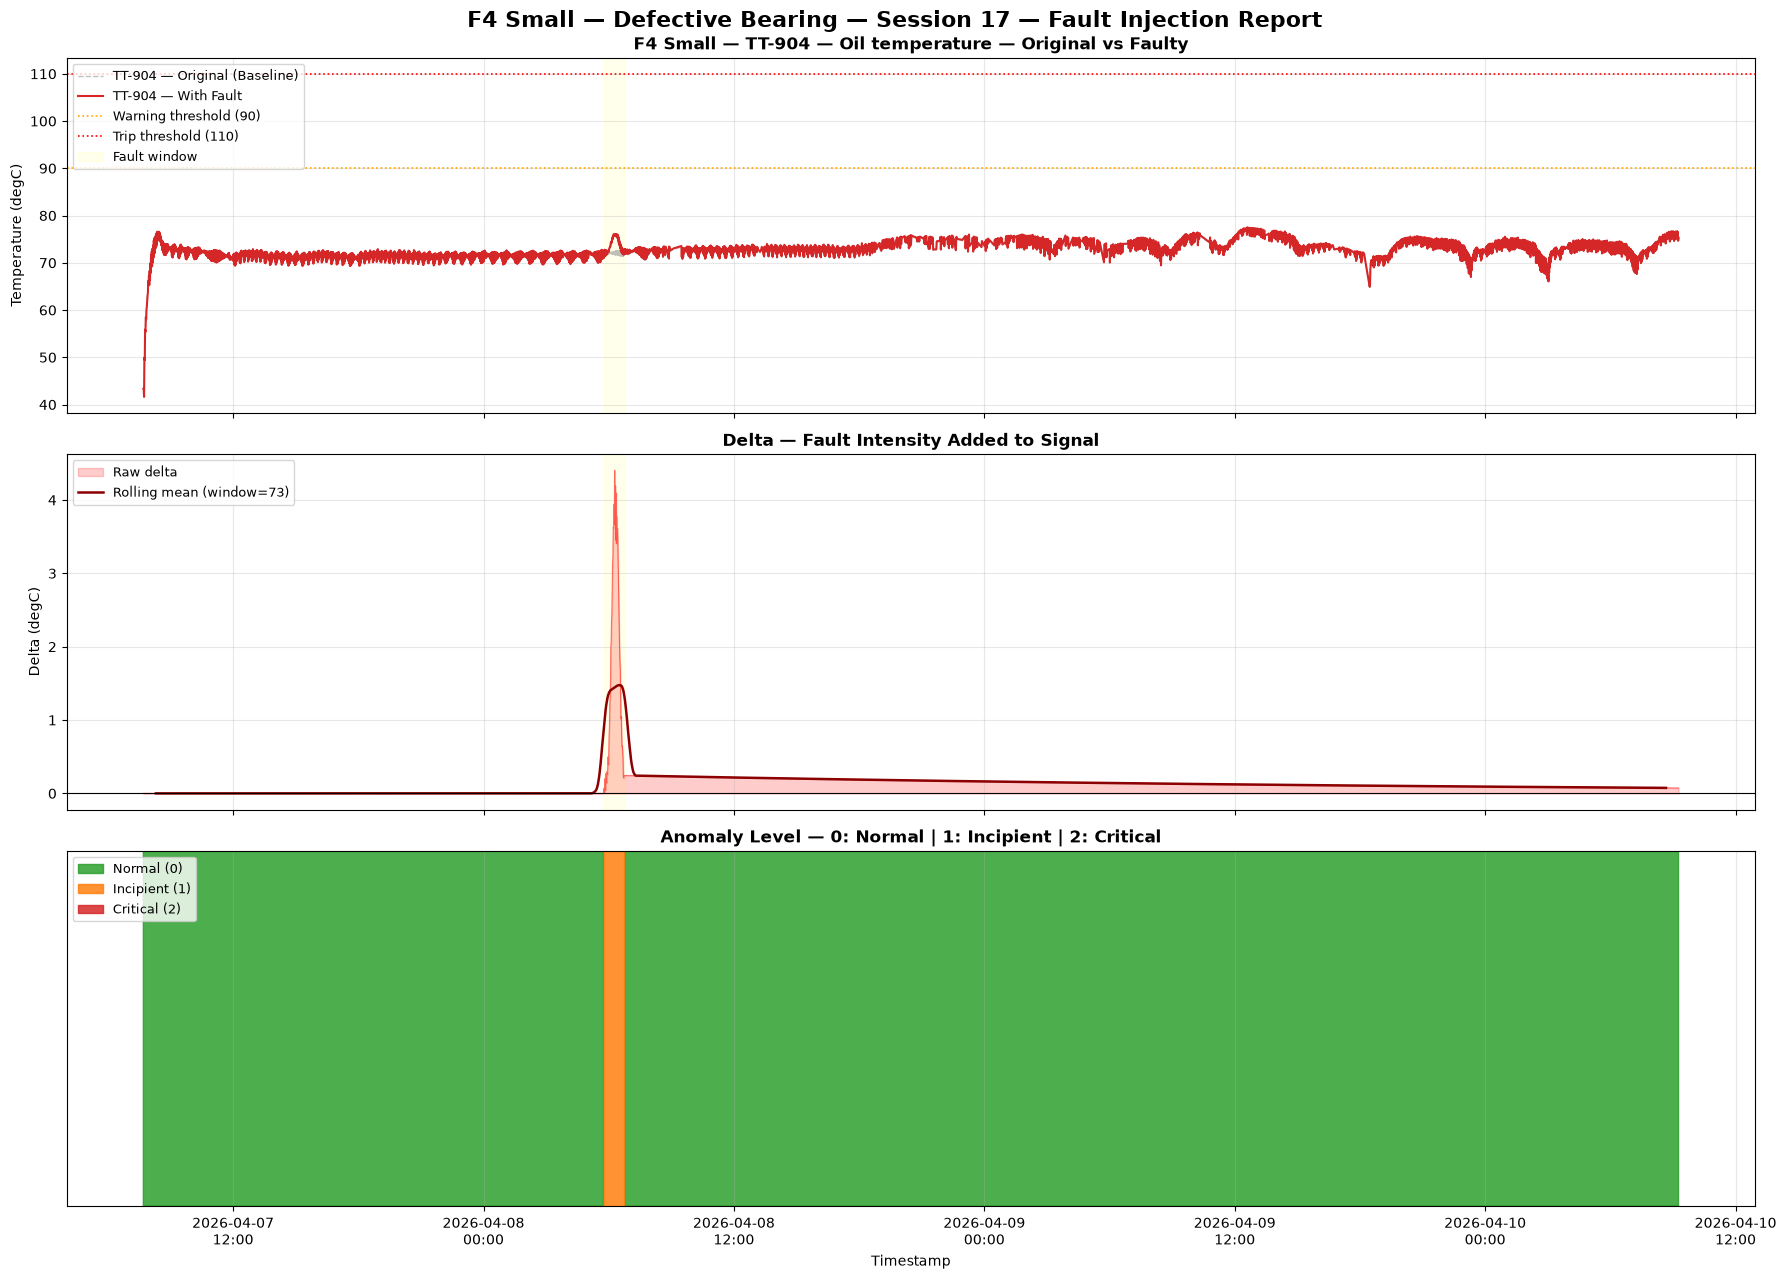

In [49]:
""" F4 Small — Fault Profile Verification Plot — Session 17 """

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 13), sharex=True)

# ============================================================
# PANEL 1 — Original vs Faulty TT-904
# ============================================================

f4_small_s17_fault_start_timestamp = f4_small_s17_df.index[f4_small_s17_start_idx]
f4_small_s17_fault_end_timestamp = f4_small_s17_df.index[f4_small_s17_end_idx - 1]

ax1.plot(
    f4_small_s17_df_orig.index,
    f4_small_s17_df_orig["TT-904"],
    color="gray",
    alpha=0.5,
    linestyle="--",
    linewidth=1.0,
    label="TT-904 — Original (Baseline)"
)

ax1.plot(
    f4_small_s17_df.index,
    f4_small_s17_df["TT-904"],
    color="#d62728",
    linewidth=1.5,
    label="TT-904 — With Fault"
)

ax1.axhline(
    y=tt904_warning,
    color="orange",
    linestyle=":",
    linewidth=1.2,
    label=f"Warning threshold ({tt904_warning})"
)

ax1.axhline(
    y=tt904_trip,
    color="red",
    linestyle=":",
    linewidth=1.2,
    label=f"Trip threshold ({tt904_trip})"
)

ax1.axvspan(
    f4_small_s17_fault_start_timestamp,
    f4_small_s17_fault_end_timestamp,
    color="yellow",
    alpha=0.08,
    label="Fault window"
)

ax1.set_title("F4 Small — TT-904 — Oil temperature — Original vs Faulty", fontweight="bold")
ax1.set_ylabel("Temperature (degC)")
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(True, alpha=0.3)

# ============================================================
# PANEL 2 — Delta (fault intensity)
# ============================================================

f4_small_s17_delta_full = f4_small_s17_df["TT-904"] - f4_small_s17_df_orig["TT-904"]
f4_small_s17_roll_window = max(10, len(f4_small_s17_delta_full) // 60)
f4_small_s17_delta_rolling_mean = f4_small_s17_delta_full.rolling(f4_small_s17_roll_window, center=True).mean()

ax2.fill_between(
    f4_small_s17_df.index,
    0,
    f4_small_s17_delta_full,
    color="red",
    alpha=0.2,
    label="Raw delta"
)

ax2.plot(
    f4_small_s17_df.index,
    f4_small_s17_delta_full,
    color="red",
    linewidth=0.8,
    alpha=0.5
)

ax2.plot(
    f4_small_s17_df.index,
    f4_small_s17_delta_rolling_mean,
    color="#8B0000",
    linewidth=1.8,
    label=f"Rolling mean (window={f4_small_s17_roll_window})"
)

ax2.axhline(y=0, color="black", linewidth=0.8)
ax2.axvspan(f4_small_s17_fault_start_timestamp, f4_small_s17_fault_end_timestamp, color="yellow", alpha=0.08)
ax2.set_title("Delta — Fault Intensity Added to Signal", fontweight="bold")
ax2.set_ylabel("Delta (degC)")
ax2.legend(loc="upper left", fontsize=9)
ax2.grid(True, alpha=0.3)

# ============================================================
# PANEL 3 — Anomaly level bar
# ============================================================

f4_small_s17_normal_mask = f4_small_s17_df["anomaly_level"] == 0
f4_small_s17_incipient_mask = f4_small_s17_df["anomaly_level"] == 1
f4_small_s17_critical_mask = f4_small_s17_df["anomaly_level"] == 2

ax3.fill_between(f4_small_s17_df.index, 0, 1, where=f4_small_s17_normal_mask, color="#2ca02c", step="mid", alpha=0.85, label="Normal (0)")
ax3.fill_between(f4_small_s17_df.index, 0, 1, where=f4_small_s17_incipient_mask, color="#ff7f0e", step="mid", alpha=0.85, label="Incipient (1)")
ax3.fill_between(f4_small_s17_df.index, 0, 1, where=f4_small_s17_critical_mask, color="#d62728", step="mid", alpha=0.85, label="Critical (2)")

ax3.set_yticks([])
ax3.set_ylim(0, 1)
ax3.set_xlabel("Timestamp")
ax3.set_title("Anomaly Level — 0: Normal | 1: Incipient | 2: Critical", fontweight="bold")
ax3.legend(loc="upper left", fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))

fig.suptitle("F4 Small — Defective Bearing — Session 17 — Fault Injection Report", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


#### Medium - Session 17

In [50]:
""" F4 Medium — Defective Bearing — Session 17 """

np.random.seed(42)

f4_medium_s17_df_orig = dict_sessions[17].copy()
f4_medium_s17_main_sensor = "TT-904"
f4_medium_s17_length_hours = 1.2
f4_medium_s17_start_from = 0.45

# FAULT WINDOW
f4_medium_s17_session_length = len(f4_medium_s17_df_orig)
f4_medium_s17_start_idx = int(round(f4_medium_s17_session_length * f4_medium_s17_start_from))
f4_medium_s17_end_idx = min(f4_medium_s17_start_idx + int(round(f4_medium_s17_length_hours * 60)), f4_medium_s17_session_length)
f4_medium_s17_total_l = f4_medium_s17_end_idx - f4_medium_s17_start_idx
print("Session 17 length:", f4_medium_s17_session_length, "rows")
print("Fault start index:", f4_medium_s17_start_idx)
print("Fault end index:", f4_medium_s17_end_idx)
print("Fault window length:", f4_medium_s17_total_l, "rows")

# BASELINE STATISTICS
f4_medium_s17_baseline_mean = f4_medium_s17_df_orig["TT-904"].iloc[:f4_medium_s17_start_idx].mean()
f4_medium_s17_baseline_std = f4_medium_s17_df_orig["TT-904"].iloc[:f4_medium_s17_start_idx].std()
print("\nTT-904 baseline mean:", round(f4_medium_s17_baseline_mean, 4))
print("TT-904 baseline std:", round(f4_medium_s17_baseline_std, 4))

# SEVERITY TARGET — medium reaches the warning-to-trip interval
f4_medium_s17_target = tt904_warning + medium_trip_fraction * (tt904_trip - tt904_warning)
f4_medium_s17_delta_mag = f4_medium_s17_target - f4_medium_s17_baseline_mean
print("TT-904 medium target:", round(f4_medium_s17_target, 4))
print("TT-904 delta magnitude:", round(f4_medium_s17_delta_mag, 4))

# RAW DELTA SHAPE — localized upward Gaussian spike
f4_medium_s17_center = int(f4_medium_s17_total_l * 0.5)
f4_medium_s17_width = max(int(f4_medium_s17_total_l * 0.08), 1)
f4_medium_s17_t = np.arange(f4_medium_s17_total_l)
f4_medium_s17_noise_std = min(f4_medium_s17_baseline_std * 0.30, abs(f4_medium_s17_delta_mag) * 0.10)
f4_medium_s17_noise = np.random.normal(0, f4_medium_s17_noise_std, f4_medium_s17_total_l)
f4_medium_s17_delta = f4_medium_s17_delta_mag * np.exp(-0.5 * ((f4_medium_s17_t - f4_medium_s17_center) / f4_medium_s17_width) ** 2) + f4_medium_s17_noise

# TARGET ALIGNMENT — keep severity ordered against the absolute target
f4_medium_s17_active_values = f4_medium_s17_df_orig["TT-904"].iloc[f4_medium_s17_start_idx:f4_medium_s17_end_idx].to_numpy()
f4_medium_s17_positive_peak_idx = int(np.argmax(f4_medium_s17_delta))
if True:
    f4_medium_s17_delta = np.maximum(f4_medium_s17_delta, 0)

if f4_medium_s17_delta[f4_medium_s17_positive_peak_idx] > 0:
    f4_medium_s17_desired_peak_delta = f4_medium_s17_target - f4_medium_s17_active_values[f4_medium_s17_positive_peak_idx]
    if f4_medium_s17_desired_peak_delta > 0:
        f4_medium_s17_delta = f4_medium_s17_delta * (f4_medium_s17_desired_peak_delta / f4_medium_s17_delta[f4_medium_s17_positive_peak_idx])

f4_medium_s17_upper_delta = f4_medium_s17_target - f4_medium_s17_active_values
f4_medium_s17_delta = np.minimum(f4_medium_s17_delta, f4_medium_s17_upper_delta)
if True:
    f4_medium_s17_delta = np.maximum(f4_medium_s17_delta, 0)

# CORRELATION COMPUTED EXPLICITLY
f4_medium_s17_corr_threshold = 0.65
f4_medium_s17_corr = f4_medium_s17_df_orig.corr(method="pearson", numeric_only=True)["TT-904"]
f4_medium_s17_corr_sensors = f4_medium_s17_corr[abs(f4_medium_s17_corr) >= f4_medium_s17_corr_threshold].index.tolist()
print("\nCorrelated sensors (|r| >=", f4_medium_s17_corr_threshold, "):", f4_medium_s17_corr_sensors)

# APPLY INJECTION EXPLICITLY SENSOR BY SENSOR
f4_medium_s17_df = f4_medium_s17_df_orig.copy()
f4_medium_s17_propagation_scale = 0.15
for sensor in f4_medium_s17_corr_sensors:
    if sensor in f4_medium_s17_df.columns:
        scale = 1.0 if sensor == f4_medium_s17_main_sensor else f4_medium_s17_propagation_scale
        f4_medium_s17_df.iloc[f4_medium_s17_start_idx:f4_medium_s17_end_idx, f4_medium_s17_df.columns.get_loc(sensor)] += f4_medium_s17_delta * f4_medium_s17_corr[sensor] * scale

# DECAY / STABILIZATION PHASE
f4_medium_s17_remaining = f4_medium_s17_session_length - f4_medium_s17_end_idx
if f4_medium_s17_remaining > 0:
    f4_medium_s17_decay_rate = 0.3
    f4_medium_s17_decay = f4_medium_s17_delta[-1] * np.exp(-f4_medium_s17_decay_rate * np.linspace(0, 1, f4_medium_s17_remaining))
    for sensor in f4_medium_s17_corr_sensors:
        if sensor in f4_medium_s17_df.columns:
            scale = 1.0 if sensor == f4_medium_s17_main_sensor else f4_medium_s17_propagation_scale
            f4_medium_s17_df.iloc[f4_medium_s17_end_idx:, f4_medium_s17_df.columns.get_loc(sensor)] += f4_medium_s17_decay * f4_medium_s17_corr[sensor] * scale

# SEVERITY CAP — small/medium should not drift beyond their target during stabilization
f4_medium_s17_main_sensor_loc = f4_medium_s17_df.columns.get_loc("TT-904")
f4_medium_s17_df.iloc[f4_medium_s17_start_idx:, f4_medium_s17_main_sensor_loc] = np.minimum(
    f4_medium_s17_df.iloc[f4_medium_s17_start_idx:, f4_medium_s17_main_sensor_loc],
    f4_medium_s17_target,
)

# LABELS — medium/severe faults are labelled from injection start through stabilization
f4_medium_s17_df["anomaly_level"] = 0
f4_medium_s17_df["is_injected_anomaly"] = 0
f4_medium_s17_df["anomaly_type"] = "normal"
f4_medium_s17_injected_values = f4_medium_s17_df["TT-904"].iloc[f4_medium_s17_start_idx:]
f4_medium_s17_labels = np.where(
    f4_medium_s17_injected_values >= tt904_trip, 2,
    np.where(f4_medium_s17_injected_values >= tt904_warning, 1, 0)
)
f4_medium_s17_df.iloc[f4_medium_s17_start_idx:, f4_medium_s17_df.columns.get_loc("anomaly_level")] = f4_medium_s17_labels
f4_medium_s17_df.iloc[f4_medium_s17_start_idx:, f4_medium_s17_df.columns.get_loc("is_injected_anomaly")] = 1
f4_medium_s17_df.iloc[f4_medium_s17_start_idx:, f4_medium_s17_df.columns.get_loc("anomaly_type")] = "bearing_fault"

# SAVE CSV
f4_medium_s17_df.to_csv(f"{output_dir_single}/session_17_F4_medium.csv")
print("\nSession 17 F4 medium saved")
print("Anomaly rows:", int(f4_medium_s17_df["is_injected_anomaly"].sum()))
print("Normal rows:", int((f4_medium_s17_df["is_injected_anomaly"] == 0).sum()))
print("Level 1 rows:", int((f4_medium_s17_df["anomaly_level"] == 1).sum()))
print("Level 2 rows:", int((f4_medium_s17_df["anomaly_level"] == 2).sum()))


Session 17 length: 4415 rows
Fault start index: 1987
Fault end index: 2059
Fault window length: 72 rows

TT-904 baseline mean: 71.7204
TT-904 baseline std: 1.9006
TT-904 medium target: 101.0
TT-904 delta magnitude: 29.2796

Correlated sensors (|r| >= 0.65 ): ['TT-901', 'TT-902', 'TT-903', 'TT-904']

Session 17 F4 medium saved
Anomaly rows: 2428
Normal rows: 1987
Level 1 rows: 10
Level 2 rows: 0


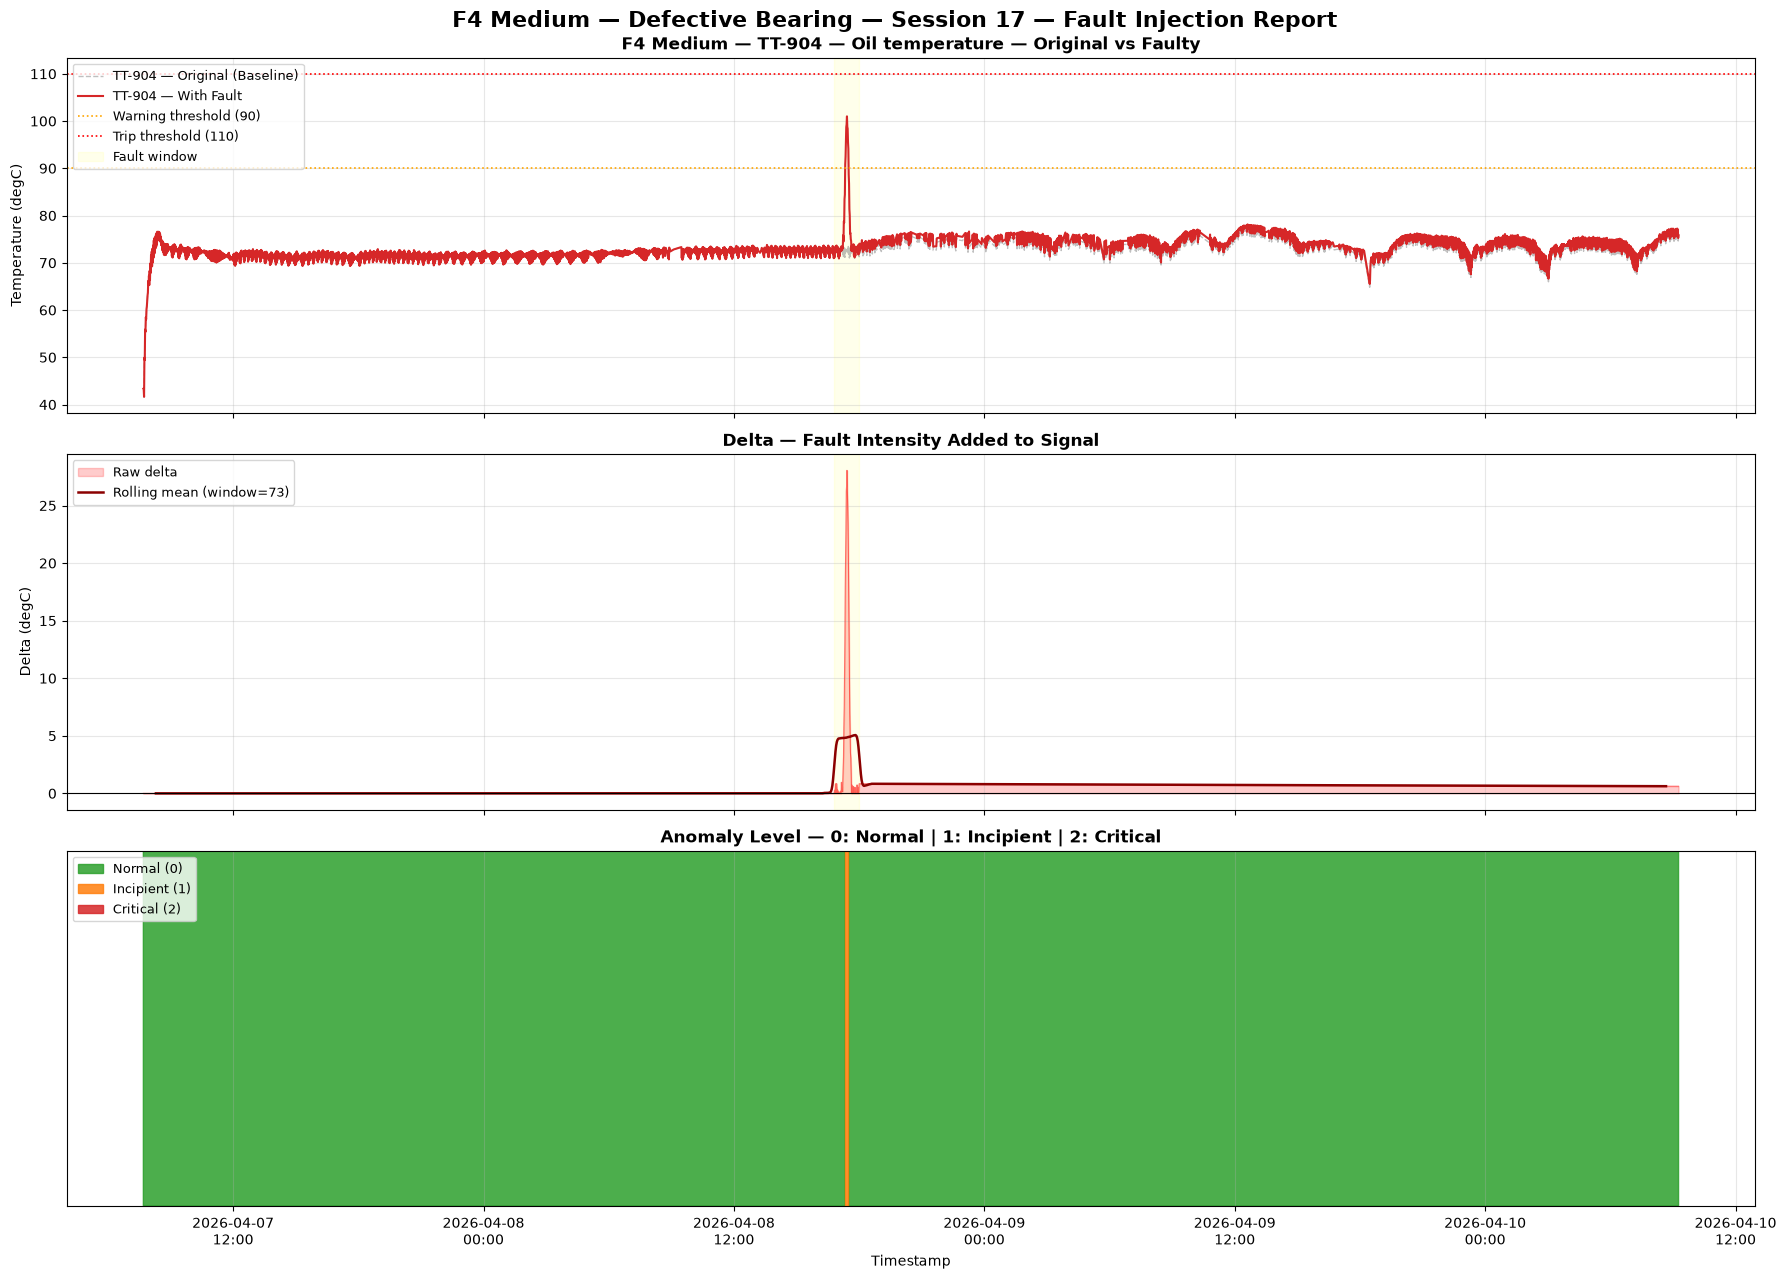

In [51]:
""" F4 Medium — Fault Profile Verification Plot — Session 17 """

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 13), sharex=True)

# ============================================================
# PANEL 1 — Original vs Faulty TT-904
# ============================================================

f4_medium_s17_fault_start_timestamp = f4_medium_s17_df.index[f4_medium_s17_start_idx]
f4_medium_s17_fault_end_timestamp = f4_medium_s17_df.index[f4_medium_s17_end_idx - 1]

ax1.plot(
    f4_medium_s17_df_orig.index,
    f4_medium_s17_df_orig["TT-904"],
    color="gray",
    alpha=0.5,
    linestyle="--",
    linewidth=1.0,
    label="TT-904 — Original (Baseline)"
)

ax1.plot(
    f4_medium_s17_df.index,
    f4_medium_s17_df["TT-904"],
    color="#d62728",
    linewidth=1.5,
    label="TT-904 — With Fault"
)

ax1.axhline(
    y=tt904_warning,
    color="orange",
    linestyle=":",
    linewidth=1.2,
    label=f"Warning threshold ({tt904_warning})"
)

ax1.axhline(
    y=tt904_trip,
    color="red",
    linestyle=":",
    linewidth=1.2,
    label=f"Trip threshold ({tt904_trip})"
)

ax1.axvspan(
    f4_medium_s17_fault_start_timestamp,
    f4_medium_s17_fault_end_timestamp,
    color="yellow",
    alpha=0.08,
    label="Fault window"
)

ax1.set_title("F4 Medium — TT-904 — Oil temperature — Original vs Faulty", fontweight="bold")
ax1.set_ylabel("Temperature (degC)")
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(True, alpha=0.3)

# ============================================================
# PANEL 2 — Delta (fault intensity)
# ============================================================

f4_medium_s17_delta_full = f4_medium_s17_df["TT-904"] - f4_medium_s17_df_orig["TT-904"]
f4_medium_s17_roll_window = max(10, len(f4_medium_s17_delta_full) // 60)
f4_medium_s17_delta_rolling_mean = f4_medium_s17_delta_full.rolling(f4_medium_s17_roll_window, center=True).mean()

ax2.fill_between(
    f4_medium_s17_df.index,
    0,
    f4_medium_s17_delta_full,
    color="red",
    alpha=0.2,
    label="Raw delta"
)

ax2.plot(
    f4_medium_s17_df.index,
    f4_medium_s17_delta_full,
    color="red",
    linewidth=0.8,
    alpha=0.5
)

ax2.plot(
    f4_medium_s17_df.index,
    f4_medium_s17_delta_rolling_mean,
    color="#8B0000",
    linewidth=1.8,
    label=f"Rolling mean (window={f4_medium_s17_roll_window})"
)

ax2.axhline(y=0, color="black", linewidth=0.8)
ax2.axvspan(f4_medium_s17_fault_start_timestamp, f4_medium_s17_fault_end_timestamp, color="yellow", alpha=0.08)
ax2.set_title("Delta — Fault Intensity Added to Signal", fontweight="bold")
ax2.set_ylabel("Delta (degC)")
ax2.legend(loc="upper left", fontsize=9)
ax2.grid(True, alpha=0.3)

# ============================================================
# PANEL 3 — Anomaly level bar
# ============================================================

f4_medium_s17_normal_mask = f4_medium_s17_df["anomaly_level"] == 0
f4_medium_s17_incipient_mask = f4_medium_s17_df["anomaly_level"] == 1
f4_medium_s17_critical_mask = f4_medium_s17_df["anomaly_level"] == 2

ax3.fill_between(f4_medium_s17_df.index, 0, 1, where=f4_medium_s17_normal_mask, color="#2ca02c", step="mid", alpha=0.85, label="Normal (0)")
ax3.fill_between(f4_medium_s17_df.index, 0, 1, where=f4_medium_s17_incipient_mask, color="#ff7f0e", step="mid", alpha=0.85, label="Incipient (1)")
ax3.fill_between(f4_medium_s17_df.index, 0, 1, where=f4_medium_s17_critical_mask, color="#d62728", step="mid", alpha=0.85, label="Critical (2)")

ax3.set_yticks([])
ax3.set_ylim(0, 1)
ax3.set_xlabel("Timestamp")
ax3.set_title("Anomaly Level — 0: Normal | 1: Incipient | 2: Critical", fontweight="bold")
ax3.legend(loc="upper left", fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))

fig.suptitle("F4 Medium — Defective Bearing — Session 17 — Fault Injection Report", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


#### Severe - Session 17

In [52]:
""" F4 Severe — Defective Bearing — Session 17 """

np.random.seed(42)

f4_severe_s17_df_orig = dict_sessions[17].copy()
f4_severe_s17_main_sensor = "TT-904"
f4_severe_s17_length_hours = 1.3
f4_severe_s17_start_from = 0.55

# FAULT WINDOW
f4_severe_s17_session_length = len(f4_severe_s17_df_orig)
f4_severe_s17_start_idx = int(round(f4_severe_s17_session_length * f4_severe_s17_start_from))
f4_severe_s17_end_idx = min(f4_severe_s17_start_idx + int(round(f4_severe_s17_length_hours * 60)), f4_severe_s17_session_length)
f4_severe_s17_total_l = f4_severe_s17_end_idx - f4_severe_s17_start_idx
print("Session 17 length:", f4_severe_s17_session_length, "rows")
print("Fault start index:", f4_severe_s17_start_idx)
print("Fault end index:", f4_severe_s17_end_idx)
print("Fault window length:", f4_severe_s17_total_l, "rows")

# BASELINE STATISTICS
f4_severe_s17_baseline_mean = f4_severe_s17_df_orig["TT-904"].iloc[:f4_severe_s17_start_idx].mean()
f4_severe_s17_baseline_std = f4_severe_s17_df_orig["TT-904"].iloc[:f4_severe_s17_start_idx].std()
print("\nTT-904 baseline mean:", round(f4_severe_s17_baseline_mean, 4))
print("TT-904 baseline std:", round(f4_severe_s17_baseline_std, 4))

# SEVERITY TARGET — severe reaches trip level
f4_severe_s17_target = tt904_trip
f4_severe_s17_delta_mag = f4_severe_s17_target - f4_severe_s17_baseline_mean
print("TT-904 severe target:", round(f4_severe_s17_target, 4))
print("TT-904 delta magnitude:", round(f4_severe_s17_delta_mag, 4))

# RAW DELTA SHAPE — localized upward Gaussian spike
f4_severe_s17_center = int(f4_severe_s17_total_l * 0.5)
f4_severe_s17_width = max(int(f4_severe_s17_total_l * 0.08), 1)
f4_severe_s17_t = np.arange(f4_severe_s17_total_l)
f4_severe_s17_noise_std = min(f4_severe_s17_baseline_std * 0.30, abs(f4_severe_s17_delta_mag) * 0.10)
f4_severe_s17_noise = np.random.normal(0, f4_severe_s17_noise_std, f4_severe_s17_total_l)
f4_severe_s17_delta = f4_severe_s17_delta_mag * np.exp(-0.5 * ((f4_severe_s17_t - f4_severe_s17_center) / f4_severe_s17_width) ** 2) + f4_severe_s17_noise

# TARGET ALIGNMENT — keep severity ordered against the absolute target
f4_severe_s17_active_values = f4_severe_s17_df_orig["TT-904"].iloc[f4_severe_s17_start_idx:f4_severe_s17_end_idx].to_numpy()
f4_severe_s17_positive_peak_idx = int(np.argmax(f4_severe_s17_delta))
if True:
    f4_severe_s17_delta = np.maximum(f4_severe_s17_delta, 0)

if f4_severe_s17_delta[f4_severe_s17_positive_peak_idx] > 0:
    f4_severe_s17_desired_peak_delta = f4_severe_s17_target - f4_severe_s17_active_values[f4_severe_s17_positive_peak_idx]
    if f4_severe_s17_desired_peak_delta > 0:
        f4_severe_s17_delta = f4_severe_s17_delta * (f4_severe_s17_desired_peak_delta / f4_severe_s17_delta[f4_severe_s17_positive_peak_idx])

f4_severe_s17_upper_delta = f4_severe_s17_target - f4_severe_s17_active_values
f4_severe_s17_delta = np.minimum(f4_severe_s17_delta, f4_severe_s17_upper_delta)
if True:
    f4_severe_s17_delta = np.maximum(f4_severe_s17_delta, 0)

# CORRELATION COMPUTED EXPLICITLY
f4_severe_s17_corr_threshold = 0.65
f4_severe_s17_corr = f4_severe_s17_df_orig.corr(method="pearson", numeric_only=True)["TT-904"]
f4_severe_s17_corr_sensors = f4_severe_s17_corr[abs(f4_severe_s17_corr) >= f4_severe_s17_corr_threshold].index.tolist()
print("\nCorrelated sensors (|r| >=", f4_severe_s17_corr_threshold, "):", f4_severe_s17_corr_sensors)

# APPLY INJECTION EXPLICITLY SENSOR BY SENSOR
f4_severe_s17_df = f4_severe_s17_df_orig.copy()
f4_severe_s17_propagation_scale = 0.15
for sensor in f4_severe_s17_corr_sensors:
    if sensor in f4_severe_s17_df.columns:
        scale = 1.0 if sensor == f4_severe_s17_main_sensor else f4_severe_s17_propagation_scale
        f4_severe_s17_df.iloc[f4_severe_s17_start_idx:f4_severe_s17_end_idx, f4_severe_s17_df.columns.get_loc(sensor)] += f4_severe_s17_delta * f4_severe_s17_corr[sensor] * scale

# DECAY / STABILIZATION PHASE
f4_severe_s17_remaining = f4_severe_s17_session_length - f4_severe_s17_end_idx
if f4_severe_s17_remaining > 0:
    f4_severe_s17_decay_rate = 0.3
    f4_severe_s17_decay = f4_severe_s17_delta[-1] * np.exp(-f4_severe_s17_decay_rate * np.linspace(0, 1, f4_severe_s17_remaining))
    for sensor in f4_severe_s17_corr_sensors:
        if sensor in f4_severe_s17_df.columns:
            scale = 1.0 if sensor == f4_severe_s17_main_sensor else f4_severe_s17_propagation_scale
            f4_severe_s17_df.iloc[f4_severe_s17_end_idx:, f4_severe_s17_df.columns.get_loc(sensor)] += f4_severe_s17_decay * f4_severe_s17_corr[sensor] * scale

# LABELS — medium/severe faults are labelled from injection start through stabilization
f4_severe_s17_df["anomaly_level"] = 0
f4_severe_s17_df["is_injected_anomaly"] = 0
f4_severe_s17_df["anomaly_type"] = "normal"
f4_severe_s17_injected_values = f4_severe_s17_df["TT-904"].iloc[f4_severe_s17_start_idx:]
f4_severe_s17_labels = np.where(
    f4_severe_s17_injected_values >= tt904_trip, 2,
    np.where(f4_severe_s17_injected_values >= tt904_warning, 1, 0)
)
f4_severe_s17_df.iloc[f4_severe_s17_start_idx:, f4_severe_s17_df.columns.get_loc("anomaly_level")] = f4_severe_s17_labels
f4_severe_s17_df.iloc[f4_severe_s17_start_idx:, f4_severe_s17_df.columns.get_loc("is_injected_anomaly")] = 1
f4_severe_s17_df.iloc[f4_severe_s17_start_idx:, f4_severe_s17_df.columns.get_loc("anomaly_type")] = "bearing_fault"

# SAVE CSV
f4_severe_s17_df.to_csv(f"{output_dir_single}/session_17_F4_severe.csv")
print("\nSession 17 F4 severe saved")
print("Anomaly rows:", int(f4_severe_s17_df["is_injected_anomaly"].sum()))
print("Normal rows:", int((f4_severe_s17_df["is_injected_anomaly"] == 0).sum()))
print("Level 1 rows:", int((f4_severe_s17_df["anomaly_level"] == 1).sum()))
print("Level 2 rows:", int((f4_severe_s17_df["anomaly_level"] == 2).sum()))


Session 17 length: 4415 rows
Fault start index: 2428
Fault end index: 2506
Fault window length: 78 rows

TT-904 baseline mean: 72.1098
TT-904 baseline std: 1.9663
TT-904 severe target: 110
TT-904 delta magnitude: 37.8902

Correlated sensors (|r| >= 0.65 ): ['TT-901', 'TT-902', 'TT-903', 'TT-904']

Session 17 F4 severe saved
Anomaly rows: 1987
Normal rows: 2428
Level 1 rows: 14
Level 2 rows: 2


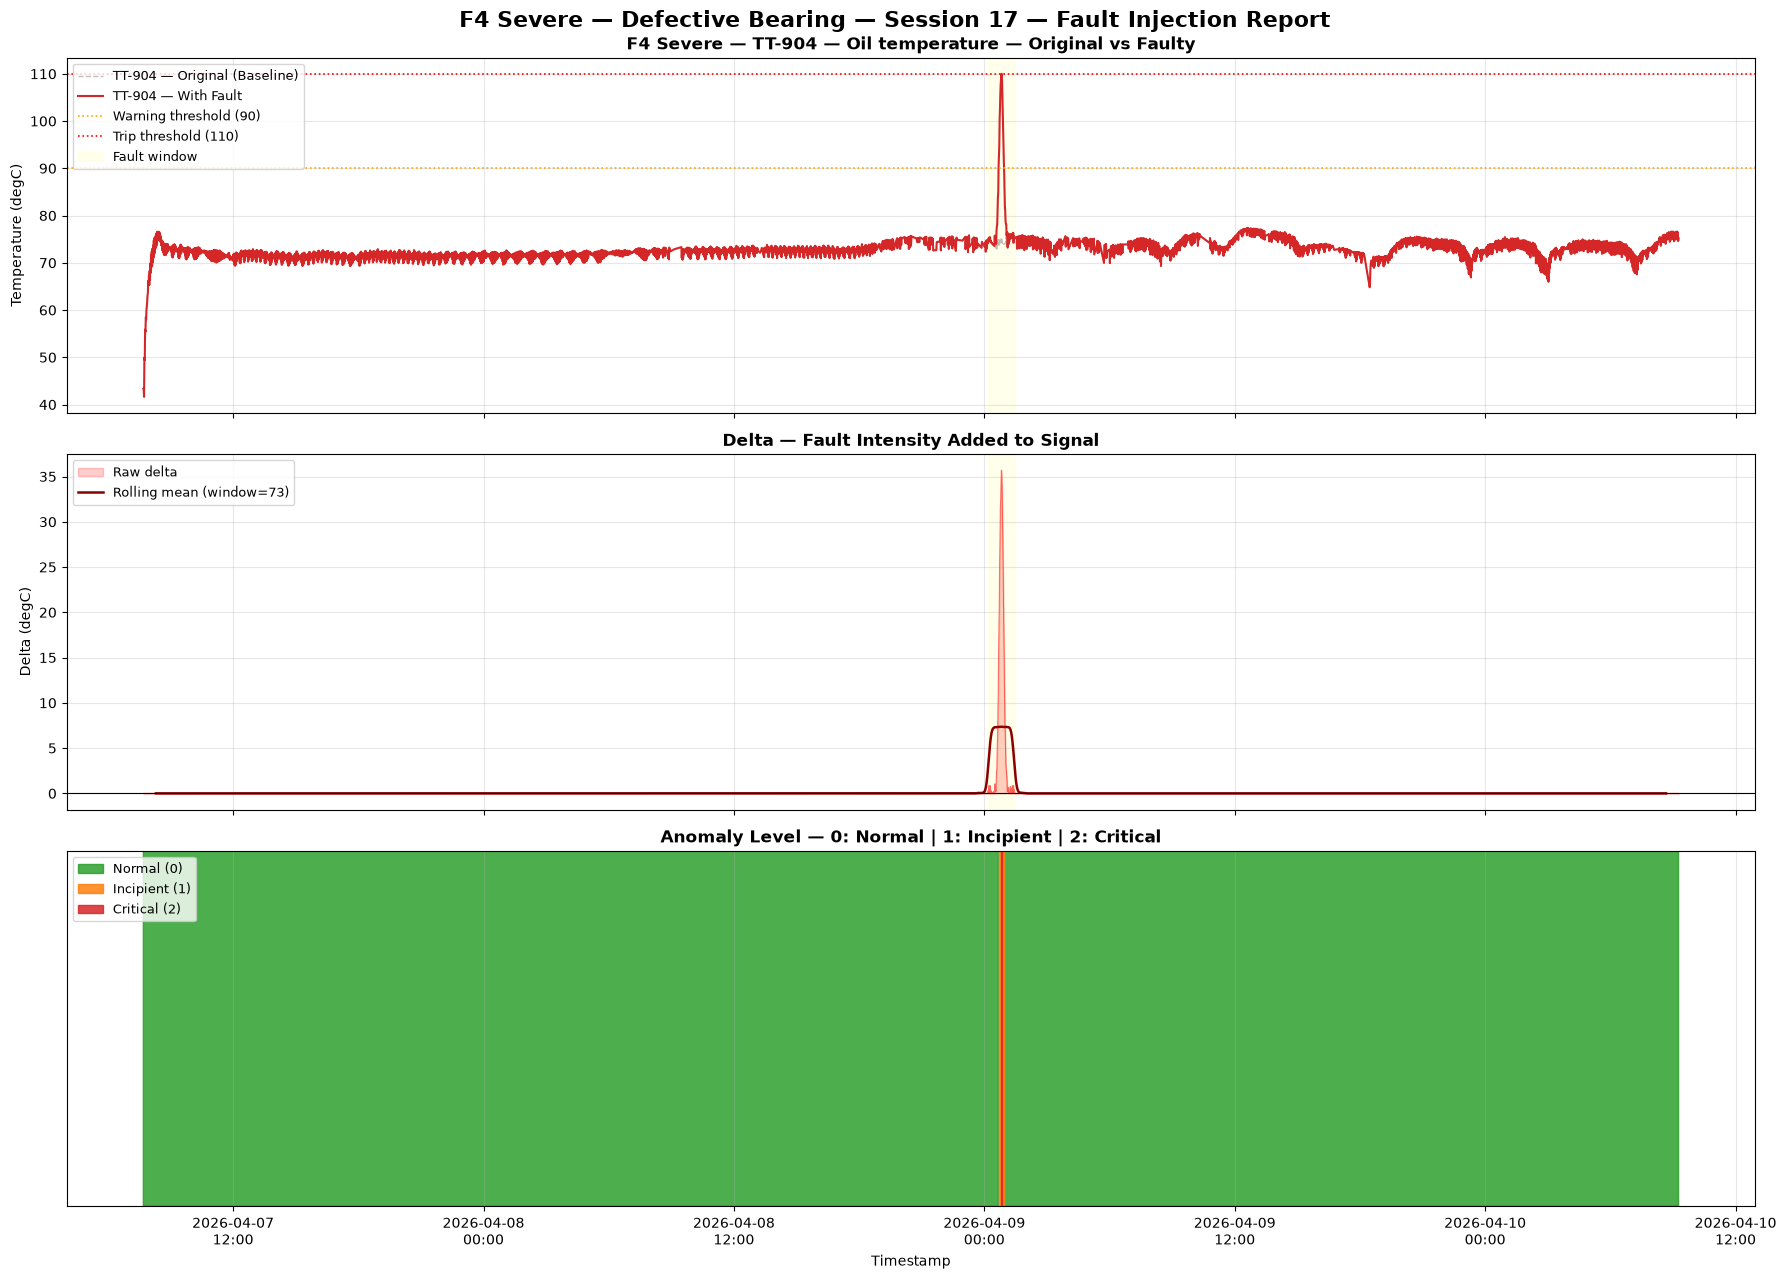

In [53]:
""" F4 Severe — Fault Profile Verification Plot — Session 17 """

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 13), sharex=True)

# ============================================================
# PANEL 1 — Original vs Faulty TT-904
# ============================================================

f4_severe_s17_fault_start_timestamp = f4_severe_s17_df.index[f4_severe_s17_start_idx]
f4_severe_s17_fault_end_timestamp = f4_severe_s17_df.index[f4_severe_s17_end_idx - 1]

ax1.plot(
    f4_severe_s17_df_orig.index,
    f4_severe_s17_df_orig["TT-904"],
    color="gray",
    alpha=0.5,
    linestyle="--",
    linewidth=1.0,
    label="TT-904 — Original (Baseline)"
)

ax1.plot(
    f4_severe_s17_df.index,
    f4_severe_s17_df["TT-904"],
    color="#d62728",
    linewidth=1.5,
    label="TT-904 — With Fault"
)

ax1.axhline(
    y=tt904_warning,
    color="orange",
    linestyle=":",
    linewidth=1.2,
    label=f"Warning threshold ({tt904_warning})"
)

ax1.axhline(
    y=tt904_trip,
    color="red",
    linestyle=":",
    linewidth=1.2,
    label=f"Trip threshold ({tt904_trip})"
)

ax1.axvspan(
    f4_severe_s17_fault_start_timestamp,
    f4_severe_s17_fault_end_timestamp,
    color="yellow",
    alpha=0.08,
    label="Fault window"
)

ax1.set_title("F4 Severe — TT-904 — Oil temperature — Original vs Faulty", fontweight="bold")
ax1.set_ylabel("Temperature (degC)")
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(True, alpha=0.3)

# ============================================================
# PANEL 2 — Delta (fault intensity)
# ============================================================

f4_severe_s17_delta_full = f4_severe_s17_df["TT-904"] - f4_severe_s17_df_orig["TT-904"]
f4_severe_s17_roll_window = max(10, len(f4_severe_s17_delta_full) // 60)
f4_severe_s17_delta_rolling_mean = f4_severe_s17_delta_full.rolling(f4_severe_s17_roll_window, center=True).mean()

ax2.fill_between(
    f4_severe_s17_df.index,
    0,
    f4_severe_s17_delta_full,
    color="red",
    alpha=0.2,
    label="Raw delta"
)

ax2.plot(
    f4_severe_s17_df.index,
    f4_severe_s17_delta_full,
    color="red",
    linewidth=0.8,
    alpha=0.5
)

ax2.plot(
    f4_severe_s17_df.index,
    f4_severe_s17_delta_rolling_mean,
    color="#8B0000",
    linewidth=1.8,
    label=f"Rolling mean (window={f4_severe_s17_roll_window})"
)

ax2.axhline(y=0, color="black", linewidth=0.8)
ax2.axvspan(f4_severe_s17_fault_start_timestamp, f4_severe_s17_fault_end_timestamp, color="yellow", alpha=0.08)
ax2.set_title("Delta — Fault Intensity Added to Signal", fontweight="bold")
ax2.set_ylabel("Delta (degC)")
ax2.legend(loc="upper left", fontsize=9)
ax2.grid(True, alpha=0.3)

# ============================================================
# PANEL 3 — Anomaly level bar
# ============================================================

f4_severe_s17_normal_mask = f4_severe_s17_df["anomaly_level"] == 0
f4_severe_s17_incipient_mask = f4_severe_s17_df["anomaly_level"] == 1
f4_severe_s17_critical_mask = f4_severe_s17_df["anomaly_level"] == 2

ax3.fill_between(f4_severe_s17_df.index, 0, 1, where=f4_severe_s17_normal_mask, color="#2ca02c", step="mid", alpha=0.85, label="Normal (0)")
ax3.fill_between(f4_severe_s17_df.index, 0, 1, where=f4_severe_s17_incipient_mask, color="#ff7f0e", step="mid", alpha=0.85, label="Incipient (1)")
ax3.fill_between(f4_severe_s17_df.index, 0, 1, where=f4_severe_s17_critical_mask, color="#d62728", step="mid", alpha=0.85, label="Critical (2)")

ax3.set_yticks([])
ax3.set_ylim(0, 1)
ax3.set_xlabel("Timestamp")
ax3.set_title("Anomaly Level — 0: Normal | 1: Incipient | 2: Critical", fontweight="bold")
ax3.legend(loc="upper left", fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))

fig.suptitle("F4 Severe — Defective Bearing — Session 17 — Fault Injection Report", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


## Combined Faults

### 2 Fault Combo

#### Session 16 - F1 severe + F3 small

In [54]:
""" Combined Faults — Combo A — F1 Severe + F3 Small — Session 16 """

np.random.seed(42)

# ============================================================
# BASE SESSION
# ============================================================

combo_a_s16_df_orig = dict_sessions[16].copy()

# ============================================================
# F1 SEVERE COMPONENT — PT-903 — ramp to trip level
# ============================================================

combo_a_s16_f1_main_sensor   = "PT-903"
combo_a_s16_f1_start_from    = 0.20
combo_a_s16_f1_length_hours  = 8
combo_a_s16_f1_smooth_window = 10

combo_a_s16_f1_session_length = len(combo_a_s16_df_orig)
combo_a_s16_f1_start_idx      = int(round(combo_a_s16_f1_session_length * combo_a_s16_f1_start_from))
combo_a_s16_f1_end_idx        = min(combo_a_s16_f1_start_idx + int(round(combo_a_s16_f1_length_hours * 60)), combo_a_s16_f1_session_length)
combo_a_s16_f1_total_l        = combo_a_s16_f1_end_idx - combo_a_s16_f1_start_idx

combo_a_s16_f1_baseline_mean = combo_a_s16_df_orig["PT-903"].iloc[:combo_a_s16_f1_start_idx].mean()
combo_a_s16_f1_baseline_std  = combo_a_s16_df_orig["PT-903"].iloc[:combo_a_s16_f1_start_idx].std()

combo_a_s16_f1_target    = pt903_trip
combo_a_s16_f1_delta_mag = combo_a_s16_f1_target - combo_a_s16_f1_baseline_mean

combo_a_s16_f1_trend       = np.linspace(0, combo_a_s16_f1_delta_mag, combo_a_s16_f1_total_l)
combo_a_s16_f1_noise_scale = np.linspace(combo_a_s16_f1_baseline_std * 0.10, combo_a_s16_f1_baseline_std * 0.50, combo_a_s16_f1_total_l)
combo_a_s16_f1_noise       = np.random.normal(0, combo_a_s16_f1_noise_scale, combo_a_s16_f1_total_l)
combo_a_s16_f1_ramp        = combo_a_s16_f1_trend + combo_a_s16_f1_noise
combo_a_s16_f1_delta       = pd.Series(combo_a_s16_f1_ramp).rolling(combo_a_s16_f1_smooth_window, center=True, min_periods=1).mean().values

combo_a_s16_f1_active_values       = combo_a_s16_df_orig["PT-903"].iloc[combo_a_s16_f1_start_idx:combo_a_s16_f1_end_idx].to_numpy()
combo_a_s16_f1_positive_peak_idx   = int(np.argmax(combo_a_s16_f1_delta))
combo_a_s16_f1_delta               = np.maximum(combo_a_s16_f1_delta, 0)
combo_a_s16_f1_desired_peak_delta  = combo_a_s16_f1_target - combo_a_s16_f1_active_values[combo_a_s16_f1_positive_peak_idx]
if combo_a_s16_f1_delta[combo_a_s16_f1_positive_peak_idx] > 0 and combo_a_s16_f1_desired_peak_delta > 0:
    combo_a_s16_f1_delta = combo_a_s16_f1_delta * (combo_a_s16_f1_desired_peak_delta / combo_a_s16_f1_delta[combo_a_s16_f1_positive_peak_idx])
combo_a_s16_f1_upper_delta = combo_a_s16_f1_target - combo_a_s16_f1_active_values
combo_a_s16_f1_delta       = np.minimum(combo_a_s16_f1_delta, combo_a_s16_f1_upper_delta)
combo_a_s16_f1_delta       = np.maximum(combo_a_s16_f1_delta, 0)

combo_a_s16_f1_corr_threshold = 0.70
combo_a_s16_f1_corr           = combo_a_s16_df_orig.corr(method="pearson", numeric_only=True)["PT-903"]
combo_a_s16_f1_corr_sensors   = combo_a_s16_f1_corr[abs(combo_a_s16_f1_corr) >= combo_a_s16_f1_corr_threshold].index.tolist()

print(f"F1 severe — window: {combo_a_s16_f1_start_idx} to {combo_a_s16_f1_end_idx} ({combo_a_s16_f1_total_l} rows)")
print(f"F1 severe — correlated sensors: {combo_a_s16_f1_corr_sensors}")

# ============================================================
# F3 SMALL COMPONENT — PT-903 — low-amplitude oscillation
# ============================================================

combo_a_s16_f3_main_sensor   = "PT-903"
combo_a_s16_f3_start_from    = 0.30
combo_a_s16_f3_length_hours  = 6
combo_a_s16_f3_period_samples = 90

combo_a_s16_f3_session_length = len(combo_a_s16_df_orig)
combo_a_s16_f3_start_idx      = int(round(combo_a_s16_f3_session_length * combo_a_s16_f3_start_from))
combo_a_s16_f3_end_idx        = min(combo_a_s16_f3_start_idx + int(round(combo_a_s16_f3_length_hours * 60)), combo_a_s16_f3_session_length)
combo_a_s16_f3_total_l        = combo_a_s16_f3_end_idx - combo_a_s16_f3_start_idx

combo_a_s16_f3_baseline_mean = combo_a_s16_df_orig["PT-903"].iloc[:combo_a_s16_f3_start_idx].mean()
combo_a_s16_f3_baseline_std  = combo_a_s16_df_orig["PT-903"].iloc[:combo_a_s16_f3_start_idx].std()

combo_a_s16_f3_target    = combo_a_s16_f3_baseline_mean + small_warning_fraction * (pt903_warning - combo_a_s16_f3_baseline_mean)
combo_a_s16_f3_delta_mag = combo_a_s16_f3_target - combo_a_s16_f3_baseline_mean

combo_a_s16_f3_t            = np.arange(combo_a_s16_f3_total_l)
combo_a_s16_f3_phase_jitter = pd.Series(np.random.normal(0, 0.08, combo_a_s16_f3_total_l)).rolling(8, center=True, min_periods=1).mean().values
combo_a_s16_f3_envelope     = 0.35 + 0.35 * np.sin(2 * np.pi * combo_a_s16_f3_t / max(combo_a_s16_f3_period_samples * 4, 1))
combo_a_s16_f3_noise_std    = min(combo_a_s16_f3_baseline_std * 0.05, abs(combo_a_s16_f3_delta_mag) * 0.10)
combo_a_s16_f3_noise        = np.random.normal(0, combo_a_s16_f3_noise_std, combo_a_s16_f3_total_l)
combo_a_s16_f3_delta        = combo_a_s16_f3_delta_mag * combo_a_s16_f3_envelope * np.sin(2 * np.pi * combo_a_s16_f3_t / combo_a_s16_f3_period_samples + combo_a_s16_f3_phase_jitter) + combo_a_s16_f3_noise

combo_a_s16_f3_active_values      = combo_a_s16_df_orig["PT-903"].iloc[combo_a_s16_f3_start_idx:combo_a_s16_f3_end_idx].to_numpy()
combo_a_s16_f3_positive_peak_idx  = int(np.argmax(combo_a_s16_f3_delta))
combo_a_s16_f3_desired_peak_delta = combo_a_s16_f3_target - combo_a_s16_f3_active_values[combo_a_s16_f3_positive_peak_idx]
if combo_a_s16_f3_delta[combo_a_s16_f3_positive_peak_idx] > 0 and combo_a_s16_f3_desired_peak_delta > 0:
    combo_a_s16_f3_delta = combo_a_s16_f3_delta * (combo_a_s16_f3_desired_peak_delta / combo_a_s16_f3_delta[combo_a_s16_f3_positive_peak_idx])
combo_a_s16_f3_upper_delta = combo_a_s16_f3_target - combo_a_s16_f3_active_values
combo_a_s16_f3_delta       = np.minimum(combo_a_s16_f3_delta, combo_a_s16_f3_upper_delta)

combo_a_s16_f3_corr_threshold = 0.70
combo_a_s16_f3_corr           = combo_a_s16_df_orig.corr(method="pearson", numeric_only=True)["PT-903"]
combo_a_s16_f3_corr_sensors   = combo_a_s16_f3_corr[abs(combo_a_s16_f3_corr) >= combo_a_s16_f3_corr_threshold].index.tolist()

print(f"F3 small  — window: {combo_a_s16_f3_start_idx} to {combo_a_s16_f3_end_idx} ({combo_a_s16_f3_total_l} rows)")
print(f"F3 small  — correlated sensors: {combo_a_s16_f3_corr_sensors}")

# ============================================================
# APPLY F1 SEVERE INJECTION
# ============================================================

combo_a_s16_df = combo_a_s16_df_orig.copy()

combo_a_s16_f1_propagation_scale = 0.25
for sensor in combo_a_s16_f1_corr_sensors:
    if sensor in combo_a_s16_df.columns:
        scale = 1.0 if sensor == combo_a_s16_f1_main_sensor else combo_a_s16_f1_propagation_scale
        combo_a_s16_df.iloc[combo_a_s16_f1_start_idx:combo_a_s16_f1_end_idx, combo_a_s16_df.columns.get_loc(sensor)] += combo_a_s16_f1_delta * combo_a_s16_f1_corr[sensor] * scale

combo_a_s16_f1_remaining = combo_a_s16_f1_session_length - combo_a_s16_f1_end_idx
if combo_a_s16_f1_remaining > 0:
    combo_a_s16_f1_decay_rate = 0.3
    combo_a_s16_f1_decay      = combo_a_s16_f1_delta[-1] * np.exp(-combo_a_s16_f1_decay_rate * np.linspace(0, 1, combo_a_s16_f1_remaining))
    for sensor in combo_a_s16_f1_corr_sensors:
        if sensor in combo_a_s16_df.columns:
            scale = 1.0 if sensor == combo_a_s16_f1_main_sensor else combo_a_s16_f1_propagation_scale
            combo_a_s16_df.iloc[combo_a_s16_f1_end_idx:, combo_a_s16_df.columns.get_loc(sensor)] += combo_a_s16_f1_decay * combo_a_s16_f1_corr[sensor] * scale

# ============================================================
# APPLY F3 SMALL INJECTION
# ============================================================

combo_a_s16_f3_propagation_scale = 0.20
for sensor in combo_a_s16_f3_corr_sensors:
    if sensor in combo_a_s16_df.columns:
        scale = 1.0 if sensor == combo_a_s16_f3_main_sensor else combo_a_s16_f3_propagation_scale
        combo_a_s16_df.iloc[combo_a_s16_f3_start_idx:combo_a_s16_f3_end_idx, combo_a_s16_df.columns.get_loc(sensor)] += combo_a_s16_f3_delta * combo_a_s16_f3_corr[sensor] * scale

combo_a_s16_f3_remaining = combo_a_s16_f3_session_length - combo_a_s16_f3_end_idx
if combo_a_s16_f3_remaining > 0:
    combo_a_s16_f3_decay_rate = 1.2
    combo_a_s16_f3_decay      = combo_a_s16_f3_delta[-1] * np.exp(-combo_a_s16_f3_decay_rate * np.linspace(0, 1, combo_a_s16_f3_remaining))
    for sensor in combo_a_s16_f3_corr_sensors:
        if sensor in combo_a_s16_df.columns:
            scale = 1.0 if sensor == combo_a_s16_f3_main_sensor else combo_a_s16_f3_propagation_scale
            combo_a_s16_df.iloc[combo_a_s16_f3_end_idx:, combo_a_s16_df.columns.get_loc(sensor)] += combo_a_s16_f3_decay * combo_a_s16_f3_corr[sensor] * scale

# ============================================================
# LABELS — active components are explicit; severity keeps the highest observed level
# ============================================================

combo_a_s16_df["anomaly_level"]       = 0
combo_a_s16_df["is_injected_anomaly"] = 0
combo_a_s16_df["anomaly_type"]        = "normal"

for component_col in ["f1_active", "f1_decay", "f3_active", "f3_decay"]:
    combo_a_s16_df[component_col] = 0

combo_a_s16_f1_active_mask = combo_a_s16_df.index[combo_a_s16_f1_start_idx:combo_a_s16_f1_end_idx]
combo_a_s16_f3_active_mask = combo_a_s16_df.index[combo_a_s16_f3_start_idx:combo_a_s16_f3_end_idx]
combo_a_s16_df.loc[combo_a_s16_f1_active_mask, "f1_active"] = 1
combo_a_s16_df.loc[combo_a_s16_f3_active_mask, "f3_active"] = 1

if combo_a_s16_f1_remaining > 0:
    combo_a_s16_f1_decay_mask = combo_a_s16_df.index[combo_a_s16_f1_end_idx:]
    combo_a_s16_df.loc[combo_a_s16_f1_decay_mask, "f1_decay"] = 1
if combo_a_s16_f3_remaining > 0:
    combo_a_s16_f3_decay_mask = combo_a_s16_df.index[combo_a_s16_f3_end_idx:]
    combo_a_s16_df.loc[combo_a_s16_f3_decay_mask, "f3_decay"] = 1

combo_a_s16_df["active_fault_count"] = combo_a_s16_df[["f1_active", "f3_active"]].sum(axis=1)
combo_a_s16_df["has_active_overlap"] = (combo_a_s16_df["active_fault_count"] >= 2).astype(int)

combo_a_s16_injected_mask = combo_a_s16_df[["f1_active", "f1_decay", "f3_active", "f3_decay"]].sum(axis=1) > 0
combo_a_s16_df.loc[combo_a_s16_injected_mask, "is_injected_anomaly"] = 1
combo_a_s16_df.loc[combo_a_s16_injected_mask, "anomaly_level"] = 1

# F1 severe severity — dynamic based on PT-903 values during active and stabilization periods
combo_a_s16_f1_label_index = combo_a_s16_df.index[combo_a_s16_f1_start_idx:]
combo_a_s16_f1_injected_values = combo_a_s16_df.loc[combo_a_s16_f1_label_index, "PT-903"]
combo_a_s16_f1_labels = np.where(
    combo_a_s16_f1_injected_values >= pt903_trip,    2,
    np.where(combo_a_s16_f1_injected_values >= pt903_warning, 1, 0)
)
combo_a_s16_df.loc[combo_a_s16_f1_label_index, "anomaly_level"] = np.maximum(
    combo_a_s16_df.loc[combo_a_s16_f1_label_index, "anomaly_level"],
    combo_a_s16_f1_labels
)

# F3 small is an active incipient oscillation; decay is tracked separately via f3_decay
combo_a_s16_df.loc[combo_a_s16_f3_active_mask, "anomaly_level"] = np.maximum(
    combo_a_s16_df.loc[combo_a_s16_f3_active_mask, "anomaly_level"],
    1
)

combo_a_s16_df["anomaly_type"] = "normal"
combo_a_s16_df.loc[combo_a_s16_df["f1_active"] == 1, "anomaly_type"] = "clogged_filters"
combo_a_s16_df.loc[combo_a_s16_df["f3_active"] == 1, "anomaly_type"] = np.where(
    combo_a_s16_df.loc[combo_a_s16_df["f3_active"] == 1, "anomaly_type"] == "normal",
    "valve_fault",
    combo_a_s16_df.loc[combo_a_s16_df["f3_active"] == 1, "anomaly_type"] + "+valve_fault"
)

combo_a_s16_decay_only_mask = (combo_a_s16_df["anomaly_type"] == "normal") & ((combo_a_s16_df["f1_decay"] == 1) | (combo_a_s16_df["f3_decay"] == 1))
combo_a_s16_df.loc[combo_a_s16_decay_only_mask & (combo_a_s16_df["f1_decay"] == 1), "anomaly_type"] = "clogged_filters_decay"
combo_a_s16_df.loc[combo_a_s16_decay_only_mask & (combo_a_s16_df["f3_decay"] == 1), "anomaly_type"] = np.where(
    combo_a_s16_df.loc[combo_a_s16_decay_only_mask & (combo_a_s16_df["f3_decay"] == 1), "anomaly_type"] == "normal",
    "valve_fault_decay",
    combo_a_s16_df.loc[combo_a_s16_decay_only_mask & (combo_a_s16_df["f3_decay"] == 1), "anomaly_type"] + "+valve_fault_decay"
)

print(f"Active overlap rows: {combo_a_s16_df['has_active_overlap'].sum()}")

# SAVE
# ============================================================

combo_a_s16_df.to_csv(f"{output_dir_combined}/session_16_combo_A_F1severe_F3small.csv")

print(f"\nSession 16 Combo A saved")
print(f"Normal rows:         {(combo_a_s16_df['is_injected_anomaly'] == 0).sum()}")
print(f"Anomaly rows:        {combo_a_s16_df['is_injected_anomaly'].sum()}")
print(f"Level 1 rows:        {(combo_a_s16_df['anomaly_level'] == 1).sum()}")
print(f"Level 2 rows:        {(combo_a_s16_df['anomaly_level'] == 2).sum()}")
print(f"Anomaly types found: {combo_a_s16_df['anomaly_type'].unique()}")

F1 severe — window: 673 to 1153 (480 rows)
F1 severe — correlated sensors: ['FT-901', 'PT-901', 'PT-902', 'PT-903', 'VSD-901_CORRENT', 'VSD-901_POWER']
F3 small  — window: 1010 to 1370 (360 rows)
F3 small  — correlated sensors: ['FT-901', 'PT-901', 'PT-902', 'PT-903', 'VSD-901_CORRENT', 'VSD-901_POWER']
Active overlap rows: 143

Session 16 Combo A saved
Normal rows:         673
Anomaly rows:        2694
Level 1 rows:        2365
Level 2 rows:        329
Anomaly types found: ['normal' 'clogged_filters' 'clogged_filters+valve_fault' 'valve_fault'
 'clogged_filters_decay+valve_fault_decay']


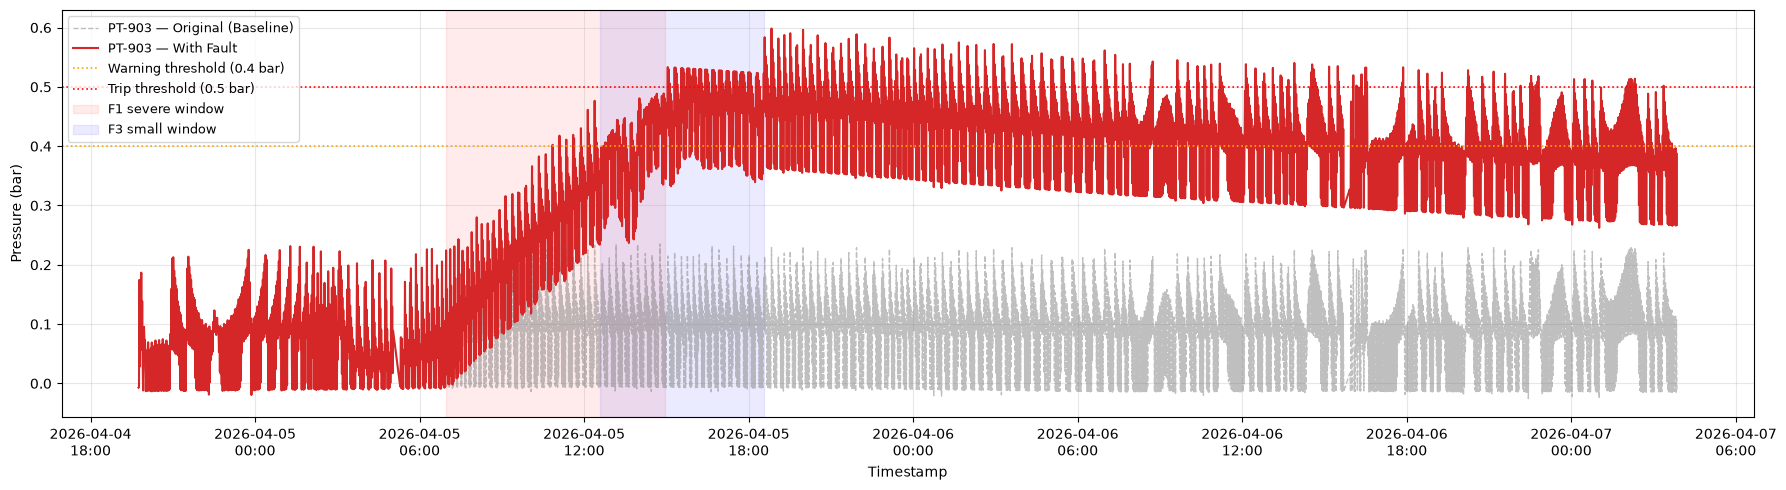

In [60]:
""" Combined Faults — Combo A — F1 Severe + F3 Small — Verification Plot — Session 16 """

fig, ax1 = plt.subplots(1, 1, figsize=(18, 5))

# ============================================================
# PANEL 1 — Original vs Faulty PT-903 (both fault windows shown)
# ============================================================

combo_a_s16_f1_fault_start_timestamp = combo_a_s16_df.index[combo_a_s16_f1_start_idx]
combo_a_s16_f1_fault_end_timestamp   = combo_a_s16_df.index[combo_a_s16_f1_end_idx - 1]
combo_a_s16_f3_fault_start_timestamp = combo_a_s16_df.index[combo_a_s16_f3_start_idx]
combo_a_s16_f3_fault_end_timestamp   = combo_a_s16_df.index[combo_a_s16_f3_end_idx - 1]

ax1.plot(
    combo_a_s16_df_orig.index,
    combo_a_s16_df_orig["PT-903"],
    color="gray",
    alpha=0.5,
    linestyle="--",
    linewidth=1.0,
    label="PT-903 — Original (Baseline)"
)

ax1.plot(
    combo_a_s16_df.index,
    combo_a_s16_df["PT-903"],
    color="#d62728",
    linewidth=1.5,
    label="PT-903 — With Fault"
)

ax1.axhline(
    y=pt903_warning,
    color="orange",
    linestyle=":",
    linewidth=1.2,
    label=f"Warning threshold ({pt903_warning} bar)"
)

ax1.axhline(
    y=pt903_trip,
    color="red",
    linestyle=":",
    linewidth=1.2,
    label=f"Trip threshold ({pt903_trip} bar)"
)

ax1.axvspan(
    combo_a_s16_f1_fault_start_timestamp,
    combo_a_s16_f1_fault_end_timestamp,
    color="red",
    alpha=0.08,
    label="F1 severe window"
)

ax1.axvspan(
    combo_a_s16_f3_fault_start_timestamp,
    combo_a_s16_f3_fault_end_timestamp,
    color="blue",
    alpha=0.08,
    label="F3 small window"
)

ax1.set_ylabel("Pressure (bar)")
ax1.set_xlabel("Timestamp")
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))

plt.tight_layout()
plt.savefig("fault_combo_a_s16.png", dpi=200, bbox_inches="tight")
plt.show()

#### Session 17 - F1 severe + F3 small

In [56]:
""" Combined Faults — Combo A — F1 Severe + F3 Small — Session 17 """

np.random.seed(42)

# ============================================================
# BASE SESSION
# ============================================================

combo_a_s17_df_orig = dict_sessions[17].copy()

# ============================================================
# F1 SEVERE COMPONENT — PT-903 — ramp to trip level
# ============================================================

combo_a_s17_f1_main_sensor    = "PT-903"
combo_a_s17_f1_start_from     = 0.25
combo_a_s17_f1_length_hours   = 8
combo_a_s17_f1_smooth_window  = 10

combo_a_s17_f1_session_length = len(combo_a_s17_df_orig)
combo_a_s17_f1_start_idx      = int(round(combo_a_s17_f1_session_length * combo_a_s17_f1_start_from))
combo_a_s17_f1_end_idx        = min(combo_a_s17_f1_start_idx + int(round(combo_a_s17_f1_length_hours * 60)), combo_a_s17_f1_session_length)
combo_a_s17_f1_total_l        = combo_a_s17_f1_end_idx - combo_a_s17_f1_start_idx

combo_a_s17_f1_baseline_mean = combo_a_s17_df_orig["PT-903"].iloc[:combo_a_s17_f1_start_idx].mean()
combo_a_s17_f1_baseline_std  = combo_a_s17_df_orig["PT-903"].iloc[:combo_a_s17_f1_start_idx].std()

combo_a_s17_f1_target    = pt903_trip
combo_a_s17_f1_delta_mag = combo_a_s17_f1_target - combo_a_s17_f1_baseline_mean

combo_a_s17_f1_trend       = np.linspace(0, combo_a_s17_f1_delta_mag, combo_a_s17_f1_total_l)
combo_a_s17_f1_noise_scale = np.linspace(combo_a_s17_f1_baseline_std * 0.10, combo_a_s17_f1_baseline_std * 0.50, combo_a_s17_f1_total_l)
combo_a_s17_f1_noise       = np.random.normal(0, combo_a_s17_f1_noise_scale, combo_a_s17_f1_total_l)
combo_a_s17_f1_ramp        = combo_a_s17_f1_trend + combo_a_s17_f1_noise
combo_a_s17_f1_delta       = pd.Series(combo_a_s17_f1_ramp).rolling(combo_a_s17_f1_smooth_window, center=True, min_periods=1).mean().values

combo_a_s17_f1_active_values      = combo_a_s17_df_orig["PT-903"].iloc[combo_a_s17_f1_start_idx:combo_a_s17_f1_end_idx].to_numpy()
combo_a_s17_f1_positive_peak_idx  = int(np.argmax(combo_a_s17_f1_delta))
combo_a_s17_f1_delta              = np.maximum(combo_a_s17_f1_delta, 0)
combo_a_s17_f1_desired_peak_delta = combo_a_s17_f1_target - combo_a_s17_f1_active_values[combo_a_s17_f1_positive_peak_idx]
if combo_a_s17_f1_delta[combo_a_s17_f1_positive_peak_idx] > 0 and combo_a_s17_f1_desired_peak_delta > 0:
    combo_a_s17_f1_delta = combo_a_s17_f1_delta * (combo_a_s17_f1_desired_peak_delta / combo_a_s17_f1_delta[combo_a_s17_f1_positive_peak_idx])
combo_a_s17_f1_upper_delta = combo_a_s17_f1_target - combo_a_s17_f1_active_values
combo_a_s17_f1_delta       = np.minimum(combo_a_s17_f1_delta, combo_a_s17_f1_upper_delta)
combo_a_s17_f1_delta       = np.maximum(combo_a_s17_f1_delta, 0)

combo_a_s17_f1_corr_threshold = 0.70
combo_a_s17_f1_corr           = combo_a_s17_df_orig.corr(method="pearson", numeric_only=True)["PT-903"]
combo_a_s17_f1_corr_sensors   = combo_a_s17_f1_corr[abs(combo_a_s17_f1_corr) >= combo_a_s17_f1_corr_threshold].index.tolist()

print(f"F1 severe — window: {combo_a_s17_f1_start_idx} to {combo_a_s17_f1_end_idx} ({combo_a_s17_f1_total_l} rows)")
print(f"F1 severe — correlated sensors: {combo_a_s17_f1_corr_sensors}")

# ============================================================
# F3 SMALL COMPONENT — PT-903 — low-amplitude oscillation
# — starts mid-F1 window to force overlap
# ============================================================

combo_a_s17_f3_main_sensor    = "PT-903"
combo_a_s17_f3_start_from     = 0.32
combo_a_s17_f3_length_hours   = 7
combo_a_s17_f3_period_samples = 90

combo_a_s17_f3_session_length = len(combo_a_s17_df_orig)
combo_a_s17_f3_start_idx      = int(round(combo_a_s17_f3_session_length * combo_a_s17_f3_start_from))
combo_a_s17_f3_end_idx        = min(combo_a_s17_f3_start_idx + int(round(combo_a_s17_f3_length_hours * 60)), combo_a_s17_f3_session_length)
combo_a_s17_f3_total_l        = combo_a_s17_f3_end_idx - combo_a_s17_f3_start_idx

combo_a_s17_f3_baseline_mean = combo_a_s17_df_orig["PT-903"].iloc[:combo_a_s17_f3_start_idx].mean()
combo_a_s17_f3_baseline_std  = combo_a_s17_df_orig["PT-903"].iloc[:combo_a_s17_f3_start_idx].std()

combo_a_s17_f3_target    = combo_a_s17_f3_baseline_mean + small_warning_fraction * (pt903_warning - combo_a_s17_f3_baseline_mean)
combo_a_s17_f3_delta_mag = combo_a_s17_f3_target - combo_a_s17_f3_baseline_mean

combo_a_s17_f3_t            = np.arange(combo_a_s17_f3_total_l)
combo_a_s17_f3_phase_jitter = pd.Series(np.random.normal(0, 0.08, combo_a_s17_f3_total_l)).rolling(8, center=True, min_periods=1).mean().values
combo_a_s17_f3_envelope     = 0.35 + 0.35 * np.sin(2 * np.pi * combo_a_s17_f3_t / max(combo_a_s17_f3_period_samples * 4, 1))
combo_a_s17_f3_noise_std    = min(combo_a_s17_f3_baseline_std * 0.05, abs(combo_a_s17_f3_delta_mag) * 0.10)
combo_a_s17_f3_noise        = np.random.normal(0, combo_a_s17_f3_noise_std, combo_a_s17_f3_total_l)
combo_a_s17_f3_delta        = combo_a_s17_f3_delta_mag * combo_a_s17_f3_envelope * np.sin(2 * np.pi * combo_a_s17_f3_t / combo_a_s17_f3_period_samples + combo_a_s17_f3_phase_jitter) + combo_a_s17_f3_noise

combo_a_s17_f3_active_values      = combo_a_s17_df_orig["PT-903"].iloc[combo_a_s17_f3_start_idx:combo_a_s17_f3_end_idx].to_numpy()
combo_a_s17_f3_positive_peak_idx  = int(np.argmax(combo_a_s17_f3_delta))
combo_a_s17_f3_desired_peak_delta = combo_a_s17_f3_target - combo_a_s17_f3_active_values[combo_a_s17_f3_positive_peak_idx]
if combo_a_s17_f3_delta[combo_a_s17_f3_positive_peak_idx] > 0 and combo_a_s17_f3_desired_peak_delta > 0:
    combo_a_s17_f3_delta = combo_a_s17_f3_delta * (combo_a_s17_f3_desired_peak_delta / combo_a_s17_f3_delta[combo_a_s17_f3_positive_peak_idx])
combo_a_s17_f3_upper_delta = combo_a_s17_f3_target - combo_a_s17_f3_active_values
combo_a_s17_f3_delta       = np.minimum(combo_a_s17_f3_delta, combo_a_s17_f3_upper_delta)

combo_a_s17_f3_corr_threshold = 0.70
combo_a_s17_f3_corr           = combo_a_s17_df_orig.corr(method="pearson", numeric_only=True)["PT-903"]
combo_a_s17_f3_corr_sensors   = combo_a_s17_f3_corr[abs(combo_a_s17_f3_corr) >= combo_a_s17_f3_corr_threshold].index.tolist()

print(f"F3 small  — window: {combo_a_s17_f3_start_idx} to {combo_a_s17_f3_end_idx} ({combo_a_s17_f3_total_l} rows)")
print(f"F3 small  — correlated sensors: {combo_a_s17_f3_corr_sensors}")
print(f"Overlap window: {combo_a_s17_f3_start_idx} to {combo_a_s17_f1_end_idx} ({combo_a_s17_f1_end_idx - combo_a_s17_f3_start_idx} rows)")

# ============================================================
# APPLY F1 SEVERE INJECTION
# ============================================================

combo_a_s17_df = combo_a_s17_df_orig.copy()

combo_a_s17_f1_propagation_scale = 0.25
for sensor in combo_a_s17_f1_corr_sensors:
    if sensor in combo_a_s17_df.columns:
        scale = 1.0 if sensor == combo_a_s17_f1_main_sensor else combo_a_s17_f1_propagation_scale
        combo_a_s17_df.iloc[combo_a_s17_f1_start_idx:combo_a_s17_f1_end_idx, combo_a_s17_df.columns.get_loc(sensor)] += combo_a_s17_f1_delta * combo_a_s17_f1_corr[sensor] * scale

combo_a_s17_f1_remaining = combo_a_s17_f1_session_length - combo_a_s17_f1_end_idx
if combo_a_s17_f1_remaining > 0:
    combo_a_s17_f1_decay_rate = 0.3
    combo_a_s17_f1_decay      = combo_a_s17_f1_delta[-1] * np.exp(-combo_a_s17_f1_decay_rate * np.linspace(0, 1, combo_a_s17_f1_remaining))
    for sensor in combo_a_s17_f1_corr_sensors:
        if sensor in combo_a_s17_df.columns:
            scale = 1.0 if sensor == combo_a_s17_f1_main_sensor else combo_a_s17_f1_propagation_scale
            combo_a_s17_df.iloc[combo_a_s17_f1_end_idx:, combo_a_s17_df.columns.get_loc(sensor)] += combo_a_s17_f1_decay * combo_a_s17_f1_corr[sensor] * scale

# ============================================================
# APPLY F3 SMALL INJECTION
# ============================================================

combo_a_s17_f3_propagation_scale = 0.20
for sensor in combo_a_s17_f3_corr_sensors:
    if sensor in combo_a_s17_df.columns:
        scale = 1.0 if sensor == combo_a_s17_f3_main_sensor else combo_a_s17_f3_propagation_scale
        combo_a_s17_df.iloc[combo_a_s17_f3_start_idx:combo_a_s17_f3_end_idx, combo_a_s17_df.columns.get_loc(sensor)] += combo_a_s17_f3_delta * combo_a_s17_f3_corr[sensor] * scale

combo_a_s17_f3_remaining = combo_a_s17_f3_session_length - combo_a_s17_f3_end_idx
if combo_a_s17_f3_remaining > 0:
    combo_a_s17_f3_decay_rate = 1.2
    combo_a_s17_f3_decay      = combo_a_s17_f3_delta[-1] * np.exp(-combo_a_s17_f3_decay_rate * np.linspace(0, 1, combo_a_s17_f3_remaining))
    for sensor in combo_a_s17_f3_corr_sensors:
        if sensor in combo_a_s17_df.columns:
            scale = 1.0 if sensor == combo_a_s17_f3_main_sensor else combo_a_s17_f3_propagation_scale
            combo_a_s17_df.iloc[combo_a_s17_f3_end_idx:, combo_a_s17_df.columns.get_loc(sensor)] += combo_a_s17_f3_decay * combo_a_s17_f3_corr[sensor] * scale

# ============================================================
# LABELS — active components are explicit; severity keeps the highest observed level
# ============================================================

combo_a_s17_df["anomaly_level"]       = 0
combo_a_s17_df["is_injected_anomaly"] = 0
combo_a_s17_df["anomaly_type"]        = "normal"

for component_col in ["f1_active", "f1_decay", "f3_active", "f3_decay"]:
    combo_a_s17_df[component_col] = 0

combo_a_s17_f1_active_mask = combo_a_s17_df.index[combo_a_s17_f1_start_idx:combo_a_s17_f1_end_idx]
combo_a_s17_f3_active_mask = combo_a_s17_df.index[combo_a_s17_f3_start_idx:combo_a_s17_f3_end_idx]
combo_a_s17_df.loc[combo_a_s17_f1_active_mask, "f1_active"] = 1
combo_a_s17_df.loc[combo_a_s17_f3_active_mask, "f3_active"] = 1

if combo_a_s17_f1_remaining > 0:
    combo_a_s17_f1_decay_mask = combo_a_s17_df.index[combo_a_s17_f1_end_idx:]
    combo_a_s17_df.loc[combo_a_s17_f1_decay_mask, "f1_decay"] = 1
if combo_a_s17_f3_remaining > 0:
    combo_a_s17_f3_decay_mask = combo_a_s17_df.index[combo_a_s17_f3_end_idx:]
    combo_a_s17_df.loc[combo_a_s17_f3_decay_mask, "f3_decay"] = 1

combo_a_s17_df["active_fault_count"] = combo_a_s17_df[["f1_active", "f3_active"]].sum(axis=1)
combo_a_s17_df["has_active_overlap"] = (combo_a_s17_df["active_fault_count"] >= 2).astype(int)

combo_a_s17_injected_mask = combo_a_s17_df[["f1_active", "f1_decay", "f3_active", "f3_decay"]].sum(axis=1) > 0
combo_a_s17_df.loc[combo_a_s17_injected_mask, "is_injected_anomaly"] = 1
combo_a_s17_df.loc[combo_a_s17_injected_mask, "anomaly_level"] = 1

# F1 severe severity — dynamic based on PT-903 values during active and stabilization periods
combo_a_s17_f1_label_index = combo_a_s17_df.index[combo_a_s17_f1_start_idx:]
combo_a_s17_f1_injected_values = combo_a_s17_df.loc[combo_a_s17_f1_label_index, "PT-903"]
combo_a_s17_f1_labels = np.where(
    combo_a_s17_f1_injected_values >= pt903_trip,    2,
    np.where(combo_a_s17_f1_injected_values >= pt903_warning, 1, 0)
)
combo_a_s17_df.loc[combo_a_s17_f1_label_index, "anomaly_level"] = np.maximum(
    combo_a_s17_df.loc[combo_a_s17_f1_label_index, "anomaly_level"],
    combo_a_s17_f1_labels
)

# F3 small is an active incipient oscillation; decay is tracked separately via f3_decay
combo_a_s17_df.loc[combo_a_s17_f3_active_mask, "anomaly_level"] = np.maximum(
    combo_a_s17_df.loc[combo_a_s17_f3_active_mask, "anomaly_level"],
    1
)

combo_a_s17_df["anomaly_type"] = "normal"
combo_a_s17_df.loc[combo_a_s17_df["f1_active"] == 1, "anomaly_type"] = "clogged_filters"
combo_a_s17_df.loc[combo_a_s17_df["f3_active"] == 1, "anomaly_type"] = np.where(
    combo_a_s17_df.loc[combo_a_s17_df["f3_active"] == 1, "anomaly_type"] == "normal",
    "valve_fault",
    combo_a_s17_df.loc[combo_a_s17_df["f3_active"] == 1, "anomaly_type"] + "+valve_fault"
)

combo_a_s17_decay_only_mask = (combo_a_s17_df["anomaly_type"] == "normal") & ((combo_a_s17_df["f1_decay"] == 1) | (combo_a_s17_df["f3_decay"] == 1))
combo_a_s17_df.loc[combo_a_s17_decay_only_mask & (combo_a_s17_df["f1_decay"] == 1), "anomaly_type"] = "clogged_filters_decay"
combo_a_s17_df.loc[combo_a_s17_decay_only_mask & (combo_a_s17_df["f3_decay"] == 1), "anomaly_type"] = np.where(
    combo_a_s17_df.loc[combo_a_s17_decay_only_mask & (combo_a_s17_df["f3_decay"] == 1), "anomaly_type"] == "normal",
    "valve_fault_decay",
    combo_a_s17_df.loc[combo_a_s17_decay_only_mask & (combo_a_s17_df["f3_decay"] == 1), "anomaly_type"] + "+valve_fault_decay"
)

print(f"Active overlap rows: {combo_a_s17_df['has_active_overlap'].sum()}")

# SAVE
# ============================================================

combo_a_s17_df.to_csv(f"{output_dir_combined}/session_17_combo_A_F1severe_F3small.csv")

print(f"\nSession 17 Combo A saved")
print(f"Normal rows:         {(combo_a_s17_df['is_injected_anomaly'] == 0).sum()}")
print(f"Anomaly rows:        {combo_a_s17_df['is_injected_anomaly'].sum()}")
print(f"Level 1 rows:        {(combo_a_s17_df['anomaly_level'] == 1).sum()}")
print(f"Level 2 rows:        {(combo_a_s17_df['anomaly_level'] == 2).sum()}")
print(f"Anomaly types found: {combo_a_s17_df['anomaly_type'].unique()}")

F1 severe — window: 1104 to 1584 (480 rows)
F1 severe — correlated sensors: ['PT-903', 'pt903_frozen_flag']
F3 small  — window: 1413 to 1833 (420 rows)
F3 small  — correlated sensors: ['PT-903', 'pt903_frozen_flag']
Overlap window: 1413 to 1584 (171 rows)
Active overlap rows: 171


/var/folders/df/cfzb18t5629c221k8xlry1dw0000gn/T/ipykernel_38570/2982052086.py:108: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-0.00344644 -0.00268761 -0.00403395 -0.00432953 -0.00356711 -0.00371549
 -0.00314217 -0.00300264 -0.00284713 -0.00042536  0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.         -0.0009256   0.         -0.00124755 -0.00129543 -0.00165071
 -0.00294309 -0.00187867 -0.00314555 -0.00117608 -0.00059604 -0.00114014
 -0.00245182 -0.00111874 -0.00113764 -0.00189987  0.         -0.00041369
  0.         -0.00279786 -0.00444944 -0.00267295 -0.00242552 -0.00200354
 -0.00155708 -0.00256156 -0.00509948 -0.00683259 -0.00653807 -0.00532439
 -0.00544625 -0.00827552 -0.00757832 -0.00787825 -0.00750508 -0.00575442
 -0.00569753 -0.00631746 -0.00720369 -0.00871088 -0.00887747 -0.00728863
 -0.0082

KeyboardInterrupt: 

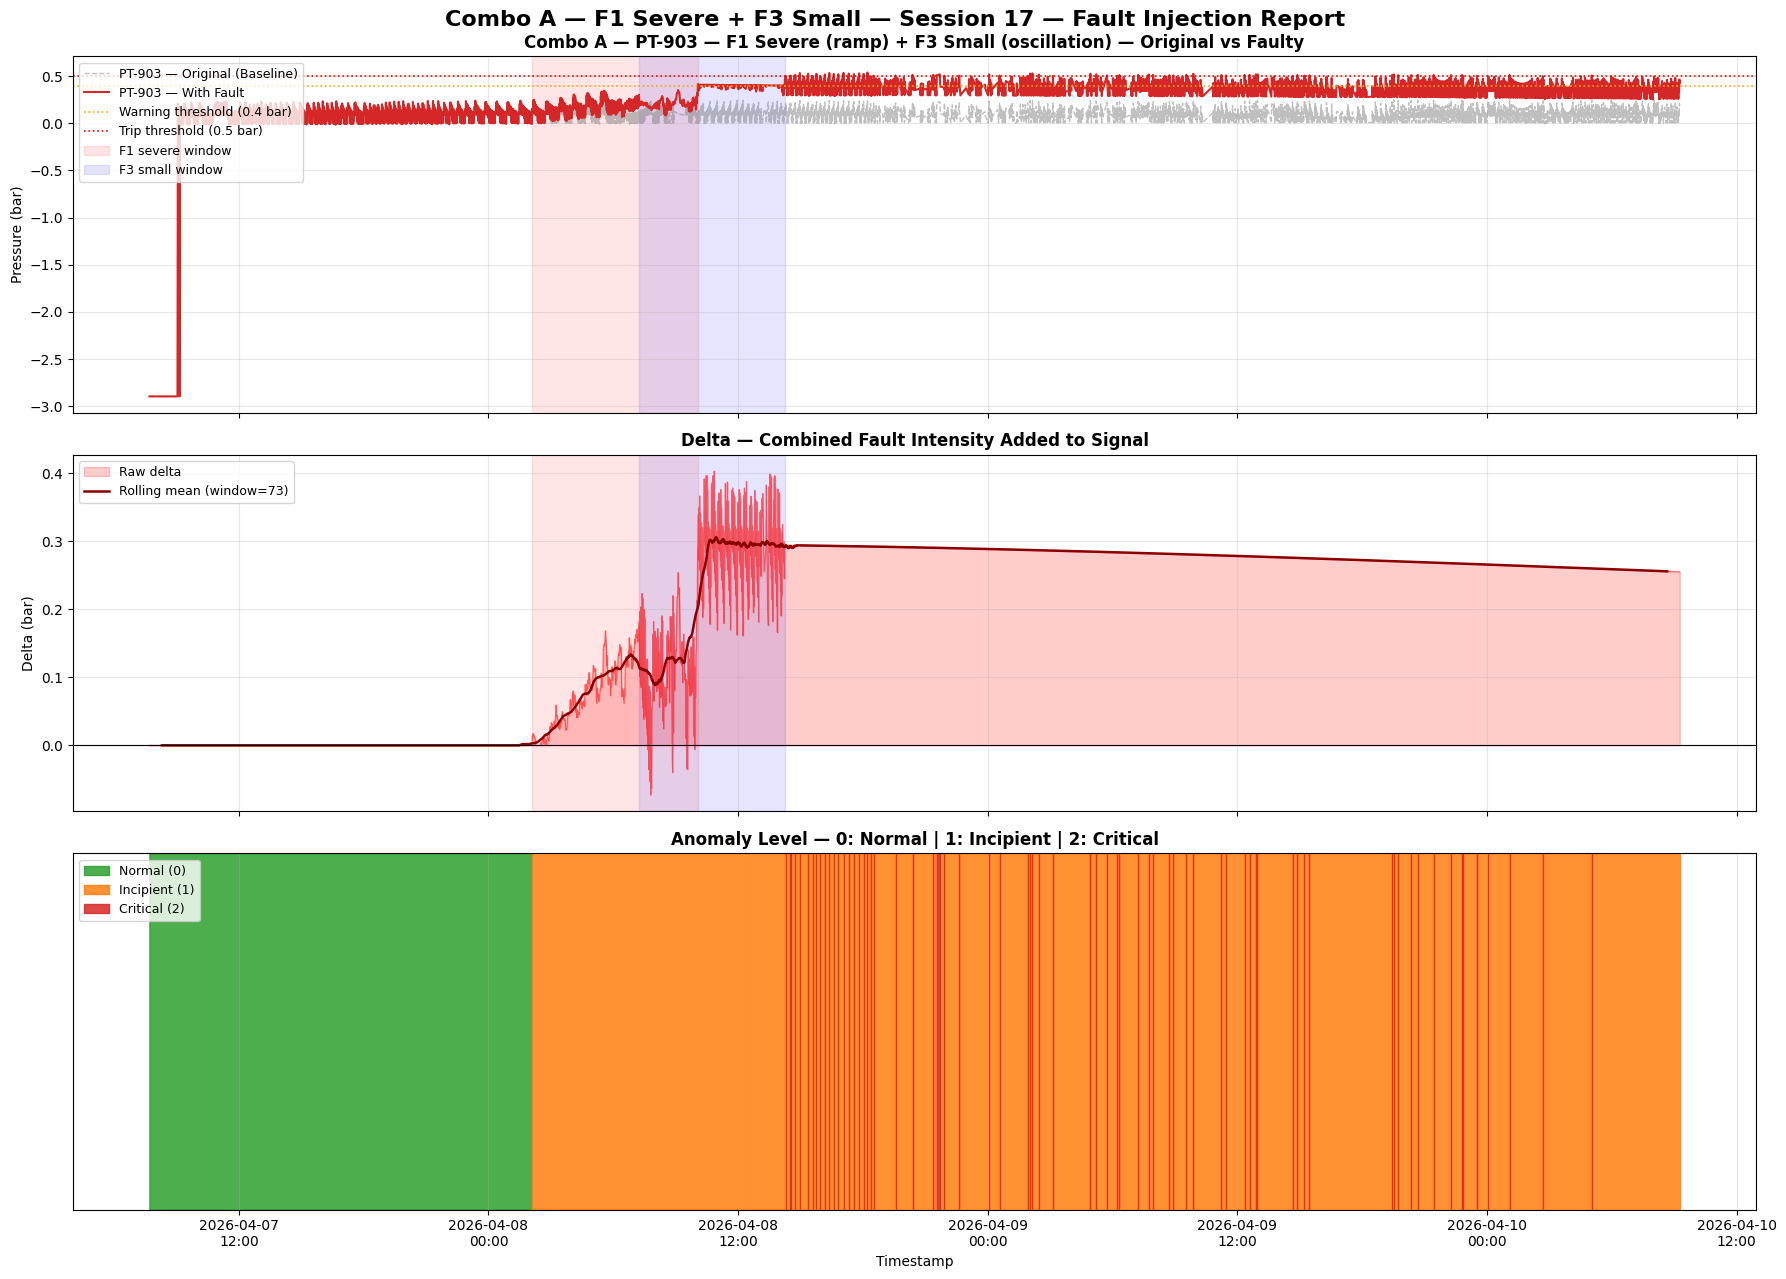

In [ ]:
""" Combined Faults — Combo A — F1 Severe + F3 Small — Verification Plot — Session 17 """

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 13), sharex=True)

# ============================================================
# PANEL 1 — Original vs Faulty PT-903
# ============================================================

combo_a_s17_f1_fault_start_timestamp = combo_a_s17_df.index[combo_a_s17_f1_start_idx]
combo_a_s17_f1_fault_end_timestamp   = combo_a_s17_df.index[combo_a_s17_f1_end_idx - 1]
combo_a_s17_f3_fault_start_timestamp = combo_a_s17_df.index[combo_a_s17_f3_start_idx]
combo_a_s17_f3_fault_end_timestamp   = combo_a_s17_df.index[combo_a_s17_f3_end_idx - 1]

ax1.plot(
    combo_a_s17_df_orig.index,
    combo_a_s17_df_orig["PT-903"],
    color="gray",
    alpha=0.5,
    linestyle="--",
    linewidth=1.0,
    label="PT-903 — Original (Baseline)"
)

ax1.plot(
    combo_a_s17_df.index,
    combo_a_s17_df["PT-903"],
    color="#d62728",
    linewidth=1.5,
    label="PT-903 — With Fault"
)

ax1.axhline(
    y=pt903_warning,
    color="orange",
    linestyle=":",
    linewidth=1.2,
    label=f"Warning threshold ({pt903_warning} bar)"
)

ax1.axhline(
    y=pt903_trip,
    color="red",
    linestyle=":",
    linewidth=1.2,
    label=f"Trip threshold ({pt903_trip} bar)"
)

ax1.axvspan(
    combo_a_s17_f1_fault_start_timestamp,
    combo_a_s17_f1_fault_end_timestamp,
    color="red",
    alpha=0.10,
    label="F1 severe window"
)

ax1.axvspan(
    combo_a_s17_f3_fault_start_timestamp,
    combo_a_s17_f3_fault_end_timestamp,
    color="blue",
    alpha=0.10,
    label="F3 small window"
)

ax1.set_title("Combo A — PT-903 — F1 Severe (ramp) + F3 Small (oscillation) — Original vs Faulty", fontweight="bold")
ax1.set_ylabel("Pressure (bar)")
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(True, alpha=0.3)

# ============================================================
# PANEL 2 — Delta (fault intensity)
# ============================================================

combo_a_s17_delta_full         = combo_a_s17_df["PT-903"] - combo_a_s17_df_orig["PT-903"]
combo_a_s17_roll_window        = max(10, len(combo_a_s17_delta_full) // 60)
combo_a_s17_delta_rolling_mean = combo_a_s17_delta_full.rolling(combo_a_s17_roll_window, center=True).mean()

ax2.fill_between(
    combo_a_s17_df.index,
    0,
    combo_a_s17_delta_full,
    color="red",
    alpha=0.2,
    label="Raw delta"
)

ax2.plot(
    combo_a_s17_df.index,
    combo_a_s17_delta_full,
    color="red",
    linewidth=0.8,
    alpha=0.5
)

ax2.plot(
    combo_a_s17_df.index,
    combo_a_s17_delta_rolling_mean,
    color="#8B0000",
    linewidth=1.8,
    label=f"Rolling mean (window={combo_a_s17_roll_window})"
)

ax2.axhline(y=0, color="black", linewidth=0.8)

ax2.axvspan(
    combo_a_s17_f1_fault_start_timestamp,
    combo_a_s17_f1_fault_end_timestamp,
    color="red",
    alpha=0.10
)

ax2.axvspan(
    combo_a_s17_f3_fault_start_timestamp,
    combo_a_s17_f3_fault_end_timestamp,
    color="blue",
    alpha=0.10
)

ax2.set_title("Delta — Combined Fault Intensity Added to Signal", fontweight="bold")
ax2.set_ylabel("Delta (bar)")
ax2.legend(loc="upper left", fontsize=9)
ax2.grid(True, alpha=0.3)

# ============================================================
# PANEL 3 — Anomaly level bar
# ============================================================

combo_a_s17_normal_mask    = combo_a_s17_df["anomaly_level"] == 0
combo_a_s17_incipient_mask = combo_a_s17_df["anomaly_level"] == 1
combo_a_s17_critical_mask  = combo_a_s17_df["anomaly_level"] == 2

ax3.fill_between(
    combo_a_s17_df.index,
    0, 1,
    where=combo_a_s17_normal_mask,
    color="#2ca02c",
    step="mid",
    alpha=0.85,
    label="Normal (0)"
)

ax3.fill_between(
    combo_a_s17_df.index,
    0, 1,
    where=combo_a_s17_incipient_mask,
    color="#ff7f0e",
    step="mid",
    alpha=0.85,
    label="Incipient (1)"
)

ax3.fill_between(
    combo_a_s17_df.index,
    0, 1,
    where=combo_a_s17_critical_mask,
    color="#d62728",
    step="mid",
    alpha=0.85,
    label="Critical (2)"
)

ax3.set_yticks([])
ax3.set_ylim(0, 1)
ax3.set_xlabel("Timestamp")
ax3.set_title("Anomaly Level — 0: Normal | 1: Incipient | 2: Critical", fontweight="bold")
ax3.legend(loc="upper left", fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))

fig.suptitle("Combo A — F1 Severe + F3 Small — Session 17 — Fault Injection Report", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

#### Session 16 - F2 Medium + F4 Severe

In [ ]:
""" Combined Faults — Combo B — F2 Medium + F4 Severe — Session 16 """

np.random.seed(42)

# ============================================================
# BASE SESSION
# ============================================================

combo_b_s16_df_orig        = dict_sessions[16].copy()
combo_b_s16_session_length = len(combo_b_s16_df_orig)

# ============================================================
# F2 MEDIUM COMPONENT — TT-901 — ramp to warning-to-trip interval
# ============================================================

combo_b_s16_f2_main_sensor   = "TT-901"
combo_b_s16_f2_start_from    = 0.20
combo_b_s16_f2_length_hours  = 5
combo_b_s16_f2_smooth_window = 10

combo_b_s16_f2_start_idx = int(round(combo_b_s16_session_length * combo_b_s16_f2_start_from))
combo_b_s16_f2_end_idx   = min(combo_b_s16_f2_start_idx + int(round(combo_b_s16_f2_length_hours * 60)), combo_b_s16_session_length)
combo_b_s16_f2_total_l   = combo_b_s16_f2_end_idx - combo_b_s16_f2_start_idx

combo_b_s16_f2_baseline_mean = combo_b_s16_df_orig["TT-901"].iloc[:combo_b_s16_f2_start_idx].mean()
combo_b_s16_f2_baseline_std  = combo_b_s16_df_orig["TT-901"].iloc[:combo_b_s16_f2_start_idx].std()

combo_b_s16_f2_target    = tt901_warning + medium_trip_fraction * (tt901_trip - tt901_warning)
combo_b_s16_f2_delta_mag = combo_b_s16_f2_target - combo_b_s16_f2_baseline_mean

combo_b_s16_f2_trend       = np.linspace(0, combo_b_s16_f2_delta_mag, combo_b_s16_f2_total_l)
combo_b_s16_f2_noise_scale = np.linspace(combo_b_s16_f2_baseline_std * 0.10, combo_b_s16_f2_baseline_std * 0.50, combo_b_s16_f2_total_l)
combo_b_s16_f2_noise       = np.random.normal(0, combo_b_s16_f2_noise_scale, combo_b_s16_f2_total_l)
combo_b_s16_f2_ramp        = combo_b_s16_f2_trend + combo_b_s16_f2_noise
combo_b_s16_f2_delta       = pd.Series(combo_b_s16_f2_ramp).rolling(combo_b_s16_f2_smooth_window, center=True, min_periods=1).mean().values

combo_b_s16_f2_active_values      = combo_b_s16_df_orig["TT-901"].iloc[combo_b_s16_f2_start_idx:combo_b_s16_f2_end_idx].to_numpy()
combo_b_s16_f2_positive_peak_idx  = int(np.argmax(combo_b_s16_f2_delta))
combo_b_s16_f2_delta              = np.maximum(combo_b_s16_f2_delta, 0)
combo_b_s16_f2_desired_peak_delta = combo_b_s16_f2_target - combo_b_s16_f2_active_values[combo_b_s16_f2_positive_peak_idx]
if combo_b_s16_f2_delta[combo_b_s16_f2_positive_peak_idx] > 0 and combo_b_s16_f2_desired_peak_delta > 0:
    combo_b_s16_f2_delta = combo_b_s16_f2_delta * (combo_b_s16_f2_desired_peak_delta / combo_b_s16_f2_delta[combo_b_s16_f2_positive_peak_idx])
combo_b_s16_f2_upper_delta = combo_b_s16_f2_target - combo_b_s16_f2_active_values
combo_b_s16_f2_delta       = np.minimum(combo_b_s16_f2_delta, combo_b_s16_f2_upper_delta)
combo_b_s16_f2_delta       = np.maximum(combo_b_s16_f2_delta, 0)

combo_b_s16_f2_corr_threshold = 0.60
combo_b_s16_f2_corr           = combo_b_s16_df_orig.corr(method="pearson", numeric_only=True)["TT-901"]
combo_b_s16_f2_corr_sensors   = combo_b_s16_f2_corr[abs(combo_b_s16_f2_corr) >= combo_b_s16_f2_corr_threshold].index.tolist()

print(f"F2 medium — window: {combo_b_s16_f2_start_idx} to {combo_b_s16_f2_end_idx} ({combo_b_s16_f2_total_l} rows)")
print(f"F2 medium — target: {combo_b_s16_f2_target:.4f} °C")
print(f"F2 medium — correlated sensors: {combo_b_s16_f2_corr_sensors}")

# ============================================================
# F4 SEVERE COMPONENT — TT-904 — Gaussian spike to trip level
# — starts 2 hours after F2 to guarantee active overlap
# ============================================================

combo_b_s16_f4_main_sensor  = "TT-904"
combo_b_s16_f4_length_hours = 3

combo_b_s16_f4_start_idx = combo_b_s16_f2_start_idx + int(2 * 60)
combo_b_s16_f4_end_idx   = min(combo_b_s16_f4_start_idx + int(round(combo_b_s16_f4_length_hours * 60)), combo_b_s16_session_length)
combo_b_s16_f4_total_l   = combo_b_s16_f4_end_idx - combo_b_s16_f4_start_idx

combo_b_s16_f4_baseline_mean = combo_b_s16_df_orig["TT-904"].iloc[:combo_b_s16_f4_start_idx].mean()
combo_b_s16_f4_baseline_std  = combo_b_s16_df_orig["TT-904"].iloc[:combo_b_s16_f4_start_idx].std()

combo_b_s16_f4_target    = tt904_trip
combo_b_s16_f4_delta_mag = combo_b_s16_f4_target - combo_b_s16_f4_baseline_mean

combo_b_s16_f4_center    = int(combo_b_s16_f4_total_l * 0.5)
combo_b_s16_f4_width     = max(int(combo_b_s16_f4_total_l * 0.08), 1)
combo_b_s16_f4_t         = np.arange(combo_b_s16_f4_total_l)
combo_b_s16_f4_noise_std = min(combo_b_s16_f4_baseline_std * 0.30, abs(combo_b_s16_f4_delta_mag) * 0.10)
combo_b_s16_f4_noise     = np.random.normal(0, combo_b_s16_f4_noise_std, combo_b_s16_f4_total_l)
combo_b_s16_f4_delta     = combo_b_s16_f4_delta_mag * np.exp(-0.5 * ((combo_b_s16_f4_t - combo_b_s16_f4_center) / combo_b_s16_f4_width) ** 2) + combo_b_s16_f4_noise

combo_b_s16_f4_active_values      = combo_b_s16_df_orig["TT-904"].iloc[combo_b_s16_f4_start_idx:combo_b_s16_f4_end_idx].to_numpy()
combo_b_s16_f4_positive_peak_idx  = int(np.argmax(combo_b_s16_f4_delta))
combo_b_s16_f4_delta              = np.maximum(combo_b_s16_f4_delta, 0)
combo_b_s16_f4_desired_peak_delta = combo_b_s16_f4_target - combo_b_s16_f4_active_values[combo_b_s16_f4_positive_peak_idx]
if combo_b_s16_f4_delta[combo_b_s16_f4_positive_peak_idx] > 0 and combo_b_s16_f4_desired_peak_delta > 0:
    combo_b_s16_f4_delta = combo_b_s16_f4_delta * (combo_b_s16_f4_desired_peak_delta / combo_b_s16_f4_delta[combo_b_s16_f4_positive_peak_idx])
combo_b_s16_f4_upper_delta = combo_b_s16_f4_target - combo_b_s16_f4_active_values
combo_b_s16_f4_delta       = np.minimum(combo_b_s16_f4_delta, combo_b_s16_f4_upper_delta)
combo_b_s16_f4_delta       = np.maximum(combo_b_s16_f4_delta, 0)

combo_b_s16_f4_corr_threshold = 0.65
combo_b_s16_f4_corr           = combo_b_s16_df_orig.corr(method="pearson", numeric_only=True)["TT-904"]
combo_b_s16_f4_corr_sensors   = combo_b_s16_f4_corr[abs(combo_b_s16_f4_corr) >= combo_b_s16_f4_corr_threshold].index.tolist()

print(f"F4 severe — window: {combo_b_s16_f4_start_idx} to {combo_b_s16_f4_end_idx} ({combo_b_s16_f4_total_l} rows)")
print(f"F4 severe — target: {combo_b_s16_f4_target:.4f} °C")
print(f"F4 severe — correlated sensors: {combo_b_s16_f4_corr_sensors}")

# ============================================================
# APPLY F2 MEDIUM INJECTION
# ============================================================

combo_b_s16_df = combo_b_s16_df_orig.copy()

combo_b_s16_f2_propagation_scale = 0.30
for sensor in combo_b_s16_f2_corr_sensors:
    if sensor in combo_b_s16_df.columns:
        scale = 1.0 if sensor == combo_b_s16_f2_main_sensor else combo_b_s16_f2_propagation_scale
        combo_b_s16_df.iloc[combo_b_s16_f2_start_idx:combo_b_s16_f2_end_idx, combo_b_s16_df.columns.get_loc(sensor)] += combo_b_s16_f2_delta * combo_b_s16_f2_corr[sensor] * scale

combo_b_s16_f2_remaining = combo_b_s16_session_length - combo_b_s16_f2_end_idx
if combo_b_s16_f2_remaining > 0:
    combo_b_s16_f2_decay_rate = 0.3
    combo_b_s16_f2_decay      = combo_b_s16_f2_delta[-1] * np.exp(-combo_b_s16_f2_decay_rate * np.linspace(0, 1, combo_b_s16_f2_remaining))
    for sensor in combo_b_s16_f2_corr_sensors:
        if sensor in combo_b_s16_df.columns:
            scale = 1.0 if sensor == combo_b_s16_f2_main_sensor else combo_b_s16_f2_propagation_scale
            combo_b_s16_df.iloc[combo_b_s16_f2_end_idx:, combo_b_s16_df.columns.get_loc(sensor)] += combo_b_s16_f2_decay * combo_b_s16_f2_corr[sensor] * scale

# ============================================================
# APPLY F4 SEVERE INJECTION
# ============================================================

combo_b_s16_f4_propagation_scale = 0.15
for sensor in combo_b_s16_f4_corr_sensors:
    if sensor in combo_b_s16_df.columns:
        scale = 1.0 if sensor == combo_b_s16_f4_main_sensor else combo_b_s16_f4_propagation_scale
        combo_b_s16_df.iloc[combo_b_s16_f4_start_idx:combo_b_s16_f4_end_idx, combo_b_s16_df.columns.get_loc(sensor)] += combo_b_s16_f4_delta * combo_b_s16_f4_corr[sensor] * scale

combo_b_s16_f4_remaining = combo_b_s16_session_length - combo_b_s16_f4_end_idx
if combo_b_s16_f4_remaining > 0:
    combo_b_s16_f4_decay_rate = 0.3
    combo_b_s16_f4_decay      = combo_b_s16_f4_delta[-1] * np.exp(-combo_b_s16_f4_decay_rate * np.linspace(0, 1, combo_b_s16_f4_remaining))
    for sensor in combo_b_s16_f4_corr_sensors:
        if sensor in combo_b_s16_df.columns:
            scale = 1.0 if sensor == combo_b_s16_f4_main_sensor else combo_b_s16_f4_propagation_scale
            combo_b_s16_df.iloc[combo_b_s16_f4_end_idx:, combo_b_s16_df.columns.get_loc(sensor)] += combo_b_s16_f4_decay * combo_b_s16_f4_corr[sensor] * scale

# ============================================================
# LABELS — active components are explicit; severity keeps the highest observed level
# ============================================================

combo_b_s16_df["anomaly_level"]       = 0
combo_b_s16_df["is_injected_anomaly"] = 0
combo_b_s16_df["anomaly_type"]        = "normal"

for component_col in ["f2_active", "f2_decay", "f4_active", "f4_decay"]:
    combo_b_s16_df[component_col] = 0

combo_b_s16_f2_active_mask = combo_b_s16_df.index[combo_b_s16_f2_start_idx:combo_b_s16_f2_end_idx]
combo_b_s16_f4_active_mask = combo_b_s16_df.index[combo_b_s16_f4_start_idx:combo_b_s16_f4_end_idx]
combo_b_s16_df.loc[combo_b_s16_f2_active_mask, "f2_active"] = 1
combo_b_s16_df.loc[combo_b_s16_f4_active_mask, "f4_active"] = 1

if combo_b_s16_f2_remaining > 0:
    combo_b_s16_f2_decay_mask = combo_b_s16_df.index[combo_b_s16_f2_end_idx:]
    combo_b_s16_df.loc[combo_b_s16_f2_decay_mask, "f2_decay"] = 1
if combo_b_s16_f4_remaining > 0:
    combo_b_s16_f4_decay_mask = combo_b_s16_df.index[combo_b_s16_f4_end_idx:]
    combo_b_s16_df.loc[combo_b_s16_f4_decay_mask, "f4_decay"] = 1

combo_b_s16_df["active_fault_count"] = combo_b_s16_df[["f2_active", "f4_active"]].sum(axis=1)
combo_b_s16_df["has_active_overlap"] = (combo_b_s16_df["active_fault_count"] >= 2).astype(int)

combo_b_s16_injected_mask = combo_b_s16_df[["f2_active", "f2_decay", "f4_active", "f4_decay"]].sum(axis=1) > 0
combo_b_s16_df.loc[combo_b_s16_injected_mask, "is_injected_anomaly"] = 1
combo_b_s16_df.loc[combo_b_s16_injected_mask, "anomaly_level"] = 1

# F2 medium severity — dynamic based on TT-901 values during active and stabilization periods
combo_b_s16_f2_label_index = combo_b_s16_df.index[combo_b_s16_f2_start_idx:]
combo_b_s16_f2_injected_values = combo_b_s16_df.loc[combo_b_s16_f2_label_index, "TT-901"]
combo_b_s16_f2_labels = np.where(
    combo_b_s16_f2_injected_values >= tt901_trip,    2,
    np.where(combo_b_s16_f2_injected_values >= tt901_warning, 1, 0)
)
combo_b_s16_df.loc[combo_b_s16_f2_label_index, "anomaly_level"] = np.maximum(
    combo_b_s16_df.loc[combo_b_s16_f2_label_index, "anomaly_level"],
    combo_b_s16_f2_labels
)

# F4 severe severity — dynamic based on TT-904 values during active and stabilization periods
combo_b_s16_f4_label_index = combo_b_s16_df.index[combo_b_s16_f4_start_idx:]
combo_b_s16_f4_injected_values = combo_b_s16_df.loc[combo_b_s16_f4_label_index, "TT-904"]
combo_b_s16_f4_labels = np.where(
    combo_b_s16_f4_injected_values >= tt904_trip,    2,
    np.where(combo_b_s16_f4_injected_values >= tt904_warning, 1, 0)
)
combo_b_s16_df.loc[combo_b_s16_f4_label_index, "anomaly_level"] = np.maximum(
    combo_b_s16_df.loc[combo_b_s16_f4_label_index, "anomaly_level"],
    combo_b_s16_f4_labels
)

combo_b_s16_df["anomaly_type"] = "normal"
combo_b_s16_df.loc[combo_b_s16_df["f2_active"] == 1, "anomaly_type"] = "cooling_fault"
combo_b_s16_df.loc[combo_b_s16_df["f4_active"] == 1, "anomaly_type"] = np.where(
    combo_b_s16_df.loc[combo_b_s16_df["f4_active"] == 1, "anomaly_type"] == "normal",
    "bearing_fault",
    combo_b_s16_df.loc[combo_b_s16_df["f4_active"] == 1, "anomaly_type"] + "+bearing_fault"
)

combo_b_s16_decay_only_mask = (combo_b_s16_df["anomaly_type"] == "normal") & ((combo_b_s16_df["f2_decay"] == 1) | (combo_b_s16_df["f4_decay"] == 1))
combo_b_s16_df.loc[combo_b_s16_decay_only_mask & (combo_b_s16_df["f2_decay"] == 1), "anomaly_type"] = "cooling_fault_decay"
combo_b_s16_df.loc[combo_b_s16_decay_only_mask & (combo_b_s16_df["f4_decay"] == 1), "anomaly_type"] = np.where(
    combo_b_s16_df.loc[combo_b_s16_decay_only_mask & (combo_b_s16_df["f4_decay"] == 1), "anomaly_type"] == "normal",
    "bearing_fault_decay",
    combo_b_s16_df.loc[combo_b_s16_decay_only_mask & (combo_b_s16_df["f4_decay"] == 1), "anomaly_type"] + "+bearing_fault_decay"
)

print(f"Active overlap rows: {combo_b_s16_df['has_active_overlap'].sum()}")

# SAVE
# ============================================================

combo_b_s16_df.to_csv(f"{output_dir_combined}/session_16_combo_B_F2medium_F4severe.csv")

print(f"\nSession 16 Combo B saved")
print(f"Normal rows:         {(combo_b_s16_df['is_injected_anomaly'] == 0).sum()}")
print(f"Anomaly rows:        {combo_b_s16_df['is_injected_anomaly'].sum()}")
print(f"Level 1 rows:        {(combo_b_s16_df['anomaly_level'] == 1).sum()}")
print(f"Level 2 rows:        {(combo_b_s16_df['anomaly_level'] == 2).sum()}")
print(f"Anomaly types found: {combo_b_s16_df['anomaly_type'].unique()}")

F2 medium — window: 673 to 973 (300 rows)
F2 medium — target: 137.7500 °C
F2 medium — correlated sensors: ['TT-901', 'TT-902', 'TT-903', 'TT-904']
F4 severe — window: 793 to 973 (180 rows)
F4 severe — target: 110.0000 °C
F4 severe — correlated sensors: ['TT-901', 'TT-902', 'TT-903', 'TT-904']
Active overlap rows: 180

Session 16 Combo B saved
Normal rows:         673
Anomaly rows:        2694
Level 1 rows:        2667
Level 2 rows:        27
Anomaly types found: ['normal' 'cooling_fault' 'cooling_fault+bearing_fault'
 'cooling_fault_decay+bearing_fault_decay']


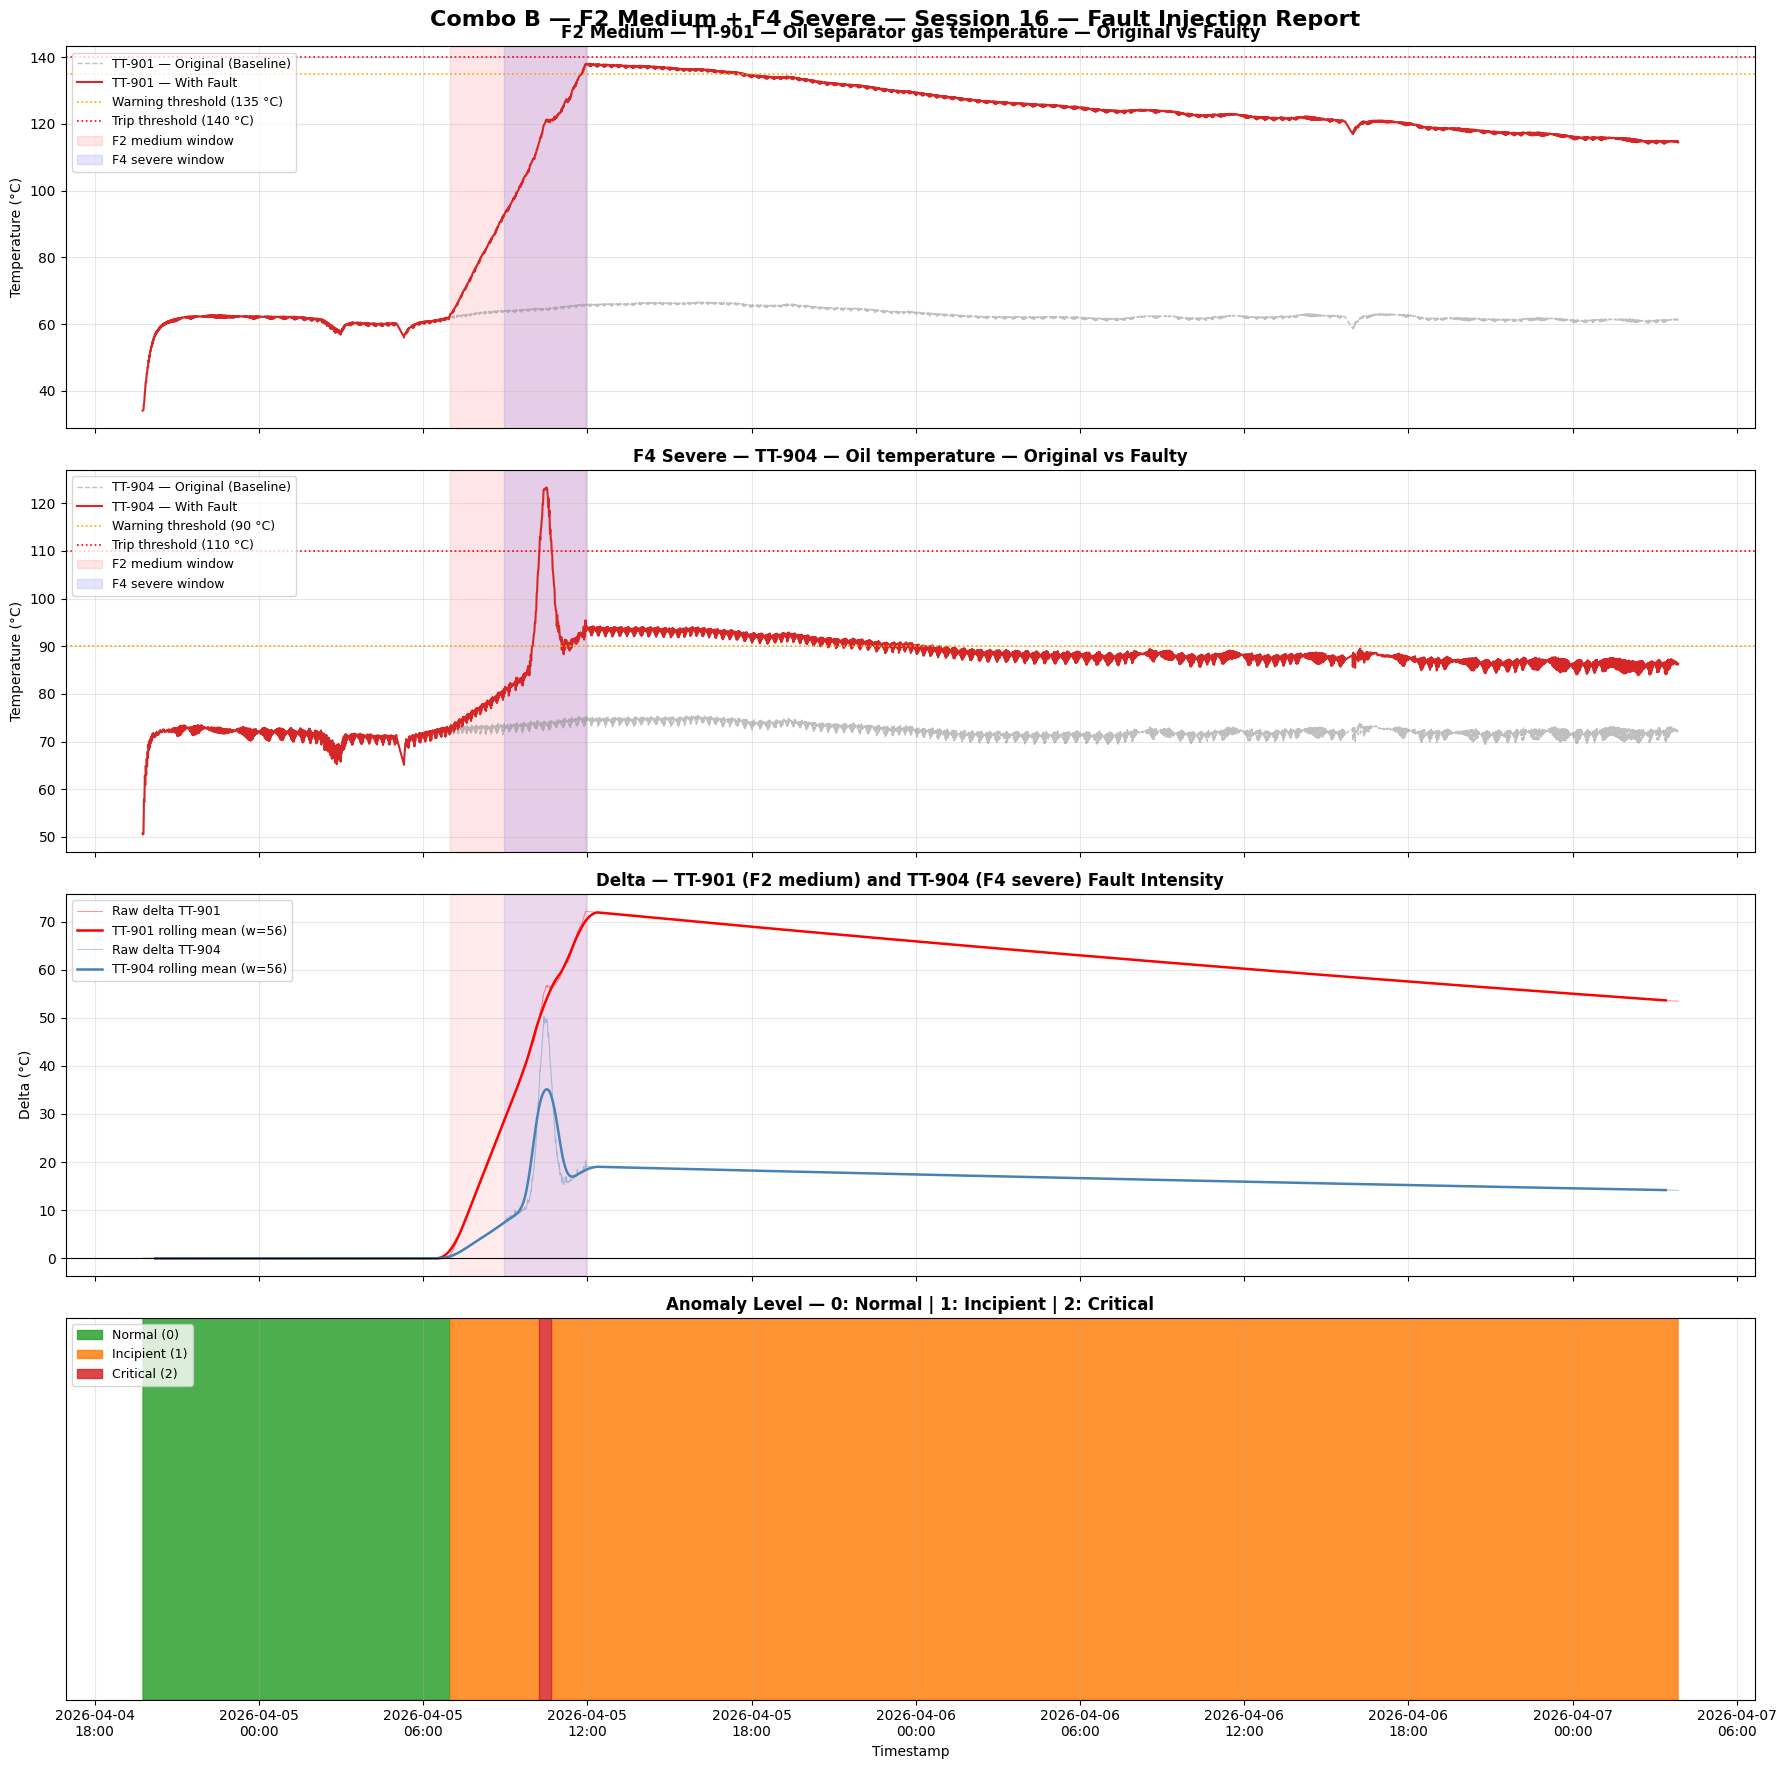

In [ ]:
""" Combined Faults — Combo B — F2 Medium + F4 Severe — Verification Plot — Session 16 """

fig, axes = plt.subplots(4, 1, figsize=(18, 18), sharex=True)

ax1, ax2, ax3, ax4 = axes

# ============================================================
# TIMESTAMPS
# ============================================================

combo_b_s16_f2_fault_start_timestamp = combo_b_s16_df.index[combo_b_s16_f2_start_idx]
combo_b_s16_f2_fault_end_timestamp   = combo_b_s16_df.index[combo_b_s16_f2_end_idx - 1]
combo_b_s16_f4_fault_start_timestamp = combo_b_s16_df.index[combo_b_s16_f4_start_idx]
combo_b_s16_f4_fault_end_timestamp   = combo_b_s16_df.index[combo_b_s16_f4_end_idx - 1]

# ============================================================
# PANEL 1 — Original vs Faulty TT-901 (F2 medium)
# ============================================================

ax1.plot(
    combo_b_s16_df_orig.index,
    combo_b_s16_df_orig["TT-901"],
    color="gray",
    alpha=0.5,
    linestyle="--",
    linewidth=1.0,
    label="TT-901 — Original (Baseline)"
)

ax1.plot(
    combo_b_s16_df.index,
    combo_b_s16_df["TT-901"],
    color="#d62728",
    linewidth=1.5,
    label="TT-901 — With Fault"
)

ax1.axhline(
    y=tt901_warning,
    color="orange",
    linestyle=":",
    linewidth=1.2,
    label=f"Warning threshold ({tt901_warning} °C)"
)

ax1.axhline(
    y=tt901_trip,
    color="red",
    linestyle=":",
    linewidth=1.2,
    label=f"Trip threshold ({tt901_trip} °C)"
)

ax1.axvspan(
    combo_b_s16_f2_fault_start_timestamp,
    combo_b_s16_f2_fault_end_timestamp,
    color="red",
    alpha=0.10,
    label="F2 medium window"
)

ax1.axvspan(
    combo_b_s16_f4_fault_start_timestamp,
    combo_b_s16_f4_fault_end_timestamp,
    color="blue",
    alpha=0.10,
    label="F4 severe window"
)

ax1.set_title("F2 Medium — TT-901 — Oil separator gas temperature — Original vs Faulty", fontweight="bold")
ax1.set_ylabel("Temperature (°C)")
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(True, alpha=0.3)

# ============================================================
# PANEL 2 — Original vs Faulty TT-904 (F4 severe)
# ============================================================

ax2.plot(
    combo_b_s16_df_orig.index,
    combo_b_s16_df_orig["TT-904"],
    color="gray",
    alpha=0.5,
    linestyle="--",
    linewidth=1.0,
    label="TT-904 — Original (Baseline)"
)

ax2.plot(
    combo_b_s16_df.index,
    combo_b_s16_df["TT-904"],
    color="#d62728",
    linewidth=1.5,
    label="TT-904 — With Fault"
)

ax2.axhline(
    y=tt904_warning,
    color="orange",
    linestyle=":",
    linewidth=1.2,
    label=f"Warning threshold ({tt904_warning} °C)"
)

ax2.axhline(
    y=tt904_trip,
    color="red",
    linestyle=":",
    linewidth=1.2,
    label=f"Trip threshold ({tt904_trip} °C)"
)

ax2.axvspan(
    combo_b_s16_f2_fault_start_timestamp,
    combo_b_s16_f2_fault_end_timestamp,
    color="red",
    alpha=0.10,
    label="F2 medium window"
)

ax2.axvspan(
    combo_b_s16_f4_fault_start_timestamp,
    combo_b_s16_f4_fault_end_timestamp,
    color="blue",
    alpha=0.10,
    label="F4 severe window"
)

ax2.set_title("F4 Severe — TT-904 — Oil temperature — Original vs Faulty", fontweight="bold")
ax2.set_ylabel("Temperature (°C)")
ax2.legend(loc="upper left", fontsize=9)
ax2.grid(True, alpha=0.3)

# ============================================================
# PANEL 3 — Delta both sensors
# ============================================================

combo_b_s16_delta_tt901         = combo_b_s16_df["TT-901"] - combo_b_s16_df_orig["TT-901"]
combo_b_s16_delta_tt904         = combo_b_s16_df["TT-904"] - combo_b_s16_df_orig["TT-904"]
combo_b_s16_roll_window         = max(10, len(combo_b_s16_delta_tt901) // 60)
combo_b_s16_delta_tt901_rolling = combo_b_s16_delta_tt901.rolling(combo_b_s16_roll_window, center=True).mean()
combo_b_s16_delta_tt904_rolling = combo_b_s16_delta_tt904.rolling(combo_b_s16_roll_window, center=True).mean()

ax3.plot(
    combo_b_s16_df.index,
    combo_b_s16_delta_tt901,
    color="red",
    linewidth=0.8,
    alpha=0.4,
    label="Raw delta TT-901"
)

ax3.plot(
    combo_b_s16_df.index,
    combo_b_s16_delta_tt901_rolling,
    color="red",
    linewidth=1.8,
    label=f"TT-901 rolling mean (w={combo_b_s16_roll_window})"
)

ax3.plot(
    combo_b_s16_df.index,
    combo_b_s16_delta_tt904,
    color="steelblue",
    linewidth=0.8,
    alpha=0.4,
    label="Raw delta TT-904"
)

ax3.plot(
    combo_b_s16_df.index,
    combo_b_s16_delta_tt904_rolling,
    color="steelblue",
    linewidth=1.8,
    label=f"TT-904 rolling mean (w={combo_b_s16_roll_window})"
)

ax3.axhline(y=0, color="black", linewidth=0.8)

ax3.axvspan(
    combo_b_s16_f2_fault_start_timestamp,
    combo_b_s16_f2_fault_end_timestamp,
    color="red",
    alpha=0.08
)

ax3.axvspan(
    combo_b_s16_f4_fault_start_timestamp,
    combo_b_s16_f4_fault_end_timestamp,
    color="blue",
    alpha=0.08
)

ax3.set_title("Delta — TT-901 (F2 medium) and TT-904 (F4 severe) Fault Intensity", fontweight="bold")
ax3.set_ylabel("Delta (°C)")
ax3.legend(loc="upper left", fontsize=9)
ax3.grid(True, alpha=0.3)

# ============================================================
# PANEL 4 — Anomaly level bar
# ============================================================

combo_b_s16_normal_mask    = combo_b_s16_df["anomaly_level"] == 0
combo_b_s16_incipient_mask = combo_b_s16_df["anomaly_level"] == 1
combo_b_s16_critical_mask  = combo_b_s16_df["anomaly_level"] == 2

ax4.fill_between(
    combo_b_s16_df.index,
    0, 1,
    where=combo_b_s16_normal_mask,
    color="#2ca02c",
    step="mid",
    alpha=0.85,
    label="Normal (0)"
)

ax4.fill_between(
    combo_b_s16_df.index,
    0, 1,
    where=combo_b_s16_incipient_mask,
    color="#ff7f0e",
    step="mid",
    alpha=0.85,
    label="Incipient (1)"
)

ax4.fill_between(
    combo_b_s16_df.index,
    0, 1,
    where=combo_b_s16_critical_mask,
    color="#d62728",
    step="mid",
    alpha=0.85,
    label="Critical (2)"
)

ax4.set_yticks([])
ax4.set_ylim(0, 1)
ax4.set_xlabel("Timestamp")
ax4.set_title("Anomaly Level — 0: Normal | 1: Incipient | 2: Critical", fontweight="bold")
ax4.legend(loc="upper left", fontsize=9)
ax4.grid(True, alpha=0.3)
ax4.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))

fig.suptitle("Combo B — F2 Medium + F4 Severe — Session 16 — Fault Injection Report", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

#### Session 17 - F2 Medium + F4 Severe

In [ ]:
""" Combined Faults — Combo B — F2 Medium + F4 Severe — Session 17 — with guaranteed overlap """

np.random.seed(42)

# ============================================================
# BASE SESSION
# ============================================================

combo_b_s17_df_orig        = dict_sessions[17].copy()
combo_b_s17_session_length = len(combo_b_s17_df_orig)

# ============================================================
# F2 MEDIUM COMPONENT — TT-901 — ramp to warning-to-trip interval
# ============================================================

combo_b_s17_f2_main_sensor   = "TT-901"
combo_b_s17_f2_start_from    = 0.30
combo_b_s17_f2_length_hours  = 5
combo_b_s17_f2_smooth_window = 10

combo_b_s17_f2_start_idx = int(round(combo_b_s17_session_length * combo_b_s17_f2_start_from))
combo_b_s17_f2_end_idx   = min(combo_b_s17_f2_start_idx + int(round(combo_b_s17_f2_length_hours * 60)), combo_b_s17_session_length)
combo_b_s17_f2_total_l   = combo_b_s17_f2_end_idx - combo_b_s17_f2_start_idx

combo_b_s17_f2_baseline_mean = combo_b_s17_df_orig["TT-901"].iloc[:combo_b_s17_f2_start_idx].mean()
combo_b_s17_f2_baseline_std  = combo_b_s17_df_orig["TT-901"].iloc[:combo_b_s17_f2_start_idx].std()

combo_b_s17_f2_target    = tt901_warning + medium_trip_fraction * (tt901_trip - tt901_warning)
combo_b_s17_f2_delta_mag = combo_b_s17_f2_target - combo_b_s17_f2_baseline_mean

combo_b_s17_f2_trend       = np.linspace(0, combo_b_s17_f2_delta_mag, combo_b_s17_f2_total_l)
combo_b_s17_f2_noise_scale = np.linspace(combo_b_s17_f2_baseline_std * 0.10, combo_b_s17_f2_baseline_std * 0.50, combo_b_s17_f2_total_l)
combo_b_s17_f2_noise       = np.random.normal(0, combo_b_s17_f2_noise_scale, combo_b_s17_f2_total_l)
combo_b_s17_f2_ramp        = combo_b_s17_f2_trend + combo_b_s17_f2_noise
combo_b_s17_f2_delta       = pd.Series(combo_b_s17_f2_ramp).rolling(combo_b_s17_f2_smooth_window, center=True, min_periods=1).mean().values

combo_b_s17_f2_active_values      = combo_b_s17_df_orig["TT-901"].iloc[combo_b_s17_f2_start_idx:combo_b_s17_f2_end_idx].to_numpy()
combo_b_s17_f2_positive_peak_idx  = int(np.argmax(combo_b_s17_f2_delta))
combo_b_s17_f2_delta              = np.maximum(combo_b_s17_f2_delta, 0)
combo_b_s17_f2_desired_peak_delta = combo_b_s17_f2_target - combo_b_s17_f2_active_values[combo_b_s17_f2_positive_peak_idx]
if combo_b_s17_f2_delta[combo_b_s17_f2_positive_peak_idx] > 0 and combo_b_s17_f2_desired_peak_delta > 0:
    combo_b_s17_f2_delta = combo_b_s17_f2_delta * (combo_b_s17_f2_desired_peak_delta / combo_b_s17_f2_delta[combo_b_s17_f2_positive_peak_idx])
combo_b_s17_f2_upper_delta = combo_b_s17_f2_target - combo_b_s17_f2_active_values
combo_b_s17_f2_delta       = np.minimum(combo_b_s17_f2_delta, combo_b_s17_f2_upper_delta)
combo_b_s17_f2_delta       = np.maximum(combo_b_s17_f2_delta, 0)

combo_b_s17_f2_corr_threshold = 0.60
combo_b_s17_f2_corr           = combo_b_s17_df_orig.corr(method="pearson", numeric_only=True)["TT-901"]
combo_b_s17_f2_corr_sensors   = combo_b_s17_f2_corr[abs(combo_b_s17_f2_corr) >= combo_b_s17_f2_corr_threshold].index.tolist()

print(f"F2 medium — window: {combo_b_s17_f2_start_idx} to {combo_b_s17_f2_end_idx} ({combo_b_s17_f2_total_l} rows)")
print(f"F2 medium — target: {combo_b_s17_f2_target:.4f} °C")
print(f"F2 medium — correlated sensors: {combo_b_s17_f2_corr_sensors}")

# ============================================================
# F4 SEVERE COMPONENT — TT-904 — Gaussian spike to trip level
# — starts 2 hours after F2 to guarantee overlap
# ============================================================

combo_b_s17_f4_main_sensor  = "TT-904"
combo_b_s17_f4_length_hours = 3

combo_b_s17_f4_start_idx = combo_b_s17_f2_start_idx + int(2 * 60)
combo_b_s17_f4_end_idx   = min(combo_b_s17_f4_start_idx + int(round(combo_b_s17_f4_length_hours * 60)), combo_b_s17_session_length)
combo_b_s17_f4_total_l   = combo_b_s17_f4_end_idx - combo_b_s17_f4_start_idx

combo_b_s17_f4_baseline_mean = combo_b_s17_df_orig["TT-904"].iloc[:combo_b_s17_f4_start_idx].mean()
combo_b_s17_f4_baseline_std  = combo_b_s17_df_orig["TT-904"].iloc[:combo_b_s17_f4_start_idx].std()

combo_b_s17_f4_target    = tt904_trip
combo_b_s17_f4_delta_mag = combo_b_s17_f4_target - combo_b_s17_f4_baseline_mean

combo_b_s17_f4_center    = int(combo_b_s17_f4_total_l * 0.5)
combo_b_s17_f4_width     = max(int(combo_b_s17_f4_total_l * 0.08), 1)
combo_b_s17_f4_t         = np.arange(combo_b_s17_f4_total_l)
combo_b_s17_f4_noise_std = min(combo_b_s17_f4_baseline_std * 0.30, abs(combo_b_s17_f4_delta_mag) * 0.10)
combo_b_s17_f4_noise     = np.random.normal(0, combo_b_s17_f4_noise_std, combo_b_s17_f4_total_l)
combo_b_s17_f4_delta     = combo_b_s17_f4_delta_mag * np.exp(-0.5 * ((combo_b_s17_f4_t - combo_b_s17_f4_center) / combo_b_s17_f4_width) ** 2) + combo_b_s17_f4_noise

combo_b_s17_f4_active_values      = combo_b_s17_df_orig["TT-904"].iloc[combo_b_s17_f4_start_idx:combo_b_s17_f4_end_idx].to_numpy()
combo_b_s17_f4_positive_peak_idx  = int(np.argmax(combo_b_s17_f4_delta))
combo_b_s17_f4_delta              = np.maximum(combo_b_s17_f4_delta, 0)
combo_b_s17_f4_desired_peak_delta = combo_b_s17_f4_target - combo_b_s17_f4_active_values[combo_b_s17_f4_positive_peak_idx]
if combo_b_s17_f4_delta[combo_b_s17_f4_positive_peak_idx] > 0 and combo_b_s17_f4_desired_peak_delta > 0:
    combo_b_s17_f4_delta = combo_b_s17_f4_delta * (combo_b_s17_f4_desired_peak_delta / combo_b_s17_f4_delta[combo_b_s17_f4_positive_peak_idx])
combo_b_s17_f4_upper_delta = combo_b_s17_f4_target - combo_b_s17_f4_active_values
combo_b_s17_f4_delta       = np.minimum(combo_b_s17_f4_delta, combo_b_s17_f4_upper_delta)
combo_b_s17_f4_delta       = np.maximum(combo_b_s17_f4_delta, 0)

combo_b_s17_f4_corr_threshold = 0.65
combo_b_s17_f4_corr           = combo_b_s17_df_orig.corr(method="pearson", numeric_only=True)["TT-904"]
combo_b_s17_f4_corr_sensors   = combo_b_s17_f4_corr[abs(combo_b_s17_f4_corr) >= combo_b_s17_f4_corr_threshold].index.tolist()

print(f"F4 severe — window: {combo_b_s17_f4_start_idx} to {combo_b_s17_f4_end_idx} ({combo_b_s17_f4_total_l} rows)")
print(f"F4 severe — target: {combo_b_s17_f4_target:.4f} °C")
print(f"F4 severe — correlated sensors: {combo_b_s17_f4_corr_sensors}")
print(f"Overlap window: {combo_b_s17_f4_start_idx} to {combo_b_s17_f2_end_idx} ({combo_b_s17_f2_end_idx - combo_b_s17_f4_start_idx} rows)")

# ============================================================
# APPLY F2 MEDIUM INJECTION
# ============================================================

combo_b_s17_df = combo_b_s17_df_orig.copy()

combo_b_s17_f2_propagation_scale = 0.30
for sensor in combo_b_s17_f2_corr_sensors:
    if sensor in combo_b_s17_df.columns:
        scale = 1.0 if sensor == combo_b_s17_f2_main_sensor else combo_b_s17_f2_propagation_scale
        combo_b_s17_df.iloc[combo_b_s17_f2_start_idx:combo_b_s17_f2_end_idx, combo_b_s17_df.columns.get_loc(sensor)] += combo_b_s17_f2_delta * combo_b_s17_f2_corr[sensor] * scale

combo_b_s17_f2_remaining = combo_b_s17_session_length - combo_b_s17_f2_end_idx
if combo_b_s17_f2_remaining > 0:
    combo_b_s17_f2_decay_rate = 0.3
    combo_b_s17_f2_decay      = combo_b_s17_f2_delta[-1] * np.exp(-combo_b_s17_f2_decay_rate * np.linspace(0, 1, combo_b_s17_f2_remaining))
    for sensor in combo_b_s17_f2_corr_sensors:
        if sensor in combo_b_s17_df.columns:
            scale = 1.0 if sensor == combo_b_s17_f2_main_sensor else combo_b_s17_f2_propagation_scale
            combo_b_s17_df.iloc[combo_b_s17_f2_end_idx:, combo_b_s17_df.columns.get_loc(sensor)] += combo_b_s17_f2_decay * combo_b_s17_f2_corr[sensor] * scale

# ============================================================
# APPLY F4 SEVERE INJECTION
# ============================================================

combo_b_s17_f4_propagation_scale = 0.15
for sensor in combo_b_s17_f4_corr_sensors:
    if sensor in combo_b_s17_df.columns:
        scale = 1.0 if sensor == combo_b_s17_f4_main_sensor else combo_b_s17_f4_propagation_scale
        combo_b_s17_df.iloc[combo_b_s17_f4_start_idx:combo_b_s17_f4_end_idx, combo_b_s17_df.columns.get_loc(sensor)] += combo_b_s17_f4_delta * combo_b_s17_f4_corr[sensor] * scale

combo_b_s17_f4_remaining = combo_b_s17_session_length - combo_b_s17_f4_end_idx
if combo_b_s17_f4_remaining > 0:
    combo_b_s17_f4_decay_rate = 0.3
    combo_b_s17_f4_decay      = combo_b_s17_f4_delta[-1] * np.exp(-combo_b_s17_f4_decay_rate * np.linspace(0, 1, combo_b_s17_f4_remaining))
    for sensor in combo_b_s17_f4_corr_sensors:
        if sensor in combo_b_s17_df.columns:
            scale = 1.0 if sensor == combo_b_s17_f4_main_sensor else combo_b_s17_f4_propagation_scale
            combo_b_s17_df.iloc[combo_b_s17_f4_end_idx:, combo_b_s17_df.columns.get_loc(sensor)] += combo_b_s17_f4_decay * combo_b_s17_f4_corr[sensor] * scale

# ============================================================
# LABELS — active components are explicit; severity keeps the highest observed level
# ============================================================

combo_b_s17_df["anomaly_level"]       = 0
combo_b_s17_df["is_injected_anomaly"] = 0
combo_b_s17_df["anomaly_type"]        = "normal"

for component_col in ["f2_active", "f2_decay", "f4_active", "f4_decay"]:
    combo_b_s17_df[component_col] = 0

combo_b_s17_f2_active_mask = combo_b_s17_df.index[combo_b_s17_f2_start_idx:combo_b_s17_f2_end_idx]
combo_b_s17_f4_active_mask = combo_b_s17_df.index[combo_b_s17_f4_start_idx:combo_b_s17_f4_end_idx]
combo_b_s17_df.loc[combo_b_s17_f2_active_mask, "f2_active"] = 1
combo_b_s17_df.loc[combo_b_s17_f4_active_mask, "f4_active"] = 1

if combo_b_s17_f2_remaining > 0:
    combo_b_s17_f2_decay_mask = combo_b_s17_df.index[combo_b_s17_f2_end_idx:]
    combo_b_s17_df.loc[combo_b_s17_f2_decay_mask, "f2_decay"] = 1
if combo_b_s17_f4_remaining > 0:
    combo_b_s17_f4_decay_mask = combo_b_s17_df.index[combo_b_s17_f4_end_idx:]
    combo_b_s17_df.loc[combo_b_s17_f4_decay_mask, "f4_decay"] = 1

combo_b_s17_df["active_fault_count"] = combo_b_s17_df[["f2_active", "f4_active"]].sum(axis=1)
combo_b_s17_df["has_active_overlap"] = (combo_b_s17_df["active_fault_count"] >= 2).astype(int)

combo_b_s17_injected_mask = combo_b_s17_df[["f2_active", "f2_decay", "f4_active", "f4_decay"]].sum(axis=1) > 0
combo_b_s17_df.loc[combo_b_s17_injected_mask, "is_injected_anomaly"] = 1
combo_b_s17_df.loc[combo_b_s17_injected_mask, "anomaly_level"] = 1

# F2 medium severity — dynamic based on TT-901 values during active and stabilization periods
combo_b_s17_f2_label_index = combo_b_s17_df.index[combo_b_s17_f2_start_idx:]
combo_b_s17_f2_injected_values = combo_b_s17_df.loc[combo_b_s17_f2_label_index, "TT-901"]
combo_b_s17_f2_labels = np.where(
    combo_b_s17_f2_injected_values >= tt901_trip,    2,
    np.where(combo_b_s17_f2_injected_values >= tt901_warning, 1, 0)
)
combo_b_s17_df.loc[combo_b_s17_f2_label_index, "anomaly_level"] = np.maximum(
    combo_b_s17_df.loc[combo_b_s17_f2_label_index, "anomaly_level"],
    combo_b_s17_f2_labels
)

# F4 severe severity — dynamic based on TT-904 values during active and stabilization periods
combo_b_s17_f4_label_index = combo_b_s17_df.index[combo_b_s17_f4_start_idx:]
combo_b_s17_f4_injected_values = combo_b_s17_df.loc[combo_b_s17_f4_label_index, "TT-904"]
combo_b_s17_f4_labels = np.where(
    combo_b_s17_f4_injected_values >= tt904_trip,    2,
    np.where(combo_b_s17_f4_injected_values >= tt904_warning, 1, 0)
)
combo_b_s17_df.loc[combo_b_s17_f4_label_index, "anomaly_level"] = np.maximum(
    combo_b_s17_df.loc[combo_b_s17_f4_label_index, "anomaly_level"],
    combo_b_s17_f4_labels
)

combo_b_s17_df["anomaly_type"] = "normal"
combo_b_s17_df.loc[combo_b_s17_df["f2_active"] == 1, "anomaly_type"] = "cooling_fault"
combo_b_s17_df.loc[combo_b_s17_df["f4_active"] == 1, "anomaly_type"] = np.where(
    combo_b_s17_df.loc[combo_b_s17_df["f4_active"] == 1, "anomaly_type"] == "normal",
    "bearing_fault",
    combo_b_s17_df.loc[combo_b_s17_df["f4_active"] == 1, "anomaly_type"] + "+bearing_fault"
)

combo_b_s17_decay_only_mask = (combo_b_s17_df["anomaly_type"] == "normal") & ((combo_b_s17_df["f2_decay"] == 1) | (combo_b_s17_df["f4_decay"] == 1))
combo_b_s17_df.loc[combo_b_s17_decay_only_mask & (combo_b_s17_df["f2_decay"] == 1), "anomaly_type"] = "cooling_fault_decay"
combo_b_s17_df.loc[combo_b_s17_decay_only_mask & (combo_b_s17_df["f4_decay"] == 1), "anomaly_type"] = np.where(
    combo_b_s17_df.loc[combo_b_s17_decay_only_mask & (combo_b_s17_df["f4_decay"] == 1), "anomaly_type"] == "normal",
    "bearing_fault_decay",
    combo_b_s17_df.loc[combo_b_s17_decay_only_mask & (combo_b_s17_df["f4_decay"] == 1), "anomaly_type"] + "+bearing_fault_decay"
)

print(f"Active overlap rows: {combo_b_s17_df['has_active_overlap'].sum()}")

# SAVE
# ============================================================

combo_b_s17_df.to_csv(f"{output_dir_combined}/session_17_combo_B_F2medium_F4severe.csv")

print(f"\nSession 17 Combo B saved")
print(f"Normal rows:         {(combo_b_s17_df['is_injected_anomaly'] == 0).sum()}")
print(f"Anomaly rows:        {combo_b_s17_df['is_injected_anomaly'].sum()}")
print(f"Level 1 rows:        {(combo_b_s17_df['anomaly_level'] == 1).sum()}")
print(f"Level 2 rows:        {(combo_b_s17_df['anomaly_level'] == 2).sum()}")
print(f"Anomaly types found: {combo_b_s17_df['anomaly_type'].unique()}")

F2 medium — window: 1324 to 1624 (300 rows)
F2 medium — target: 137.7500 °C
F2 medium — correlated sensors: ['TT-901', 'TT-902', 'TT-903', 'TT-904']
F4 severe — window: 1444 to 1624 (180 rows)
F4 severe — target: 110.0000 °C
F4 severe — correlated sensors: ['TT-901', 'TT-902', 'TT-903', 'TT-904']
Overlap window: 1444 to 1624 (180 rows)
Active overlap rows: 180

Session 17 Combo B saved
Normal rows:         1324
Anomaly rows:        3091
Level 1 rows:        3065
Level 2 rows:        26
Anomaly types found: ['normal' 'cooling_fault' 'cooling_fault+bearing_fault'
 'cooling_fault_decay+bearing_fault_decay']


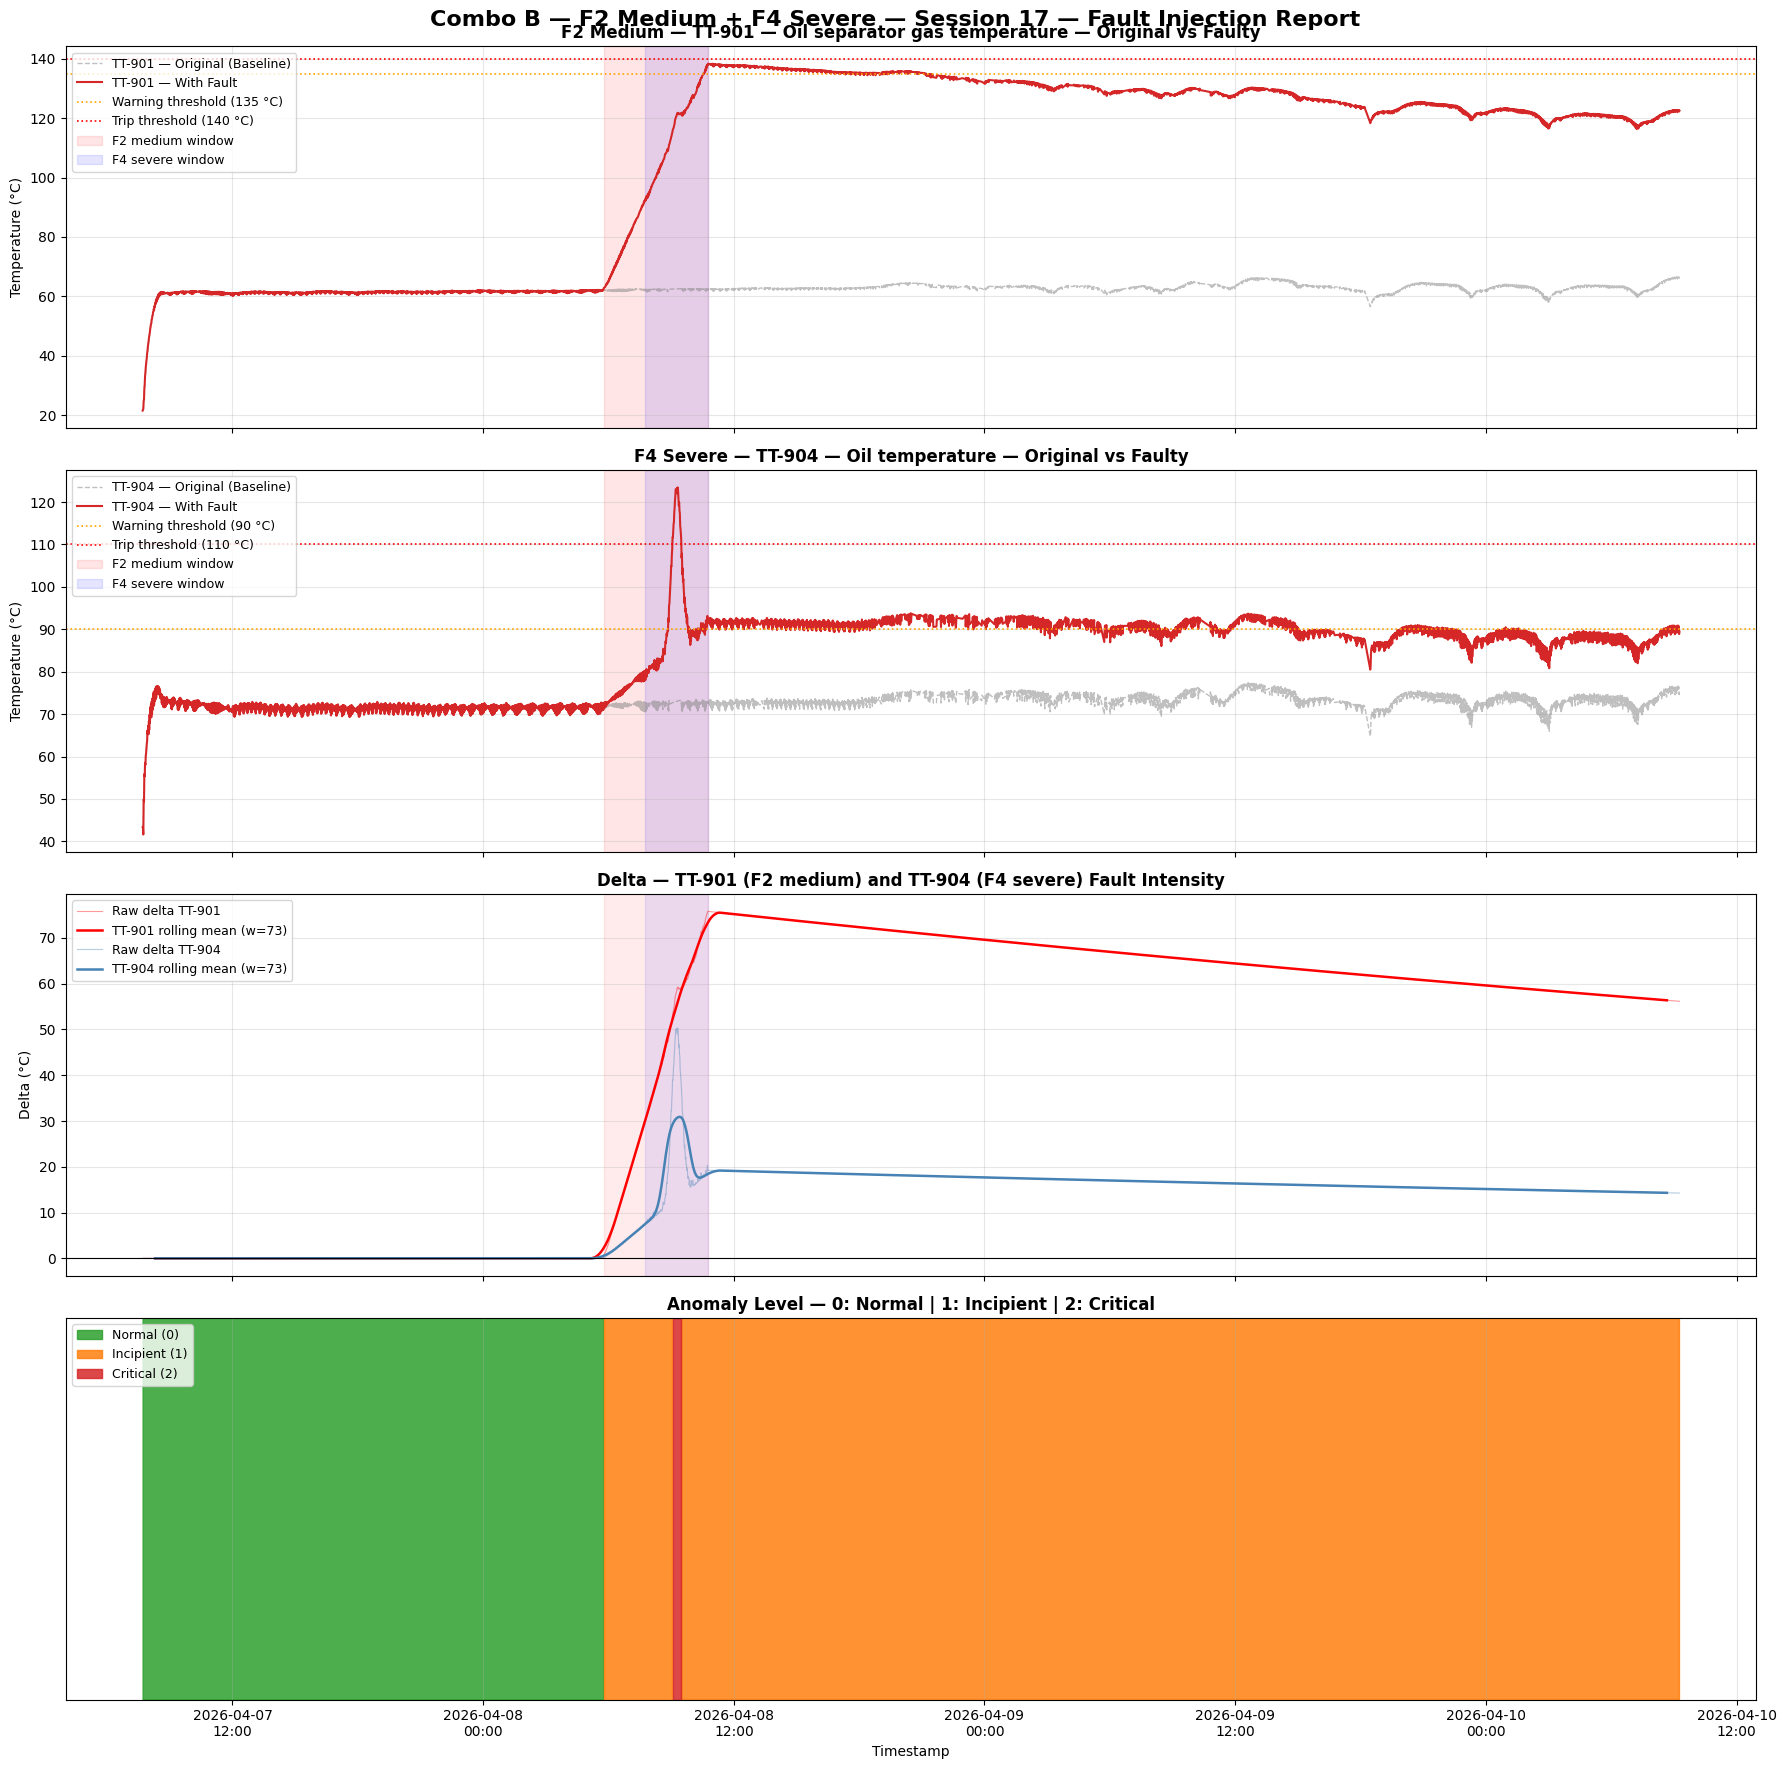

In [ ]:
""" Combined Faults — Combo B — F2 Medium + F4 Severe — Verification Plot — Session 17 """

fig, axes = plt.subplots(4, 1, figsize=(18, 18), sharex=True)

ax1, ax2, ax3, ax4 = axes

# ============================================================
# TIMESTAMPS
# ============================================================

combo_b_s17_f2_fault_start_timestamp = combo_b_s17_df.index[combo_b_s17_f2_start_idx]
combo_b_s17_f2_fault_end_timestamp   = combo_b_s17_df.index[combo_b_s17_f2_end_idx - 1]
combo_b_s17_f4_fault_start_timestamp = combo_b_s17_df.index[combo_b_s17_f4_start_idx]
combo_b_s17_f4_fault_end_timestamp   = combo_b_s17_df.index[combo_b_s17_f4_end_idx - 1]

# ============================================================
# PANEL 1 — Original vs Faulty TT-901 (F2 medium)
# ============================================================

ax1.plot(
    combo_b_s17_df_orig.index,
    combo_b_s17_df_orig["TT-901"],
    color="gray",
    alpha=0.5,
    linestyle="--",
    linewidth=1.0,
    label="TT-901 — Original (Baseline)"
)

ax1.plot(
    combo_b_s17_df.index,
    combo_b_s17_df["TT-901"],
    color="#d62728",
    linewidth=1.5,
    label="TT-901 — With Fault"
)

ax1.axhline(
    y=tt901_warning,
    color="orange",
    linestyle=":",
    linewidth=1.2,
    label=f"Warning threshold ({tt901_warning} °C)"
)

ax1.axhline(
    y=tt901_trip,
    color="red",
    linestyle=":",
    linewidth=1.2,
    label=f"Trip threshold ({tt901_trip} °C)"
)

ax1.axvspan(
    combo_b_s17_f2_fault_start_timestamp,
    combo_b_s17_f2_fault_end_timestamp,
    color="red",
    alpha=0.10,
    label="F2 medium window"
)

ax1.axvspan(
    combo_b_s17_f4_fault_start_timestamp,
    combo_b_s17_f4_fault_end_timestamp,
    color="blue",
    alpha=0.10,
    label="F4 severe window"
)

ax1.set_title("F2 Medium — TT-901 — Oil separator gas temperature — Original vs Faulty", fontweight="bold")
ax1.set_ylabel("Temperature (°C)")
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(True, alpha=0.3)

# ============================================================
# PANEL 2 — Original vs Faulty TT-904 (F4 severe)
# ============================================================

ax2.plot(
    combo_b_s17_df_orig.index,
    combo_b_s17_df_orig["TT-904"],
    color="gray",
    alpha=0.5,
    linestyle="--",
    linewidth=1.0,
    label="TT-904 — Original (Baseline)"
)

ax2.plot(
    combo_b_s17_df.index,
    combo_b_s17_df["TT-904"],
    color="#d62728",
    linewidth=1.5,
    label="TT-904 — With Fault"
)

ax2.axhline(
    y=tt904_warning,
    color="orange",
    linestyle=":",
    linewidth=1.2,
    label=f"Warning threshold ({tt904_warning} °C)"
)

ax2.axhline(
    y=tt904_trip,
    color="red",
    linestyle=":",
    linewidth=1.2,
    label=f"Trip threshold ({tt904_trip} °C)"
)

ax2.axvspan(
    combo_b_s17_f2_fault_start_timestamp,
    combo_b_s17_f2_fault_end_timestamp,
    color="red",
    alpha=0.10,
    label="F2 medium window"
)

ax2.axvspan(
    combo_b_s17_f4_fault_start_timestamp,
    combo_b_s17_f4_fault_end_timestamp,
    color="blue",
    alpha=0.10,
    label="F4 severe window"
)

ax2.set_title("F4 Severe — TT-904 — Oil temperature — Original vs Faulty", fontweight="bold")
ax2.set_ylabel("Temperature (°C)")
ax2.legend(loc="upper left", fontsize=9)
ax2.grid(True, alpha=0.3)

# ============================================================
# PANEL 3 — Delta both sensors
# ============================================================

combo_b_s17_delta_tt901         = combo_b_s17_df["TT-901"] - combo_b_s17_df_orig["TT-901"]
combo_b_s17_delta_tt904         = combo_b_s17_df["TT-904"] - combo_b_s17_df_orig["TT-904"]
combo_b_s17_roll_window         = max(10, len(combo_b_s17_delta_tt901) // 60)
combo_b_s17_delta_tt901_rolling = combo_b_s17_delta_tt901.rolling(combo_b_s17_roll_window, center=True).mean()
combo_b_s17_delta_tt904_rolling = combo_b_s17_delta_tt904.rolling(combo_b_s17_roll_window, center=True).mean()

ax3.plot(
    combo_b_s17_df.index,
    combo_b_s17_delta_tt901,
    color="red",
    linewidth=0.8,
    alpha=0.4,
    label="Raw delta TT-901"
)

ax3.plot(
    combo_b_s17_df.index,
    combo_b_s17_delta_tt901_rolling,
    color="red",
    linewidth=1.8,
    label=f"TT-901 rolling mean (w={combo_b_s17_roll_window})"
)

ax3.plot(
    combo_b_s17_df.index,
    combo_b_s17_delta_tt904,
    color="steelblue",
    linewidth=0.8,
    alpha=0.4,
    label="Raw delta TT-904"
)

ax3.plot(
    combo_b_s17_df.index,
    combo_b_s17_delta_tt904_rolling,
    color="steelblue",
    linewidth=1.8,
    label=f"TT-904 rolling mean (w={combo_b_s17_roll_window})"
)

ax3.axhline(y=0, color="black", linewidth=0.8)

ax3.axvspan(
    combo_b_s17_f2_fault_start_timestamp,
    combo_b_s17_f2_fault_end_timestamp,
    color="red",
    alpha=0.08
)

ax3.axvspan(
    combo_b_s17_f4_fault_start_timestamp,
    combo_b_s17_f4_fault_end_timestamp,
    color="blue",
    alpha=0.08
)

ax3.set_title("Delta — TT-901 (F2 medium) and TT-904 (F4 severe) Fault Intensity", fontweight="bold")
ax3.set_ylabel("Delta (°C)")
ax3.legend(loc="upper left", fontsize=9)
ax3.grid(True, alpha=0.3)

# ============================================================
# PANEL 4 — Anomaly level bar
# ============================================================

combo_b_s17_normal_mask    = combo_b_s17_df["anomaly_level"] == 0
combo_b_s17_incipient_mask = combo_b_s17_df["anomaly_level"] == 1
combo_b_s17_critical_mask  = combo_b_s17_df["anomaly_level"] == 2

ax4.fill_between(
    combo_b_s17_df.index,
    0, 1,
    where=combo_b_s17_normal_mask,
    color="#2ca02c",
    step="mid",
    alpha=0.85,
    label="Normal (0)"
)

ax4.fill_between(
    combo_b_s17_df.index,
    0, 1,
    where=combo_b_s17_incipient_mask,
    color="#ff7f0e",
    step="mid",
    alpha=0.85,
    label="Incipient (1)"
)

ax4.fill_between(
    combo_b_s17_df.index,
    0, 1,
    where=combo_b_s17_critical_mask,
    color="#d62728",
    step="mid",
    alpha=0.85,
    label="Critical (2)"
)

ax4.set_yticks([])
ax4.set_ylim(0, 1)
ax4.set_xlabel("Timestamp")
ax4.set_title("Anomaly Level — 0: Normal | 1: Incipient | 2: Critical", fontweight="bold")
ax4.legend(loc="upper left", fontsize=9)
ax4.grid(True, alpha=0.3)
ax4.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))

fig.suptitle("Combo B — F2 Medium + F4 Severe — Session 17 — Fault Injection Report", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

## False Positives

### Standalone

#### Session 16 - TT-902

In [ ]:
""" False Positive — Standalone — TT-902 spike — Session 16 """

np.random.seed(42)

# ============================================================
# BASE SESSION
# ============================================================

fp_standalone_s16_df_orig        = dict_sessions[16].copy()
fp_standalone_s16_session_length = len(fp_standalone_s16_df_orig)

# ============================================================
# FALSE POSITIVE PARAMETERS — TT-902 isolated spike
# ============================================================

fp_standalone_s16_main_sensor  = "TT-902"
fp_standalone_s16_start_from   = 0.40
fp_standalone_s16_duration_min = 12

fp_standalone_s16_start_idx = int(round(fp_standalone_s16_session_length * fp_standalone_s16_start_from))
fp_standalone_s16_end_idx   = min(fp_standalone_s16_start_idx + fp_standalone_s16_duration_min, fp_standalone_s16_session_length)
fp_standalone_s16_total_l   = fp_standalone_s16_end_idx - fp_standalone_s16_start_idx

print(f"FP standalone s16 — window: {fp_standalone_s16_start_idx} to {fp_standalone_s16_end_idx} ({fp_standalone_s16_total_l} rows)")

# ============================================================
# BASELINE — computed on pre-spike window
# ============================================================

fp_standalone_s16_baseline_mean = fp_standalone_s16_df_orig["TT-902"].iloc[:fp_standalone_s16_start_idx].mean()
fp_standalone_s16_baseline_std  = fp_standalone_s16_df_orig["TT-902"].iloc[:fp_standalone_s16_start_idx].std()

print(f"TT-902 baseline mean: {fp_standalone_s16_baseline_mean:.4f} °C")
print(f"TT-902 baseline std:  {fp_standalone_s16_baseline_std:.4f} °C")

# ============================================================
# SPIKE AMPLITUDE — stays below trip level
# ============================================================

fp_standalone_s16_spike_target = tt902_trip * 0.80
fp_standalone_s16_delta_mag    = fp_standalone_s16_spike_target - fp_standalone_s16_baseline_mean

print(f"TT-902 spike target:  {fp_standalone_s16_spike_target:.4f} °C")
print(f"TT-902 delta mag:     {fp_standalone_s16_delta_mag:.4f} °C")

# ============================================================
# DELTA SHAPE — sharp Gaussian spike, returns immediately
# ============================================================

fp_standalone_s16_t       = np.arange(fp_standalone_s16_total_l)
fp_standalone_s16_center  = int(fp_standalone_s16_total_l * 0.5)
fp_standalone_s16_width   = max(int(fp_standalone_s16_total_l * 0.15), 1)
fp_standalone_s16_noise   = np.random.normal(0, fp_standalone_s16_baseline_std * 0.05, fp_standalone_s16_total_l)
fp_standalone_s16_delta   = fp_standalone_s16_delta_mag * np.exp(-0.5 * ((fp_standalone_s16_t - fp_standalone_s16_center) / fp_standalone_s16_width) ** 2) + fp_standalone_s16_noise
fp_standalone_s16_delta   = np.maximum(fp_standalone_s16_delta, 0)

# ============================================================
# INJECT SPIKE — single sensor only, NO correlation propagation
# ============================================================

fp_standalone_s16_df = fp_standalone_s16_df_orig.copy()

fp_standalone_s16_sensor_col_idx = fp_standalone_s16_df.columns.get_loc("TT-902")
fp_standalone_s16_df.iloc[fp_standalone_s16_start_idx:fp_standalone_s16_end_idx, fp_standalone_s16_sensor_col_idx] += fp_standalone_s16_delta

# ============================================================
# LABELS — false positive: injected but NOT a real anomaly
# ============================================================

fp_standalone_s16_df["anomaly_level"]       = 0
fp_standalone_s16_df["is_injected_anomaly"] = 0
fp_standalone_s16_df["anomaly_type"]        = "normal"

fp_standalone_s16_df.iloc[fp_standalone_s16_start_idx:fp_standalone_s16_end_idx, fp_standalone_s16_df.columns.get_loc("anomaly_type")] = "false_positive"

# ============================================================
# SAVE
# ============================================================

fp_standalone_s16_df.to_csv(f"{output_dir_fp}/session_16_fp_standalone_TT902.csv")

print(f"\nSession 16 standalone FP saved")
print(f"False positive rows: {(fp_standalone_s16_df['anomaly_type'] == 'false_positive').sum()}")
print(f"Normal rows:         {(fp_standalone_s16_df['anomaly_type'] == 'normal').sum()}")

FP standalone s16 — window: 1347 to 1359 (12 rows)
TT-902 baseline mean: 64.0660 °C
TT-902 baseline std:  3.4463 °C
TT-902 spike target:  88.0000 °C
TT-902 delta mag:     23.9340 °C

Session 16 standalone FP saved
False positive rows: 12
Normal rows:         3355


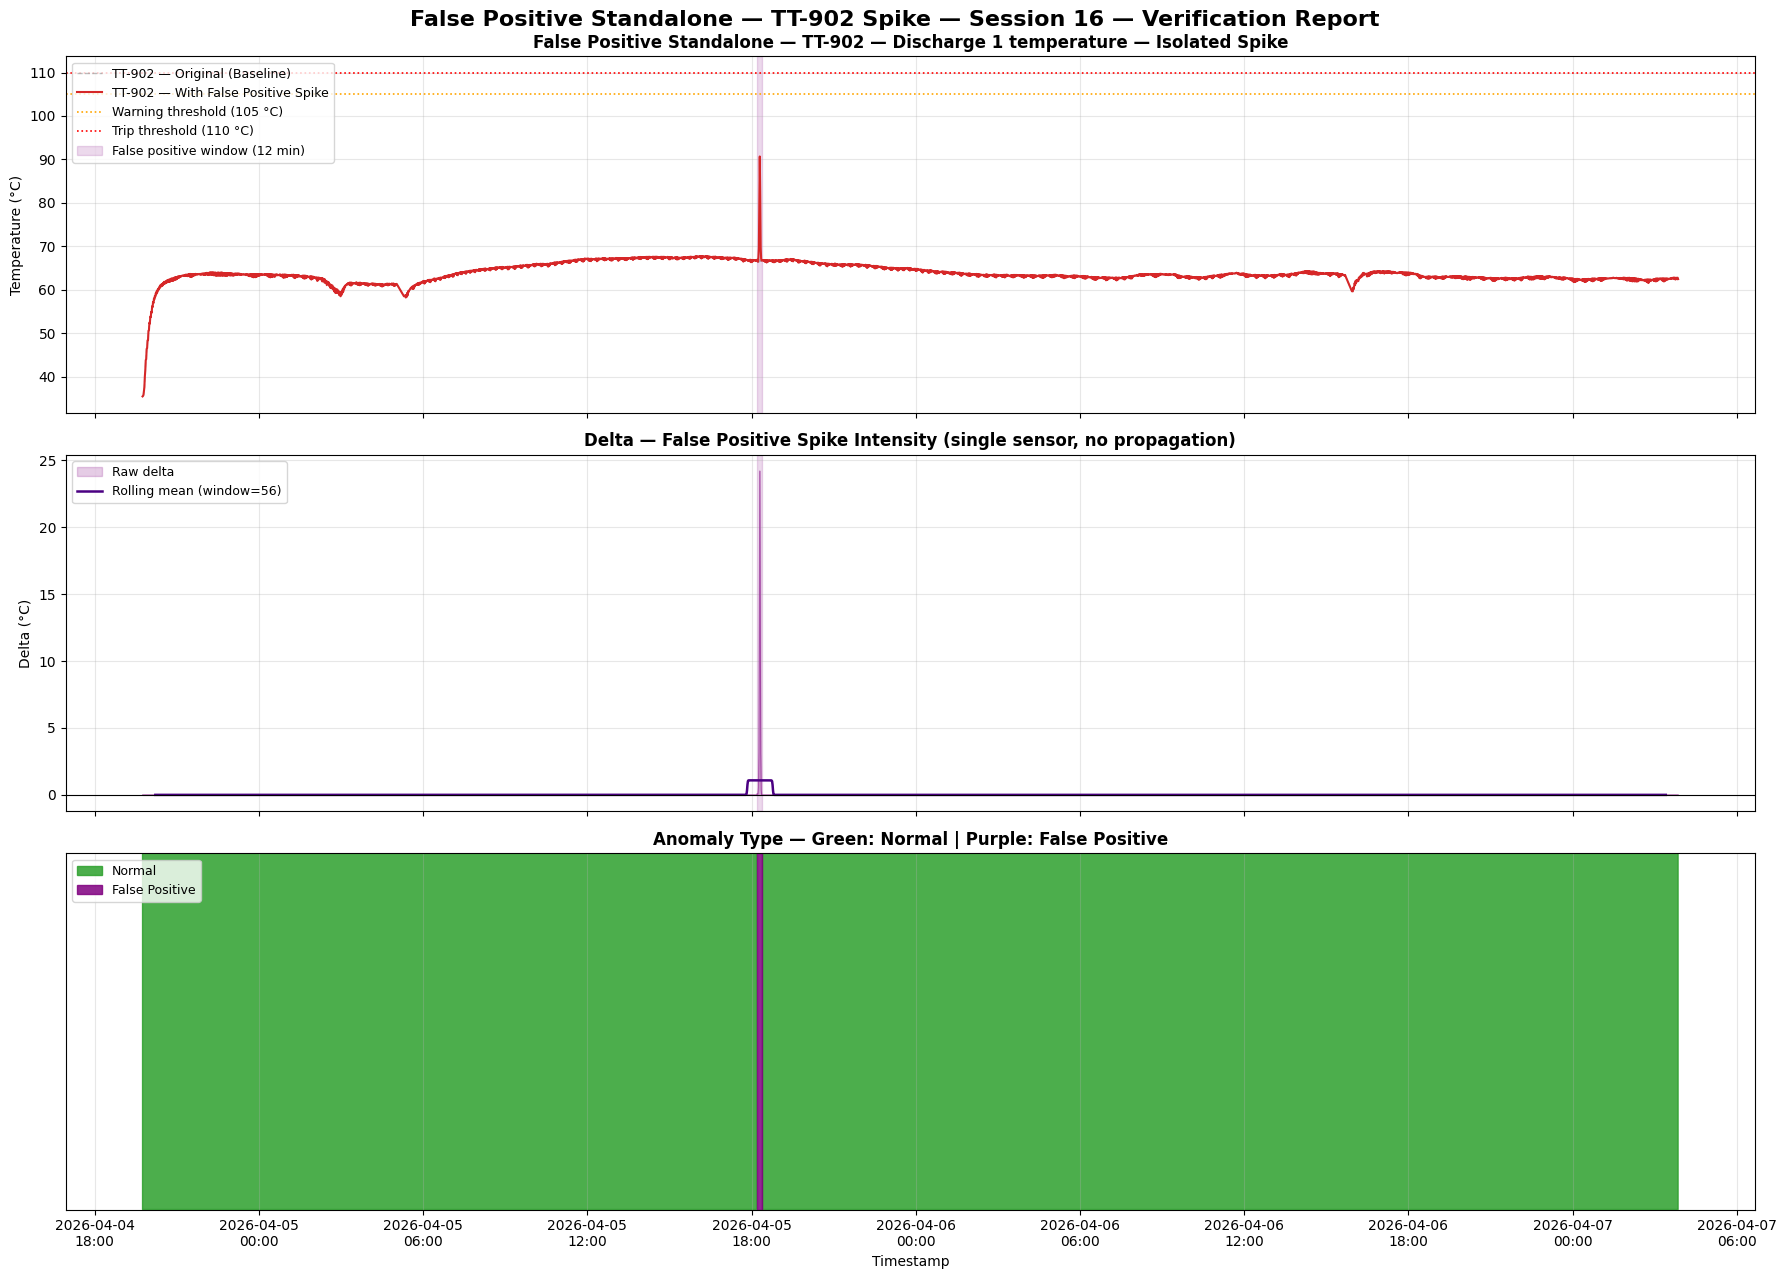

In [ ]:
""" False Positive — Standalone — TT-902 spike — Verification Plot — Session 16 """

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 13), sharex=True)

# ============================================================
# TIMESTAMPS
# ============================================================

fp_standalone_s16_fault_start_timestamp = fp_standalone_s16_df.index[fp_standalone_s16_start_idx]
fp_standalone_s16_fault_end_timestamp   = fp_standalone_s16_df.index[fp_standalone_s16_end_idx - 1]

# ============================================================
# PANEL 1 — Original vs Faulty TT-902
# ============================================================

ax1.plot(
    fp_standalone_s16_df_orig.index,
    fp_standalone_s16_df_orig["TT-902"],
    color="gray",
    alpha=0.5,
    linestyle="--",
    linewidth=1.0,
    label="TT-902 — Original (Baseline)"
)

ax1.plot(
    fp_standalone_s16_df.index,
    fp_standalone_s16_df["TT-902"],
    color="#d62728",
    linewidth=1.5,
    label="TT-902 — With False Positive Spike"
)

ax1.axhline(
    y=tt902_warning,
    color="orange",
    linestyle=":",
    linewidth=1.2,
    label=f"Warning threshold ({tt902_warning} °C)"
)

ax1.axhline(
    y=tt902_trip,
    color="red",
    linestyle=":",
    linewidth=1.2,
    label=f"Trip threshold ({tt902_trip} °C)"
)

ax1.axvspan(
    fp_standalone_s16_fault_start_timestamp,
    fp_standalone_s16_fault_end_timestamp,
    color="purple",
    alpha=0.15,
    label=f"False positive window ({fp_standalone_s16_duration_min} min)"
)

ax1.set_title("False Positive Standalone — TT-902 — Discharge 1 temperature — Isolated Spike", fontweight="bold")
ax1.set_ylabel("Temperature (°C)")
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(True, alpha=0.3)

# ============================================================
# PANEL 2 — Delta (spike intensity)
# ============================================================

fp_standalone_s16_delta_full         = fp_standalone_s16_df["TT-902"] - fp_standalone_s16_df_orig["TT-902"]
fp_standalone_s16_roll_window        = max(5, len(fp_standalone_s16_delta_full) // 60)
fp_standalone_s16_delta_rolling_mean = fp_standalone_s16_delta_full.rolling(fp_standalone_s16_roll_window, center=True).mean()

ax2.fill_between(
    fp_standalone_s16_df.index,
    0,
    fp_standalone_s16_delta_full,
    color="purple",
    alpha=0.2,
    label="Raw delta"
)

ax2.plot(
    fp_standalone_s16_df.index,
    fp_standalone_s16_delta_full,
    color="purple",
    linewidth=0.8,
    alpha=0.5
)

ax2.plot(
    fp_standalone_s16_df.index,
    fp_standalone_s16_delta_rolling_mean,
    color="#4B0082",
    linewidth=1.8,
    label=f"Rolling mean (window={fp_standalone_s16_roll_window})"
)

ax2.axhline(y=0, color="black", linewidth=0.8)

ax2.axvspan(
    fp_standalone_s16_fault_start_timestamp,
    fp_standalone_s16_fault_end_timestamp,
    color="purple",
    alpha=0.15
)

ax2.set_title("Delta — False Positive Spike Intensity (single sensor, no propagation)", fontweight="bold")
ax2.set_ylabel("Delta (°C)")
ax2.legend(loc="upper left", fontsize=9)
ax2.grid(True, alpha=0.3)

# ============================================================
# PANEL 3 — Anomaly type bar
# ============================================================

fp_standalone_s16_normal_mask = fp_standalone_s16_df["anomaly_type"] == "normal"
fp_standalone_s16_fp_mask     = fp_standalone_s16_df["anomaly_type"] == "false_positive"

ax3.fill_between(
    fp_standalone_s16_df.index,
    0, 1,
    where=fp_standalone_s16_normal_mask,
    color="#2ca02c",
    step="mid",
    alpha=0.85,
    label="Normal"
)

ax3.fill_between(
    fp_standalone_s16_df.index,
    0, 1,
    where=fp_standalone_s16_fp_mask,
    color="purple",
    step="mid",
    alpha=0.85,
    label="False Positive"
)

ax3.set_yticks([])
ax3.set_ylim(0, 1)
ax3.set_xlabel("Timestamp")
ax3.set_title("Anomaly Type — Green: Normal | Purple: False Positive", fontweight="bold")
ax3.legend(loc="upper left", fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))

fig.suptitle("False Positive Standalone — TT-902 Spike — Session 16 — Verification Report", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

#### Session 17 - TT-903

In [ ]:
""" False Positive — Standalone — TT-903 spike — Session 17 """

np.random.seed(42)

# ============================================================
# BASE SESSION
# ============================================================

fp_standalone_s17_df_orig        = dict_sessions[17].copy()
fp_standalone_s17_session_length = len(fp_standalone_s17_df_orig)

# ============================================================
# FALSE POSITIVE PARAMETERS — TT-903 isolated spike
# ============================================================

fp_standalone_s17_main_sensor  = "TT-903"
fp_standalone_s17_start_from   = 0.55
fp_standalone_s17_duration_min = 10

fp_standalone_s17_start_idx = int(round(fp_standalone_s17_session_length * fp_standalone_s17_start_from))
fp_standalone_s17_end_idx   = min(fp_standalone_s17_start_idx + fp_standalone_s17_duration_min, fp_standalone_s17_session_length)
fp_standalone_s17_total_l   = fp_standalone_s17_end_idx - fp_standalone_s17_start_idx

print(f"FP standalone s17 — window: {fp_standalone_s17_start_idx} to {fp_standalone_s17_end_idx} ({fp_standalone_s17_total_l} rows)")

# ============================================================
# BASELINE — computed on pre-spike window
# ============================================================

fp_standalone_s17_baseline_mean = fp_standalone_s17_df_orig["TT-903"].iloc[:fp_standalone_s17_start_idx].mean()
fp_standalone_s17_baseline_std  = fp_standalone_s17_df_orig["TT-903"].iloc[:fp_standalone_s17_start_idx].std()

print(f"TT-903 baseline mean: {fp_standalone_s17_baseline_mean:.4f} °C")
print(f"TT-903 baseline std:  {fp_standalone_s17_baseline_std:.4f} °C")

# ============================================================
# SPIKE AMPLITUDE — stays below trip level
# ============================================================

fp_standalone_s17_spike_target = tt903_trip * 0.80
fp_standalone_s17_delta_mag    = fp_standalone_s17_spike_target - fp_standalone_s17_baseline_mean

print(f"TT-903 spike target:  {fp_standalone_s17_spike_target:.4f} °C")
print(f"TT-903 delta mag:     {fp_standalone_s17_delta_mag:.4f} °C")

# ============================================================
# DELTA SHAPE — sharp Gaussian spike, returns immediately
# ============================================================

fp_standalone_s17_t      = np.arange(fp_standalone_s17_total_l)
fp_standalone_s17_center = int(fp_standalone_s17_total_l * 0.5)
fp_standalone_s17_width  = max(int(fp_standalone_s17_total_l * 0.15), 1)
fp_standalone_s17_noise  = np.random.normal(0, fp_standalone_s17_baseline_std * 0.05, fp_standalone_s17_total_l)
fp_standalone_s17_delta  = fp_standalone_s17_delta_mag * np.exp(-0.5 * ((fp_standalone_s17_t - fp_standalone_s17_center) / fp_standalone_s17_width) ** 2) + fp_standalone_s17_noise
fp_standalone_s17_delta  = np.maximum(fp_standalone_s17_delta, 0)

# ============================================================
# INJECT SPIKE — single sensor only, NO correlation propagation
# ============================================================

fp_standalone_s17_df = fp_standalone_s17_df_orig.copy()

fp_standalone_s17_sensor_col_idx = fp_standalone_s17_df.columns.get_loc("TT-903")
fp_standalone_s17_df.iloc[fp_standalone_s17_start_idx:fp_standalone_s17_end_idx, fp_standalone_s17_sensor_col_idx] += fp_standalone_s17_delta

# ============================================================
# LABELS — false positive: injected but NOT a real anomaly
# ============================================================

fp_standalone_s17_df["anomaly_level"]       = 0
fp_standalone_s17_df["is_injected_anomaly"] = 0
fp_standalone_s17_df["anomaly_type"]        = "normal"

fp_standalone_s17_df.iloc[fp_standalone_s17_start_idx:fp_standalone_s17_end_idx, fp_standalone_s17_df.columns.get_loc("anomaly_type")] = "false_positive"

# ============================================================
# SAVE
# ============================================================

fp_standalone_s17_df.to_csv(f"{output_dir_fp}/session_17_fp_standalone_TT903.csv")

print(f"\nSession 17 standalone FP saved")
print(f"False positive rows: {(fp_standalone_s17_df['anomaly_type'] == 'false_positive').sum()}")
print(f"Normal rows:         {(fp_standalone_s17_df['anomaly_type'] == 'normal').sum()}")

FP standalone s17 — window: 2428 to 2438 (10 rows)
TT-903 baseline mean: 72.1550 °C
TT-903 baseline std:  2.0789 °C
TT-903 spike target:  88.0000 °C
TT-903 delta mag:     15.8450 °C

Session 17 standalone FP saved
False positive rows: 10
Normal rows:         4405


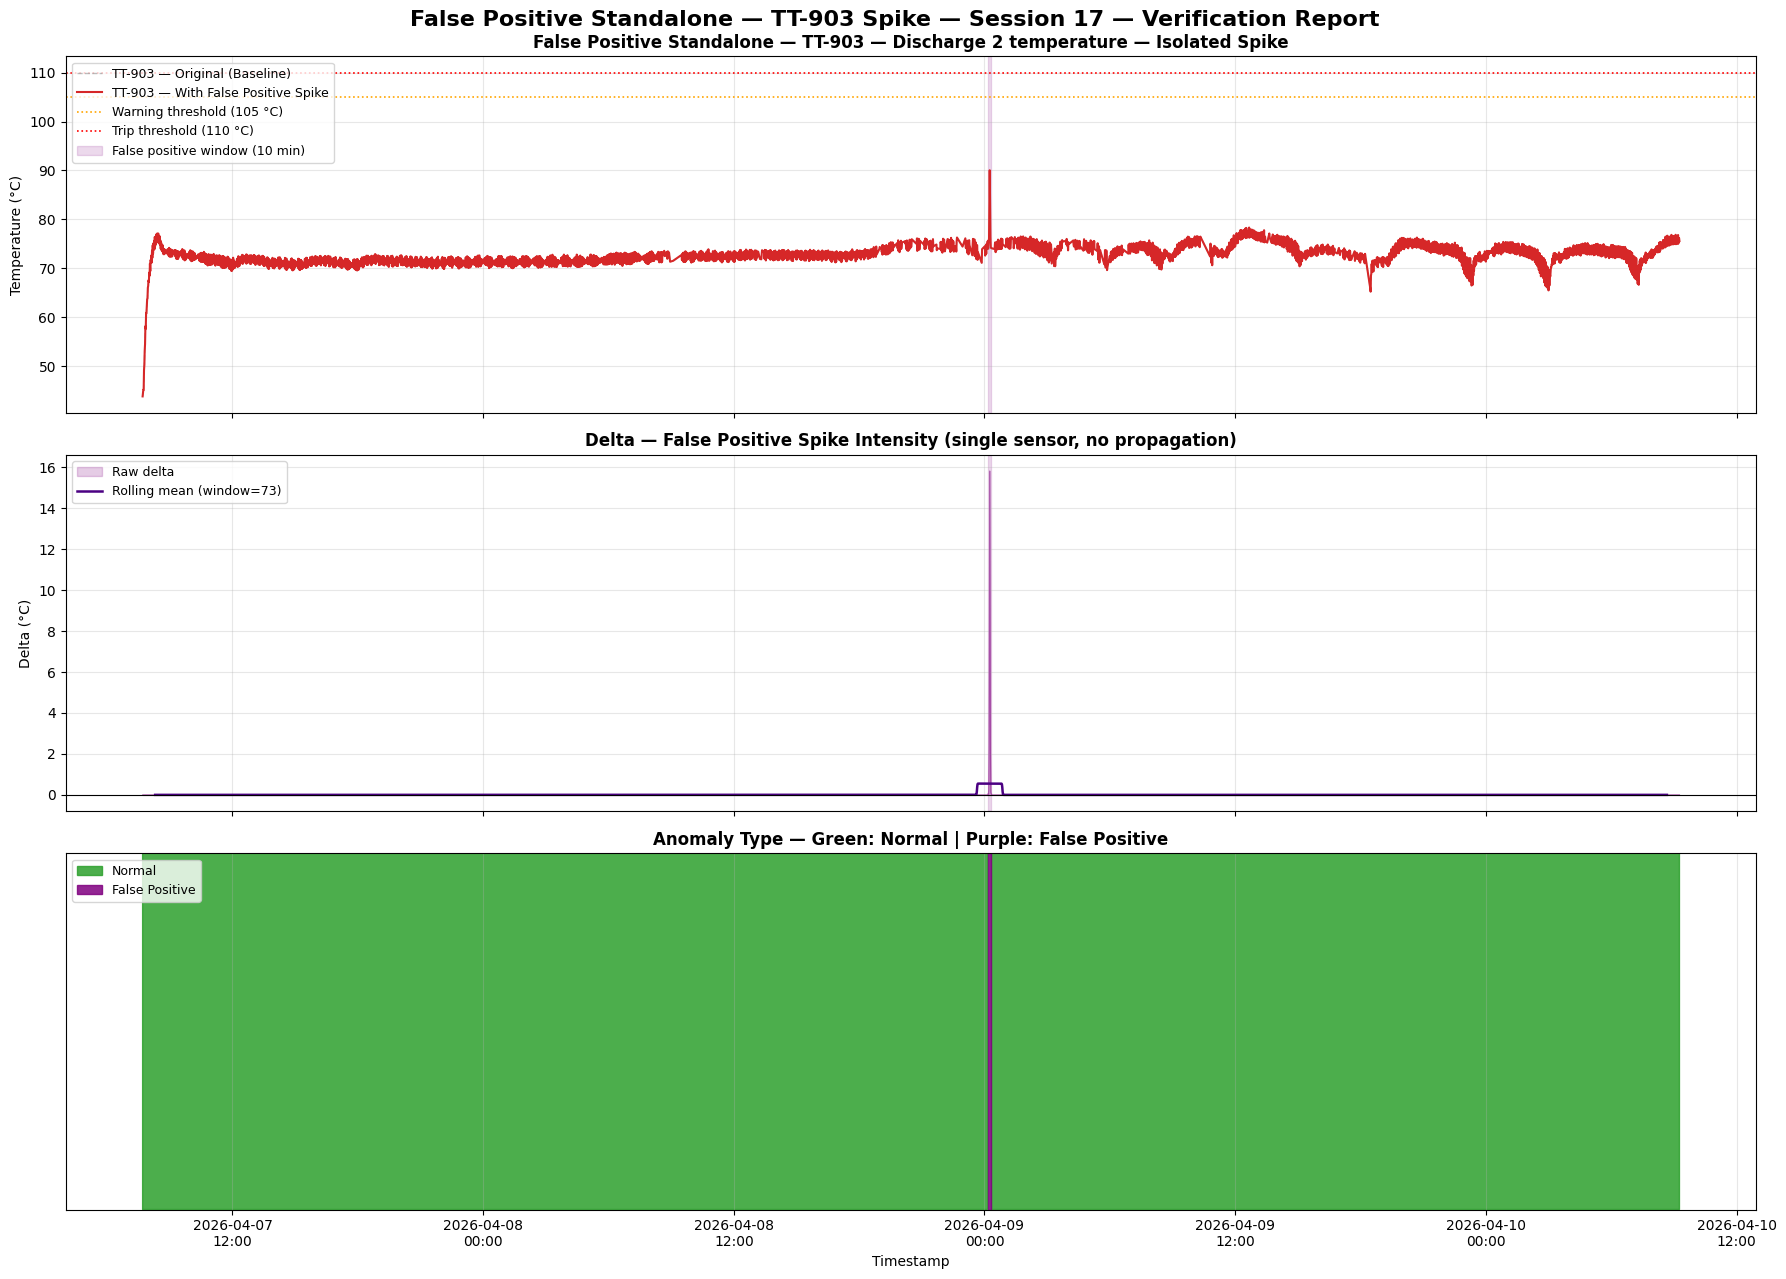

In [ ]:
""" False Positive — Standalone — TT-903 spike — Verification Plot — Session 17 """

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 13), sharex=True)

# ============================================================
# TIMESTAMPS
# ============================================================

fp_standalone_s17_fault_start_timestamp = fp_standalone_s17_df.index[fp_standalone_s17_start_idx]
fp_standalone_s17_fault_end_timestamp   = fp_standalone_s17_df.index[fp_standalone_s17_end_idx - 1]

# ============================================================
# PANEL 1 — Original vs Faulty TT-903
# ============================================================

ax1.plot(
    fp_standalone_s17_df_orig.index,
    fp_standalone_s17_df_orig["TT-903"],
    color="gray",
    alpha=0.5,
    linestyle="--",
    linewidth=1.0,
    label="TT-903 — Original (Baseline)"
)

ax1.plot(
    fp_standalone_s17_df.index,
    fp_standalone_s17_df["TT-903"],
    color="#d62728",
    linewidth=1.5,
    label="TT-903 — With False Positive Spike"
)

ax1.axhline(
    y=tt903_warning,
    color="orange",
    linestyle=":",
    linewidth=1.2,
    label=f"Warning threshold ({tt903_warning} °C)"
)

ax1.axhline(
    y=tt903_trip,
    color="red",
    linestyle=":",
    linewidth=1.2,
    label=f"Trip threshold ({tt903_trip} °C)"
)

ax1.axvspan(
    fp_standalone_s17_fault_start_timestamp,
    fp_standalone_s17_fault_end_timestamp,
    color="purple",
    alpha=0.15,
    label=f"False positive window ({fp_standalone_s17_duration_min} min)"
)

ax1.set_title("False Positive Standalone — TT-903 — Discharge 2 temperature — Isolated Spike", fontweight="bold")
ax1.set_ylabel("Temperature (°C)")
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(True, alpha=0.3)

# ============================================================
# PANEL 2 — Delta (spike intensity)
# ============================================================

fp_standalone_s17_delta_full         = fp_standalone_s17_df["TT-903"] - fp_standalone_s17_df_orig["TT-903"]
fp_standalone_s17_roll_window        = max(5, len(fp_standalone_s17_delta_full) // 60)
fp_standalone_s17_delta_rolling_mean = fp_standalone_s17_delta_full.rolling(fp_standalone_s17_roll_window, center=True).mean()

ax2.fill_between(
    fp_standalone_s17_df.index,
    0,
    fp_standalone_s17_delta_full,
    color="purple",
    alpha=0.2,
    label="Raw delta"
)

ax2.plot(
    fp_standalone_s17_df.index,
    fp_standalone_s17_delta_full,
    color="purple",
    linewidth=0.8,
    alpha=0.5
)

ax2.plot(
    fp_standalone_s17_df.index,
    fp_standalone_s17_delta_rolling_mean,
    color="#4B0082",
    linewidth=1.8,
    label=f"Rolling mean (window={fp_standalone_s17_roll_window})"
)

ax2.axhline(y=0, color="black", linewidth=0.8)

ax2.axvspan(
    fp_standalone_s17_fault_start_timestamp,
    fp_standalone_s17_fault_end_timestamp,
    color="purple",
    alpha=0.15
)

ax2.set_title("Delta — False Positive Spike Intensity (single sensor, no propagation)", fontweight="bold")
ax2.set_ylabel("Delta (°C)")
ax2.legend(loc="upper left", fontsize=9)
ax2.grid(True, alpha=0.3)

# ============================================================
# PANEL 3 — Anomaly type bar
# ============================================================

fp_standalone_s17_normal_mask = fp_standalone_s17_df["anomaly_type"] == "normal"
fp_standalone_s17_fp_mask     = fp_standalone_s17_df["anomaly_type"] == "false_positive"

ax3.fill_between(
    fp_standalone_s17_df.index,
    0, 1,
    where=fp_standalone_s17_normal_mask,
    color="#2ca02c",
    step="mid",
    alpha=0.85,
    label="Normal"
)

ax3.fill_between(
    fp_standalone_s17_df.index,
    0, 1,
    where=fp_standalone_s17_fp_mask,
    color="purple",
    step="mid",
    alpha=0.85,
    label="False Positive"
)

ax3.set_yticks([])
ax3.set_ylim(0, 1)
ax3.set_xlabel("Timestamp")
ax3.set_title("Anomaly Type — Green: Normal | Purple: False Positive", fontweight="bold")
ax3.legend(loc="upper left", fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))

fig.suptitle("False Positive Standalone — TT-903 Spike — Session 17 — Verification Report", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

### On Top

#### Session 16 - F1 Small - TT-904

In [ ]:
""" False Positive on top of F1 Small — TT-904 spike — Session 16 """

np.random.seed(42)

# ============================================================
# BASE — start from already injected F1 small session 16
# ============================================================

fp_on_f1_small_s16_df_orig        = f1_small_s16_df.copy()
fp_on_f1_small_s16_session_length = len(fp_on_f1_small_s16_df_orig)

# ============================================================
# FALSE POSITIVE PARAMETERS — TT-904 isolated spike
# — placed outside the F1 fault window to avoid confusion
# ============================================================

fp_on_f1_small_s16_main_sensor  = "TT-904"
fp_on_f1_small_s16_start_from   = 0.70
fp_on_f1_small_s16_duration_min = 12

fp_on_f1_small_s16_start_idx = int(round(fp_on_f1_small_s16_session_length * fp_on_f1_small_s16_start_from))
fp_on_f1_small_s16_end_idx   = min(fp_on_f1_small_s16_start_idx + fp_on_f1_small_s16_duration_min, fp_on_f1_small_s16_session_length)
fp_on_f1_small_s16_total_l   = fp_on_f1_small_s16_end_idx - fp_on_f1_small_s16_start_idx

print(f"FP on F1 small s16 — window: {fp_on_f1_small_s16_start_idx} to {fp_on_f1_small_s16_end_idx} ({fp_on_f1_small_s16_total_l} rows)")
print(f"F1 small fault window was:   {f1_small_s16_start_idx} to {f1_small_s16_end_idx}")

# ============================================================
# BASELINE — computed on pre-spike window
# ============================================================

fp_on_f1_small_s16_baseline_mean = fp_on_f1_small_s16_df_orig["TT-904"].iloc[:fp_on_f1_small_s16_start_idx].mean()
fp_on_f1_small_s16_baseline_std  = fp_on_f1_small_s16_df_orig["TT-904"].iloc[:fp_on_f1_small_s16_start_idx].std()

print(f"TT-904 baseline mean: {fp_on_f1_small_s16_baseline_mean:.4f} °C")
print(f"TT-904 baseline std:  {fp_on_f1_small_s16_baseline_std:.4f} °C")

# ============================================================
# SPIKE AMPLITUDE — stays below trip level
# ============================================================

fp_on_f1_small_s16_spike_target = tt904_trip * 0.80
fp_on_f1_small_s16_delta_mag    = fp_on_f1_small_s16_spike_target - fp_on_f1_small_s16_baseline_mean

print(f"TT-904 spike target:  {fp_on_f1_small_s16_spike_target:.4f} °C")
print(f"TT-904 delta mag:     {fp_on_f1_small_s16_delta_mag:.4f} °C")

# ============================================================
# DELTA SHAPE — sharp Gaussian spike, returns immediately
# ============================================================

fp_on_f1_small_s16_t      = np.arange(fp_on_f1_small_s16_total_l)
fp_on_f1_small_s16_center = int(fp_on_f1_small_s16_total_l * 0.5)
fp_on_f1_small_s16_width  = max(int(fp_on_f1_small_s16_total_l * 0.15), 1)
fp_on_f1_small_s16_noise  = np.random.normal(0, fp_on_f1_small_s16_baseline_std * 0.05, fp_on_f1_small_s16_total_l)
fp_on_f1_small_s16_delta  = fp_on_f1_small_s16_delta_mag * np.exp(-0.5 * ((fp_on_f1_small_s16_t - fp_on_f1_small_s16_center) / fp_on_f1_small_s16_width) ** 2) + fp_on_f1_small_s16_noise
fp_on_f1_small_s16_delta  = np.maximum(fp_on_f1_small_s16_delta, 0)

# ============================================================
# INJECT SPIKE — single sensor only, NO correlation propagation
# ============================================================

fp_on_f1_small_s16_df = fp_on_f1_small_s16_df_orig.copy()

fp_on_f1_small_s16_sensor_col_idx = fp_on_f1_small_s16_df.columns.get_loc("TT-904")
fp_on_f1_small_s16_df.iloc[fp_on_f1_small_s16_start_idx:fp_on_f1_small_s16_end_idx, fp_on_f1_small_s16_sensor_col_idx] += fp_on_f1_small_s16_delta

# ============================================================
# LABELS — preserve existing F1 small labels, mark FP window
# anomaly_level and is_injected_anomaly stay as they were
# only anomaly_type gets false_positive added where it was normal
# ============================================================

fp_on_f1_small_s16_fp_mask = fp_on_f1_small_s16_df.index[fp_on_f1_small_s16_start_idx:fp_on_f1_small_s16_end_idx]

fp_on_f1_small_s16_df.loc[fp_on_f1_small_s16_fp_mask, "anomaly_type"] = np.where(
    fp_on_f1_small_s16_df.loc[fp_on_f1_small_s16_fp_mask, "anomaly_type"] == "normal",
    "false_positive",
    fp_on_f1_small_s16_df.loc[fp_on_f1_small_s16_fp_mask, "anomaly_type"] + "+false_positive"
)

# ============================================================
# SAVE
# ============================================================

fp_on_f1_small_s16_df.to_csv(f"{output_dir_fp}/session_16_fp_on_F1_small_TT904.csv")

print(f"\nSession 16 FP on F1 small saved")
print(f"False positive rows:  {(fp_on_f1_small_s16_df['anomaly_type'].str.contains('false_positive')).sum()}")
print(f"F1 anomaly rows:      {(fp_on_f1_small_s16_df['anomaly_type'].str.contains('clogged_filters')).sum()}")
print(f"Normal rows:          {(fp_on_f1_small_s16_df['anomaly_type'] == 'normal').sum()}")
print(f"Anomaly types found:  {fp_on_f1_small_s16_df['anomaly_type'].unique()}")

FP on F1 small s16 — window: 2357 to 2369 (12 rows)
F1 small fault window was:   1010 to 1370
TT-904 baseline mean: 72.3167 °C
TT-904 baseline std:  1.8673 °C
TT-904 spike target:  88.0000 °C
TT-904 delta mag:     15.6833 °C

Session 16 FP on F1 small saved
False positive rows:  12
F1 anomaly rows:      360
Normal rows:          2995
Anomaly types found:  ['normal' 'clogged_filters' 'false_positive']


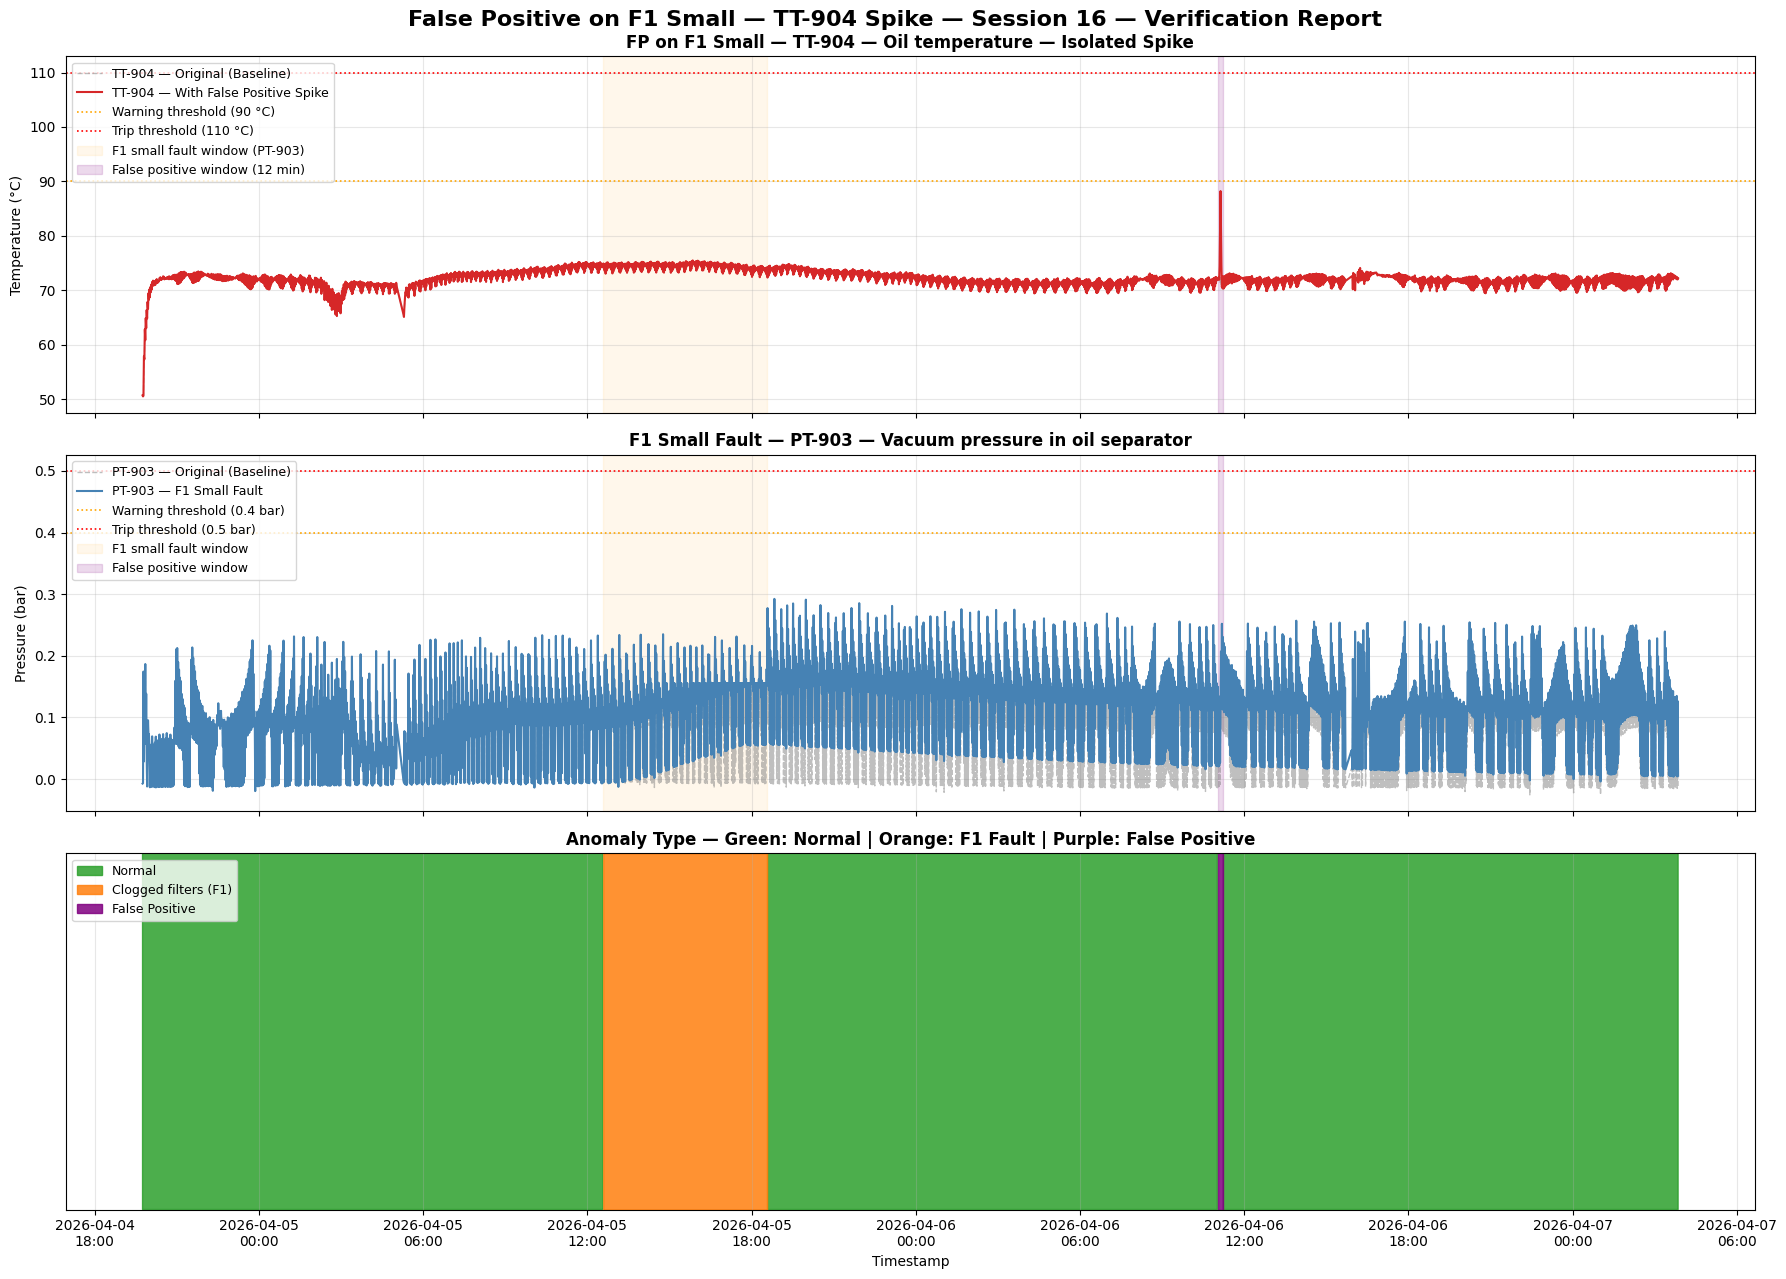

In [ ]:
""" False Positive on F1 Small — TT-904 spike — Verification Plot — Session 16 """

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 13), sharex=True)

# ============================================================
# TIMESTAMPS
# ============================================================

fp_on_f1_small_s16_fault_start_timestamp = fp_on_f1_small_s16_df.index[fp_on_f1_small_s16_start_idx]
fp_on_f1_small_s16_fault_end_timestamp   = fp_on_f1_small_s16_df.index[fp_on_f1_small_s16_end_idx - 1]
fp_on_f1_small_s16_f1_start_timestamp   = fp_on_f1_small_s16_df.index[f1_small_s16_start_idx]
fp_on_f1_small_s16_f1_end_timestamp     = fp_on_f1_small_s16_df.index[f1_small_s16_end_idx - 1]

# ============================================================
# PANEL 1 — TT-904 spike (false positive sensor)
# ============================================================

ax1.plot(
    f1_small_s16_df_orig.index,
    f1_small_s16_df_orig["TT-904"],
    color="gray",
    alpha=0.5,
    linestyle="--",
    linewidth=1.0,
    label="TT-904 — Original (Baseline)"
)

ax1.plot(
    fp_on_f1_small_s16_df.index,
    fp_on_f1_small_s16_df["TT-904"],
    color="#d62728",
    linewidth=1.5,
    label="TT-904 — With False Positive Spike"
)

ax1.axhline(
    y=tt904_warning,
    color="orange",
    linestyle=":",
    linewidth=1.2,
    label=f"Warning threshold ({tt904_warning} °C)"
)

ax1.axhline(
    y=tt904_trip,
    color="red",
    linestyle=":",
    linewidth=1.2,
    label=f"Trip threshold ({tt904_trip} °C)"
)

ax1.axvspan(
    fp_on_f1_small_s16_f1_start_timestamp,
    fp_on_f1_small_s16_f1_end_timestamp,
    color="orange",
    alpha=0.08,
    label="F1 small fault window (PT-903)"
)

ax1.axvspan(
    fp_on_f1_small_s16_fault_start_timestamp,
    fp_on_f1_small_s16_fault_end_timestamp,
    color="purple",
    alpha=0.15,
    label=f"False positive window ({fp_on_f1_small_s16_duration_min} min)"
)

ax1.set_title("FP on F1 Small — TT-904 — Oil temperature — Isolated Spike", fontweight="bold")
ax1.set_ylabel("Temperature (°C)")
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(True, alpha=0.3)

# ============================================================
# PANEL 2 — PT-903 (the actual F1 small fault sensor)
# ============================================================

ax2.plot(
    f1_small_s16_df_orig.index,
    f1_small_s16_df_orig["PT-903"],
    color="gray",
    alpha=0.5,
    linestyle="--",
    linewidth=1.0,
    label="PT-903 — Original (Baseline)"
)

ax2.plot(
    fp_on_f1_small_s16_df.index,
    fp_on_f1_small_s16_df["PT-903"],
    color="steelblue",
    linewidth=1.5,
    label="PT-903 — F1 Small Fault"
)

ax2.axhline(
    y=pt903_warning,
    color="orange",
    linestyle=":",
    linewidth=1.2,
    label=f"Warning threshold ({pt903_warning} bar)"
)

ax2.axhline(
    y=pt903_trip,
    color="red",
    linestyle=":",
    linewidth=1.2,
    label=f"Trip threshold ({pt903_trip} bar)"
)

ax2.axvspan(
    fp_on_f1_small_s16_f1_start_timestamp,
    fp_on_f1_small_s16_f1_end_timestamp,
    color="orange",
    alpha=0.08,
    label="F1 small fault window"
)

ax2.axvspan(
    fp_on_f1_small_s16_fault_start_timestamp,
    fp_on_f1_small_s16_fault_end_timestamp,
    color="purple",
    alpha=0.15,
    label="False positive window"
)

ax2.set_title("F1 Small Fault — PT-903 — Vacuum pressure in oil separator", fontweight="bold")
ax2.set_ylabel("Pressure (bar)")
ax2.legend(loc="upper left", fontsize=9)
ax2.grid(True, alpha=0.3)

# ============================================================
# PANEL 3 — Anomaly type bar
# ============================================================

fp_on_f1_small_s16_normal_mask       = fp_on_f1_small_s16_df["anomaly_type"] == "normal"
fp_on_f1_small_s16_f1_mask           = fp_on_f1_small_s16_df["anomaly_type"] == "clogged_filters"
fp_on_f1_small_s16_fp_only_mask      = fp_on_f1_small_s16_df["anomaly_type"] == "false_positive"

ax3.fill_between(
    fp_on_f1_small_s16_df.index,
    0, 1,
    where=fp_on_f1_small_s16_normal_mask,
    color="#2ca02c",
    step="mid",
    alpha=0.85,
    label="Normal"
)

ax3.fill_between(
    fp_on_f1_small_s16_df.index,
    0, 1,
    where=fp_on_f1_small_s16_f1_mask,
    color="#ff7f0e",
    step="mid",
    alpha=0.85,
    label="Clogged filters (F1)"
)

ax3.fill_between(
    fp_on_f1_small_s16_df.index,
    0, 1,
    where=fp_on_f1_small_s16_fp_only_mask,
    color="purple",
    step="mid",
    alpha=0.85,
    label="False Positive"
)

ax3.set_yticks([])
ax3.set_ylim(0, 1)
ax3.set_xlabel("Timestamp")
ax3.set_title("Anomaly Type — Green: Normal | Orange: F1 Fault | Purple: False Positive", fontweight="bold")
ax3.legend(loc="upper left", fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))

fig.suptitle("False Positive on F1 Small — TT-904 Spike — Session 16 — Verification Report", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

#### Session 17 - F3 Severe - PT-903

In [ ]:
""" False Positive on top of F3 Severe — PT-903 spike — Session 17 """

np.random.seed(42)

# ============================================================
# BASE — start from already injected F3 severe session 17
# ============================================================

fp_on_f3_severe_s17_df_orig        = f3_severe_s17_df.copy()
fp_on_f3_severe_s17_session_length = len(fp_on_f3_severe_s17_df_orig)

# ============================================================
# FALSE POSITIVE PARAMETERS — PT-903 isolated spike
# — placed outside the F3 fault window to avoid confusion
# ============================================================

fp_on_f3_severe_s17_main_sensor  = "PT-903"
fp_on_f3_severe_s17_start_from   = 0.20
fp_on_f3_severe_s17_duration_min = 10

fp_on_f3_severe_s17_start_idx = int(round(fp_on_f3_severe_s17_session_length * fp_on_f3_severe_s17_start_from))
fp_on_f3_severe_s17_end_idx   = min(fp_on_f3_severe_s17_start_idx + fp_on_f3_severe_s17_duration_min, fp_on_f3_severe_s17_session_length)
fp_on_f3_severe_s17_total_l   = fp_on_f3_severe_s17_end_idx - fp_on_f3_severe_s17_start_idx

print(f"FP on F3 severe s17 — window: {fp_on_f3_severe_s17_start_idx} to {fp_on_f3_severe_s17_end_idx} ({fp_on_f3_severe_s17_total_l} rows)")
print(f"F3 severe fault window was:   {f3_severe_s17_start_idx} to {f3_severe_s17_end_idx}")

# ============================================================
# BASELINE — computed on pre-spike window
# ============================================================

fp_on_f3_severe_s17_baseline_mean = fp_on_f3_severe_s17_df_orig["PT-903"].iloc[:fp_on_f3_severe_s17_start_idx].mean()
fp_on_f3_severe_s17_baseline_std  = fp_on_f3_severe_s17_df_orig["PT-903"].iloc[:fp_on_f3_severe_s17_start_idx].std()

print(f"PT-903 baseline mean: {fp_on_f3_severe_s17_baseline_mean:.4f} bar")
print(f"PT-903 baseline std:  {fp_on_f3_severe_s17_baseline_std:.4f} bar")

# ============================================================
# SPIKE AMPLITUDE — stays below trip level
# ============================================================

fp_on_f3_severe_s17_spike_target = pt903_trip * 0.80
fp_on_f3_severe_s17_delta_mag    = fp_on_f3_severe_s17_spike_target - fp_on_f3_severe_s17_baseline_mean

print(f"PT-903 spike target:  {fp_on_f3_severe_s17_spike_target:.4f} bar")
print(f"PT-903 delta mag:     {fp_on_f3_severe_s17_delta_mag:.4f} bar")

# ============================================================
# DELTA SHAPE — sharp Gaussian spike, returns immediately
# ============================================================

fp_on_f3_severe_s17_t      = np.arange(fp_on_f3_severe_s17_total_l)
fp_on_f3_severe_s17_center = int(fp_on_f3_severe_s17_total_l * 0.5)
fp_on_f3_severe_s17_width  = max(int(fp_on_f3_severe_s17_total_l * 0.15), 1)
fp_on_f3_severe_s17_noise  = np.random.normal(0, fp_on_f3_severe_s17_baseline_std * 0.05, fp_on_f3_severe_s17_total_l)
fp_on_f3_severe_s17_delta  = fp_on_f3_severe_s17_delta_mag * np.exp(-0.5 * ((fp_on_f3_severe_s17_t - fp_on_f3_severe_s17_center) / fp_on_f3_severe_s17_width) ** 2) + fp_on_f3_severe_s17_noise
fp_on_f3_severe_s17_delta  = np.maximum(fp_on_f3_severe_s17_delta, 0)

# ============================================================
# INJECT SPIKE — single sensor only, NO correlation propagation
# ============================================================

fp_on_f3_severe_s17_df = fp_on_f3_severe_s17_df_orig.copy()

fp_on_f3_severe_s17_sensor_col_idx = fp_on_f3_severe_s17_df.columns.get_loc("PT-903")
fp_on_f3_severe_s17_df.iloc[fp_on_f3_severe_s17_start_idx:fp_on_f3_severe_s17_end_idx, fp_on_f3_severe_s17_sensor_col_idx] += fp_on_f3_severe_s17_delta

# ============================================================
# LABELS — preserve existing F3 severe labels, mark FP window
# ============================================================

fp_on_f3_severe_s17_fp_mask = fp_on_f3_severe_s17_df.index[fp_on_f3_severe_s17_start_idx:fp_on_f3_severe_s17_end_idx]

fp_on_f3_severe_s17_df.loc[fp_on_f3_severe_s17_fp_mask, "anomaly_type"] = np.where(
    fp_on_f3_severe_s17_df.loc[fp_on_f3_severe_s17_fp_mask, "anomaly_type"] == "normal",
    "false_positive",
    fp_on_f3_severe_s17_df.loc[fp_on_f3_severe_s17_fp_mask, "anomaly_type"] + "+false_positive"
)

# ============================================================
# SAVE
# ============================================================

fp_on_f3_severe_s17_df.to_csv(f"{output_dir_fp}/session_17_fp_on_F3_severe_PT903.csv")

print(f"\nSession 17 FP on F3 severe saved")
print(f"False positive rows:  {(fp_on_f3_severe_s17_df['anomaly_type'].str.contains('false_positive')).sum()}")
print(f"F3 anomaly rows:      {(fp_on_f3_severe_s17_df['anomaly_type'].str.contains('valve_fault')).sum()}")
print(f"Normal rows:          {(fp_on_f3_severe_s17_df['anomaly_type'] == 'normal').sum()}")
print(f"Anomaly types found:  {fp_on_f3_severe_s17_df['anomaly_type'].unique()}")

FP on F3 severe s17 — window: 883 to 893 (10 rows)
F3 severe fault window was:   2428 to 3148
PT-903 baseline mean: -0.1888 bar
PT-903 baseline std:  0.8753 bar
PT-903 spike target:  0.4000 bar
PT-903 delta mag:     0.5888 bar

Session 17 FP on F3 severe saved
False positive rows:  10
F3 anomaly rows:      1987
Normal rows:          2418
Anomaly types found:  ['normal' 'false_positive' 'valve_fault']


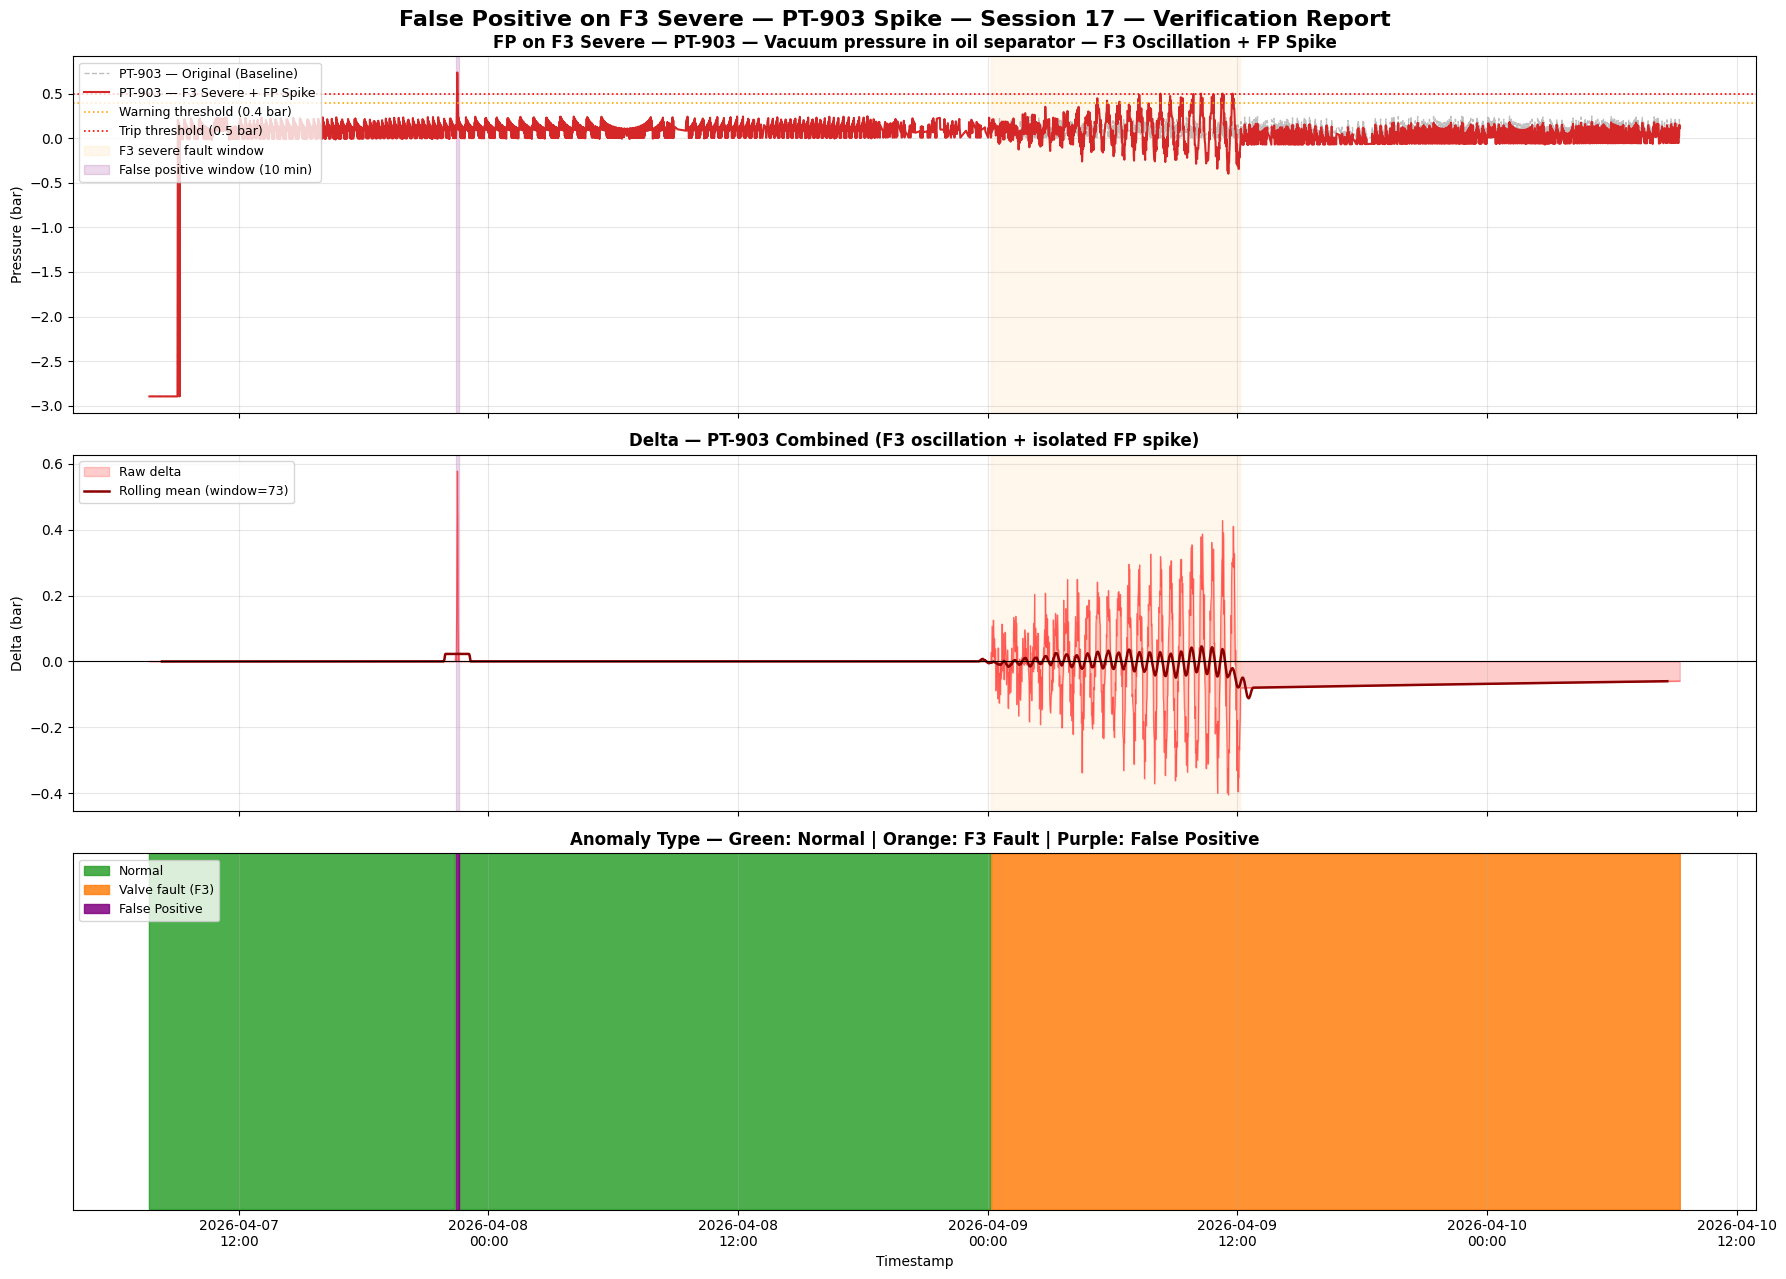

In [ ]:
""" False Positive on F3 Severe — PT-903 spike — Verification Plot — Session 17 """

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 13), sharex=True)

# ============================================================
# TIMESTAMPS
# ============================================================

fp_on_f3_severe_s17_fault_start_timestamp = fp_on_f3_severe_s17_df.index[fp_on_f3_severe_s17_start_idx]
fp_on_f3_severe_s17_fault_end_timestamp   = fp_on_f3_severe_s17_df.index[fp_on_f3_severe_s17_end_idx - 1]
fp_on_f3_severe_s17_f3_start_timestamp   = fp_on_f3_severe_s17_df.index[f3_severe_s17_start_idx]
fp_on_f3_severe_s17_f3_end_timestamp     = fp_on_f3_severe_s17_df.index[f3_severe_s17_end_idx - 1]

# ============================================================
# PANEL 1 — PT-903 — both F3 severe fault and FP spike
# ============================================================

ax1.plot(
    f3_severe_s17_df_orig.index,
    f3_severe_s17_df_orig["PT-903"],
    color="gray",
    alpha=0.5,
    linestyle="--",
    linewidth=1.0,
    label="PT-903 — Original (Baseline)"
)

ax1.plot(
    fp_on_f3_severe_s17_df.index,
    fp_on_f3_severe_s17_df["PT-903"],
    color="#d62728",
    linewidth=1.5,
    label="PT-903 — F3 Severe + FP Spike"
)

ax1.axhline(
    y=pt903_warning,
    color="orange",
    linestyle=":",
    linewidth=1.2,
    label=f"Warning threshold ({pt903_warning} bar)"
)

ax1.axhline(
    y=pt903_trip,
    color="red",
    linestyle=":",
    linewidth=1.2,
    label=f"Trip threshold ({pt903_trip} bar)"
)

ax1.axvspan(
    fp_on_f3_severe_s17_f3_start_timestamp,
    fp_on_f3_severe_s17_f3_end_timestamp,
    color="orange",
    alpha=0.08,
    label="F3 severe fault window"
)

ax1.axvspan(
    fp_on_f3_severe_s17_fault_start_timestamp,
    fp_on_f3_severe_s17_fault_end_timestamp,
    color="purple",
    alpha=0.15,
    label=f"False positive window ({fp_on_f3_severe_s17_duration_min} min)"
)

ax1.set_title("FP on F3 Severe — PT-903 — Vacuum pressure in oil separator — F3 Oscillation + FP Spike", fontweight="bold")
ax1.set_ylabel("Pressure (bar)")
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(True, alpha=0.3)

# ============================================================
# PANEL 2 — Delta PT-903
# ============================================================

fp_on_f3_severe_s17_delta_full         = fp_on_f3_severe_s17_df["PT-903"] - f3_severe_s17_df_orig["PT-903"]
fp_on_f3_severe_s17_roll_window        = max(5, len(fp_on_f3_severe_s17_delta_full) // 60)
fp_on_f3_severe_s17_delta_rolling_mean = fp_on_f3_severe_s17_delta_full.rolling(fp_on_f3_severe_s17_roll_window, center=True).mean()

ax2.fill_between(
    fp_on_f3_severe_s17_df.index,
    0,
    fp_on_f3_severe_s17_delta_full,
    color="red",
    alpha=0.2,
    label="Raw delta"
)

ax2.plot(
    fp_on_f3_severe_s17_df.index,
    fp_on_f3_severe_s17_delta_full,
    color="red",
    linewidth=0.8,
    alpha=0.5
)

ax2.plot(
    fp_on_f3_severe_s17_df.index,
    fp_on_f3_severe_s17_delta_rolling_mean,
    color="#8B0000",
    linewidth=1.8,
    label=f"Rolling mean (window={fp_on_f3_severe_s17_roll_window})"
)

ax2.axhline(y=0, color="black", linewidth=0.8)

ax2.axvspan(
    fp_on_f3_severe_s17_f3_start_timestamp,
    fp_on_f3_severe_s17_f3_end_timestamp,
    color="orange",
    alpha=0.08
)

ax2.axvspan(
    fp_on_f3_severe_s17_fault_start_timestamp,
    fp_on_f3_severe_s17_fault_end_timestamp,
    color="purple",
    alpha=0.15
)

ax2.set_title("Delta — PT-903 Combined (F3 oscillation + isolated FP spike)", fontweight="bold")
ax2.set_ylabel("Delta (bar)")
ax2.legend(loc="upper left", fontsize=9)
ax2.grid(True, alpha=0.3)

# ============================================================
# PANEL 3 — Anomaly type bar
# ============================================================

fp_on_f3_severe_s17_normal_mask  = fp_on_f3_severe_s17_df["anomaly_type"] == "normal"
fp_on_f3_severe_s17_f3_mask      = fp_on_f3_severe_s17_df["anomaly_type"] == "valve_fault"
fp_on_f3_severe_s17_fp_only_mask = fp_on_f3_severe_s17_df["anomaly_type"] == "false_positive"

ax3.fill_between(
    fp_on_f3_severe_s17_df.index,
    0, 1,
    where=fp_on_f3_severe_s17_normal_mask,
    color="#2ca02c",
    step="mid",
    alpha=0.85,
    label="Normal"
)

ax3.fill_between(
    fp_on_f3_severe_s17_df.index,
    0, 1,
    where=fp_on_f3_severe_s17_f3_mask,
    color="#ff7f0e",
    step="mid",
    alpha=0.85,
    label="Valve fault (F3)"
)

ax3.fill_between(
    fp_on_f3_severe_s17_df.index,
    0, 1,
    where=fp_on_f3_severe_s17_fp_only_mask,
    color="purple",
    step="mid",
    alpha=0.85,
    label="False Positive"
)

ax3.set_yticks([])
ax3.set_ylim(0, 1)
ax3.set_xlabel("Timestamp")
ax3.set_title("Anomaly Type — Green: Normal | Orange: F3 Fault | Purple: False Positive", fontweight="bold")
ax3.legend(loc="upper left", fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))

fig.suptitle("False Positive on F3 Severe — PT-903 Spike — Session 17 — Verification Report", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()